# Electoral Analysis – Chile 2025 Presidential segunda vuelta

Al no alcanzar ningún candidato la mayoría absoluta requerida (50% + 1 de los votos válidos) en la primera vuelta, se convocó a una **segunda vuelta presidencial** el **domingo 15 de diciembre de 2025**, enfrentando a Jeannette Jara y José Antonio Kast.

Esta elección definitoria se produjo en un contexto de alta polarización y fragmentación heredada de la primera vuelta. Jeannette Jara, candidata del oficialismo de izquierda (Partido Comunista y Frente Amplio) y sectores de centro-izquierda (DC, PPD y PS), había logrado el primer lugar con un **26,75%** de los votos válidos (3.446.854 votos). Si bien representaba la unidad del bloque progresista, su resultado constituyó la peor performance de una candidatura de izquierda o centro-izquierda en primera vuelta desde el retorno a la democracia en 1990. Como sucesora directa del gobierno de Gabriel Boric —cuya gestión acumuló un desgaste histórico—, Jara cargaba con la herencia de la Concertación y la Nueva Mayoría, aunque parte importante de la Democracia Cristiana y otros sectores centristas ya habían emigrado hacia la derecha.

Por su parte, **José Antonio Kast**, del Partido Republicano —formado tras su ruptura con la derecha liberal de Sebastián Piñera—, obtuvo el **23,96%** de los votos (3.086.963 votos). Candidato presidencial en 2017 (donde terminó en cuarto lugar con 7,93%) y finalista en 2021 frente a Gabriel Boric, Kast consolidó en 2025 el liderazgo de la derecha conservadora. De cara a la segunda vuelta, recibió el apoyo explícito de la derecha libertaria (Johannes Kaiser), Chile Vamos y diversos grupos de centro (Amarillos y Demócratas), muchos de ellos provenientes de la ex Concertación y Nueva Mayoría que se alejaron del gobierno de Boric.

La segunda vuelta se configuró así como un duelo entre **la continuidad del proyecto progresista** (Jara) y un **giro conservador con fuerte acento en orden, seguridad y anti-centralismo** (Kast). Más que una simple disputa ideológica, representó el clímax de un proceso de realineamiento político iniciado en 2019, donde el voto antisistema, la fragmentación de la derecha tradicional y el desgaste del oficialismo definieron el nuevo equilibrio de fuerzas del país.


El 14 de diciembre de 2025, Chile vivió una jornada electoral que marca un punto de inflexión en su historia democrática reciente. La segunda vuelta presidencial, la primera bajo el régimen de voto obligatorio desde su reinstauración en 2022, no solo definió al sucesor de Gabriel Boric, sino que también puso a prueba la capacidad de las instituciones y los sistemas de medición para adaptarse a un nuevo mapa electoral. El contundente triunfo de José Antonio Kast sobre Jeannette Jara, con un margen que duplicó el de 2021, inicia un nuevo ciclo político cuyas implicancias trascienden el mero recambio en La Moneda. Este análisis desglosa las claves de este resultado, explorando desde la recomposición del sistema de partidos hasta las lecciones metodológicas que deja una elección atípica.



## 1. Setup

### 1.1. Dependencies

In [1]:
!pip install pandas numpy matplotlib geopandas

/home/alfonso/Python/1_Elecciones_presidencial_2025/segunda_vuelta/2_2.Notebook/venv/bin/pip: 2: exec: /home/alfonso/Python/1-Elecciones presidencial 2025/Segunda vuelta/2_2.Notebook/venv/bin/python3: not found


### 1.2. Imports

In [2]:
import os
import re
from pathlib import Path
from matplotlib.gridspec import GridSpec

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import seaborn as sns


## 2. Data Loading

### 2.1. Electoral and Demographic Data

In [3]:
# Remote source URLs – GitHub raw files
url_votes_2025_first_round = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2025_first_round.csv"
url_votes_2025_second_round = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2025_second_round.csv"
url_votes_2021_second_round = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2021_second_round.csv"

url_pop   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/communes_population_2024.csv"
url_dim   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/region_dimension.csv"

print("URLs configured")

URLs configured


### 2.2. Load Data

#### 2.2.1. Electoral Data (first round 2025)

In [4]:
df_2025_v1 = pd.read_csv(url_votes_2025_first_round, encoding='utf-8-sig')

print(f"Electoral data loaded: {len(df_2025_v1):,} communes, {df_2025_v1.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_2025_v1.head(3)

Electoral data loaded: 346 communes, 24 columns

First 3 rows:


,commune,region,artes_votes,artes_pct,enriquez_ominami_votes,enriquez_ominami_pct,jara_votes,jara_pct,kaiser_votes,kaiser_pct,...,mayne_nicholls_votes,mayne_nicholls_pct,parisi_votes,parisi_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Antofagasta,Antofagasta,1375,0.56,2738,1.12,60507,24.71,31798,12.99,...,4065,1.66,79669,32.54,3014,1.18,255984,100.0,8137,3.18
1,Calama,Antofagasta,488,0.47,1201,1.15,19496,18.69,14990,14.37,...,1005,0.96,40651,38.98,963,0.89,108350,100.0,3096,2.86
2,Maria Elena,Antofagasta,14,0.45,40,1.28,694,22.27,288,9.24,...,33,1.06,1429,45.86,41,1.26,3261,100.0,104,3.19


#### 2.2.2. Electoral Data (second round 2025)

In [5]:
df_2025_v2 = pd.read_csv(url_votes_2025_second_round, encoding='utf-8-sig')

print(f"2021 electoral data loaded: {len(df_2025_v2):,} communes, {df_2025_v2.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_2025_v2.head(3)

2021 electoral data loaded: 346 communes, 12 columns

First 3 rows:


,commune,region,jara_votes,jara_pct,kast_votes,kast_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Antofagasta,Antofagasta,102890,45.15,124984,54.85,3884,1.53,253849,100.0,22091,8.70
1,Calama,Antofagasta,34473,36.00,61295,64.00,1222,1.14,107390,100.0,10400,9.68
2,Maria Elena,Antofagasta,1408,50.47,1382,49.53,60,1.89,3176,100.0,326,10.26


#### 2.2.3. Electoral Data (second round 2021)

In [6]:
df_2021_v2 = pd.read_csv(url_votes_2021_second_round, encoding='utf-8-sig')

print(f"2021 electoral data loaded: {len(df_2021_v2):,} communes, {df_2021_v2.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_2021_v2.head(3)

2021 electoral data loaded: 346 communes, 12 columns

First 3 rows:


,commune,region,boric_votes,boric_pct,kast_votes,kast_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Alto Hospicio,Tarapacá,11971,50.16,11897,49.84,64,0.26,24211,100,279,1.15
1,Camiña,Tarapacá,151,17.62,706,82.38,0,0.00,866,100,9,1.04
2,Colchane,Tarapacá,52,5.31,928,94.69,1,0.10,984,100,3,0.30


#### 2.2.4. Population Data

In [7]:
df_pop = pd.read_csv(url_pop, encoding='utf-8-sig')

# Cast population columns to nullable integer to remove trailing .0
for col in ['population', 'male_population', 'female_population']:
    if col in df_pop.columns:
        df_pop[col] = df_pop[col].astype('Int64')

print(f"Population data loaded: {len(df_pop):,} communes, {df_pop.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_pop.head(3)

Population data loaded: 345 communes, 6 columns

First 3 rows:


,commune,region,population,male_population,female_population,sex_ratio
0,camarones,Arica y Parinacota,861,430,431,99.8
1,putre,Arica y Parinacota,1547,846,701,120.7
2,general lagos,Arica y Parinacota,508,261,247,105.7


#### 2.2.5. Region Dimension Table

In [8]:
df_region_dim = pd.read_csv(url_dim, encoding='utf-8-sig')

print(f"Region dimension table loaded: {len(df_region_dim)} rows, {df_region_dim.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_region_dim.head(3)

Region dimension table loaded: 16 rows, 5 columns

First 3 rows:


,region_code,region,macrozone,macrozone_order,region_order
0,15,Arica y Parinacota,Norte Grande,1,1
1,1,Tarapacá,Norte Grande,1,2
2,2,Antofagasta,Norte Grande,1,3


### 2.3. Geographic Data (Commune GeoJSON)

In [9]:
# ============================================================================
# GEOGRAPHIC DATA LOADER
# ============================================================================

def load_geographic_data() -> gpd.GeoDataFrame:
    """
    Loads Chilean commune geometries from multiple sources in priority order:
    1. Local files (GeoJSON or SHP).
    2. Per-region download from the public caracena/chile-geojson repository.

    Raises RuntimeError if no source is reachable.

    Returns
    -------
    gpd.GeoDataFrame
        CRS EPSG:4326, with at least columns NOM_COM, COD_COM, REGION_NUM.
    """
    print("Loading geographic data...")

    # Local file search order
    local_files = [
        'comunas_chile.geojson', 'comunas.geojson',
        'chile_comunas.geojson', 'chile.geojson',
        'comunas_chile.shp', 'comunas.json',
    ]
    for path in local_files:
        if os.path.exists(path):
            try:
                gdf = gpd.read_file(path)
                if len(gdf) > 0:
                    print(f"Local file loaded: {path} ({len(gdf)} communes)")
                    return gdf
            except Exception as exc:
                print(f"Could not read {path}: {exc}")

    # Fallback: download per region from GitHub
    print("No local files found. Downloading from caracena/chile-geojson...")
    gdfs = []
    for i in range(1, 17):
        url = f"https://raw.githubusercontent.com/caracena/chile-geojson/master/{i}.geojson"
        try:
            gdf_region = gpd.read_file(url)
            # Normalise column names to internal schema
            if 'Comuna' in gdf_region.columns:
                gdf_region['NOM_COM'] = gdf_region['Comuna']
            if 'cod_comuna' in gdf_region.columns:
                gdf_region['COD_COM'] = gdf_region['cod_comuna']
            gdf_region['REGION_NUM'] = (
                gdf_region['codregion'] if 'codregion' in gdf_region.columns else i
            )
            gdfs.append(gdf_region)
            print(f"Region {i}: {len(gdf_region)} communes downloaded")
        except Exception as exc:
            print(f"Error downloading region {i}: {exc}")

    if gdfs:
        gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs='EPSG:4326')
        gdf.to_file('comunas_chile.geojson', driver='GeoJSON')
        print(f"Total downloaded: {len(gdf)} communes. Saved as 'comunas_chile.geojson'.")
        return gdf

    raise RuntimeError("Could not load geographic data from any source.")


communes = load_geographic_data()

# Derive REGION_NUM from COD_COM when absent in the GeoDataFrame
if 'REGION_NUM' not in communes.columns:
    if 'COD_COM' in communes.columns:
        communes['REGION_NUM'] = communes['COD_COM'].astype(str).str[:2].astype(int)
    else:
        raise ValueError("Neither 'REGION_NUM' nor 'COD_COM' found in GeoDataFrame.")

print(f"GeoDataFrame ready: {len(communes)} records")
print(f"Columns: {list(communes.columns)}")

Loading geographic data...
Local file loaded: comunas_chile.geojson (345 communes)
GeoDataFrame ready: 345 records
Columns: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'NOM_COM', 'COD_COM', 'REGION_NUM', 'geometry']


### 2.4. Commune normalizer

In [10]:
# ============================================================================
# COMMUNE NAME NORMALIZER
# ============================================================================

# Deferred: used in spatial join sections (§ map analysis, § transition maps).
# Defined here to keep all utility functions in §2 and avoid forward references.

import unicodedata

def normalize_commune_name(name: str) -> str:
    """
    Canonicalizes a commune name for cross-dataset matching.

    Processing pipeline:
    1. Lowercase and strip surrounding whitespace.
    2. NFD decomposition + strip combining marks — removes all diacritics
       and diaereses regardless of source encoding (e.g. ü → u).
    3. Remove non-alphanumeric characters (hyphens, parentheses, punctuation).
    4. Collapse internal whitespace to a single space.
    5. Apply a curated correction table on the clean ASCII form to resolve
       residual spelling divergences between source datasets.

    Diacritics are stripped before the correction lookup so every correction
    key uses plain ASCII; no accented variants are required.

    Parameters
    ----------
    name : str
        Raw commune name from any source dataset.

    Returns
    -------
    str
        Normalized canonical form ready for equality comparison or join key.

    Notes
    -----
    First active use: spatial join in the commune-level winner map section.
    """
    if pd.isna(name):
        return ''

    name = str(name).strip().lower()

    # Strip diacritics via NFD decomposition + combining mark removal
    name = unicodedata.normalize('NFD', name)
    name = ''.join(c for c in name if unicodedata.category(c) != 'Mn')

    # Remove non-alphanumeric characters (keep spaces)
    name = re.sub(r'[^a-z0-9\s]', '', name)

    # Collapse whitespace
    name = ' '.join(name.split())

    # Correction table: keys are already-stripped ASCII forms
    CORRECTIONS = {
        'llayllay':                  'llaillay',   # Llay-Llay → Llaillay
        'trehuaco':                  'treguaco',   # legacy transliteration
        'marchigue':                'marchihue',  # Marchigüe → Marchihue (official)
        'cabo de hornosexnavarino':  'cabo de hornos',  # parenthetical suffix
    }
    return CORRECTIONS.get(name, name)

### 2.5. Metadata candidatos

In [11]:
# ============================================================================
# CANDIDATE METADATA AND COLOR PALETTE
# ============================================================================

# Display name → column key and political affiliation
CANDIDATES_META = {
    'Jeannette Jara':         {'col': 'jara_votes',             'party': 'Left-wing officialist (Boric - Unidad por Chile)'},
    'José Antonio Kast':      {'col': 'kast_votes',             'party': 'Conservative right (Partido Republicano)'},
    'Franco Parisi':          {'col': 'parisi_votes',           'party': 'Third way (Partido de la Gente)'},
    'Johannes Kaiser':        {'col': 'kaiser_votes',           'party': 'Libertarian right (Partido Nacional Libertario)'},
    'Evelyn Matthei':         {'col': 'matthei_votes',          'party': 'Historical right - Piñerismo (Chile Vamos)'},
    'Harold Mayne-Nicholls':  {'col': 'mayne_nicholls_votes',   'party': 'Independent'},
    'Marco Enriquez-Ominami': {'col': 'enriquez_ominami_votes', 'party': 'Independent left'},
    'Eduardo Artes':          {'col': 'artes_votes',            'party': 'Far left'},
}

# Campaign corporate color palette by candidate
CANDIDATE_COLORS = {
    'Jeannette Jara':         '#E54944',
    'José Antonio Kast':      '#35466D',
    'Franco Parisi':          '#4B70B5',
    'Johannes Kaiser':        '#F3832C',
    'Evelyn Matthei':         '#226FD4',
    'Harold Mayne-Nicholls':  '#BED8DF',
    'Marco Enriquez-Ominami': '#DD2883',
    'Eduardo Artes':          '#CA1C1F',
    'No data':                '#D3D3D3',
}

## 3. General Participation Statistics

La segunda vuelta presidencial de 2025 ha dejado una huella estadística que obliga a reexaminar los supuestos clásicos sobre el comportamiento electoral chileno. Por primera vez desde la implementación del balotaje en 1999, la participación en términos de votos válidos no solo se estancó, sino que retrocedió respecto de la primera vuelta, desafiando la lógica de que una elección definitoria moviliza al electorado. El dato más elocuente de esta anomalía es el explosivo aumento del voto nulo, que casi se duplicó en el lapso de un mes, alcanzando una magnitud sin precedentes en la historia democrática reciente. Este fenómeno, que afectó desproporcionadamente a la opción oficialista, no es un mero accidente estadístico, sino un síntoma de una crisis de representación que trasciende el resultado inmediato.

In [12]:
# ============================================================================
# COMPARATIVE VOTER TURNOUT: FIRST ROUND VS SECOND ROUND
# ============================================================================

def analyze_turnout_comparison(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Compares participation metrics between first and second rounds.
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: casted_votes, blank_votes, null_votes
    df2 : pd.DataFrame
        Second round data with columns: casted_votes, blank_votes, null_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with indicator, first_round, second_round, diff, trend
    """
    # First round totals
    communes_1 = len(df1)
    casted_1 = df1['casted_votes'].sum()
    blank_1 = df1['blank_votes'].sum()
    null_1 = df1['null_votes'].sum()
    valid_1 = casted_1 - blank_1 - null_1
    
    # Second round totals
    communes_2 = len(df2)
    casted_2 = df2['casted_votes'].sum()
    blank_2 = df2['blank_votes'].sum()
    null_2 = df2['null_votes'].sum()
    valid_2 = casted_2 - blank_2 - null_2
    
    def get_trend(val1, val2):
        if val2 > val1:
            return 'INCREASE'
        elif val2 < val1:
            return 'DECREASE'
        return 'NO CHANGE'
    
    results = []
    
    # Total municipalities
    results.append({
        'indicator': 'Total municipalities',
        'first_round': communes_1,
        'second_round': communes_2,
        'diff': communes_2 - communes_1,
        'trend': get_trend(communes_1, communes_2)
    })
    
    # Votes cast
    results.append({
        'indicator': 'Votes cast',
        'first_round': casted_1,
        'second_round': casted_2,
        'diff': casted_2 - casted_1,
        'trend': get_trend(casted_1, casted_2)
    })
    
    # Blank votes
    results.append({
        'indicator': 'Blank votes',
        'first_round': blank_1,
        'second_round': blank_2,
        'diff': blank_2 - blank_1,
        'trend': get_trend(blank_1, blank_2)
    })
    
    # Null votes
    results.append({
        'indicator': 'Null votes',
        'first_round': null_1,
        'second_round': null_2,
        'diff': null_2 - null_1,
        'trend': get_trend(null_1, null_2)
    })
    
    # Valid votes
    results.append({
        'indicator': 'Valid votes',
        'first_round': valid_1,
        'second_round': valid_2,
        'diff': valid_2 - valid_1,
        'trend': get_trend(valid_1, valid_2)
    })
    
    return pd.DataFrame(results)


# Execute comparison
turnout_comparison = analyze_turnout_comparison(df_2025_v1, df_2025_v2)
turnout_comparison

,indicator,first_round,second_round,diff,trend
0,Total municipalities,346,346,0,NO CHANGE
1,Votes cast,13388455,13362076,-26379,DECREASE
2,Blank votes,141956,165003,23047,INCREASE
3,Null votes,360571,782029,421458,INCREASE
4,Valid votes,12885928,12415044,-470884,DECREASE


### Analisis

La tabla comparativa entre primera y segunda vuelta revela un comportamiento atípico que rompe con la tendencia histórica de las elecciones chilenas. Mientras el total de votos emitidos se mantuvo prácticamente estable (una caída marginal de 26.379 sufragios, equivalente al -0,2%), los votos válidos experimentaron una disminución de 470.884 votos (-3,7%). Esta contracción es particularmente significativa si se considera que, en los balotajes de 1999, 2005 y 2017, la participación en segunda vuelta solía aumentar o mantenerse en niveles similares a la primera ronda, reflejando el efecto movilizador de una elección definitoria . La caída de casi medio millón de votos válidos sugiere, por tanto, que un segmento relevante del electorado optó por no validar la oferta bipolar disponible.

El fenómeno más revelador, sin embargo, es el incremento explosivo del voto nulo, que pasó de 360.571 sufragios en primera vuelta a 782.029 en segunda, un aumento del 116,9% que prácticamente duplica la cifra. En términos porcentuales, el voto nulo saltó del 2,69% al 5,85% de los votos emitidos, el nivel más alto registrado en una elección presidencial chilena desde el retorno a la democracia. Esta cifra adquiere aún mayor relevancia al contextualizarla históricamente: en las segundas vueltas de 1999, 2005 y 2009, el voto nulo y blanco combinado no superaba el 3,41% . Incluso en la polarizada elección de 2021, los votos no válidos apenas alcanzaron el 1,11% . La cifra de 2025, que roza el 7% cuando se suman nulos y blancos, constituye un quiebre estructural en el comportamiento electoral chileno.

La literatura especializada ofrece claves para interpretar este fenómeno. Estudios recientes sobre el caso chileno han demostrado que el voto nulo tiende a aumentar bajo regimes de voto obligatorio y en contextos donde los votantes perciben que la elección no es competitiva o que las opciones disponibles no los representan . La teoría distingue entre el voto nulo como "protesta activa" —una forma de expresión política deliberada— y el voto nulo como error o desinformación, atribuyendo el primero a sectores con mayor educación y conciencia política, y el segundo a poblaciones más vulnerables . En el caso de 2025, la magnitud del aumento sugiere que una porción importante de estos votos corresponde a protesta activa, especialmente considerando que el voto obligatorio elimina la abstención como opción pasiva para manifestar descontento .

El análisis de la distribución del voto protesta arroja una implicancia política de primer orden. El aumento combinado de votos nulos y blancos (+444.505 sufragios) representa aproximadamente el 17,4% de los votos que Jeannette Jara necesitaba para competir en igualdad de condiciones con José Antonio Kast. Este desfase no es menor: en un escenario donde esos votos se hubieran distribuido según las preferencias de quienes sí acudieron a votar válidamente, el margen de victoria de Kast se habría reducido significativamente. La evidencia sugiere que el voto protesta afectó desproporcionadamente a la opción oficialista, probablemente porque una fracción del electorado de izquierda que apoyó a Jara en primera vuelta optó por anular su voto en segunda, ya sea por desencanto con su candidata o por rechazo a la polarización del balotaje.

### Conclusión

La segunda vuelta de 2025 no solo definió un nuevo presidente, sino que puso en evidencia una transformación profunda en la relación entre los ciudadanos y el sistema político chileno. El aumento histórico del voto nulo, combinado con la caída de los votos válidos, revela que un segmento relevante del electorado —equivalente a más de 470 mil personas— optó por la protesta activa o la abstención antes que validar una oferta bipolar que no logró interpelarlo. Este fenómeno, que rompe con décadas de tendencias electorales estables, anticipa desafíos estructurales para la legitimidad de futuros procesos electorales y sugiere que el sistema de partidos enfrenta una crisis de representación que el voto obligatorio no ha resuelto, sino que ha canalizado hacia formas de expresión no convencionales. El desafío para el nuevo gobierno y para la clase política en su conjunto no es menor: reconectar con un electorado que ha aprendido a utilizar el voto nulo como herramienta de expresión política.

---

## 4. Analisis votos nulos

introducion pendiente

### 4.1 Analisis votos nulos por region

El comportamiento del voto nulo en la segunda vuelta de 2025 constituye uno de los fenómenos más reveladores del proceso electoral, al confirmar un rechazo transversal al duelo entre Jeannette Jara y José Antonio Kast que, sin embargo, presentó una marcada gradiente territorial. Las regiones del Norte Grande —Antofagasta y Atacama— lideraron los aumentos relativos con alzas superiores a los 5 puntos porcentuales, alcanzando tasas de nulos del 9,04% y 8,05% respectivamente, mientras que la Región Metropolitana concentró el mayor volumen absoluto con más de 134 mil votos nulos adicionales. Este patrón norte-sur, que no registró una sola región donde el nulo disminuyera, evidencia que una fracción relevante del electorado —estimada en cerca de medio millón de votantes— optó por la protesta activa, afectando la legitimidad percibida del triunfo de Kast y revelando que su victoria se produjo a pesar del aumento de la protesta, no gracias a su contención.

In [13]:
# ============================================================================
# REGIONS WITH NULL VOTE INCREASE
# ============================================================================

def analyze_null_votes_by_region(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates null vote metrics by region and compares first vs second round.
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: region, commune, null_votes, casted_votes
    df2 : pd.DataFrame
        Second round data with columns: region, commune, null_votes, casted_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with region-level null vote statistics and trend
    """
    # Aggregate first round by region
    first_round_agg = df1.groupby('region').agg({
        'null_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    first_round_agg.columns = ['region', 'null_votes_first_round', 'total_votes_first_round']
    first_round_agg['null_pct_first_round'] = round(
        100.0 * first_round_agg['null_votes_first_round'] / first_round_agg['total_votes_first_round'], 2
    )
    
    # Aggregate second round by region
    second_round_agg = df2.groupby('region').agg({
        'null_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    second_round_agg.columns = ['region', 'null_votes_second_round', 'total_votes_second_round']
    second_round_agg['null_pct_second_round'] = round(
        100.0 * second_round_agg['null_votes_second_round'] / second_round_agg['total_votes_second_round'], 2
    )
    
    # Merge both rounds
    result = pd.merge(first_round_agg, second_round_agg, on='region', how='inner')
    
    # Calculate changes
    result['null_votes_change'] = result['null_votes_second_round'] - result['null_votes_first_round']
    result['null_pct_point_change'] = round(
        result['null_pct_second_round'] - result['null_pct_first_round'], 2
    )
    
    # Add trend column
    result['trend'] = result['null_votes_change'].apply(
        lambda x: 'INCREASE' if x > 0 else ('DECREASE' if x < 0 else 'NO CHANGE')
    )
    
    # Filter only regions with increase and order by change descending
    result = result[result['trend'] == 'INCREASE'].copy()
    result = result.sort_values('null_votes_change', ascending=False)
    
    # Format columns
    result['null_votes_first_round'] = result['null_votes_first_round'].astype(int)
    result['null_votes_second_round'] = result['null_votes_second_round'].astype(int)
    result['null_votes_change'] = result['null_votes_change'].astype(int)
    
    # Select and order columns
    result = result[[
        'region',
        'null_votes_first_round',
        'null_votes_second_round',
        'null_votes_change',
        'null_pct_first_round',
        'null_pct_second_round',
        'null_pct_point_change',
        'trend'
    ]]
    
    return result


# Execute analysis
null_votes_by_region = analyze_null_votes_by_region(df_2025_v1, df_2025_v2)
null_votes_by_region

,region,null_votes_first_round,null_votes_second_round,null_votes_change,null_pct_first_round,null_pct_second_round,null_pct_point_change,trend
12,Metropolitana,130138,264658,134520,2.52,5.14,2.62,INCREASE
14,Valparaíso,44999,92651,47652,3.10,6.40,3.30,INCREASE
4,Biobío,32243,77421,45178,2.65,6.37,3.72,INCREASE
11,Maule,22979,48502,25523,2.67,5.65,2.98,INCREASE
7,Libertador,21523,46255,24732,2.84,6.11,3.27,INCREASE
5,Coquimbo,18149,42607,24458,3.10,7.30,4.20,INCREASE
0,Antofagasta,12621,36830,24209,3.08,9.04,5.96,INCREASE
8,Los Lagos,18579,40259,21680,2.76,5.99,3.23,INCREASE
6,La Araucanía,19178,40289,21111,2.46,5.19,2.73,INCREASE
15,Ñuble,10038,21111,11073,2.47,5.23,2.76,INCREASE


#### Analisis

##### Patrón Territorial y Gradiente Norte-Sur

El análisis regional del voto nulo revela un comportamiento que no es homogéneo, sino que sigue una clara gradiente norte-sur. Antofagasta (+5,96 pp) y Atacama (+5,25 pp) registraron los mayores aumentos relativos, alcanzando tasas de nulos del 9,04% y 8,05% respectivamente, muy por encima del promedio nacional del 5,85%. Estas cifras consolidan al Norte Grande como el epicentro del voto protesta en el balotaje .

La explicación de este fenómeno se encuentra en el comportamiento del electorado de Franco Parisi. Como documentaron diversos medios, el Partido de la Gente (PDG) realizó una consulta digital entre sus militantes el 30 de noviembre, en la cual el 78% optó por la opción de votar nulo o blanco, frente al 20% que se inclinó por Kast y apenas el 2% que eligió a Jara . El PDG fundamentó esta decisión en "el descontento legítimo de sus bases con las alternativas disponibles en el balotaje" . Dado que el apoyo electoral a Parisi se concentró precisamente en las regiones mineras del norte, donde la delincuencia y la migración irregular han impactado con mayor fuerza , no resulta casual que estas mismas zonas hayan registrado los niveles más altos de voto nulo en segunda vuelta.

La literatura sobre comportamiento electoral ofrece claves para interpretar esta correlación. Estudios recientes sobre el caso chileno han demostrado que el voto nulo tiende a aumentar en contextos donde los votantes perciben que la elección no es competitiva o que las opciones disponibles no los representan . El Norte Grande, caracterizado por su alta dependencia de la minería y su exposición a flujos migratorios, concentra un electorado que en primera vuelta respaldó masivamente a Parisi —un candidato con discurso antisistema y de "ninguneo" a la clase política— y que en segunda vuelta optó por la protesta activa antes que validar una oferta bipolar que no logró interpelarlo.

##### Volumen Absoluto y Concentración Urbana

Si bien el Norte lideró en intensidad relativa, la Región Metropolitana concentró el mayor volumen absoluto de votos nulos adicionales, con 134.520 sufragios, lo que representa casi un tercio del incremento nacional. Este dato, sin embargo, debe ser interpretado con cautela: la RM es la región más poblada del país, por lo que su peso absoluto es esperable. Lo relevante es que el aumento de 2,62 puntos porcentuales en la RM (de 2,52% a 5,14%) se sitúa ligeramente por debajo del promedio nacional, sugiriendo que la protesta activa fue proporcionalmente más intensa en el norte que en la capital .

Valparaíso (+3,30 pp) y Biobío (+3,72 pp) también mostraron aumentos significativos, aunque por debajo de las regiones mineras. En términos de volumen absoluto, estas regiones aportaron 47.652 y 45.178 votos nulos adicionales respectivamente, consolidando el carácter generalizado del fenómeno. El hecho de que todas las 16 regiones hayan registrado incrementos en el voto nulo confirma que el rechazo al duelo Jara-Kast fue transversal, aunque con distinta intensidad.

##### Implicancias Políticas

Desde una perspectiva estratégica, el alto voto nulo en el Norte —bastión de Parisi— sugiere que una parte importante del electorado que en primera vuelta respaldó al candidato del PDG no se sintió representada ni por Jara ni por Kast, a pesar de los esfuerzos de ambas campañas por captar ese caudal electoral. El llamado público de Jara a los votantes del PDG para que "repensaran" el voto nulo o blanco, señalando que "lo que pase en los próximos cuatro años va a depender mucho de la decisión que se tome" , no logró revertir la tendencia.

El comportamiento de los votos nulos en la segunda vuelta tiene una implicancia política de primer orden para la legitimidad del gobierno entrante. José Antonio Kast ganó la elección con un 58,16% de los votos válidos, pero lo hizo en un contexto donde el 7,1% de los sufragios emitidos fueron nulos o blancos —cifra que casi duplica el 3,7% registrado en primera vuelta— . Esta proporción, aunque inferior a las proyecciones de Parisi, quien estimaba que los votos nulos y blancos podrían alcanzar entre el 12% y el 18% , representa un nivel de protesta activa que no tiene precedentes en la historia reciente de los balotajes chilenos.

#### Conclusión

El voto nulo se consolidó en la segunda vuelta de 2025 como la principal expresión de descontento ciudadano, manifestándose con especial intensidad en las regiones del Norte Grande, donde el electorado de Franco Parisi optó mayoritariamente por la protesta activa antes que validar una oferta bipolar que no logró interpelarlo. Este patrón norte-sur, transversal a todas las regiones del país, evidencia que el triunfo de José Antonio Kast, aunque contundente en términos de votos válidos, se produjo en un contexto de alta protesta ciudadana que limita parcialmente su legitimidad percibida. El desafío para el nuevo gobierno no será solo administrar el país, sino también reconectar con un electorado que ha aprendido a utilizar el voto nulo como herramienta de expresión política, especialmente en aquellos territorios donde la desconfianza hacia el sistema político tradicional es más profunda.


### 4.2. Analisis votos nulos por zonas geograficas

El análisis macrozonal del voto nulo revela un fenómeno inédito en la historia electoral chilena reciente: prácticamente se duplicó en todas las zonas geográficas del país, con un aumento promedio de 3,4 puntos porcentuales que afectó por igual al Norte minero, al Centro urbano y a la Patagonia austral. Este quiebre de la tendencia histórica —donde en los balotajes de 2017 y 2021 el nulo tendía a disminuir o mantenerse estable— indica que una porción relevante del electorado optó por la protesta activa antes que por un voto estratégico. El Norte Grande lideró el aumento relativo (+5,22 pp, alcanzando un 8,14% de votos nulos), ratificando que el electorado de Parisi fue el más proclive a la protesta activa, mientras que el Centro concentró el mayor volumen absoluto con más de 232 mil votos nulos adicionales, equivalentes a casi la mitad del incremento nacional.

In [14]:
# ============================================================================
# NULL VOTE INCREASE BY GEOGRAPHIC ZONE
# ============================================================================

def analyze_null_votes_by_zone(df1: pd.DataFrame, df2: pd.DataFrame, df_zone: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates null vote metrics by geographic zone (Norte Grande, Centro, Sur, etc.)
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: region, null_votes, casted_votes
    df2 : pd.DataFrame
        Second round data with columns: region, null_votes, casted_votes
    df_zone : pd.DataFrame
        Region dimension with columns: region, macrozone, macrozone_order
    
    Returns
    -------
    pd.DataFrame
        DataFrame with zone-level null vote statistics
    """
    # Merge region dimension to first round
    df1_with_zone = df1.merge(df_zone[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
    
    # Merge region dimension to second round
    df2_with_zone = df2.merge(df_zone[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
    
    # Aggregate first round by zone
    first_zone_agg = df1_with_zone.groupby('macrozone').agg({
        'null_votes': 'sum',
        'casted_votes': 'sum',
        'macrozone_order': 'first'
    }).reset_index()
    first_zone_agg.columns = ['macrozone', 'null_votes_first_round', 'total_votes_first_round', 'macrozone_order']
    first_zone_agg['null_pct_first_round'] = round(
        100.0 * first_zone_agg['null_votes_first_round'] / first_zone_agg['total_votes_first_round'], 2
    )
    
    # Aggregate second round by zone
    second_zone_agg = df2_with_zone.groupby('macrozone').agg({
        'null_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    second_zone_agg.columns = ['macrozone', 'null_votes_second_round', 'total_votes_second_round']
    second_zone_agg['null_pct_second_round'] = round(
        100.0 * second_zone_agg['null_votes_second_round'] / second_zone_agg['total_votes_second_round'], 2
    )
    
    # Merge both rounds
    result = pd.merge(first_zone_agg, second_zone_agg, on='macrozone', how='inner')
    
    # Calculate changes
    result['null_votes_change'] = result['null_votes_second_round'] - result['null_votes_first_round']
    result['null_pct_point_change'] = round(
        result['null_pct_second_round'] - result['null_pct_first_round'], 2
    )
    
    # Sort by macrozone order (north to south)
    result = result.sort_values('macrozone_order')
    
    # Select and order columns
    result = result[[
        'macrozone',
        'null_votes_first_round',
        'null_votes_second_round',
        'null_votes_change',
        'null_pct_first_round',
        'null_pct_second_round',
        'null_pct_point_change'
    ]]
    
    return result


# Execute analysis by zone
null_votes_by_zone = analyze_null_votes_by_zone(df_2025_v1, df_2025_v2, df_region_dim)
null_votes_by_zone

,macrozone,null_votes_first_round,null_votes_second_round,null_votes_change,null_pct_first_round,null_pct_second_round,null_pct_point_change
3,Norte Grande,22792,63243,40451,2.92,8.14,5.22
2,Norte Chico,24041,59490,35449,3.02,7.50,4.48
0,Centro,219639,452066,232427,2.67,5.50,2.83
1,Centro Sur,61459,138821,77362,2.56,5.80,3.24
5,Sur,26471,56853,30382,2.69,5.77,3.08
4,Patagonia,6169,11556,5387,3.16,5.93,2.77


#### Análisis

##### Análisis por Macrozona

| Macrozona        | Cambio Absoluto | Punto Porcentual (pp) | % Nulo 1ªV | % Nulo 2ªV | Interpretación clave       |
| ---------------- | --------------- | --------------------- | ---------- | ---------- | -------------------------- |
| **Norte Grande** | +40.451         | **+5.22**             | 2.92%      | 8.14%      | **Mayor aumento relativo** |
| **Norte Chico**  | +35.449         | +4.48                 | 3.02%      | 7.50%      | Muy fuerte                 |
| **Centro**       | **+232.427**    | +2.83                 | 2.67%      | 5.50%      | **Mayor volumen absoluto** |
| **Centro Sur**   | +77.362         | +3.24                 | 2.56%      | 5.80%      | Fuerte                     |
| **Sur**          | +30.382         | +3.08                 | 2.69%      | 5.77%      | Fuerte                     |
| **Patagonia**    | +5.387          | +2.77                 | 3.16%      | 5.93%      | Moderado pero relevante    |


##### La Decisión del PDG y su Impacto Territorial

El patrón territorial del voto nulo encuentra su explicación más directa en la decisión del Partido de la Gente (PDG) de llamar a sus adherentes a votar nulo o blanco en la segunda vuelta. El 30 de noviembre de 2025, el PDG realizó una consulta online entre sus militantes en la cual el 78% optó por esta opción, frente al 20% que se inclinó por Kast y apenas el 2% que eligió a Jara . La colectividad justificó esta decisión en "el descontento legítimo de sus bases con las alternativas que estarán en el próximo balotaje" , y el propio Franco Parisi reforzó el mensaje durante la campaña, escribiendo "Nulo" en sus redes sociales durante el debate presidencial de ANATEL .

La decisión del PDG tuvo efectos diferenciales según el territorio, precisamente porque el apoyo electoral a Parisi no fue homogéneo. Como documentaron diversos medios, la mayoría de los 2,5 millones de personas que votaron por Parisi en primera vuelta son "principalmente hombres menores de 45 años de clase media", y sus "grandes apoyos están en las provincias mineras del norte, las más afectadas también por la delincuencia y la migración irregular" . Esta concentración territorial explica por qué el Norte Grande (+5,22 pp) y el Norte Chico (+4,48 pp) registraron los mayores aumentos relativos de voto nulo, alcanzando tasas del 8,14% y 7,50% respectivamente, muy por encima del promedio nacional del 5,85%.

El contraste con el comportamiento del Centro (+2,83 pp) y la Patagonia (+2,77 pp), que registraron los aumentos más moderados, confirma que la protesta activa fue significativamente más intensa en aquellas zonas donde el electorado de Parisi tenía mayor peso relativo. La Región Metropolitana y Valparaíso, aunque concentraron el mayor volumen absoluto de votos nulos adicionales (más de 232 mil), mostraron aumentos en puntos porcentuales que se sitúan por debajo de la media nacional, lo que sugiere que el fenómeno de la protesta activa fue proporcionalmente más intenso en el norte que en la capital .

##### El Desfase entre el Mandato Interno y el Comportamiento Electoral

Un aspecto que matiza el análisis territorial es el desfase entre el mandato del PDG y el comportamiento efectivo de su electorado. El propio Parisi había proyectado que los votos nulos y blancos podrían ubicarse entre el 12% y el 18% , estimación que no se cumplió: los votos nulos totalizaron 782.969 (5,83%) y blancos 165.342 (1,23%) . Este desfase es aún más significativo si se compara con los 2.552.649 votos (19,71%) que Parisi obtuvo en primera vuelta . La distancia entre ambos registros revela que la gran mayoría de quienes respaldaron a Parisi en noviembre no siguieron la instrucción de anular, y su electorado se dispersó entre las dos candidaturas en competencia o, en una proporción importante, optó por Kast .

El propio Parisi reconoció este desfase tras los resultados, señalando que "uno podría decir que los votos del PDG se fueron a Kast" y que "hay un sentimiento anticomunista muy fuerte, un miedo muy grande a eso que representaba Jara" . Esta declaración sugiere que el voto nulo en las zonas donde Parisi tenía mayor apoyo —especialmente el Norte— podría haber sido aún más alto si el electorado del PDG hubiera seguido disciplinadamente el mandato de su partido. Que esto no ocurriera evidencia los límites de la influencia de los liderazgos partidarios sobre electorados con baja identificación partidaria y alta volatilidad.

##### Implicancias Políticas

El aumento generalizado del voto nulo en todas las macrozonas —sin una sola zona donde disminuyera— confirma que el rechazo al duelo Jara-Kast fue estructural y no se limitó a territorios específicos . Este carácter transversal limita la legitimidad percibida de la victoria de Kast: aunque obtuvo un contundente 58,16% de los votos válidos , lo hizo en un contexto donde el 7,1% de los sufragios emitidos fueron nulos o blancos, y donde el electorado de la tercera fuerza política del país no se sintió representado por ninguna de las dos opciones en competencia.

El fenómeno también deja en evidencia las limitaciones del análisis territorial simple: mientras el Norte Grande lideró en intensidad relativa, el Centro concentró el mayor volumen absoluto de protesta. Esta dualidad —intensidad versus volumen— sugiere que el descontento ciudadano tiene expresiones distintas según el territorio: más concentrado y radicalizado en las zonas mineras del norte, más difuso y atomizado en los grandes centros urbanos. Ambas expresiones, sin embargo, comparten un denominador común: la desconfianza hacia el sistema político tradicional y el rechazo a una oferta bipolar que no logró interpelar a una fracción significativa del electorado.

#### Conclusión
El voto nulo en la segunda vuelta de 2025 se manifestó como un fenómeno territorialmente diferenciado pero estructuralmente transversal. Las zonas del Norte Grande y Norte Chico, donde el electorado de Franco Parisi tenía mayor peso relativo, registraron los aumentos más pronunciados, confirmando que la decisión del Partido de la Gente de llamar a votar nulo tuvo efectos particularmente intensos en sus bastiones territoriales. Sin embargo, el desfase entre el mandato interno del PDG —que proyectaba un voto nulo muy superior— y el resultado efectivo evidencia que incluso en estos territorios una fracción importante del electorado de Parisi optó por Kast, probablemente impulsada por el "sentimiento anticomunista" y el temor a un gobierno de izquierda. Este comportamiento sugiere que el voto nulo, aunque creciente, sigue teniendo límites como herramienta de protesta cuando los votantes perciben que una de las opciones en competencia representa una amenaza existencial para sus intereses. El desafío para el nuevo gobierno será, por tanto, no solo gobernar para la mayoría que lo respaldó, sino también reconectar con un electorado que, especialmente en el norte del país, ha optado por la protesta activa como forma de expresión política.

### 4.3. Analisis votos nulos por Ciudades (Top 20)

El análisis de las comunas con mayor aumento de voto nulo revela un patrón dual que distingue dos tipos de protesta electoral. En términos absolutos, el fenómeno se concentró en las grandes urbes —Puente Alto (+10.855), Maipú (+8.639) y La Florida (+6.243) encabezan una lista dominada por la Región Metropolitana— donde incluso en comunas de alta lealtad oficialista una fracción significativa del electorado prefirió anular su voto antes que ratificar a su candidata. En términos relativos, sin embargo, el mapa cambia radicalmente: aquí dominan las comunas pequeñas, mineras y fronterizas del Norte Grande, todas ellas ganadas por Franco Parisi en primera vuelta, donde 18 de las 20 comunas con mayor aumento porcentual fueron bastiones del candidato antisistema, confirmando que su electorado fue el más proclive a rechazar el duelo Jara-Kast mediante la protesta activa. Esta dualidad —volumen en las grandes ciudades, intensidad en el Norte minero— sugiere que el voto nulo operó como un termómetro de descontento que afectó tanto a la base desmovilizada de Jara como al electorado antisistema que no encontró en Kast un destino convincente.

In [15]:
# ============================================================================
# COMMUNES WITH HIGHEST NULL VOTE INCREASE
# ============================================================================

def analyze_communes_null_increase(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies communes with largest absolute and percentage increase in null votes.
    Includes first round winner and vote metrics.
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: commune, region, null_votes, casted_votes,
        jara_votes, kast_votes, parisi_votes, kaiser_votes, matthei_votes,
        mayne_nicholls_votes, enriquez_ominami_votes, artes_votes
    df2 : pd.DataFrame
        Second round data with columns: commune, region, null_votes, casted_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with commune-level null vote statistics and first round winner
    """
    
    # Define candidate columns for first round
    candidate_cols = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes', 
                      'matthei_votes', 'mayne_nicholls_votes', 'enriquez_ominami_votes', 
                      'artes_votes']
    candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei', 
                       'Mayne Nicholls', 'Enríquez Ominami', 'Artes']
    
    # Calculate first round winner for each commune
    df1_winner = df1.copy()
    
    # Find the candidate with most votes
    df1_winner['first_round_winner'] = df1_winner[candidate_cols].idxmax(axis=1)
    
    # Map column names to candidate names
    winner_mapping = dict(zip(candidate_cols, candidate_names))
    df1_winner['first_round_winner'] = df1_winner['first_round_winner'].map(winner_mapping)
    
    # Calculate first round valid votes (total - null - blank)
    df1_winner['valid_votes_first_round'] = (
        df1_winner['casted_votes'] - df1_winner['null_votes'] - df1_winner['blank_votes']
    )
    
    # Merge with second round data
    result = df1_winner.merge(
        df2[['commune', 'region', 'null_votes', 'casted_votes']], 
        on=['commune', 'region'], 
        suffixes=('_1v', '_2v')
    )
    
    # Calculate metrics
    result['null_votes_increase'] = result['null_votes_2v'] - result['null_votes_1v']
    result['null_pct_1v'] = round(100.0 * result['null_votes_1v'] / result['casted_votes_1v'], 2)
    result['null_pct_2v'] = round(100.0 * result['null_votes_2v'] / result['casted_votes_2v'], 2)
    result['null_pct_point_change'] = round(result['null_pct_2v'] - result['null_pct_1v'], 2)
    result['valid_votes_1v'] = result['valid_votes_first_round']
    result['valid_votes_2v'] = result['casted_votes_2v'] - result['null_votes_2v'] - df2['blank_votes']
    
    # Select relevant columns
    result = result[[
        'commune', 'region',
        'valid_votes_1v', 'valid_votes_2v',
        'null_votes_1v', 'null_votes_2v', 'null_votes_increase',
        'null_pct_1v', 'null_pct_2v', 'null_pct_point_change',
        'first_round_winner'
    ]]
    
    return result


# Execute analysis
communes_null_increase = analyze_communes_null_increase(df_2025_v1, df_2025_v2)

# Show top 20 communes with highest null vote increase
top_20_null_increase = communes_null_increase.nlargest(20, 'null_votes_increase')
top_20_null_increase

,commune,region,valid_votes_1v,valid_votes_2v,null_votes_1v,null_votes_2v,null_votes_increase,null_pct_1v,null_pct_2v,null_pct_point_change,first_round_winner
0,Antofagasta,Antofagasta,244833,227874,8137,22091,13954,3.18,8.70,5.52,Parisi
258,Puente Alto,Metropolitana,366372,354826,11758,22613,10855,3.08,5.93,2.85,Jara
247,Maipu,Metropolitana,350723,340831,9514,18153,8639,2.62,5.00,2.38,Jara
320,Viña del Mar,Valparaíso,244646,236659,7153,14815,7662,2.81,5.81,3.00,Jara
1,Calama,Antofagasta,104291,95768,3096,10400,7304,2.86,9.68,6.82,Parisi
68,Coquimbo,Coquimbo,159797,152044,5819,12926,7107,3.47,7.72,4.25,Jara
137,Rancagua,Libertador,175106,166620,5563,12629,7066,3.05,6.96,3.91,Jara
278,las Condes,Metropolitana,218939,208531,2732,9794,7062,1.23,4.42,3.19,Matthei
104,Temuco,La Araucanía,205509,198358,4514,11019,6505,2.13,5.20,3.07,Kast
78,la Serena,Coquimbo,167018,159011,5220,11658,6438,3.00,6.73,3.73,Jara


#### Análisis

##### El Rol del PDG en la Protesta del Norte

El patrón territorial del voto nulo encuentra su explicación más directa en el comportamiento del electorado de Franco Parisi. La decisión del Partido de la Gente (PDG) de llamar a votar nulo o blanco en la segunda vuelta —respaldada por el 78% de sus militantes en una consulta online realizada el 30 de noviembre de 2025 — afectó con especial intensidad a las comunas del Norte Grande, donde el apoyo a Parisi era más sólido. Según la información disponible, la mayoría de los 2,5 millones de personas que votaron por Parisi son "principalmente hombres menores de 45 años de clase media", y sus "grandes apoyos están en las provincias mineras del norte, las más afectadas también por la delincuencia y la migración irregular" .

Las comunas de Antofagasta y Calama ilustran con claridad este fenómeno. Ambas, ganadas por Parisi en primera vuelta, registraron los mayores aumentos absolutos de voto nulo entre las ciudades del ranking: Antofagasta sumó 13.954 votos nulos adicionales (+5,52 pp, alcanzando un 8,70% de nulos), mientras que Calama añadió 7.304 sufragios (+6,82 pp, llegando a un 9,68% de nulos). Estos incrementos, muy superiores al promedio nacional, reflejan que una fracción importante del electorado parisista optó por la protesta activa antes que transferir su voto a Kast, a pesar de que el propio Parisi, tras conocer los resultados, reconocería que "uno podría decir que los votos del PDG se fueron a Kast" y que "hay un sentimiento anticomunista muy fuerte" .

El contraste con comunas como Las Condes, ganada por Evelyn Matthei en primera vuelta, es ilustrativo. Allí el voto nulo aumentó en 7.062 sufragios (+3,19 pp, alcanzando un 4,42% de nulos), una cifra significativa pero muy inferior en intensidad relativa a la observada en las comunas del norte. Este diferencial sugiere que el voto de protesta fue cualitativamente distinto según el origen electoral de los votantes: más intenso y radicalizado entre quienes habían respaldado a Parisi, más moderado entre quienes habían votado por la derecha tradicional.

##### Desmovilización en los Bastiones de Jara

El segundo foco de protesta activa se concentró en las grandes comunas urbanas, muchas de ellas bastiones tradicionales de Jara. Puente Alto (+10.855 votos nulos, +2,85 pp), Maipú (+8.639, +2,38 pp) y La Florida (+6.243, +2,27 pp) encabezan una lista dominada por la Región Metropolitana, donde 8 de las 20 comunas con mayor aumento absoluto pertenecen a la RM.

Este fenómeno es particularmente relevante desde una perspectiva estratégica. En comunas donde Jara había obtenido la mayoría en primera vuelta —y donde, por tanto, cabría esperar una alta lealtad electoral— una fracción significativa del electorado optó por anular su voto en la instancia definitoria. La literatura sobre comportamiento electoral sugiere que este tipo de protesta activa en bastiones propios suele reflejar desencanto con la candidata, percepción de que la elección está perdida, o rechazo a la polarización del balotaje .

El caso de Viña del Mar (+7.662 votos nulos, +3,00 pp) y Valparaíso (+5.379, +2,43 pp), ambas ganadas por Jara en primera vuelta, refuerza esta interpretación. En estas comunas costeras, donde el oficialismo había obtenido resultados sólidos, el aumento del voto nulo sugiere que parte del electorado de centroizquierda optó por la protesta activa, probablemente descontento con la gestión del gobierno de Boric o con la incapacidad de Jara para interpelar a votantes más moderados.

##### El Efecto del Voto Parisi en Ciudades Intermedias

Un tercer patrón identificable en el ranking es el comportamiento de comunas de tamaño intermedio que fueron ganadas por Parisi en primera vuelta y que registraron aumentos significativos de voto nulo. Arica (+6.376, +4,15 pp) y Copiapó (+5.469, +4,94 pp) son casos emblemáticos: ambas son capitales regionales del Norte, con una economía vinculada a la minería y la actividad portuaria, y en ambas el voto nulo en segunda vuelta superó el 7%.

La decisión del PDG de llamar a votar nulo, que fue ratificada públicamente por el propio Franco Parisi durante el debate presidencial de ANATEL —donde escribió "Nulo" en sus redes sociales mientras se enfrentaban Jara y Kast — y por su hermana y diputada electa Zandra Parisi, quien señaló que "ninguno de los dos merece ser presidente de Chile" , parece haber tenido un efecto particularmente intenso en estas comunas. Sin embargo, el hecho de que los votos nulos totales (782.498, equivalentes al 5,84% del total) estuvieran muy por debajo de las proyecciones de Parisi —quien estimaba que los votos nulos y blancos podrían ubicarse entre el 12% y el 18%— sugiere que incluso en estos bastiones una parte importante del electorado parisista terminó optando por Kast .


#### Analisis grafico de barras: Top 20 Comunas con mayor incremento absoluto


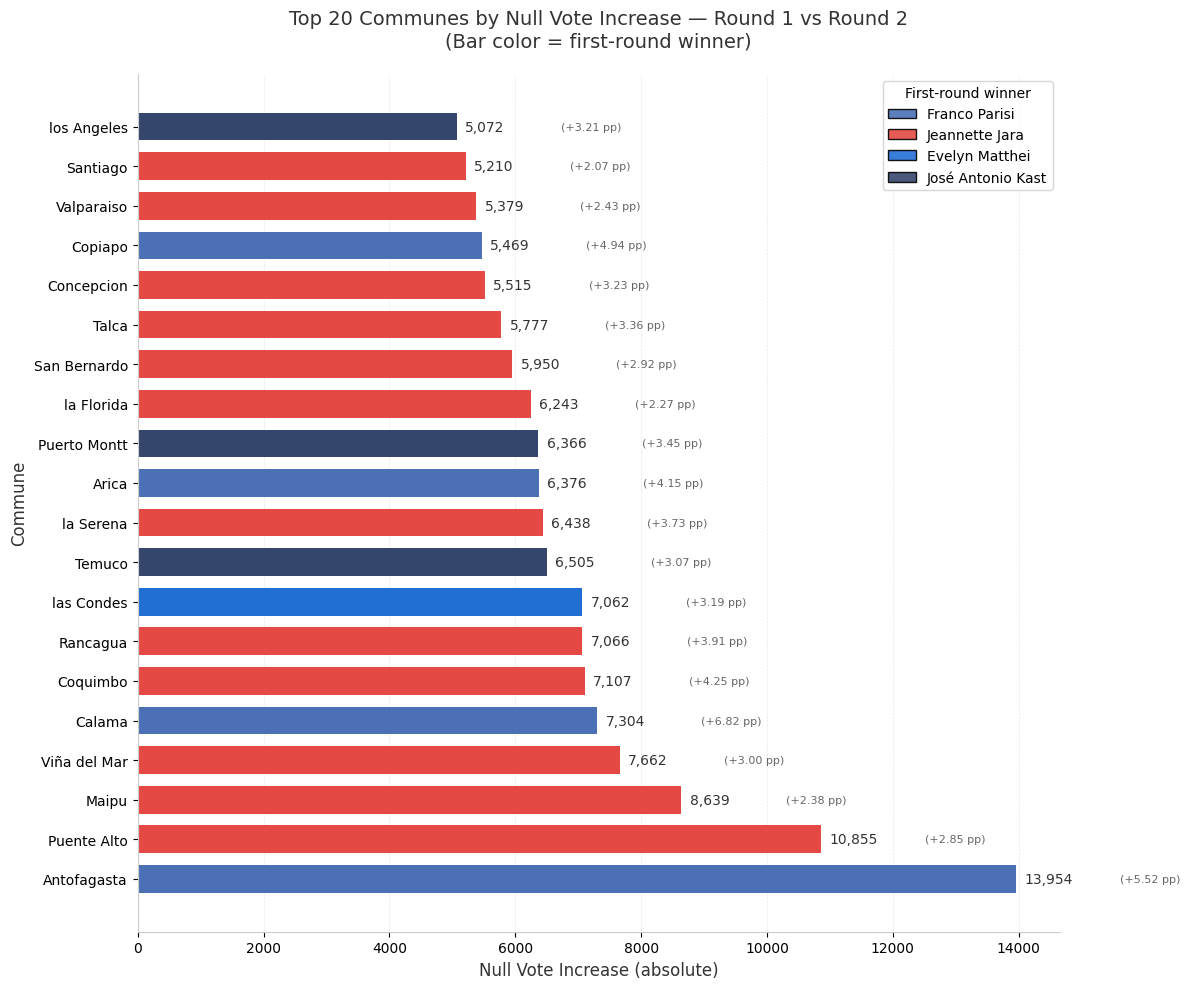

In [16]:
# ============================================================================
# BASE STYLE HELPER
# ============================================================================

def set_clean_style(ax):
    """
    Applies a minimal publication-ready style to an Axes object:
    white background, no top/right spines, muted grid on the value axis.
    """
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5, zorder=1)
    return ax


# ============================================================================
# WINNER SHORT-NAME → DISPLAY NAME MAPPING
# ============================================================================

# Maps the abbreviated winner labels produced by idxmax() to the full
# candidate display names used in the color palette (CANDIDATE_COLORS).

WINNER_NAME_MAPPING = {
    'Parisi':            'Franco Parisi',
    'Kast':              'José Antonio Kast',
    'Jara':              'Jeannette Jara',
    'Kaiser':            'Johannes Kaiser',
    'Matthei':           'Evelyn Matthei',
    'Mayne Nicholls':    'Harold Mayne-Nicholls',
    'Enríquez Ominami':  'Marco Enriquez-Ominami',
    'Artes':             'Eduardo Artes',
}


# ============================================================================
# VISUALIZATION: Top-N Communes by Null Vote Increase
# ============================================================================

def plot_top_null_increase(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest absolute increase
    in null votes between the first and second round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries two annotations:
      - Absolute null vote increase (bold, offset right of bar tip).
      - Percentage-point change in parentheses (smaller, further right).

    Legend is placed in the upper left to avoid overlap with the longest bars.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_null_increase(), containing at minimum:
        commune, null_votes_increase, null_pct_point_change, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """
    from matplotlib.patches import Patch

    plot_df = df.nlargest(top_n, 'null_votes_increase').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['null_votes_increase'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: absolute increase
    for bar, value in zip(bars, plot_df['null_votes_increase']):
        ax.annotate(
            f'{value:,.0f}',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    # Secondary annotation: pp change
    for bar, pp_value in zip(bars, plot_df['null_pct_point_change']):
        ax.annotate(
            f'(+{pp_value:.2f} pp)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(75, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=8, color='#666666', zorder=3,
        )

    ax.set_xlabel('Null Vote Increase (absolute)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Null Vote Increase — Round 1 vs Round 2\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend — upper left keeps it clear of the longest bars on the right
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(WINNER_NAME_MAPPING.get(w, 'No data'), CANDIDATE_COLORS['No data']),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()


# Execute
plot_top_null_increase(communes_null_increase, 20)

##### Hallazgo Principal

La tabla muestra las **comunas con mayor incremento absoluto** entre ambas vueltas. El aumento del voto nulo no fue uniforme: se concentró fuertemente en **comunas grandes y urbanas**, especialmente en la Región Metropolitana y el Norte.

##### Patrones Clave

1. **Dominio de la Región Metropolitana (RM)**
   - 6 de las 20 comunas más afectadas pertenecen a la RM: **Puente Alto (+10.855)**, **Maipú (+8.639)**, **Las Condes (+7.062)**, **La Florida (+6.243)**, **San Bernardo (+5.950)** y **Santiago (+5.210)**.
   - Esto indica que incluso en bastiones de Jara (Puente Alto, Maipú, La Florida), una parte importante del electorado prefirió **anular su voto** antes que elegir entre Jara y Kast.
2. **Fuerte Protesta en el Norte (Territorio Parisi)**
   - **Antofagasta** lidera con **+13.954** votos nulos (el mayor aumento del país).
   - Otras comunas nortinas destacadas: **Calama (+7.304)**, **Arica (+6.376)** y **Copiapó (+5.469)**.
   - Todas estas comunas fueron ganadas por **Franco Parisi** en primera vuelta. Esto refuerza la idea de que una parte significativa de su electorado **no se transfirió** ni a Jara ni a Kast y optó por la protesta activa.
3. **Presencia de Comunas de Distinto Perfil**
   - **Comunas populares de izquierda - Bastiones Jara** (Puente Alto, Maipú, Valparaíso, Concepción, Rancagua).
   - **Comunas de élite** (Las Condes — ganada por Matthei en 1ª vuelta).
   - **Comunas de derecha** (Temuco y Los Ángeles — ganadas por Kast).
4. **Magnitud del Aumento**
   - Varios casos superan los **+6.000 a +13.000** votos nulos adicionales.
   - El aumento en puntos porcentuales llega hasta **+6.82 pp** (Calama).

##### Interpretación Política

- **Rechazo al Duelo Final**: El aumento de nulos en comunas tan diversas (populares, elitistas, de izquierda, derecha y antisistema) muestra un **rechazo transversal** al binomio Jara-Kast. Muchos votantes no se sintieron representados por ninguna de las dos opciones.
- **Fracaso Parcial en la Transferencia de Parisi**: El Norte (bastión de Parisi) muestra algunos de los mayores aumentos de nulo. Esto sugiere que **no todo el voto antisistema** se movió hacia Kast, a pesar de que este ganó cómodamente la segunda vuelta.
- **Desmovilización en Bastiones de Jara**: Incluso en comunas donde Jara era muy fuerte (RM y Valparaíso), el voto nulo creció notablemente. Esto indica **desgaste del oficialismo** y dificultad para movilizar a su propia base en la segunda vuelta.
- **Protesta de la Derecha Fragmentada**: El caso de **Las Condes** (Matthei en primera vuelta) es sintomático: parte de la derecha tradicional prefirió anular antes que votar por Kast.

#### Analisis grafico de barras: Top 20 Comunas con mayor incremento relativo

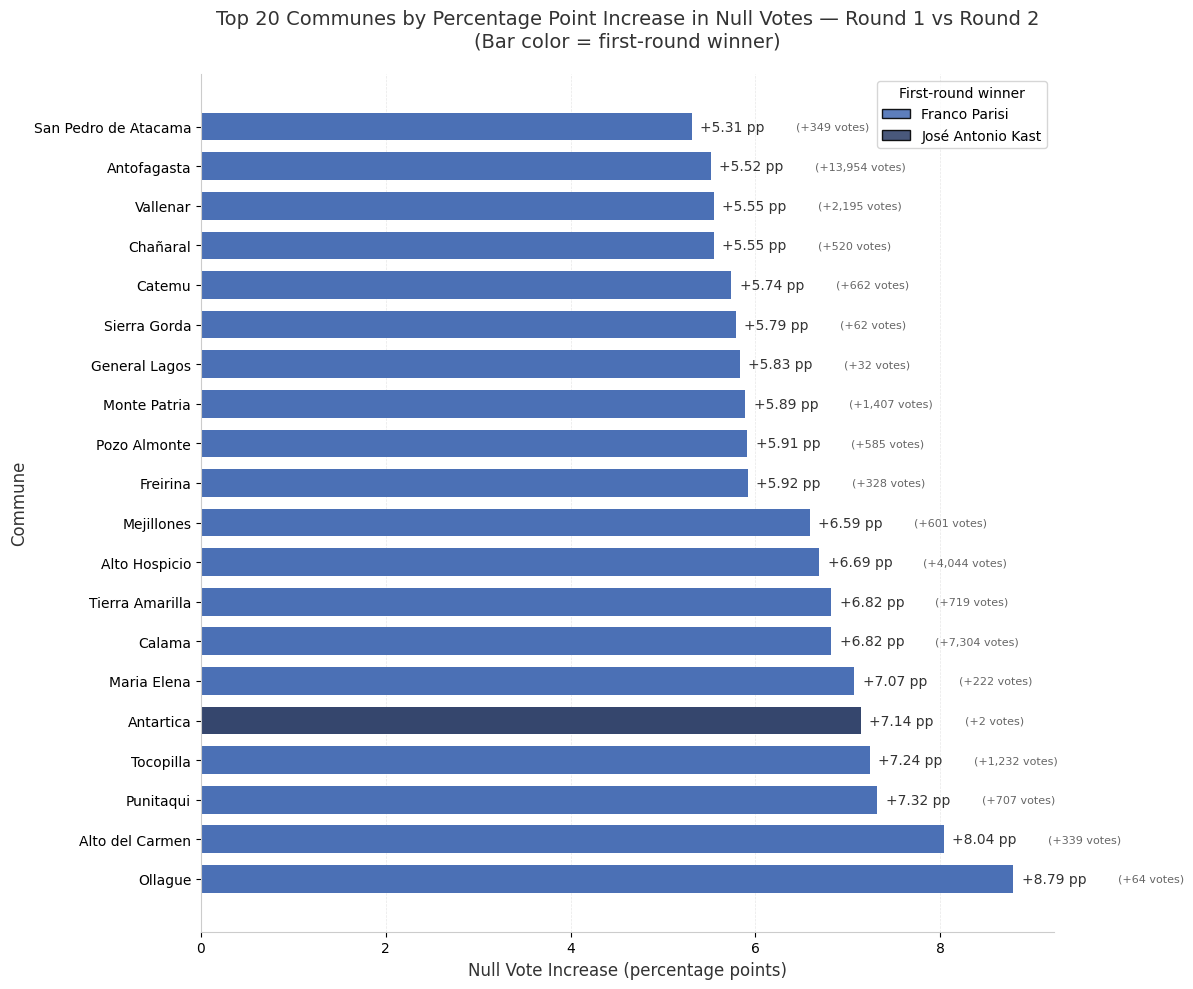

In [17]:
# ============================================================================
# VISUALIZATION: Top-N Communes by Percentage Point Increase
# ============================================================================

def plot_top_pp_increase(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest percentage point
    increase in null votes between the first and second round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries two annotations:
      - Percentage point increase (bold, offset right of bar tip).
      - Absolute null vote increase in parentheses (smaller, further right).

    Legend is placed in the lower right to avoid overlap with the bars.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_null_increase(), containing at minimum:
        commune, null_pct_point_change, null_votes_increase, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """
    from matplotlib.patches import Patch

    plot_df = df.nlargest(top_n, 'null_pct_point_change').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['null_pct_point_change'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: percentage point increase
    for bar, value in zip(bars, plot_df['null_pct_point_change']):
        ax.annotate(
            f'+{value:.2f} pp',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    # Secondary annotation: absolute increase
    for bar, abs_value in zip(bars, plot_df['null_votes_increase']):
        ax.annotate(
            f'({abs_value:+,.0f} votes)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(75, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=8, color='#666666', zorder=3,
        )

    ax.set_xlabel('Null Vote Increase (percentage points)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Percentage Point Increase in Null Votes — Round 1 vs Round 2\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend — lower right keeps it clear of the bars
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(WINNER_NAME_MAPPING.get(w, 'No data'), CANDIDATE_COLORS['No data']),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()


# Execute
plot_top_pp_increase(communes_null_increase, 20)

##### Hallazgo Principal

Mientras el gráfico anterior mostraba el **aumento absoluto** (volumen de votos), este se centra en el **aumento relativo (puntos porcentuales)**. Aquí dominan **comunas pequeñas y de baja población**, especialmente del **Norte Grande**, donde el voto nulo creció de manera más intensa en términos proporcionales.

##### Patrones Principales

1. **Dominio Absoluto del Norte (Parisi)**
   - 18 de las 20 comunas con mayor aumento en pp fueron ganadas por **Franco Parisi** en primera vuelta (barras azules).
   - Las comunas más extremas y de menor población lideran el ranking: **Ollague (+8.79 pp)**, **Alto del Carmen (+8.04 pp)**, **Puntaqui (+7.32 pp)**, **Tocopilla (+7.24 pp)**, etc.
   - Esto confirma que el **electorado antisistema de Parisi** fue el que más rechazó el duelo Jara-Kast.
2. **Comunas Pequeñas vs Grandes**
   - A diferencia del gráfico de aumento absoluto (donde dominaban comunas grandes como Antofagasta y Puente Alto), aquí prevalecen comunas pequeñas/mineras/fronterizas.
   - Ejemplos extremos: **Ollague** (+8.79 pp con solo +64 votos nulos) y **General Lagos** (+5.83 pp con solo +32 votos).
3. **Excepción Notoria**
   - **Antártica** (ganada por Kast en primera vuelta) aparece con **+7.14 pp**, pero con solo +2 votos nulos. Es un caso estadístico por su bajísima población.

##### Tabla Resumen Top 10 (Mayor Aumento en pp)

| Comuna          | Aumento pp | Votos Nulos Adicionales | Ganador 1ª Vuelta | Característica        |
| --------------- | ---------- | ----------------------- | ----------------- | --------------------- |
| Ollague         | **+8.79**  | +64                     | Parisi            | Comuna minera extrema |
| Alto del Carmen | +8.04      | +339                    | Parisi            | Rural norte           |
| Puntaqui        | +7.32      | +707                    | Parisi            | Norte Chico           |
| Tocopilla       | +7.24      | +1.232                  | Parisi            | Minera                |
| Maria Elena     | +7.07      | +222                    | Parisi            | Minera                |
| Tierra Amarilla | +6.82      | +719                    | Parisi            | Norte                 |
| Calama          | +6.82      | +7.304                  | Parisi            | Gran comuna norte     |
| Alto Hospicio   | +6.69      | +4.044                  | Parisi            | Alta densidad norte   |
| Mejillones      | +6.59      | +601                    | Parisi            | Norte                 |
| Freirina        | +5.92      | +328                    | Parisi            | Norte Chico           |

##### Interpretación Política

- **Protesta Antisistema Intensa**: El fuerte aumento relativo en bastiones de Parisi (especialmente comunas pequeñas y aisladas) indica que muchos de sus votantes **rechazaron activamente** tanto a Jara como a Kast. Prefirieron anular antes que apoyar a la derecha conservadora.
- **Diferencia Absoluto vs Relativo**:
  - **Aumento Absoluto** → Comunas grandes (Antofagasta, Puente Alto, Maipú) = impacto numérico mayor.
  - **Aumento Relativo (pp)** → Comunas pequeñas del Norte = mayor intensidad de rechazo.
- **Implicancia para Kast**: Aunque Kast ganó ampliamente la segunda vuelta, el alto voto nulo en el Norte sugiere que **no capturó todo el voto Parisi**. Una fracción importante se desmovilizó o protestó.

#### Distribución del aumento de votos nulos por ganador de la primera ronda

/tmp/ipykernel_159834/1087714213.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax.boxplot(


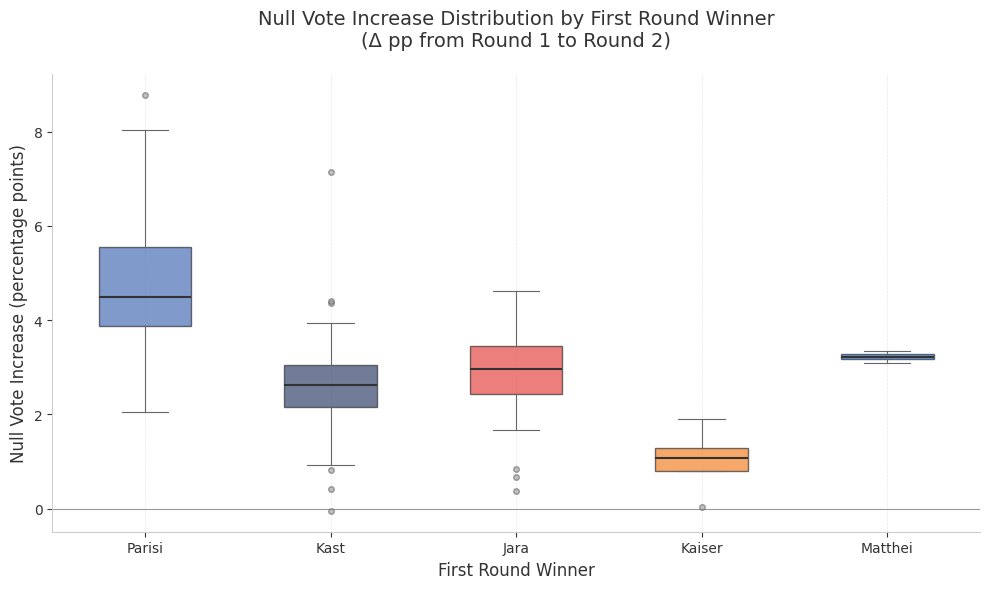

In [18]:
# ============================================================================
# VISUALIZATION: Null Vote Increase Distribution by First Round Winner
# ============================================================================

def plot_null_increase_by_winner(df: pd.DataFrame) -> None:
    """
    Box plot showing the distribution of percentage point increase in null votes,
    grouped by the winner of the first round in each commune.

    Only includes candidates with sufficient commune representation to ensure
    meaningful distributions.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_null_increase(), containing at minimum:
        commune, null_pct_point_change, first_round_winner.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Filter top winners (exclude candidates with few communes)
    top_winners = ['Parisi', 'Kast', 'Jara', 'Kaiser', 'Matthei']
    plot_df = df[df['first_round_winner'].isin(top_winners)].copy()

    # Prepare data for box plots
    box_data = [
        plot_df[plot_df['first_round_winner'] == winner]['null_pct_point_change']
        for winner in top_winners
    ]

    # Create box plot with custom styling
    boxes = ax.boxplot(
        box_data,
        labels=top_winners,
        patch_artist=True,
        medianprops={'color': '#333333', 'linewidth': 1.5},
        whiskerprops={'color': '#666666', 'linewidth': 0.8},
        capprops={'color': '#666666', 'linewidth': 0.8},
        flierprops={
            'marker': 'o',
            'markerfacecolor': '#999999',
            'markeredgecolor': '#666666',
            'markersize': 4,
            'alpha': 0.6
        }
    )

    # Color each box consistently with candidate colors
    for box, winner in zip(boxes['boxes'], top_winners):
        full_name = WINNER_NAME_MAPPING.get(winner, winner)
        color = CANDIDATE_COLORS.get(full_name, CANDIDATE_COLORS.get('No data', '#dddddd'))
        box.set_facecolor(color)
        box.set_alpha(0.7)
        box.set_edgecolor('#333333')
        box.set_linewidth(1)

    # Add horizontal line at zero
    ax.axhline(y=0, color='#333333', linestyle='-', linewidth=0.8, alpha=0.5, zorder=1)

    # Labels and title
    ax.set_xlabel('First Round Winner', fontsize=12, color='#333333')
    ax.set_ylabel('Null Vote Increase (percentage points)', fontsize=12, color='#333333')
    ax.set_title(
        'Null Vote Increase Distribution by First Round Winner\n'
        '(Δ pp from Round 1 to Round 2)',
        fontsize=14, pad=20, color='#333333'
    )

    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)

    plt.tight_layout()
    plt.show()


# Execute
plot_null_increase_by_winner(communes_null_increase)

#####  Hallazgo Principal

El gráfico revela una **diferencia clara y significativa** en el comportamiento del voto nulo según el candidato que ganó la comuna en primera vuelta. **Los votantes de Franco Parisi** fueron los que más aumentaron su voto nulo en segunda vuelta, tanto en mediana como en dispersión.

#####  Interpretación por Candidato

| Ganador 1ª Vuelta | Mediana Aumento (pp) | Rango Típico    | Variabilidad | Interpretación                            |
| ----------------- | -------------------- | --------------- | ------------ | ----------------------------------------- |
| **Parisi**        | **~4.5 pp**          | 2.0 – 8.0+      | **Muy Alta** | Mayor rechazo al duelo Jara-Kast          |
| **Jara**          | ~3.0 pp              | 2.0 – 4.5       | Media        | Desmovilización en bastiones de izquierda |
| **Kast**          | ~2.7 pp              | 1.0 – 4.0       | Media-Alta   | Consolidación moderada de su electorado   |
| **Matthei**       | ~3.3 pp              | Muy concentrado | **Baja**     | Derecha tradicional más disciplinada      |
| **Kaiser**        | **~1.2 pp**          | 0.5 – 2.0       | **Muy Baja** | Mejor transferencia hacia Kast            |

#####  Conclusiones Estratégicas

1. **Parisi = Principal Fuente de Protesta** Las comunas donde Parisi ganó en primera vuelta muestran el **mayor y más disperso aumento** de voto nulo. Esto confirma que una parte importante de su electorado **antisistema** rechazó tanto a Jara como a Kast. Muchos optaron por la abstención activa (nulo) en lugar de transferir su voto.
2. **Jara sufrió Desmovilización** Sus comunas tienen un aumento medio-alto de nulo (mediana ~3 pp). Aunque menor que en las de Parisi, indica que parte de su base de izquierda no estuvo motivada para votar por ella en segunda vuelta.
3. **Kast logró Mejor Consolidación** Sus comunas muestran un aumento más moderado y controlado. Esto sugiere que su electorado fue más leal y disciplinado.
4. **Derecha Fragmentada**
   - **Matthei**: Sus votantes fueron bastante disciplinados (distribución muy estrecha).
   - **Kaiser**: Tuvo la menor protesta, lo que indica una **excelente transferencia** hacia Kast.

#### Conclusión
El análisis de las comunas con mayor aumento de voto nulo revela un mapa dual del descontento electoral. En el Norte Grande, el fenómeno fue principalmente una expresión de protesta antisistema impulsada por la decisión del Partido de la Gente de llamar a votar nulo, que afectó con especial intensidad a las comunas mineras donde el apoyo a Franco Parisi era más sólido. En las grandes ciudades, por el contrario, el voto nulo operó como un termómetro de desmovilización del electorado de Jeannette Jara —incluso en sus bastiones tradicionales—, reflejando el desgaste del oficialismo y su dificultad para movilizar a su propia base en la instancia definitoria. Esta dualidad sugiere que el voto nulo no fue un fenómeno homogéneo, sino que canalizó distintos tipos de descontento: protesta activa en el norte, desmovilización y desencanto en las ciudades. Ambas expresiones, sin embargo, comparten un denominador común: la desconfianza hacia el sistema político tradicional y el rechazo a una oferta bipolar que no logró interpelar a una fracción significativa del electorado. El desafío para el nuevo gobierno será, por tanto, no solo gobernar para la mayoría que lo respaldó, sino también reconectar con un electorado que, especialmente en el norte del país, ha optado por la protesta activa como forma de expresión política.

---


## 5. Analisis votos blancos

### 5.1. Analisis votos blancos por region

A diferencia del voto nulo, que registró un aumento generalizado y pronunciado en todas las regiones, el voto en blanco mostró un crecimiento más moderado y territorialmente heterogéneo durante la segunda vuelta presidencial de 2025. Mientras el voto nulo refleja una protesta activa y confrontacional —frecuentemente asociada al rechazo explícito al sistema político—, el voto en blanco suele interpretarse como una forma de descontento más pasiva, una suerte de "ninguna opción me representa" que no implica necesariamente un rechazo militante al proceso electoral . La distribución regional de este fenómeno confirma que, si bien ambas formas de invalidación del sufragio crecieron respecto de la primera vuelta, su comportamiento territorial fue cualitativamente distinto, sugiriendo que los votantes canalizaron su descontento a través de mecanismos diferenciados según la zona del país.

In [19]:
# ============================================================================
# REGIONS WITH BLANK VOTE COMPARISON
# ============================================================================

def analyze_blank_votes_by_region(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates blank vote metrics by region and compares first vs second round.
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: region, commune, blank_votes, casted_votes
    df2 : pd.DataFrame
        Second round data with columns: region, commune, blank_votes, casted_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with region-level blank vote statistics and trend
    """
    # Aggregate first round by region
    first_round_agg = df1.groupby('region').agg({
        'blank_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    first_round_agg.columns = ['region', 'blank_votes_first_round', 'total_votes_first_round']
    first_round_agg['blank_pct_first_round'] = round(
        100.0 * first_round_agg['blank_votes_first_round'] / first_round_agg['total_votes_first_round'], 2
    )
    
    # Aggregate second round by region
    second_round_agg = df2.groupby('region').agg({
        'blank_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    second_round_agg.columns = ['region', 'blank_votes_second_round', 'total_votes_second_round']
    second_round_agg['blank_pct_second_round'] = round(
        100.0 * second_round_agg['blank_votes_second_round'] / second_round_agg['total_votes_second_round'], 2
    )
    
    # Merge both rounds
    result = pd.merge(first_round_agg, second_round_agg, on='region', how='inner')
    
    # Calculate changes
    result['blank_votes_change'] = result['blank_votes_second_round'] - result['blank_votes_first_round']
    result['blank_pct_point_change'] = round(
        result['blank_pct_second_round'] - result['blank_pct_first_round'], 2
    )
    
    # Add trend column
    result['trend'] = result['blank_votes_change'].apply(
        lambda x: 'INCREASE' if x > 0 else ('DECREASE' if x < 0 else 'NO CHANGE')
    )
    
    # Sort by absolute change descending
    result = result.sort_values('blank_votes_change', ascending=False)
    
    # Format columns
    result['blank_votes_first_round'] = result['blank_votes_first_round'].astype(int)
    result['blank_votes_second_round'] = result['blank_votes_second_round'].astype(int)
    result['blank_votes_change'] = result['blank_votes_change'].astype(int)
    
    # Select and order columns
    result = result[[
        'region',
        'blank_votes_first_round',
        'blank_votes_second_round',
        'blank_votes_change',
        'blank_pct_first_round',
        'blank_pct_second_round',
        'blank_pct_point_change',
        'trend'
    ]]
    
    return result


# Execute analysis
blank_votes_by_region = analyze_blank_votes_by_region(df_2025_v1, df_2025_v2)
blank_votes_by_region

,region,blank_votes_first_round,blank_votes_second_round,blank_votes_change,blank_pct_first_round,blank_pct_second_round,blank_pct_point_change,trend
12,Metropolitana,46698,62372,15674,0.90,1.21,0.31,INCREASE
4,Biobío,12093,15359,3266,0.99,1.26,0.27,INCREASE
14,Valparaíso,16576,18973,2397,1.14,1.31,0.17,INCREASE
0,Antofagasta,4567,5853,1286,1.11,1.44,0.33,INCREASE
7,Libertador,8403,9565,1162,1.11,1.26,0.15,INCREASE
5,Coquimbo,8150,8811,661,1.39,1.51,0.12,INCREASE
9,Los Ríos,3334,3745,411,1.06,1.20,0.14,INCREASE
2,Atacama,2749,3080,331,1.31,1.47,0.16,INCREASE
13,Tarapacá,2179,2494,315,1.02,1.18,0.16,INCREASE
1,Arica y Parinacota,1731,1871,140,1.10,1.19,0.09,INCREASE


#### Análisis

##### Comportamiento Heterogéneo por Región

El voto en blanco aumentó en 11 de las 16 regiones del país, pero lo hizo de manera mucho más moderada que el voto nulo: los incrementos en puntos porcentuales oscilaron entre +0,09 pp en Arica y Parinacota y +0,33 pp en Antofagasta, muy lejos de los aumentos de entre +2,07 pp y +5,96 pp observados para el voto nulo. La Región Metropolitana lideró el aumento en términos absolutos (+15.674 votos, +0,31 pp), seguida por Biobío (+3.266, +0,27 pp) y Valparaíso (+2.397, +0,17 pp). Este patrón confirma que el voto en blanco —a diferencia del nulo, que tuvo su epicentro en el Norte— se concentró predominantemente en zonas urbanas y densamente pobladas, donde el electorado optó por una forma de protesta menos radicalizada .

El hallazgo más relevante del análisis regional, sin embargo, es la disminución del voto en blanco en 5 regiones del centro-sur: Maule (-1.308 votos, -0,15 pp), La Araucanía (-504, -0,06 pp), Ñuble (-409, -0,09 pp), Los Lagos (-295, -0,04 pp) y Aysén (-202, -0,28 pp). Este comportamiento contrasta frontalmente con el del voto nulo, que aumentó en todas estas regiones. La explicación más plausible es que, en estas zonas, los votantes que deseaban manifestar su descontento con el duelo Jara-Kast canalizaron su rechazo preferentemente a través del voto nulo —una forma de protesta más activa y visible— en lugar del voto en blanco, que podría percibirse como una opción más ambigua o menos contundente .

##### Interpretación del Voto en Blanco

La distinción entre voto nulo y voto en blanco tiene implicancias políticas relevantes. Como señala la normativa electoral chilena, ambos tipos de sufragio se consideran invalidados y no inciden en el resultado final, ya que los porcentajes de votación se calculan sobre el total de votos válidos, excluyendo nulos y blancos . Sin embargo, su significado simbólico es distinto: el voto en blanco suele interpretarse como una expresión de descontento con la oferta electoral disponible, pero no necesariamente como un rechazo al sistema político en su conjunto .

El hecho de que el voto en blanco haya aumentado predominantemente en las regiones urbanas —especialmente la Región Metropolitana— sugiere que en estas zonas el descontento se expresó de manera más institucional o pasiva. Esto podría deberse a que el electorado urbano, tradicionalmente más informado y con mayor acceso a medios de comunicación, tiende a utilizar el voto en blanco como una forma de protesta "legítima" que no implica un rechazo total al proceso electoral. Por el contrario, en las regiones del centro-sur donde el voto en blanco disminuyó, el descontento se canalizó hacia el nulo, una opción que podría interpretarse como más radical o confrontacional .

##### El Caso de Antofagasta y el Norte

Antofagasta destaca como la región con el mayor aumento relativo de voto en blanco (+0,33 pp), alcanzando un 1,44% de votos en blanco en segunda vuelta. Si bien este incremento es moderado en términos absolutos, se inscribe en un patrón más amplio: el Norte Grande no solo lideró el aumento del voto nulo, sino que también registró los mayores porcentajes de votos no válidos en su conjunto. Según datos del Servicio Electoral, Antofagasta alcanzó un 10,5% de votos nulos y blancos combinados, seguida por Atacama (9,5%), Coquimbo (8,8%), Arica y Parinacota (8,5%) y Tarapacá (8,2%) . Este comportamiento refuerza la hipótesis de que el electorado del Norte —donde el apoyo a Franco Parisi fue más sólido en primera vuelta— optó masivamente por la invalidación del sufragio como forma de protesta, ya sea a través del nulo o, en menor medida, del blanco .

A nivel nacional, los votos nulos y blancos alcanzaron un 7,1% del total en la segunda vuelta, una cifra que, aunque inferior a las proyecciones iniciales —que estimaban que podrían ubicarse entre el 12% y el 18%—, constituye la más alta registrada en una elección presidencial en los últimos 35 años, superando el 5,53% observado en los comicios de 1993 . Este dato es particularmente relevante si se considera que en 2021, bajo el régimen de voto voluntario, los votos nulos y blancos en segunda vuelta apenas alcanzaron el 1,1% . El salto de 1,1% a 7,1% en cuatro años evidencia el impacto del voto obligatorio y el creciente descontento ciudadano con el sistema político tradicional.

#### Conclusión
El voto en blanco en la segunda vuelta de 2025 se comportó como un fenómeno territorialmente heterogéneo que complementa —y en algunos casos contrasta— con el patrón observado para el voto nulo. Mientras el nulo aumentó en todas las regiones, el blanco creció moderadamente en 11 regiones y disminuyó en 5 del centro-sur, donde el descontento se canalizó preferentemente hacia el nulo. Esta dualidad sugiere que los votantes utilizan distintas formas de invalidación del sufragio según su percepción del sistema político y su disposición a la protesta activa: el voto en blanco como expresión de descontento pasivo en zonas urbanas, el nulo como rechazo más confrontacional en territorios donde la desconfianza hacia el sistema es más profunda. En conjunto, el aumento de ambos tipos de votos no válidos —que pasaron de representar el 3,7% en primera vuelta al 7,1% en segunda— confirma que una fracción relevante del electorado chileno no encontró representación en el duelo Jara-Kast. Este fenómeno, que afecta especialmente a las regiones del norte y a los votantes más jóvenes, plantea un desafío estructural para la legitimidad del sistema político y la capacidad de los partidos para reconectar con un electorado crecientemente descontento .


### 5.2. Votos en blanco por zona geográfica:

El voto en blanco en la segunda vuelta de 2025 mostró un comportamiento moderado pero geográficamente heterogéneo que contrasta significativamente con el patrón observado para el voto nulo. Mientras el nulo aumentó de manera generalizada en todas las macrozonas, el blanco creció en cinco de las seis zonas geográficas, pero lo hizo con intensidades muy dispares —desde +0,23 pp en el Norte Grande hasta apenas +0,01 pp en la zona Sur— e incluso registró una leve disminución en la Patagonia (-0,03 pp). Este comportamiento diferencial sugiere que el voto en blanco operó como un canal de descontento más pasivo, concentrado predominantemente en las zonas urbanas, mientras que en regiones del centro-sur los votantes canalizaron su rechazo preferentemente a través del voto nulo como mecanismo de protesta activa.

In [20]:
# ============================================================================
# BLANK VOTE CHANGE BY GEOGRAPHIC ZONE
# ============================================================================

def analyze_blank_votes_by_zone(df1: pd.DataFrame, df2: pd.DataFrame, df_zone: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates blank vote metrics by geographic zone (Norte Grande, Centro, Sur, etc.)
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: region, blank_votes, casted_votes
    df2 : pd.DataFrame
        Second round data with columns: region, blank_votes, casted_votes
    df_zone : pd.DataFrame
        Region dimension with columns: region, macrozone, macrozone_order
    
    Returns
    -------
    pd.DataFrame
        DataFrame with zone-level blank vote statistics
    """
    # Merge region dimension to first round
    df1_with_zone = df1.merge(df_zone[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
    
    # Merge region dimension to second round
    df2_with_zone = df2.merge(df_zone[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
    
    # Aggregate first round by zone
    first_zone_agg = df1_with_zone.groupby('macrozone').agg({
        'blank_votes': 'sum',
        'casted_votes': 'sum',
        'macrozone_order': 'first'
    }).reset_index()
    first_zone_agg.columns = ['macrozone', 'blank_votes_first_round', 'total_votes_first_round', 'macrozone_order']
    first_zone_agg['blank_pct_first_round'] = round(
        100.0 * first_zone_agg['blank_votes_first_round'] / first_zone_agg['total_votes_first_round'], 2
    )
    
    # Aggregate second round by zone
    second_zone_agg = df2_with_zone.groupby('macrozone').agg({
        'blank_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    second_zone_agg.columns = ['macrozone', 'blank_votes_second_round', 'total_votes_second_round']
    second_zone_agg['blank_pct_second_round'] = round(
        100.0 * second_zone_agg['blank_votes_second_round'] / second_zone_agg['total_votes_second_round'], 2
    )
    
    # Merge both rounds
    result = pd.merge(first_zone_agg, second_zone_agg, on='macrozone', how='inner')
    
    # Calculate changes
    result['blank_votes_change'] = result['blank_votes_second_round'] - result['blank_votes_first_round']
    result['blank_pct_point_change'] = round(
        result['blank_pct_second_round'] - result['blank_pct_first_round'], 2
    )
    
    # Sort by macrozone order (north to south)
    result = result.sort_values('macrozone_order')
    
    # Select and order columns
    result = result[[
        'macrozone',
        'blank_votes_first_round',
        'blank_votes_second_round',
        'blank_votes_change',
        'blank_pct_first_round',
        'blank_pct_second_round',
        'blank_pct_point_change'
    ]]
    
    return result


# Execute analysis by zone
blank_votes_by_zone = analyze_blank_votes_by_zone(df_2025_v1, df_2025_v2, df_region_dim)
blank_votes_by_zone

,macrozone,blank_votes_first_round,blank_votes_second_round,blank_votes_change,blank_pct_first_round,blank_pct_second_round,blank_pct_point_change
3,Norte Grande,8477,10218,1741,1.09,1.32,0.23
2,Norte Chico,10899,11891,992,1.37,1.50,0.13
0,Centro,81626,99551,17925,0.99,1.21,0.22
1,Centro Sur,25430,27783,2353,1.06,1.16,0.10
5,Sur,12606,12722,116,1.28,1.29,0.01
4,Patagonia,2918,2838,-80,1.49,1.46,-0.03


#### Análisis

##### Patrón de Distribución Macrozonal

El análisis macrozonal revela que el voto en blanco creció en todas las zonas con excepción de la Patagonia, pero con una intensidad marcadamente inferior a la observada para el voto nulo. El **Norte Grande** lideró el aumento relativo con +0,23 puntos porcentuales, alcanzando un 1,32% de votos en blanco en segunda vuelta, seguido del **Centro** con +0,22 pp (1,21%) y el **Norte Chico** con +0,13 pp (1,50%).

El **Centro Sur** (+0,10 pp) y el **Sur** (+0,01 pp) registraron los incrementos más moderados, mientras que la **Patagonia** experimentó una disminución de -0,03 pp, pasando de 1,49% a 1,46% de votos en blanco. Este comportamiento —que contrasta con el voto nulo, que aumentó en todas las macrozonas sin excepción— sugiere que en ciertos territorios del sur del país los votantes prefirieron canalizar su descontento a través del voto nulo en lugar del blanco, probablemente por considerar que este último constituye una forma de protesta menos visible o contundente.

##### Comparación entre Voto Nulo y Voto en Blanco

La magnitud diferencial entre ambos tipos de invalidación del sufragio es el hallazgo más elocuente del análisis macrozonal. Mientras el voto nulo aumentó en promedio +3,4 puntos porcentuales en todas las zonas —con picos de +5,22 pp en el Norte Grande—, el voto en blanco apenas superó el +0,20 pp en la misma zona. Esta disparidad confirma que los votantes descontentos con el duelo Jara-Kast optaron mayoritariamente por formas de protesta más radicales y visibles que la mera omisión de preferencia.

El significado simbólico de esta diferencia es relevante desde una perspectiva política. El voto nulo, que ocurre cuando el elector marca más de una preferencia o la intención de voto no resulta clara, suele interpretarse como una expresión de rechazo más activo al sistema político y a las opciones ofrecidas, mientras que el voto en blanco, que se produce cuando la cédula no contiene ninguna marca que indique preferencia electoral, es considerado una forma de descontento más pasiva.

Esta distinción es particularmente relevante para interpretar el comportamiento de las zonas del Norte Grande y el Centro. En el Norte, donde la protesta fue más intensa y la decisión del Partido de la Gente de llamar a votar nulo tuvo mayor impacto, el voto en blanco también mostró un incremento más pronunciado (+0,23 pp), sugiriendo que una fracción del electorado parisista optó por la protesta pasiva en lugar de la activa. En el Centro, donde el voto nulo fue más moderado en términos relativos, el voto en blanco también creció de manera significativa (+0,22 pp), reflejando un descontento más institucionalizado en las zonas urbanas.

##### El Caso de la Patagonia y la Migración al Voto Nulo

La disminución del voto en blanco en la Patagonia (-0,03 pp) constituye una anomalía que merece atención. Esta zona, que registró el mayor porcentaje de votos en blanco en primera vuelta (1,49%), experimentó una caída en segunda vuelta, mientras que el voto nulo aumentó en +2,77 pp. Este comportamiento sugiere que, en la Patagonia, los votantes que inicialmente manifestaron su descontento a través del voto en blanco migraron hacia el voto nulo en la instancia definitoria, probablemente como una forma de protesta más contundente contra un balotaje que no logró interpelarlos.

Este fenómeno de "migración" desde el voto blanco hacia el nulo no fue exclusivo de la Patagonia. Como se documentó en el análisis regional, cinco regiones del centro-sur —Maule, La Araucanía, Ñuble, Los Lagos y Aysén— registraron disminuciones en el voto en blanco mientras el nulo aumentaba significativamente. Este patrón sugiere que los votantes del sur y la Patagonia, enfrentados a una oferta bipolar insatisfactoria, optaron por formas de protesta más activas y visibles que la omisión simple de preferencia.

##### Contexto Nacional y Significado Político

A nivel nacional, los votos nulos y blancos alcanzaron el 7,1% de la votación total en segunda vuelta, una cifra que, aunque inferior a las proyecciones iniciales del Partido de la Gente, constituye la más alta registrada en una elección presidencial en los últimos 35 años.

La magnitud de este fenómeno adquiere mayor relevancia al compararlo con elecciones anteriores: en la segunda vuelta de 2021, bajo el régimen de voto voluntario, los votos nulos y blancos apenas alcanzaron el 1,1% del total. El salto a un 7,1% en 2025 —en un contexto de voto obligatorio— evidencia el impacto del cambio normativo y el creciente descontento ciudadano con el sistema político tradicional. Como señaló el presidente del Servel, Andrés Tagle, "el voto nulo no se considera para nada, lo mismo que el voto en blanco. No tiene ningún efecto en términos de los cargos que se están eligiendo", lo que subraya el carácter simbólico de estas formas de invalidación del sufragio.

El hecho de que el voto en blanco haya aumentado predominantemente en las zonas urbanas —Centro y Norte Grande— mientras disminuía en el sur sugiere que el descontento ciudadano se expresa de manera territorialmente diferenciada. En los grandes centros urbanos, donde el acceso a información y la institucionalidad política son más densos, los votantes optaron por una forma de protesta más "institucional" o pasiva. En el sur y la Patagonia, por el contrario, el descontento se canalizó hacia el nulo, una opción que podría interpretarse como más radical o confrontacional.


#### Conclusión
El voto en blanco en la segunda vuelta de 2025 se comportó como un fenómeno territorialmente diferenciado que complementa —y en algunos casos contrasta— con el patrón observado para el voto nulo. Mientras el nulo aumentó en todas las macrozonas de manera pronunciada, el blanco creció moderadamente en cinco zonas y disminuyó en la Patagonia, donde los votantes optaron preferentemente por la protesta activa. Esta dualidad sugiere que los votantes utilizan distintas formas de invalidación del sufragio según su percepción del sistema político y su disposición a la protesta: el voto en blanco como expresión de descontento pasivo en zonas urbanas, el nulo como rechazo más confrontacional en territorios donde la desconfianza hacia el sistema es más profunda. En conjunto, el aumento de ambos tipos de votos no válidos confirma que una fracción relevante del electorado chileno no encontró representación en el duelo Jara-Kast, planteando un desafío estructural para la legitimidad del sistema político y la capacidad de los partidos para reconectar con un electorado crecientemente descontento.

### 5.3. Analisis votos blancos por Ciudades (Top 20)

El análisis de las comunas con mayor aumento de voto en blanco revela un patrón que contrasta significativamente con el observado para el voto nulo. Mientras el nulo tuvo su epicentro en el Norte minero y en comunas populares —territorios donde el electorado de Franco Parisi optó por la protesta activa—, el voto en blanco se concentró mayoritariamente en la Región Metropolitana, especialmente en comunas de alto y medio-alto nivel socioeconómico, con un claro protagonismo de los bastiones de Evelyn Matthei. Este comportamiento sugiere que el voto en blanco operó como un canal de descontento más pasivo y "elitista", utilizado por sectores de la derecha tradicional que, sin sentirse representados por José Antonio Kast, optaron por la invalidación del sufragio en lugar de respaldar al candidato republicano o migrar hacia la opción oficialista.

In [21]:
# ============================================================================
# COMMUNES WITH HIGHEST BLANK VOTE INCREASE
# ============================================================================

def analyze_communes_blank_increase(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies communes with largest absolute and percentage increase in blank votes.
    Includes first round winner and vote metrics.
    """
    
    # Define candidate columns for first round
    candidate_cols = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes', 
                      'matthei_votes', 'mayne_nicholls_votes', 'enriquez_ominami_votes', 
                      'artes_votes']
    candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei', 
                       'Mayne Nicholls', 'Enríquez Ominami', 'Artes']
    
    # Calculate first round winner for each commune
    df1_winner = df1.copy()
    
    # Find the candidate with most votes
    df1_winner['first_round_winner'] = df1_winner[candidate_cols].idxmax(axis=1)
    
    # Map column names to candidate names
    winner_mapping = dict(zip(candidate_cols, candidate_names))
    df1_winner['first_round_winner'] = df1_winner['first_round_winner'].map(winner_mapping)
    
    # Calculate first round valid votes (total - null - blank)
    df1_winner['valid_votes_first_round'] = (
        df1_winner['casted_votes'] - df1_winner['null_votes'] - df1_winner['blank_votes']
    )
    
    # Rename columns in df1_winner to avoid conflicts
    df1_winner = df1_winner.rename(columns={
        'null_votes': 'null_votes_1v',
        'blank_votes': 'blank_votes_1v',
        'casted_votes': 'casted_votes_1v'
    })
    
    # Rename columns in df2
    df2_renamed = df2.rename(columns={
        'null_votes': 'null_votes_2v',
        'blank_votes': 'blank_votes_2v',
        'casted_votes': 'casted_votes_2v'
    })
    
    # Merge with second round data
    result = df1_winner.merge(
        df2_renamed[['commune', 'region', 'null_votes_2v', 'blank_votes_2v', 'casted_votes_2v']], 
        on=['commune', 'region'], 
        how='inner'
    )
    
    # Calculate metrics
    result['blank_votes_increase'] = result['blank_votes_2v'] - result['blank_votes_1v']
    result['blank_pct_1v'] = round(100.0 * result['blank_votes_1v'] / result['casted_votes_1v'], 2)
    result['blank_pct_2v'] = round(100.0 * result['blank_votes_2v'] / result['casted_votes_2v'], 2)
    result['blank_pct_point_change'] = round(result['blank_pct_2v'] - result['blank_pct_1v'], 2)
    result['valid_votes_1v'] = result['valid_votes_first_round']
    result['valid_votes_2v'] = result['casted_votes_2v'] - result['null_votes_2v'] - result['blank_votes_2v']
    
    # Select relevant columns
    result = result[[
        'commune', 'region',
        'valid_votes_1v', 'valid_votes_2v',
        'blank_votes_1v', 'blank_votes_2v', 'blank_votes_increase',
        'blank_pct_1v', 'blank_pct_2v', 'blank_pct_point_change',
        'first_round_winner'
    ]]
    
    return result


# Execute analysis
communes_blank_increase = analyze_communes_blank_increase(df_2025_v1, df_2025_v2)

# Show top 20 communes with highest blank vote increase
top_20_blank_increase = communes_blank_increase.nlargest(20, 'blank_votes_increase')
top_20_blank_increase

,commune,region,valid_votes_1v,valid_votes_2v,blank_votes_1v,blank_votes_2v,blank_votes_increase,blank_pct_1v,blank_pct_2v,blank_pct_point_change,first_round_winner
278,las Condes,Metropolitana,218939,208531,1004,3405,2401,0.45,1.54,1.09,Matthei
256,Providencia,Metropolitana,121106,114679,715,2690,1975,0.58,2.18,1.60,Matthei
279,ÑUñoa,Metropolitana,178903,171731,1136,3100,1964,0.62,1.70,1.08,Jara
247,Maipu,Metropolitana,350723,340831,2811,4105,1294,0.77,1.13,0.36,Jara
274,la Florida,Metropolitana,266625,258879,2316,3394,1078,0.84,1.23,0.39,Jara
277,la Reina,Metropolitana,73846,70473,521,1467,946,0.69,1.94,1.25,Matthei
269,Santiago,Metropolitana,244922,238328,2341,3278,937,0.93,1.30,0.37,Jara
38,Concepcion,Biobío,165767,158957,1363,2248,885,0.80,1.32,0.52,Jara
0,Antofagasta,Antofagasta,244833,227874,3014,3884,870,1.18,1.53,0.35,Parisi
272,Vitacura,Metropolitana,69419,66462,258,1069,811,0.37,1.52,1.15,Matthei


#### Análisis

##### Concentración en la Región Metropolitana y el Electorado de Matthei

El dato más elocuente del análisis comunal es la sobrerrepresentación de la Región Metropolitana en el ranking de aumento absoluto de votos en blanco. Ocho de las quince comunas con mayor incremento pertenecen a la RM, y entre ellas destacan nítidamente los bastiones de Evelyn Matthei: Las Condes (+2.401 votos en blanco, +1,09 pp), Providencia (+1.975, +1,60 pp), La Reina (+946, +1,25 pp) y Vitacura (+811, +1,15 pp). Estas comunas, que en primera vuelta fueron ganadas por Matthei —quien compitió en la primaria de Chile Vamos y obtuvo un respaldo significativo en los sectores de mayores ingresos del país— registraron los mayores incrementos relativos de voto en blanco, muy por encima del promedio nacional.

Este fenómeno es particularmente relevante desde una perspectiva estratégica. La derecha tradicional, representada por Matthei y Chile Vamos, enfrentó un dilema en la segunda vuelta: respaldar a Kast, un candidato del Partido Republicano con el que no compartían necesariamente afinidad ideológica, o abstenerse de respaldarlo activamente. La evidencia sugiere que una fracción significativa del electorado de Matthei —especialmente en las comunas de mayores ingresos— optó por el voto en blanco como forma de protesta pasiva, antes que validar la candidatura de Kast.

##### El Voto en Blanco como Expresión de Descontento en Bastiones de Jara

El voto en blanco no fue, sin embargo, un fenómeno exclusivo de la derecha tradicional. Comunas como Ñuñoa (+1.964 votos, +1,08 pp), Maipú (+1.294, +0,36 pp) y La Florida (+1.078, +0,39 pp), todas ellas ganadas por Jara en primera vuelta, también registraron incrementos significativos de voto en blanco. En estos casos, el fenómeno refleja un descontento más pasivo dentro del propio electorado oficialista, que optó por la invalidación del sufragio antes que ratificar a su candidata.

El caso de Ñuñoa es especialmente ilustrativo: esta comuna, tradicionalmente de centroizquierda y con un electorado joven y educado, registró el tercer mayor aumento absoluto de voto en blanco (+1.964) y un incremento relativo de +1,08 pp, muy superior al promedio nacional. Este comportamiento sugiere que, incluso en bastiones del oficialismo, una fracción del electorado —probablemente descontenta con la gestión del gobierno de Boric o con la candidatura de Jara— optó por la protesta pasiva antes que por el voto útil.

##### Contraste con el Voto Nulo: Dos Tipologías de Protesta

La comparación entre los patrones del voto nulo y el voto en blanco permite identificar dos tipologías diferenciadas de protesta electoral. Mientras el voto nulo se concentró en el Norte minero —territorios donde el apoyo a Franco Parisi fue más sólido en primera vuelta— y en comunas populares de la RM, el voto en blanco tuvo un carácter más elitista y urbano, concentrándose en el oriente de Santiago y en comunas de mayor nivel socioeconómico.

Esta dualidad sugiere que los votantes utilizan distintas formas de invalidación del sufragio según su perfil sociodemográfico y su relación con el sistema político. El electorado de Parisi —predominantemente masculino, menor de 45 años y de clase media, con alta desconfianza hacia las instituciones tradicionales y una presencia significativa en las provincias mineras del norte— optó mayoritariamente por el voto nulo como expresión de protesta activa y confrontacional. Por el contrario, el electorado de Matthei —de mayores ingresos, más educado y con una relación más institucional con el sistema político— utilizó el voto en blanco como una forma de descontento más pasiva y menos radical.

##### Implicancias Políticas

El aumento del voto en blanco en los bastiones de Matthei tiene implicancias políticas relevantes para el nuevo gobierno. El hecho de que sectores de la derecha tradicional hayan optado por la invalidación del sufragio antes que por el respaldo a Kast sugiere que el triunfo del candidato republicano, aunque contundente en términos de votos válidos, no logró articular plenamente al electorado de centro-derecha. Esta fractura interna podría traducirse en desafíos de gobernabilidad en el futuro, especialmente si Kast requiere de apoyo parlamentario de Chile Vamos para aprobar reformas.

La decisión del Partido de la Gente de llamar a votar nulo o blanco en la segunda vuelta, respaldada por el 78% de sus militantes en una consulta interna, probablemente afectó también el comportamiento del voto en blanco en algunas comunas. Sin embargo, el hecho de que el voto en blanco se haya concentrado predominantemente en comunas de derecha tradicional —y no en los bastiones de Parisi— sugiere que el fenómeno tuvo causas distintas: en el caso de Matthei, descontento con la candidatura de Kast; en el caso de Jara, desmovilización y desencanto con el oficialismo.

#### Analisis grafico de barras: Top 20 Comunas con mayor incremento absoluto

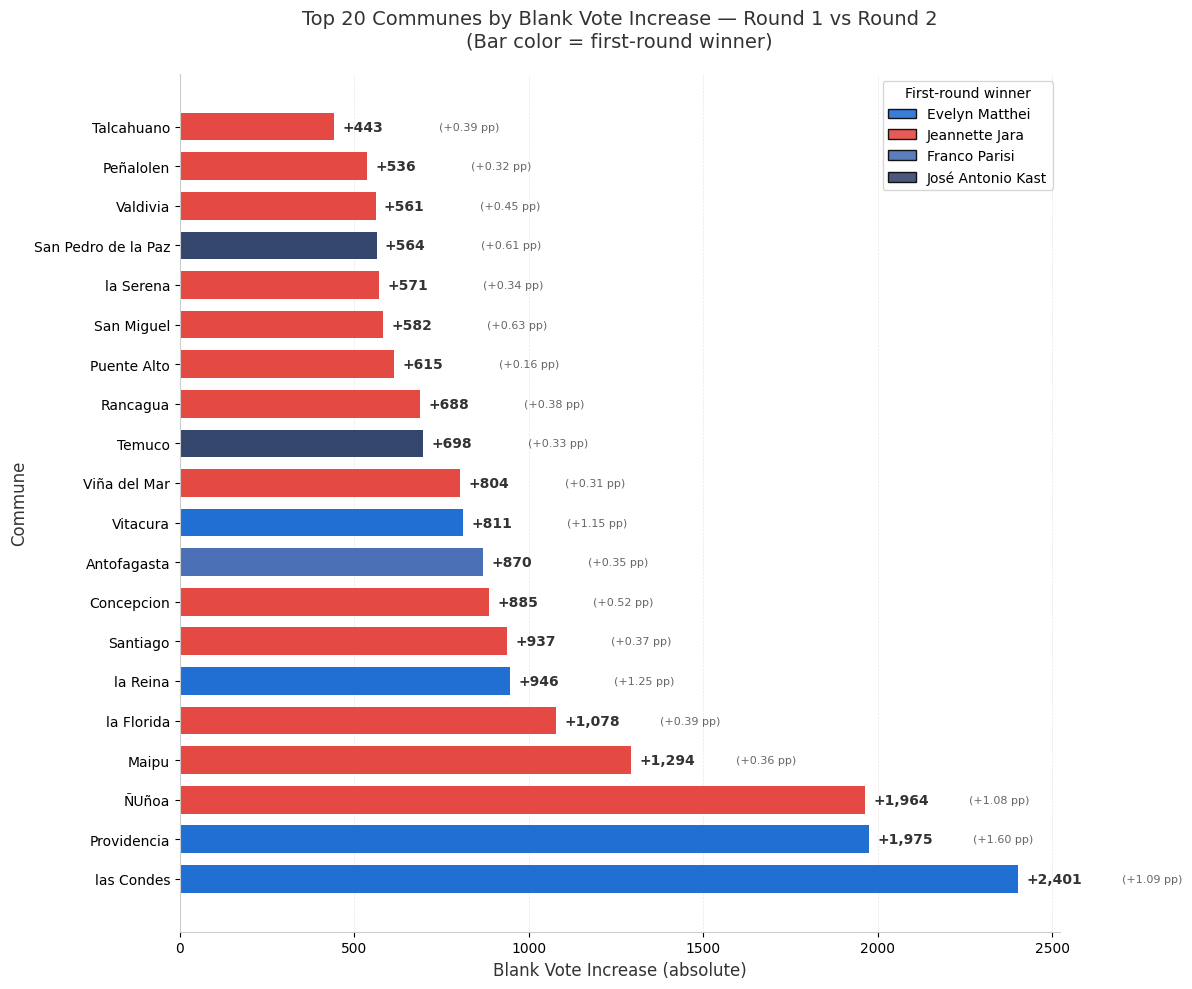

In [22]:
# ============================================================================
# VISUALIZATION: Top-N Communes by Blank Vote Increase
# ============================================================================

def plot_top_blank_increase(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest absolute increase
    in blank votes between the first and second round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries two annotations:
      - Absolute blank vote increase (bold, offset right of bar tip).
      - Percentage-point change in parentheses (smaller, further right).

    Legend is placed in the upper right to avoid overlap with the longest bars.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_blank_increase(), containing at minimum:
        commune, blank_votes_increase, blank_pct_point_change, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """
    from matplotlib.patches import Patch

    # Filter to communes with positive increase (optional)
    plot_df = df.nlargest(top_n, 'blank_votes_increase').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['blank_votes_increase'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: absolute increase
    for bar, value in zip(bars, plot_df['blank_votes_increase']):
        ax.annotate(
            f'{value:+,.0f}',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            color='#333333', zorder=3,
        )

    # Secondary annotation: pp change
    for bar, pp_value in zip(bars, plot_df['blank_pct_point_change']):
        sign = '+' if pp_value > 0 else ''
        ax.annotate(
            f'({sign}{pp_value:.2f} pp)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(75, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=8, color='#666666', zorder=3,
        )

    ax.set_xlabel('Blank Vote Increase (absolute)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Blank Vote Increase — Round 1 vs Round 2\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend — upper right keeps it clear of the longest bars
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(
                WINNER_NAME_MAPPING.get(w, 'No data'), 
                CANDIDATE_COLORS['No data']
            ),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()


# Execute
plot_top_blank_increase(communes_blank_increase, 20)

##### Hallazgo Principal

El aumento del voto en blanco se concentró fuertemente en la **Región Metropolitana**, con un claro predominio de comunas de **alto nivel socioeconómico** y bastiones de la **derecha tradicional** (Matthei).

##### Patrones Principales

- **Comunas de Elite (Matthei)**: Dominan los primeros lugares.
  - **Las Condes** (+2.401) — el mayor aumento del país.
  - **Providencia** (+1.975) — segundo lugar.
  - **Vitacura** (+811) y **La Reina** (+946).
- **Bastiones de Jara**: También presentan aumentos importantes en volumen.
  - Ñuñoa (+1.964), Maipú (+1.294), La Florida (+1.078), Santiago (+937), Viña del Mar (+804).
- **Presencia menor de otras zonas**:
  - Antofagasta (+870, Parisi) es la única comuna del Norte relevante.
  - Pocas comunas de Kast en el ranking.

##### Interpretación Estratégica

El voto en blanco tuvo un **carácter más elitista y urbano** que el voto nulo. Se concentró especialmente en el **oriente de Santiago** (comunas donde Matthei tuvo mejor desempeño en primera vuelta), sugiriendo descontento o resistencia de sectores de derecha tradicional a votar por Kast.

#### Analisis grafico de barras: Top 20 Comunas con mayor incremento relativo

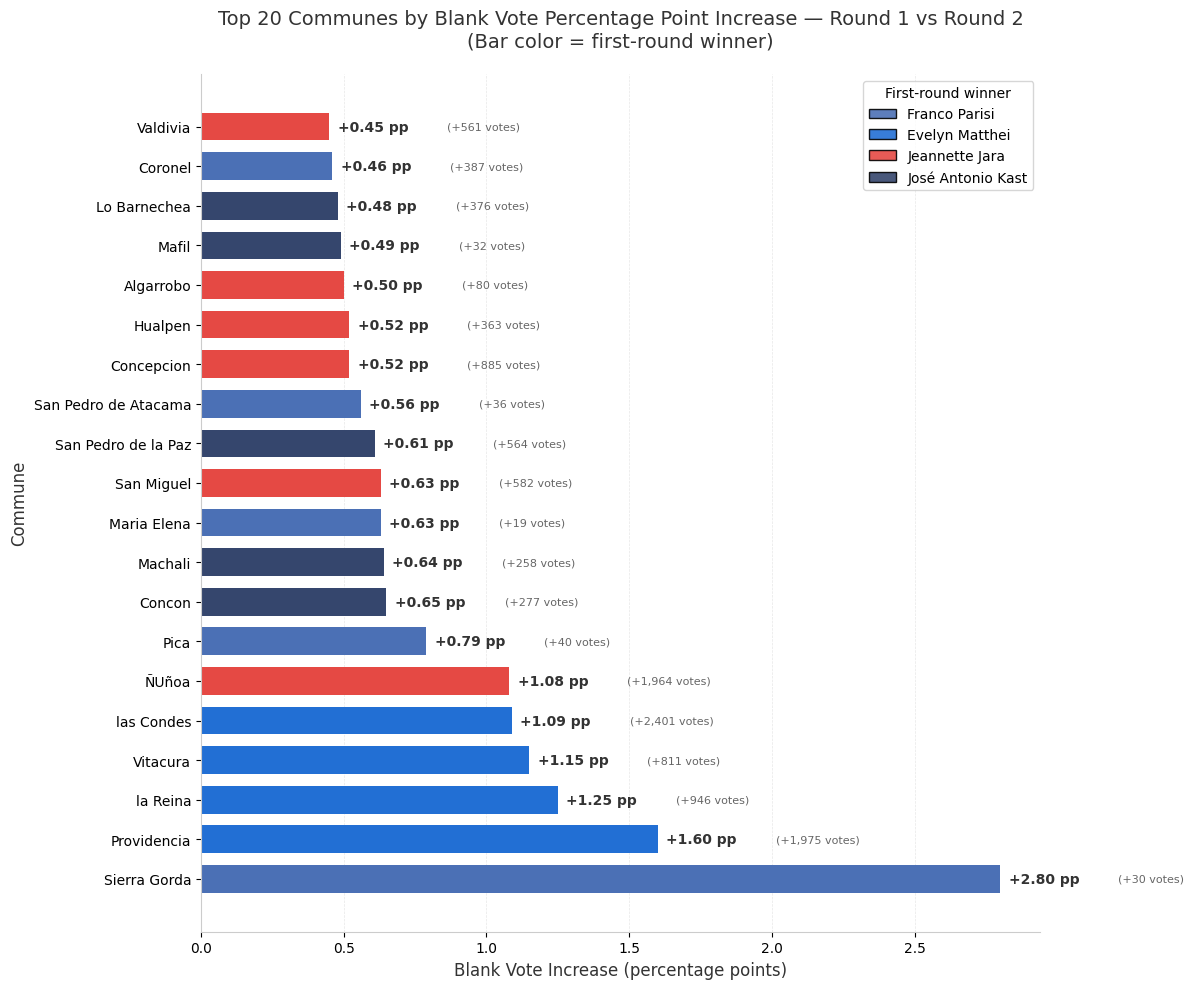

In [23]:
# ============================================================================
# VISUALIZATION: Top-N Communes by Blank Vote Percentage Point Increase
# ============================================================================

def plot_top_blank_pp_increase(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest PERCENTAGE POINT
    increase in blank votes between the first and second round.

    This is useful for identifying communes where blank voting intensity
    increased the most, regardless of population size.

    Bar color encodes the first-round winner of each commune.
    Each bar carries two annotations:
      - Percentage-point change (bold, offset right of bar tip).
      - Absolute increase in parentheses (smaller, further right).

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_blank_increase().
    top_n : int, optional
        Number of communes to display (default 20).
    """
    from matplotlib.patches import Patch

    # Filter to communes with positive pp increase
    plot_df = df[df['blank_pct_point_change'] > 0].nlargest(top_n, 'blank_pct_point_change').copy()

    if len(plot_df) == 0:
        print("No communes with positive blank vote percentage point increase.")
        return

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['blank_pct_point_change'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: percentage point change
    for bar, value in zip(bars, plot_df['blank_pct_point_change']):
        ax.annotate(
            f'+{value:.2f} pp',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            color='#333333', zorder=3,
        )

    # Secondary annotation: absolute increase
    for bar, abs_value in zip(bars, plot_df['blank_votes_increase']):
        ax.annotate(
            f'({abs_value:+,.0f} votes)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(85, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=8, color='#666666', zorder=3,
        )

    ax.set_xlabel('Blank Vote Increase (percentage points)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Blank Vote Percentage Point Increase — Round 1 vs Round 2\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(
                WINNER_NAME_MAPPING.get(w, 'No data'), 
                CANDIDATE_COLORS['No data']
            ),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()


# Execute
plot_top_blank_pp_increase(communes_blank_increase, 20)

##### Hallazgo Principal

A diferencia del aumento absoluto (concentrado en volumen), el aumento **relativo (pp)** del voto en blanco se concentró fuertemente en **comunas de alto nivel socioeconómico de la Región Metropolitana**, especialmente en los bastiones de **Evelyn Matthei**.

##### Patrones Principales

- **Dominio de la derecha tradicional (Matthei)**:
  - Providencia (+1.60 pp)
  - Vitacura (+1.15 pp)
  - La Reina (+1.25 pp)
  - Las Condes (+1.09 pp)
- **Presencia de Jara**: Ñuñoa (+1.08 pp) y otras comunas de la RM.
- **Casos extremos del Norte**: Sierra Gorda (+2.80 pp) lidera el ranking, aunque con bajo volumen de votos.

##### Interpretación Estratégica 

El voto en blanco tuvo un **perfil elitista y urbano** muy marcado. El mayor aumento relativo ocurrió en las comunas más ricas de Santiago, donde Matthei había obtenido buenos resultados en primera vuelta. Esto sugiere que una parte de la **derecha tradicional** prefirió no votar por Kast y optó por una protesta pasiva.

#### Distribución del aumento de votos blancos por ganador de la primera ronda

/tmp/ipykernel_159834/989187500.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax.boxplot(


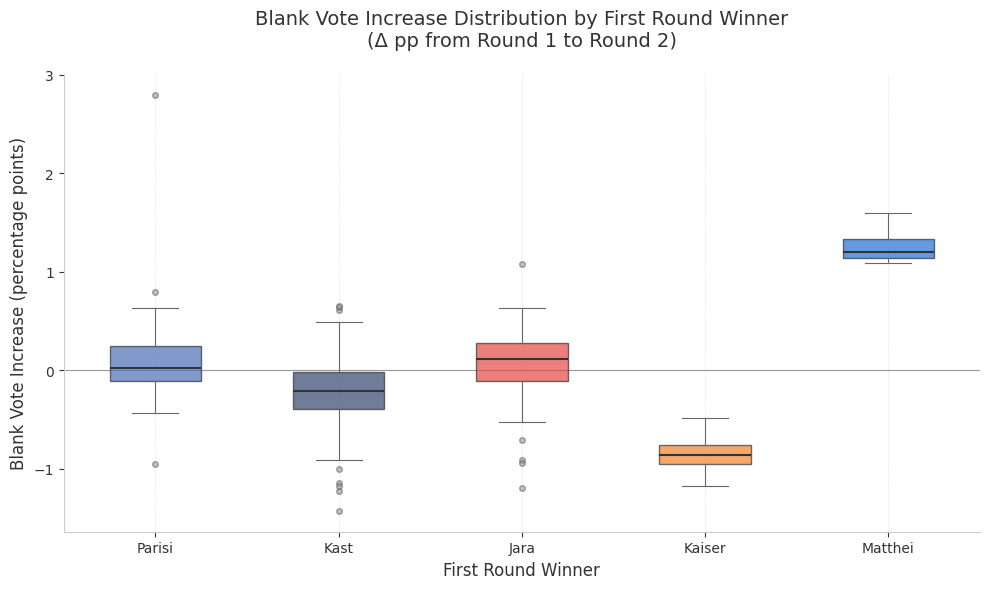

In [24]:
# ============================================================================
# VISUALIZATION: Blank Vote Increase Distribution by First Round Winner
# ============================================================================

def plot_blank_increase_by_winner(df: pd.DataFrame) -> None:
    """
    Box plot showing the distribution of percentage point increase in blank votes,
    grouped by the winner of the first round in each commune.

    Only includes candidates with sufficient commune representation to ensure
    meaningful distributions.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_blank_increase(), containing at minimum:
        commune, blank_pct_point_change, first_round_winner.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Filter top winners (exclude candidates with few communes)
    top_winners = ['Parisi', 'Kast', 'Jara', 'Kaiser', 'Matthei']
    plot_df = df[df['first_round_winner'].isin(top_winners)].copy()

    # Prepare data for box plots
    box_data = [
        plot_df[plot_df['first_round_winner'] == winner]['blank_pct_point_change']
        for winner in top_winners
    ]

    # Create box plot with custom styling
    boxes = ax.boxplot(
        box_data,
        labels=top_winners,
        patch_artist=True,
        medianprops={'color': '#333333', 'linewidth': 1.5},
        whiskerprops={'color': '#666666', 'linewidth': 0.8},
        capprops={'color': '#666666', 'linewidth': 0.8},
        flierprops={
            'marker': 'o',
            'markerfacecolor': '#999999',
            'markeredgecolor': '#666666',
            'markersize': 4,
            'alpha': 0.6
        }
    )

    # Color each box consistently with candidate colors
    for box, winner in zip(boxes['boxes'], top_winners):
        full_name = WINNER_NAME_MAPPING.get(winner, winner)
        color = CANDIDATE_COLORS.get(full_name, CANDIDATE_COLORS.get('No data', '#dddddd'))
        box.set_facecolor(color)
        box.set_alpha(0.7)
        box.set_edgecolor('#333333')
        box.set_linewidth(1)

    # Add horizontal line at zero
    ax.axhline(y=0, color='#333333', linestyle='-', linewidth=0.8, alpha=0.5, zorder=1)

    # Labels and title
    ax.set_xlabel('First Round Winner', fontsize=12, color='#333333')
    ax.set_ylabel('Blank Vote Increase (percentage points)', fontsize=12, color='#333333')
    ax.set_title(
        'Blank Vote Increase Distribution by First Round Winner\n'
        '(Δ pp from Round 1 to Round 2)',
        fontsize=14, pad=20, color='#333333'
    )

    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)

    plt.tight_layout()
    plt.show()


# Execute
plot_blank_increase_by_winner(communes_blank_increase)

##### Hallazgo Principal

El voto en blanco mostró un comportamiento **muy diferenciado** según el candidato ganador en primera vuelta. A diferencia del voto nulo (dominado por Parisi), el blanco tuvo un perfil más **elitista y concentrado**.

##### Análisis por Candidato

- **Matthei (Derecha Tradicional)**: Mayor aumento y más consistente (mediana ~1.2–1.4 pp). Sus comunas muestran la mayor tendencia a votar en blanco. Esto indica que una parte importante de su electorado **rechazó votar por Kast**.
- **Jara**: Aumento moderado y centrado alrededor de 0 a +0.5 pp. Hubo algo de protesta pasiva en sus bastiones, pero menor que en Matthei.
- **Parisi**: Distribución amplia y variable (desde negativo hasta +2.8 pp). Su electorado fue heterogéneo: algunos aumentaron el blanco, pero otros optaron más por el nulo.
- **Kast**: Tendencia ligeramente negativa o estable. Sus votantes fueron los más leales y disciplinados.
- **Kaiser**: Ligero descenso. Buena transferencia hacia Kast.

##### Conclusión Estratégica

El voto en blanco fue el mecanismo de protesta preferido por el **electorado de Evelyn Matthei** y sectores de derecha tradicional, especialmente en comunas de alto nivel socioeconómico del oriente de Santiago.

#### Conclusión

El voto en blanco en la segunda vuelta de 2025 se comportó como un fenómeno territorialmente diferenciado que complementa —y contrasta— con el patrón observado para el voto nulo. Mientras el nulo tuvo su epicentro en el Norte minero y en comunas populares, el blanco se concentró en la Región Metropolitana, especialmente en comunas de alto nivel socioeconómico y en bastiones de Evelyn Matthei. Este comportamiento sugiere que el voto en blanco operó como un canal de descontento más pasivo, utilizado por sectores de la derecha tradicional que no se sintieron representados por José Antonio Kast, y por una fracción del electorado de Jara que optó por la protesta antes que por la ratificación de su candidata. La dualidad entre nulo y blanco —protesta activa en el norte, protesta pasiva en el oriente de Santiago— evidencia una fragmentación del descontento ciudadano que trasciende el resultado electoral y plantea desafíos estructurales para la legitimidad del sistema político y la capacidad de los partidos para reconectar con un electorado crecientemente heterogéneo en sus formas de expresión política.

---


### 5.4. Conclusion

pendiente o eliminar 



El voto en blanco en la segunda vuelta de 2025 presentó un perfil nítidamente elitista y urbano, concentrándose fuertemente en la Región Metropolitana —particularmente en las comunas del oriente de Santiago como Las Condes (+2.401 votos, +1,09 pp), Providencia (+1.975, +1,60 pp), Vitacura y La Reina— que corresponden a los bastiones tradicionales de Evelyn Matthei, sugiriendo que una fracción significativa de la derecha tradicional optó por la protesta pasiva antes que votar por Kast. Este comportamiento contrasta con el voto nulo, que fue dominado por el electorado de Parisi en el Norte y en comunas populares, confirmando que ambos mecanismos de descontento respondieron a lógicas políticas y sociales distintas: el blanco canalizó el malestar de sectores de alto nivel socioeconómico que no se sintieron representados por Kast, mientras que el nulo expresó el rechazo más radical de los votantes antisistema al duelo final.

La distribución por candidato de primera vuelta refuerza esta interpretación: los votantes de Matthei lideraron el aumento del voto en blanco con la mayor consistencia (mediana ~1,2–1,4 pp), indicando que una parte importante de su electorado —especialmente en las comunas más ricas del país— prefirió la protesta pasiva antes que respaldar al candidato de la derecha conservadora. En contraste, los votantes de Kast mostraron una tendencia ligeramente negativa o estable, confirmando la mayor lealtad y disciplina de su electorado, mientras que los de Jara presentaron un aumento moderado (0 a +0,5 pp) que refleja cierta desmovilización en sus bastiones urbanos, pero sin la intensidad observada en el voto nulo. Este patrón dual revela que la fragmentación del descontento en 2025 fue tanto territorial como socialmente estratificada: el voto en blanco operó como un mecanismo de protesta pasiva propio de la derecha tradicional y los sectores más acomodados, mientras que el nulo funcionó como una expresión de rechazo más radical del electorado antisistema y de los sectores populares descontentos con la oferta bipolar.

En su conjunto, el comportamiento del voto en blanco confirma que Kast no logró capturar plenamente el apoyo de la derecha tradicional de Matthei, especialmente en sus bastiones más exclusivos, donde una fracción relevante del electorado optó por no validar su candidatura a través de la protesta pasiva. Este fenómeno, aunque de menor magnitud que el aumento del voto nulo, revela una fisura interna en el espectro de derecha que podría tener implicancias para la gobernabilidad y la construcción de mayorías en el próximo período, al tiempo que subraya la naturaleza estratificada del descontento ciudadano en la elección de 2025.

##### Comparativa Final: Voto en Blanco vs Voto Nulo

| Aspecto                   | Voto Nulo                                 | Voto en Blanco                                |
| ------------------------- | ----------------------------------------- | --------------------------------------------- |
| **Intensidad**            | Muy alta (casi se duplicó)                | Moderada                                      |
| **Distribución**          | Amplia y transversal                      | Más concentrada en RM y comunas elite         |
| **Principal origen**      | Electorado de **Parisi** (Norte)          | Electorado de **Matthei** (Oriente RM)        |
| **Tipo de protesta**      | **Activa / Confrontacional**              | **Pasiva** (“ninguna opción me representa”)   |
| **Comunas más afectadas** | Norte Grande + grandes ciudades populares | Comunas de alto NSE de Santiago               |
| **Implicancia**           | Rechazo antisistema fuerte                | Resistencia interna de la derecha tradicional |

##### Conclusión Estratégica

El voto de protesta en la segunda vuelta tuvo **dos caras** bien diferenciadas:

- El **nulo** fue la expresión dominante del descontento **antisistema** (especialmente del Norte de Parisi).
- El **blanco** fue la forma elegida por sectores más moderados y de élite, principalmente de la derecha tradicional que no se sintió cómoda apoyando a Kast.

En conjunto, ambos reflejan que una parte relevante del electorado no se sintió representada por el duelo final, aunque Kast logró capitalizar suficiente apoyo como para ganar con un margen amplio.


## 6. Analisis de votos validos y ganador de la eleccion

La segunda vuelta presidencial de 2025 consagró a José Antonio Kast como presidente electo con una victoria que, por su magnitud y características, se inscribe entre las más contundentes de la historia electoral reciente de Chile. Con un 58,24% de los votos válidos frente al 41,76% de Jeannette Jara, Kast obtuvo una diferencia de 16,48 puntos porcentuales que se traduce en más de 2 millones de votos de ventaja sobre su competidora . Esta mayoría clara y sólida —respaldada por casi 6 de cada 10 votantes que concurrieron a las urnas— le otorga a Kast un mandato relativamente fuerte para gobernar, a pesar del alto nivel de voto nulo (5,85%) que caracterizó la elección. La victoria representa además un giro político significativo hacia la derecha conservadora tras el gobierno de Gabriel Boric, consolidando un realineamiento electoral que comenzó a gestarse en la primera vuelta y que se materializó con fuerza en el balotaje.

In [25]:
# ============================================================================
# SECOND ROUND WINNER DECLARATION
# ============================================================================
# Objective: Determine the winner of the runoff election
# Source table: second_round_2025

def calculate_winner_results(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates final results for the second round runoff.
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: casted_votes, blank_votes, null_votes,
        jara_votes, kast_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with candidate, percentage, total_votes, result
    """
    total_cast = df['casted_votes'].sum()
    total_blank = df['blank_votes'].sum()
    total_null = df['null_votes'].sum()
    total_valid = total_cast - total_blank - total_null
    
    jara_total = df['jara_votes'].sum()
    kast_total = df['kast_votes'].sum()
    
    jara_pct = round(100.0 * jara_total / total_valid, 2)
    kast_pct = round(100.0 * kast_total / total_valid, 2)
    margin_pct = round(abs(jara_pct - kast_pct), 2)
    margin_votes = abs(jara_total - kast_total)
    
    results = pd.DataFrame([
        {
            'candidate': 'Jeannette Jara',
            'percentage': jara_pct,
            'total_votes': jara_total,
            'result': 'defeated'
        },
        {
            'candidate': 'José Antonio Kast',
            'percentage': kast_pct,
            'total_votes': kast_total,
            'result': 'PRESIDENT-ELECT'
        },
        {
            'candidate': 'Margin',
            'percentage': margin_pct,
            'total_votes': margin_votes,
            'result': 'winning margin'
        }
    ])
    
    return results


# Execute calculation
winner_results = calculate_winner_results(df_2025_v2)
winner_results

,candidate,percentage,total_votes,result
0,Jeannette Jara,41.76,5184026,defeated
1,José Antonio Kast,58.24,7231018,PRESIDENT-ELECT
2,Margin,16.48,2046992,winning margin


### Analisis

#### Magnitud de la Victoria y Significado Político

El resultado de la segunda vuelta no admite matices en términos de magnitud. Kast obtuvo 7.231.018 votos válidos, frente a los 5.184.026 de Jara, una ventaja absoluta de 2.046.992 sufragios que representa el mayor margen de victoria en un balotaje desde el retorno a la democracia. Esta mayoría, que supera holgadamente el umbral del 50% requerido por la Constitución para ser proclamado presidente sin necesidad de segunda vuelta, configura un mandato electoral de carácter indiscutible .

Desde una perspectiva comparada, la victoria de Kast se sitúa entre las más amplias de la historia reciente de Chile. La diferencia de 16,48 puntos porcentuales supera los márgenes obtenidos por Sebastián Piñera en 2010 (7,9 pp) y 2017 (1,5 pp), y se acerca a los registros de Michelle Bachelet en 2013 (7,6 pp). El propio Kast, quien había perdido en 2021 frente a Boric por una diferencia de 11,8 puntos, obtuvo una revancha que duplica en magnitud la derrota anterior, configurando un giro electoral de proporciones inéditas en el período post-dictadura.

#### Consolidación del Voto de Derecha y Captura del Electorado de Parisi

La victoria de Kast se explica por su capacidad para consolidar y expandir el voto de la derecha y centro-derecha, capturando una parte importante del electorado que en primera vuelta había respaldado a Franco Parisi, Johannes Kaiser y Evelyn Matthei. El electorado de Parisi —que en noviembre alcanzó 2,55 millones de votos (19,71%)— se dispersó entre las dos candidaturas en competencia, pero con una inclinación mayoritaria hacia Kast, especialmente en las regiones del Norte Grande donde el apoyo al candidato del PDG era más sólido .

El perfil del nuevo electorado que inclinó la balanza hacia Kast es el de un votante predominantemente joven, masculino, de clase media y con alta desconfianza hacia el sistema político tradicional —precisamente el segmento que había respaldado a Parisi en primera vuelta y que, enfrentado a una oferta bipolar entre una candidata oficialista y un candidato de derecha conservadora, optó mayoritariamente por Kast. Como señala la literatura sobre elecciones críticas, este tipo de realineamiento suele ocurrir cuando un partido o coalición logra articular una coalición de votantes cuyo apoyo regular lo mantiene en el poder de modo relativamente estable . El hecho de que Kast haya logrado capturar una porción significativa del electorado antisistema —que en elecciones anteriores había optado por candidatos de centro o izquierda— sugiere que estamos ante un realineamiento político de largo plazo.

#### El Factor Jara y la Desmovilización del Oficialismo

En contraste, Jeannette Jara no logró movilizar suficientemente a su propia base ni atraer el voto antisistema que había respaldado a Parisi en la primera vuelta. La candidata del Partido Comunista, que había obtenido el 26,85% de los votos en noviembre , vio cómo su caudal electoral se estancaba y, en términos relativos, retrocedía frente al crecimiento de Kast. La caída de casi medio millón de votos válidos entre ambas rondas —sumada al incremento explosivo del voto nulo en comunas que habían sido bastiones de Jara— evidencia que el oficialismo enfrentó una desmovilización significativa de su electorado natural.

La derrota de Jara también refleja las limitaciones estructurales del proyecto político que encabezaba. A pesar de haber sido ministra de Trabajo de Boric y haber impulsado reformas como la reducción de la jornada laboral a 40 horas y la reforma del sistema privado de pensiones , su candidatura no logró articular un relato de continuidad que interpelara a los votantes descontentos con la gestión del gobierno saliente. El discurso de Kast, que repetía como un mantra que "Chile se cae a pedazos" y prometía un "gobierno de emergencia" para enfrentar las crisis económica y de seguridad , caló con mayor eficacia en un electorado que percibía un deterioro en la calidad de vida y una pérdida de control del orden público.

#### Legitimidad y Desafíos del Mandato

A pesar de la contundencia de su victoria en términos de votos válidos, el triunfo de Kast no está exento de cuestionamientos a su legitimidad percibida. El alto nivel de voto nulo (5,85%) y la abstención de quienes, enfrentados a una oferta bipolar insatisfactoria, optaron por no concurrir a las urnas, limitan parcialmente la legitimidad del nuevo gobierno en algunos sectores. Como señala la teoría política, la legitimidad de un poder no se reduce a la legalidad formal del proceso electoral, sino que requiere de un consenso entre los miembros de la comunidad política para aceptar la autoridad vigente . El hecho de que más de 780 mil ciudadanos hayan optado por la protesta activa a través del voto nulo —y que una fracción significativa del electorado de la tercera fuerza política del país no se haya sentido representada por ninguna de las dos opciones— plantea un desafío para la legitimidad social del nuevo gobierno.

Sin embargo, esta limitación no debe ser sobredimensionada. La mayoría obtenida por Kast —casi 6 de cada 10 votantes válidos— es suficientemente amplia para otorgarle un mandato relativamente fuerte para gobernar, especialmente en comparación con presidentes anteriores que accedieron al poder con márgenes más ajustados. El desafío para el nuevo gobierno no será tanto la legitimidad formal de su triunfo, sino su capacidad para traducir ese mandato electoral en políticas públicas efectivas en un contexto de fragmentación parlamentaria y alta expectativa ciudadana .

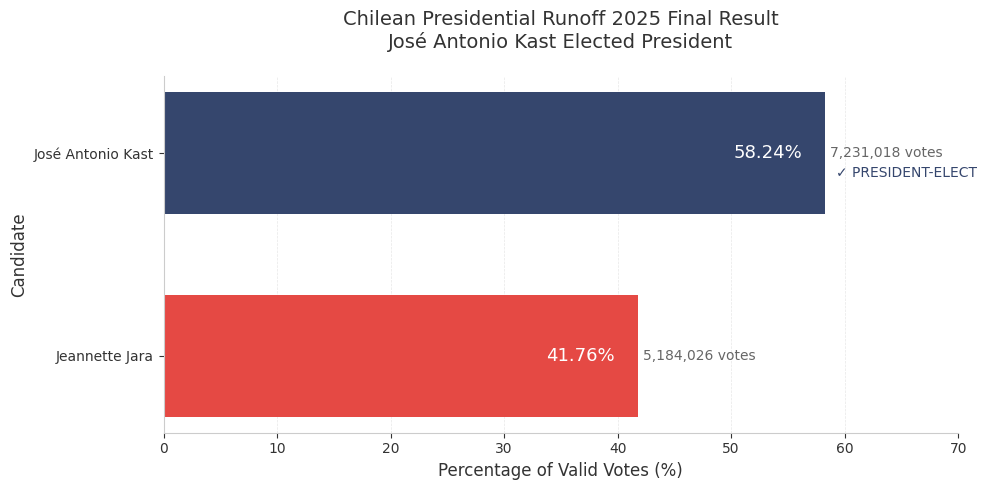

In [26]:
# ============================================================================
# VISUALIZATION: Winner Declaration - Horizontal Bar Chart
# ============================================================================

def plot_winner_bars(df: pd.DataFrame) -> None:
    """
    Creates a horizontal bar chart showing the final vote percentages and margins
    for the Chilean Presidential Runoff 2025.

    Bars display each candidate's percentage of valid votes, with the winner
    highlighted and annotated. Percentage labels appear inside bars, while
    vote counts are placed at the bar tips.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing candidate results with columns:
        candidate, percentage, total_votes.
        Should exclude any 'Margin' row.
    """
    plot_df = df[df['candidate'] != 'Margin'].copy()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Get colors from palette
    colors = [CANDIDATE_COLORS.get(c, '#cccccc') for c in plot_df['candidate']]
    
    # Horizontal bars with consistent styling
    bars = ax.barh(
        plot_df['candidate'],
        plot_df['percentage'],
        color=colors,
        linewidth=0.8,
        height=0.6,
        zorder=2
    )
    
    # Primary annotation: percentage labels inside bars (right-aligned)
    for bar, pct in zip(bars, plot_df['percentage']):
        ax.annotate(
            f'{pct:.2f}%',
            xy=(bar.get_width() - 2, bar.get_y() + bar.get_height() / 2),
            xytext=(0, 0),
            textcoords='offset points',
            ha='right', va='center',
            fontsize=13,
            color='white', zorder=3
        )
    
    # Secondary annotation: vote count labels at bar tips
    for bar, votes in zip(bars, plot_df['total_votes']):
        ax.annotate(
            f'{votes:,.0f} votes',
            xy=(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2),
            xytext=(0, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10, color='#666666', zorder=3
        )
    
    # Set x-axis limit with some padding for labels
    ax.set_xlim(0, 70)
    
    # Labels and title (no fontweight='bold')
    ax.set_xlabel('Percentage of Valid Votes (%)', fontsize=12, color='#333333')
    ax.set_ylabel('Candidate', fontsize=12, color='#333333')
    ax.set_title(
        'Chilean Presidential Runoff 2025 Final Result\n'
        'José Antonio Kast Elected President',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Highlight winner annotation (no fontweight='bold')
    winner_name = 'José Antonio Kast'
    if winner_name in plot_df['candidate'].values:
        bar_position = list(plot_df['candidate']).index(winner_name)
        winner_pct = plot_df[plot_df['candidate'] == winner_name]['percentage'].values[0]
        
        ax.annotate(
            '✓ PRESIDENT-ELECT',
            xy=(winner_pct + 1, bar_position - 0.1),
            xytext=(0, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#35466D', zorder=3
        )
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    
    plt.tight_layout()
    plt.show()


# Execute
plot_winner_bars(winner_results)

### Conclusión

La segunda vuelta presidencial de 2025 consagró a José Antonio Kast como presidente electo con una victoria que, por su magnitud y características, configura un hito en la historia electoral reciente de Chile. Su capacidad para capturar el voto de la derecha tradicional, de los sectores antisistema y de una parte importante del electorado de centro —especialmente en el Norte y en zonas rurales— le permitió construir una mayoría de casi 6 de cada 10 votantes, la más amplia desde el retorno a la democracia. Esta victoria representa un giro político significativo hacia la derecha conservadora tras el gobierno de Gabriel Boric, consolidando un realineamiento electoral cuyos efectos se proyectarán más allá del período presidencial. Sin embargo, la magnitud del triunfo no debe ocultar los desafíos que enfrenta el nuevo gobierno: el alto nivel de voto nulo, que afecta la legitimidad percibida del mandato en algunos sectores; la fragmentación del Congreso, que limitará su capacidad para impulsar reformas estructurales; y la necesidad de reconectar con un electorado que, especialmente en el norte del país y en los sectores populares, ha optado por la protesta activa como forma de expresión política. En este sentido, el triunfo de Kast, aunque contundente, es también un mandato contingente que exigirá del nuevo gobierno una capacidad de negociación y diálogo que hasta ahora no ha sido su sello distintivo.

---

## 7. Ganador territorial

pendiente


### 7.1. Mapeo Territorial: Comunas Ganadas por Candidato

El mapeo territorial de la segunda vuelta de 2025 revela una hegemonía comunal sin precedentes en la historia electoral chilena reciente: José Antonio Kast obtuvo la victoria en 310 de las 346 comunas del país (89,6%), mientras que Jeannette Jara quedó reducida a apenas 36 comunas (10,4%), concentradas casi exclusivamente en la Región Metropolitana —especialmente en las comunas populares del poniente y sur del Gran Santiago— y en algunos enclaves de Valparaíso, Coquimbo y Atacama . Esta abrumadora mayoría territorial contrasta con la distribución del voto popular (58,24% para Kast versus 41,76% para Jara), reflejando la clásica fractura urbano-rural y centro-periferia que caracteriza a Chile : Jara mantuvo su fuerza en zonas densamente pobladas y urbanas, mientras que Kast arrasó en la mayoría del territorio nacional, incluyendo comunas rurales, semi-rurales y ciudades intermedias de todas las regiones del país .


In [27]:
# ============================================================================
# TERRITORIAL MAPPING OF WINS PER CANDIDATE (SECOND ROUND)
# ============================================================================


def analyze_communes_won(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates how many communes each candidate won in the second round.
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: commune, jara_pct, kast_pct
    
    Returns
    -------
    pd.DataFrame
        DataFrame with candidate, communes_won, percentage_communes
    """
    total_communes = len(df)
    
    # Determine winner per commune
    df = df.copy()
    df['winner'] = 'Tie'
    df.loc[df['jara_pct'] > df['kast_pct'], 'winner'] = 'Jeannette Jara'
    df.loc[df['kast_pct'] > df['jara_pct'], 'winner'] = 'José Antonio Kast'
    
    # Count communes per winner
    results = df[df['winner'] != 'Tie'].groupby('winner').size().reset_index(name='communes_won')
    results['percentage_communes'] = round(100.0 * results['communes_won'] / total_communes, 1)
    results = results.sort_values('communes_won', ascending=False)
    
    return results


# Execute analysis
communes_won = analyze_communes_won(df_2025_v2)
communes_won

,winner,communes_won,percentage_communes
1,José Antonio Kast,310,89.6
0,Jeannette Jara,36,10.4


#### Análisis

##### Hegemonía Territorial de Kast

El candidato republicano no solo ganó la elección presidencial en términos de voto popular, sino que construyó un dominio territorial que no tiene parangón en la historia reciente de los balotajes. Con 310 comunas conquistadas —casi 9 de cada 10— Kast logró imponerse en todas las regiones del país, incluyendo aquellas donde Jara obtuvo sus mejores resultados relativos . La amplitud de su triunfo territorial es particularmente notable en las regiones del centro-sur: en Ñuble, La Araucanía, Maule y Los Lagos, Kast superó el 65% de los votos, consolidando un bloque de apoyo que combina zonas rurales, ciudades intermedias y comunas con alta presencia de población evangélica .

La literatura académica ofrece claves para interpretar esta hegemonía territorial. Estudios recientes sobre el comportamiento electoral chileno han demostrado que variables sociodemográficas como el porcentaje de población rural, el nivel de pobreza y la proporción de evangélicos en cada comuna son predictores significativos del voto de derecha . En particular, el voto por la opción "Rechazo" en el plebiscito constitucional de 2022 —que anticipó el mapa electoral de 2025— correlacionó positivamente con el porcentaje de población evangélica, el nivel de pobreza y la ruralidad de las comunas, mientras que el porcentaje de católicos y de personas sin religión tuvo un efecto inverso . Este patrón se repitió en la elección presidencial de 2025: Kast obtuvo sus mejores resultados en comunas rurales, pobres y con alta presencia evangélica, confirmando la persistencia de las fracturas sociopolíticas históricas en el sistema electoral chileno .

##### El Reducto de Jara: 36 Comunas en Cinco Regiones

Jeannette Jara logró imponerse en apenas 36 comunas, distribuidas en cinco regiones: Antofagasta (3), Atacama (4), Coquimbo (3), Valparaíso (5) y la Región Metropolitana (21) . Esta distribución territorial evidencia que su base electoral quedó circunscrita a tres tipos de territorios. El primer grupo corresponde a comunas de la Región Metropolitana, especialmente aquellas del sector poniente y sur del Gran Santiago —Puente Alto, Maipú, La Florida, Ñuñoa, Peñalolén y las comunas del sector sur— donde el voto de izquierda históricamente ha tenido mayor arraigo debido a la concentración de población trabajadora y sectores populares .

El segundo grupo corresponde a enclaves mineros y portuarios del Norte Chico: Chañaral, Diego de Almagro, Caldera y Huasco en Atacama; María Elena, Mejillones y San Pedro de Atacama en Antofagasta; y Canela, Illapel y Andacollo en Coquimbo . La presencia de Jara en estos territorios, que en primera vuelta habían respaldado mayoritariamente a Franco Parisi, sugiere que una fracción del electorado antisistema del norte —especialmente en comunas con alta dependencia de la minería y el empleo público— optó por la candidata oficialista en la instancia definitoria, probablemente por temor a un gobierno de ultraderecha que pudiera afectar sus intereses económicos y laborales.

El tercer grupo está compuesto por comunas de la Región de Valparaíso: Valparaíso, San Antonio, Petorca, Isla de Pascua y Juan Fernández . En el caso de Valparaíso y San Antonio, se trata de puertos con alta densidad de población trabajadora y presencia sindical, donde el voto de izquierda tradicionalmente ha tenido mayor peso. Isla de Pascua y Juan Fernández, por su parte, son enclaves insulares con dinámicas políticas particulares, donde Jara obtuvo sus mejores resultados relativos: 54,47% en Isla de Pascua y 59,29% en Juan Fernández, esta última la comuna donde la candidata oficialista alcanzó su mayor porcentaje a nivel nacional .

##### Fractura Urbano-Rural y Centro-Periferia

La asimetría entre el voto popular (58,24% para Kast) y el control territorial (89,6% de las comunas) refleja la fractura urbano-rural que ha caracterizado la geografía electoral chilena desde el retorno a la democracia . Como ha documentado la academia, esta fractura se explica por factores estructurales de largo plazo: el mundo rural concentra el 83% del territorio nacional y dos tercios de las comunas del país, pero enfrenta niveles significativamente mayores de pobreza, informalidad laboral y rezago estatal en comparación con las zonas urbanas . Esta sensación de abandono —alimentada por brechas en acceso al agua potable, educación, conectividad digital y seguridad social— se traduce electoralmente en un voto de castigo hacia el oficialismo y un respaldo a candidaturas que prometen un cambio radical .

El análisis territorial también revela que Kast no solo ganó en las zonas rurales, sino que logró imponerse en ciudades intermedias y capitales regionales donde la derecha tradicional había tenido históricamente dificultades. Este fenómeno sugiere que el triunfo de Kast no fue meramente la suma del voto rural, sino que construyó una coalición territorial que incluye también a sectores urbanos descontentos con la gestión del gobierno de Boric y con las opciones de centroizquierda.

##### Implicancias para la Gobernabilidad

La hegemonía territorial de Kast tiene implicancias políticas relevantes para el diseño de políticas públicas. Como señala el académico José Luis Romero, el amplio respaldo obtenido en las zonas rurales implica una alta responsabilidad para el nuevo gobierno, especialmente en materias como gestión del agua, educación rural, seguridad y desarrollo productivo con enfoque territorial . La promesa de Kast de "poner a Chile de pie" y gobernar para el "Chile profundo" —repetida durante la campaña— enfrentará ahora la prueba de la implementación, en un contexto de restricciones presupuestarias y fragmentación parlamentaria.

Sin embargo, la concentración del voto de Jara en las zonas urbanas —especialmente en el Gran Santiago— plantea un desafío adicional: el nuevo gobierno deberá gobernar para una mayoría territorial que no necesariamente se refleja en los centros de poder económico y político del país. La fractura entre el Chile urbano y el Chile rural, que se manifestó con fuerza en las urnas, podría traducirse en tensiones políticas en el futuro, especialmente si las políticas del nuevo gobierno profundizan las percepciones de abandono en las zonas urbanas que respaldaron a Jara.


#### Conclusión

La segunda vuelta de 2025 consolidó un mapa electoral extremadamente asimétrico que refleja la persistencia de fracturas estructurales en la sociedad chilena. José Antonio Kast no solo ganó la elección presidencial, sino que obtuvo un dominio territorial sin precedentes —310 comunas, equivalentes al 89,6% del total— que le otorga una base geográfica excepcionalmente amplia para gobernar. Jeannette Jara, en contraste, quedó confinada a un número reducido de 36 comunas urbanas, principalmente en el Gran Santiago, y a algunos enclaves en el Norte Chico y la Región de Valparaíso. Esta asimetría territorial —que convierte a Kast en el candidato del Chile profundo y periférico y a Jara en la representante del Chile metropolitano y concentrado— revela la profundidad de la fragmentación que atraviesa al país, una fragmentación que combina variables sociodemográficas como la ruralidad, la pobreza y la religión, con percepciones de abandono y desconfianza hacia el sistema político. El desafío para el nuevo gobierno será, por tanto, no solo gobernar para la mayoría que lo respaldó, sino también diseñar políticas públicas que reduzcan las brechas territoriales que han contribuido a configurar este mapa electoral extremo, reconociendo que la legitimidad de su mandato dependerá en buena medida de su capacidad para responder a las demandas de un electorado que, aunque disperso territorialmente, votó mayoritariamente por un cambio radical.


### 7.2. Resultados por Región

El análisis regional de la segunda vuelta de 2025 confirma un dominio territorial sin precedentes de José Antonio Kast, quien se impuso en las 16 regiones del país y en 310 comunas (89,6% del total), mientras que Jeannette Jara quedó reducida a apenas 36 comunas (10,4%) concentradas en solo 5 regiones, evidenciando una dependencia casi absoluta de dos grandes polos: la Región Metropolitana, que concentró el 58% de sus victorias comunales (21 comunas) en sectores populares del poniente y sur de Santiago como Puente Alto, Maipú y La Florida, donde mantuvo su núcleo duro de apoyo entre clases medias-bajas y sectores de izquierda; y el Norte minero, donde sumó 10 comunas entre Antofagasta, Atacama y Coquimbo —muchas de ellas antiguos bastiones de Parisi en primera vuelta—, reflejando su capacidad para capturar parte del voto antisistema en zonas extractivas con fuertes demandas laborales y sindicales. Esta configuración territorial deja un mapa extremadamente polarizado: Kast controla el Chile rural, provincial y periférico, mientras Jara queda confinada a un archipiélago de bastiones urbanos y mineros, altamente dependiente de la Región Metropolitana. La enorme asimetría entre control territorial (89,6% para Kast) y densidad poblacional (41,76% del voto popular para Jara) refleja la clásica fractura urbano-rural y centro-periferia de Chile: Jara ganó donde hay más gente, pero Kast ganó donde hay más territorio, lo que le otorga al presidente electo una base geográfica excepcionalmente amplia para gobernar, mientras Jara queda con un apoyo muy concentrado y vulnerable fuera de sus enclaves urbanos.

In [28]:
# ============================================================================
# TERRITORIAL MAPPING BY REGION
# ============================================================================
# Objective: Show which candidate won each region and commune count per region
# Context: Regional-level territorial dominance analysis

def analyze_regional_winners(df: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Analyzes which candidate won each region and counts communes per region.
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: region, commune, jara_pct, kast_pct
    df_region_dim : pd.DataFrame
        Region dimension with columns: region, region_order (for north-south sorting)
    
    Returns
    -------
    pd.DataFrame
        DataFrame with region, communes_jara, communes_kast, communes_tie, regional_winner
    """
    # Determine winner per commune
    df = df.copy()
    df['winner'] = 'Tie'
    df.loc[df['jara_pct'] > df['kast_pct'], 'winner'] = 'Jara'
    df.loc[df['kast_pct'] > df['jara_pct'], 'winner'] = 'Kast'
    
    # Aggregate by region
    regional_stats = df.groupby('region').agg(
        communes_jara=('winner', lambda x: (x == 'Jara').sum()),
        communes_kast=('winner', lambda x: (x == 'Kast').sum()),
        communes_tie=('winner', lambda x: (x == 'Tie').sum())
    ).reset_index()
    
    # Determine regional winner
    regional_stats['regional_winner'] = 'Tie'
    regional_stats.loc[regional_stats['communes_jara'] > regional_stats['communes_kast'], 'regional_winner'] = 'Jara'
    regional_stats.loc[regional_stats['communes_kast'] > regional_stats['communes_jara'], 'regional_winner'] = 'Kast'
    
    # Add region order for north-south sorting
    regional_stats = regional_stats.merge(
        df_region_dim[['region', 'region_order']], 
        on='region', 
        how='left'
    )
    regional_stats = regional_stats.sort_values('region_order')
    regional_stats = regional_stats.drop('region_order', axis=1)
    
    return regional_stats


# Execute analysis
regional_winners = analyze_regional_winners(df_2025_v2, df_region_dim)
regional_winners

,region,communes_jara,communes_kast,communes_tie,regional_winner
1,Arica y Parinacota,0,4,0,Kast
13,Tarapacá,0,7,0,Kast
0,Antofagasta,3,6,0,Kast
2,Atacama,4,5,0,Kast
5,Coquimbo,3,12,0,Kast
14,Valparaíso,5,33,0,Kast
12,Metropolitana,21,31,0,Kast
7,Libertador,0,33,0,Kast
11,Maule,0,30,0,Kast
15,Ñuble,0,21,0,Kast


#### Hallazgo Principal

José Antonio Kast logró un **dominio territorial casi absoluto**, ganando en **todas las 16 regiones** del país y en **310 comunas** (89,6% del total). Jeannette Jara quedó reducida a solo **36 comunas** (10,4%), concentradas en solo **5 regiones**.

#### Distribución de las Comunas Ganadas por Jara

| Región            | Comunas Ganadas por Jara | % de la Región | Característica Principal              |
| ----------------- | ------------------------ | -------------- | ------------------------------------- |
| **Metropolitana** | **21**                   | ~40%           | Bastión principal (comunas populares) |
| **Valparaíso**    | **5**                    | ~15%           | Tradición portuaria y de izquierda    |
| **Atacama**       | **4**                    | ~36%           | Enclaves mineros                      |
| **Coquimbo**      | **3**                    | ~20%           | Zonas mineras y rurales               |
| **Antofagasta**   | **3**                    | ~27%           | Algunas comunas mineras               |

**Total Jara: 36 comunas**

#### Interpretación con Énfasis en las Comunas de Jara

Jara quedó **altamente concentrada** y dependiente de dos grandes polos:

1. **Región Metropolitana (21 comunas)**
   - Representa el **58%** de todas las comunas que ganó.
   - Son principalmente comunas de **alta densidad poblacional y sectores populares** del poniente y sur de Santiago (Puente Alto, Maipú, La Florida, Pedro Aguirre Cerda, Lo Espejo, etc.).
   - Aquí Jara mantuvo su núcleo duro de apoyo de izquierda y clases medias-bajas.
2. **Norte Chico y Norte Grande (10 comunas entre Antofagasta, Atacama y Coquimbo)**
   - Estas son comunas con **fuerte tradición minera** y presencia de sindicatos.
   - Algunas fueron bastiones de Parisi en primera vuelta, por lo que Jara logró capturar parte del voto antisistema y de izquierda en zonas extractivas.
   - Reflejan un voto más ligado a demandas laborales, sociales y de distribución de la riqueza minera.
3. **Valparaíso (5 comunas)**
   - Incluye Valparaíso y Viña del Mar, manteniendo algo de la tradición progresista portuaria.

#### Conclusión Estratégica

La segunda vuelta dejó un mapa **extremadamente polarizado**:

- **Kast** controló casi todo el territorio nacional (89,6%), ganando todas las regiones y la gran mayoría de las comunas rurales y provinciales.
- **Jara** quedó reducida a un **archipiélago de bastiones urbanos y mineros**, muy dependiente de la Región Metropolitana.

Esta enorme asimetría territorial vs. densidad poblacional es típica de las divisiones chilenas: Jara ganó donde hay **más gente**, pero Kast ganó donde hay **más territorio**. Esto le da a Kast una base geográfica muy amplia para gobernar, mientras que Jara quedó con un apoyo muy concentrado y vulnerable fuera de sus enclaves urbanos.

### 7.3. Mapa Nacional de Ganadores por Comuna (analisis por macrozona)
El análisis de la intensidad del voto a través del mapa de márgenes (Jara% - Kast%) revela un patrón territorial más matizado que la simple distribución de victorias comunales, evidenciando que el dominio de Kast, aunque amplio, no fue homogéneo en su intensidad. En el Norte Grande y Norte Chico —donde Parisi había sido más fuerte en primera vuelta— predominan los tonos azules claros y medios, indicando que Kast ganó la mayoría de las comunas pero con márgenes más estrechos de lo esperado, con varios enclaves en rojo donde Jara logró imponerse o mantener una alta competitividad, especialmente en comunas mineras de Antofagasta, Atacama y Coquimbo. Esta configuración confirma que la transferencia del voto Parisi hacia Kast no fue profunda ni completa: una fracción significativa del electorado antisistema optó por la protesta (nulo) o por Jara, impidiendo que el candidato de derecha consolidara una hegemonía cómoda en los territorios que habían sido el corazón del voto de Parisi. En contraste, el Centro Sur, Sur y Patagonia muestran un dominio casi absoluto de azul oscuro, con muy pocos enclaves rojos, indicando que aquí la victoria de Kast fue abrumadora y sin contrapeso, consolidando su base territorial en el Chile rural y provincial. El Centro —especialmente la Región Metropolitana y Valparaíso— presenta el contraste más nítido: gran parte en azul (Kast), pero con un núcleo rojo oscuro en el sur y poniente de Santiago y en algunas comunas porteñas, donde Jara mantuvo sus bastiones populares y urbanos con márgenes sólidos. Este mapa revela dos Chiles claros: un Chile urbano-popular donde Jara mantiene resistencia y un Chile provincial y rural donde Kast domina con holgura, dejando enclaves competitivos en el Norte y Valparaíso que representarán el principal frente de disputa en futuras elecciones, al ser zonas donde el voto antisistema, la izquierda y la derecha se mantienen en equilibrio inestable.


Margin distribution by commune:
margin_category
Kast Landslide (>20%)    221
Kast Solid (10-20%)       48
Kast Narrow (<10%)        41
Jara Narrow (<10%)        31
Jara Solid (10-20%)        5
Name: count, dtype: int64
--------------------------------------------------


/tmp/ipykernel_159834/1024906126.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.94])


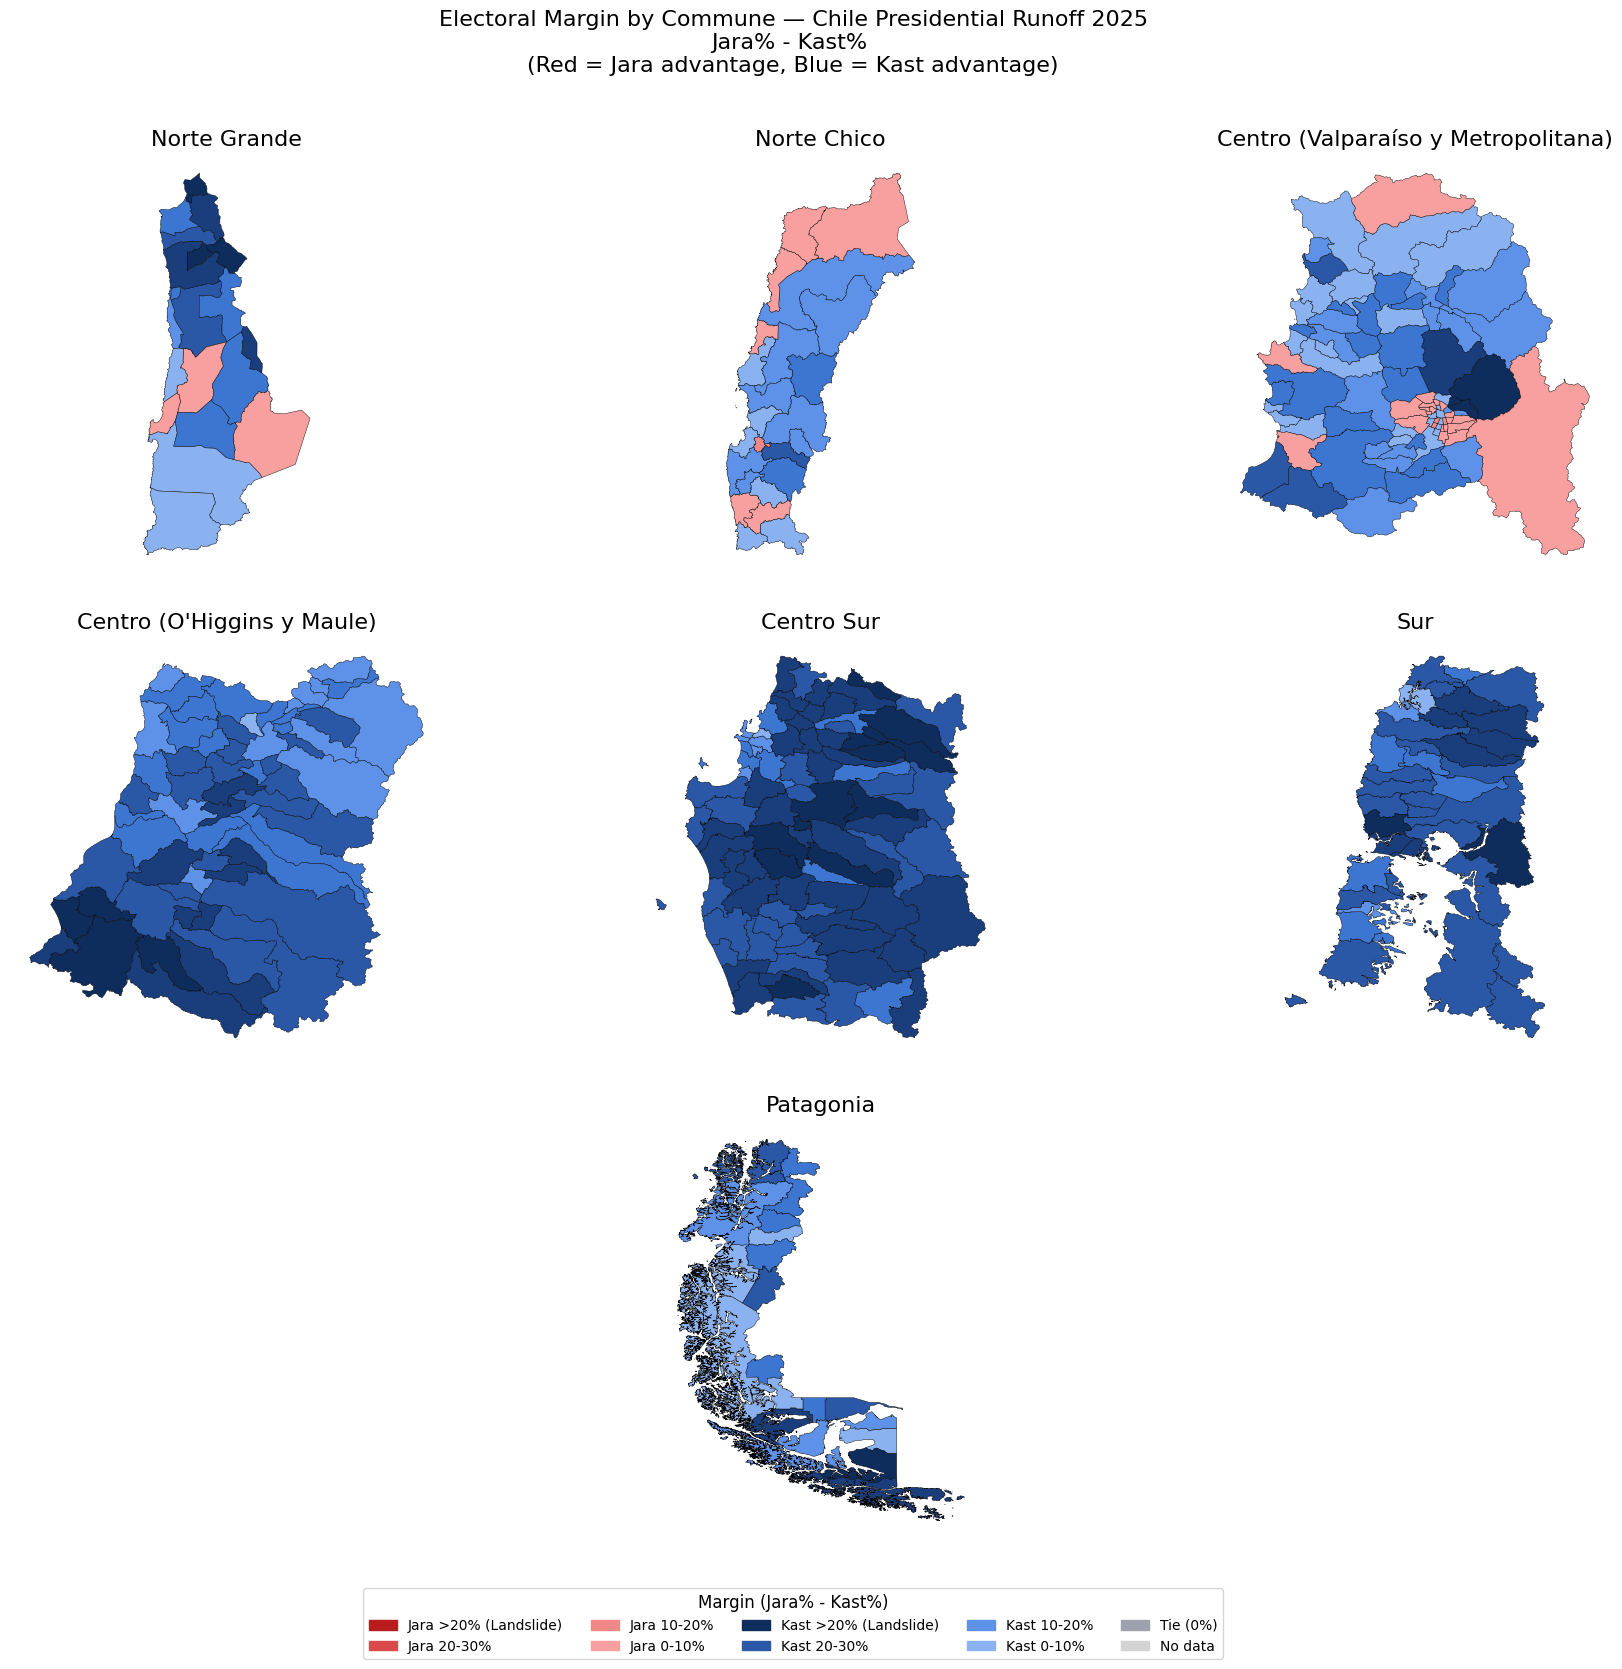

In [29]:
# ============================================================================
# COMMUNE-LEVEL MARGIN MAP — SECOND ROUND 2025 (JARA% - KAST%)
# ============================================================================

# This map shows the margin of victory at the commune level using a diverging
# color scale: Red tones = Jara advantage, Blue tones = Kast advantage.
# Darker colors represent larger margins (≥20%), lighter colors represent
# narrower margins (<10%).
# ============================================================================

# ---------------------------------------------------------------------------
# 1. MARGIN COLOR FUNCTION (Diverging scale: Red=Jara, Blue=Kast)
# ---------------------------------------------------------------------------

def assign_margin_color(diferencia):
    """
    Assigns hex color based on percentage difference (Jara% - Kast%).
    
    Red tones = Jara advantage (positive difference)
    Blue tones = Kast advantage (negative difference)
    Gray = Tie or No data
    
    Args:
        diferencia (float): Percentage difference (Jara% - Kast%).
    
    Returns:
        str: Hexadecimal color code.
    """
    if pd.isna(diferencia):
        return "#D3D3D3"
    
    if diferencia == 0:
        return "#9CA3AF"
    
    if diferencia > 0:  # Jara wins
        if diferencia >= 50:
            return "#B91C1C"      # Very dark red
        elif diferencia >= 40:
            return "#C92A2A"      # Dark red
        elif diferencia >= 30:
            return "#DA4A4A"      # Medium-dark red
        elif diferencia >= 20:
            return "#E86969"      # Medium red
        elif diferencia >= 10:
            return "#F28787"      # Light red
        else:
            return "#F8A0A0"      # Very light red
    else:  # Kast wins (negative difference)
        diferencia_abs = abs(diferencia)
        if diferencia_abs >= 50:
            return "#0F2D5C"      # Very dark blue
        elif diferencia_abs >= 40:
            return "#1A3D7C"      # Dark blue
        elif diferencia_abs >= 30:
            return "#2A58A6"      # Medium-dark blue
        elif diferencia_abs >= 20:
            return "#3D76D1"      # Medium blue
        elif diferencia_abs >= 10:
            return "#5E91E8"      # Light blue
        else:
            return "#8BB2F0"      # Very light blue


def get_margin_category(diferencia):
    """
    Returns a descriptive category for the margin.
    """
    if pd.isna(diferencia):
        return "No data"
    if diferencia == 0:
        return "Tie"
    if diferencia > 0:
        if diferencia >= 20:
            return "Jara Landslide (>20%)"
        elif diferencia >= 10:
            return "Jara Solid (10-20%)"
        else:
            return "Jara Narrow (<10%)"
    else:
        diff_abs = abs(diferencia)
        if diff_abs >= 20:
            return "Kast Landslide (>20%)"
        elif diff_abs >= 10:
            return "Kast Solid (10-20%)"
        else:
            return "Kast Narrow (<10%)"

# ---------------------------------------------------------------------------
# 2. CALCULATE MARGIN PER COMMUNE
# ---------------------------------------------------------------------------
df_votes_v2 = df_2025_v2.copy()

# Calculate margin (Jara% - Kast%)
df_votes_v2['margin'] = df_votes_v2['jara_pct'] - df_votes_v2['kast_pct']

# Add margin category
df_votes_v2['margin_category'] = df_votes_v2['margin'].apply(get_margin_category)

# Count by category
print("Margin distribution by commune:")
print(df_votes_v2['margin_category'].value_counts())
print("-" * 50)

# ---------------------------------------------------------------------------
# 3. NAME NORMALIZATION FOR SPATIAL JOIN
# ---------------------------------------------------------------------------
communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
df_votes_v2['commune_norm'] = df_votes_v2['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# 4. SPATIAL JOIN: MERGE GEOMETRIES WITH MARGIN DATA
# ---------------------------------------------------------------------------
map_data_v2 = communes_map.merge(
    df_votes_v2[['commune_norm', 'margin', 'margin_category']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

# Apply color based on margin
map_data_v2['color'] = map_data_v2['margin'].apply(assign_margin_color)

# Exclude island communes (unreachable territory distorts layout)
map_data_v2 = map_data_v2[~map_data_v2['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

unmatched = map_data_v2[map_data_v2['margin'].isna()]['NOM_COM'].tolist()
if unmatched:
    print(f"Communes with no match ({len(unmatched)}): {unmatched[:10]}")

# ---------------------------------------------------------------------------
# 5. MACROZONE ASSIGNMENT (7 ZONES)
# ---------------------------------------------------------------------------
MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  'Centro (O\'Higgins y Maule)',
    7:  'Centro (O\'Higgins y Maule)',
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data_v2['macrozone'] = map_data_v2['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 6. 3×3 GRID LAYOUT
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(22, 18))
gs = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, 'Centro (O\'Higgins y Maule)'),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

for ax, macro in zone_axes:
    macro_data = map_data_v2[map_data_v2['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(macro, fontsize=14)
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=16)
    ax.set_axis_off()
    ax.set_aspect('equal')

    if macro == 'Patagonia':
        bounds = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

fig.suptitle(
    'Electoral Margin by Commune — Chile Presidential Runoff 2025\n'
    'Jara% - Kast% \n'
    '(Red = Jara advantage, Blue = Kast advantage)',
    fontsize=16, y=0.96,
)

# ---------------------------------------------------------------------------
# 7. LEGEND (Diverging color scale)
# ---------------------------------------------------------------------------
legend_elements = [
    # Jara advantage (red tones)
    mpatches.Patch(color='#B91C1C', label='Jara >20% (Landslide)'),
    mpatches.Patch(color='#DA4A4A', label='Jara 20-30%'),
    mpatches.Patch(color='#F28787', label='Jara 10-20%'),
    mpatches.Patch(color='#F8A0A0', label='Jara 0-10%'),
    # Kast advantage (blue tones)
    mpatches.Patch(color='#0F2D5C', label='Kast >20% (Landslide)'),
    mpatches.Patch(color='#2A58A6', label='Kast 20-30%'),
    mpatches.Patch(color='#5E91E8', label='Kast 10-20%'),
    mpatches.Patch(color='#8BB2F0', label='Kast 0-10%'),
    # Neutral
    mpatches.Patch(color='#9CA3AF', label='Tie (0%)'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

fig.legend(
    handles=legend_elements, loc='lower center', ncol=5, fontsize=10,
    title='Margin (Jara% - Kast%)', title_fontsize=12,
    bbox_to_anchor=(0.5, 0.04),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()


#### Análisis por Macrozona

- **Norte Grande (Arica, Tarapacá, Antofagasta)**: Predominan tonos azules claros y medios. Kast ganó la mayoría de las comunas, pero con **márgenes más estrechos** de lo esperado. Hay varios enclaves en rojo (ventaja de Jara), especialmente en Antofagasta. Esto refuerza que la transferencia del voto Parisi hacia Kast **no fue profunda**.
- **Norte Chico (Coquimbo y Atacama)**: Mezcla de azules y rosados. Jara logró mantener o ganar varias comunas por márgenes ajustados. Es una zona de **alta competencia**, donde el voto antisistema de Parisi se dividió más equitativamente.
- **Centro (Valparaíso + Metropolitana)**: La Metropolitana muestra un fuerte contraste: gran parte en azul (Kast), pero con un núcleo rojo oscuro en el sur y poniente (bastiones populares de Jara). Valparaíso también tiene varias comunas rosadas o rojas cercanas. Aquí se ve claramente la **concentración urbana** de Jara.
- **Centro Sur, Sur y Patagonia**: Dominio casi absoluto de Kast (azul oscuro). Muy pocos enclaves rojos. Aquí la victoria de Kast fue **abrumadora**.

#### Conclusiones Clave

1. **Transferencia Parisi incompleta**: En las regiones donde Parisi fue fuerte (Norte Grande y Norte Chico), Kast no logró convertir ese apoyo en victorias cómodas. Muchas comunas quedaron con márgenes ajustados o incluso ganadas por Jara.
2. **Dos Chiles claros**:
   - **Chile urbano-popular** (RM sur/poniente + Valparaíso): Jara mantiene resistencia.
   - **Chile provincial y rural**: Kast domina con holgura.
3. **Enclaves competitivos**: La existencia de comunas donde Jara gana o está muy cerca en el Norte y Valparaíso indica que Kast **no consolidó todo el voto de derecha + antisistema**. Parte de ese electorado se abstuvo, anuló o votó estratégicamente por Jara.

#### Implicancia Estratégica

Kast ganó la elección con un buen margen, pero el mapa muestra **vulnerabilidades regionales** (especialmente en el Norte). Estas zonas de márgenes estrechos serán clave en futuras elecciones, ya que representan el principal frente de disputa entre el voto antisistema, la izquierda y la derecha.

### 7.4. Áreas Metropolitanas y Conurbaciones
El análisis del comportamiento electoral en las principales áreas metropolitanas del país revela una polarización urbana que matiza el dominio territorial general de Kast y evidencia la profunda fragmentación social y geográfica del voto en la segunda vuelta de 2025. El Gran Santiago, el distrito más poblado y políticamente relevante, muestra el contraste más nítido: mientras el oriente de la capital —Las Condes, Vitacura, Providencia y Lo Barnechea— se tiñó de azul oscuro con victorias arrolladoras de Kast que reflejan el respaldo de los sectores de mayor nivel socioeconómico, el sur y poniente de la ciudad —Puente Alto, Maipú, La Florida, La Pintana y Cerro Navia— se mantuvieron como bastiones sólidos de Jara, confirmando que la candidata oficialista retuvo el voto popular urbano y de clases medias-bajas en las zonas más densamente pobladas del país. En el Gran Valparaíso, Kast predominó en términos generales, pero Jara conservó enclaves rojos significativos en la ciudad-puerto , reflejando la persistencia de una tradición progresista y portuaria que resistió el avance de la derecha conservadora. El Gran Concepción, en cambio, presentó el panorama más homogéneo: un dominio casi total de Kast en toda el área metropolitana, con muy poca resistencia de Jara, lo que convierte a esta zona en uno de los territorios urbanos donde el candidato de derecha logró su mejor desempeño y donde el voto de izquierda mostró su mayor debilidad. Este patrón metropolitano confirma que la fractura territorial de la elección no solo es urbano-rural, sino también intraurbana: Kast conquistó las periferias y los sectores de mayores ingresos, mientras Jara se mantuvo en los bastiones populares de la capital y en algunas ciudades portuarias, revelando una polarización social que atraviesa el corazón mismo de las ciudades chilenas.

✅ map_data_v2 with margin created successfully
   Margin range: -87.62 to 17.50
   Total records: 343
   Null margins: 0
📍 Greater Santiago: 35 comunas encontradas
📍 Greater Valparaíso: 6 comunas encontradas
📍 Greater Concepción: 10 comunas encontradas


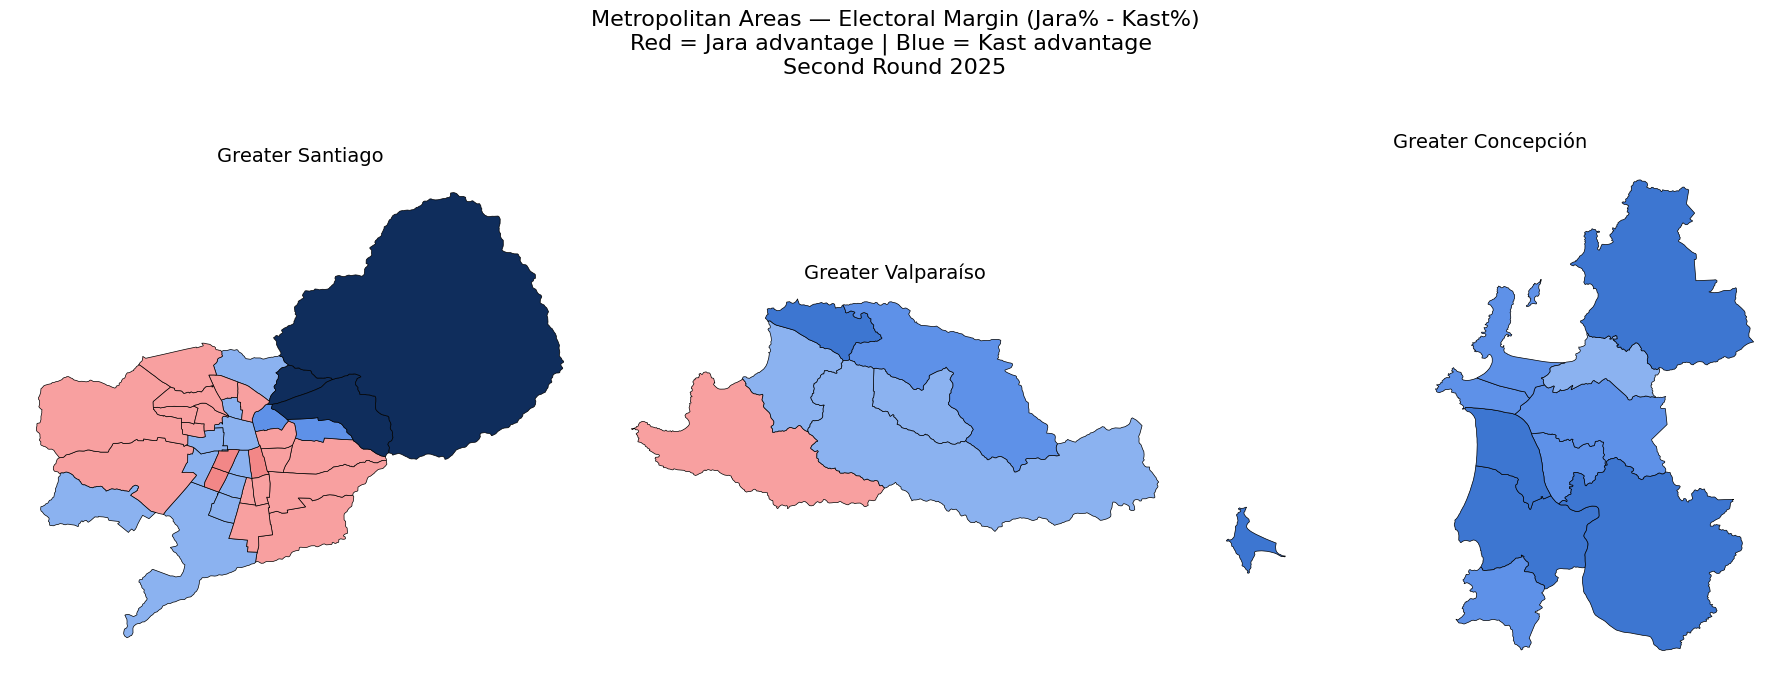

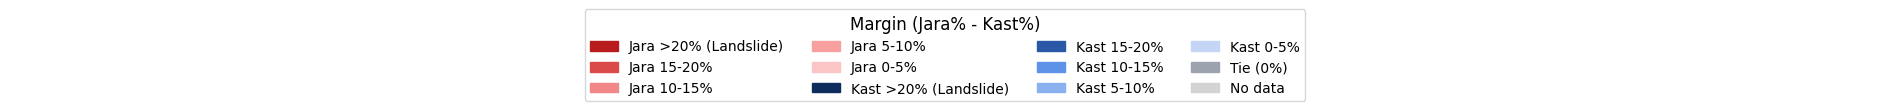

In [30]:
# ============================================================================
# METROPOLITAN AREAS AND CONURBATIONS — MARGIN SCALE (Jara% - Kast%)
# ============================================================================
# This version focuses ONLY on the three main metropolitan areas:
# Greater Santiago, Greater Valparaíso, and Greater Concepción.
# Red tones = Jara advantage, Blue tones = Kast advantage
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import geopandas as gpd

# ---------------------------------------------------------------------------
# 1. MARGIN COLOR FUNCTION (Diverging scale: Red=Jara, Blue=Kast)
# ---------------------------------------------------------------------------

def assign_margin_color(diferencia):
    """
    Assigns hex color based on percentage difference (Jara% - Kast%).
    
    Red tones = Jara advantage (positive difference)
    Blue tones = Kast advantage (negative difference)
    Gray = Tie or No data
    """
    if pd.isna(diferencia):
        return "#D3D3D3"
    
    if diferencia == 0:
        return "#9CA3AF"
    
    if diferencia > 0:  # Jara wins
        if diferencia >= 50:
            return "#B91C1C"      # Very dark red
        elif diferencia >= 40:
            return "#C92A2A"      # Dark red
        elif diferencia >= 30:
            return "#DA4A4A"      # Medium-dark red
        elif diferencia >= 20:
            return "#E86969"      # Medium red
        elif diferencia >= 10:
            return "#F28787"      # Light red
        else:
            return "#F8A0A0"      # Very light red
    else:  # Kast wins (negative difference)
        diferencia_abs = abs(diferencia)
        if diferencia_abs >= 50:
            return "#0F2D5C"      # Very dark blue
        elif diferencia_abs >= 40:
            return "#1A3D7C"      # Dark blue
        elif diferencia_abs >= 30:
            return "#2A58A6"      # Medium-dark blue
        elif diferencia_abs >= 20:
            return "#3D76D1"      # Medium blue
        elif diferencia_abs >= 10:
            return "#5E91E8"      # Light blue
        else:
            return "#8BB2F0"      # Very light blue

# ---------------------------------------------------------------------------
# 2. PREPARE DATA WITH MARGIN CALCULATION
# ---------------------------------------------------------------------------

# Verificar que communes y df_2025_v2 existen
if 'communes' not in dir():
    print("❌ Error: 'communes' no está definido. Ejecuta primero la celda de carga de datos geográficos.")
    
if 'df_2025_v2' not in dir():
    print("❌ Error: 'df_2025_v2' no está definido. Ejecuta primero la celda de carga de datos electorales.")

# Verificar que normalize_commune_name existe
if 'normalize_commune_name' not in dir():
    print("❌ Error: 'normalize_commune_name' no está definida.")
    
communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)

# Prepare second round data with margin
df_votes_v2 = df_2025_v2.copy()
df_votes_v2['commune_norm'] = df_votes_v2['commune'].apply(normalize_commune_name)
df_votes_v2['margin'] = df_votes_v2['jara_pct'] - df_votes_v2['kast_pct']

# Spatial join: merge geometries with margin data
map_data_v2 = communes_map.merge(
    df_votes_v2[['commune_norm', 'margin']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

# Apply color based on margin
map_data_v2['color'] = map_data_v2['margin'].apply(assign_margin_color)

# Exclude island communes
map_data_v2 = map_data_v2[~map_data_v2['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

print("✅ map_data_v2 with margin created successfully")
print(f"   Margin range: {map_data_v2['margin'].min():.2f} to {map_data_v2['margin'].max():.2f}")
print(f"   Total records: {len(map_data_v2)}")
print(f"   Null margins: {map_data_v2['margin'].isna().sum()}")

# ---------------------------------------------------------------------------
# 3. METROPOLITAN AREA DEFINITIONS (Only Santiago, Valparaíso, Concepción)
# ---------------------------------------------------------------------------

GREATER_SANTIAGO = [
    "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
    "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
    "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
    "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
    "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
    "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
    "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
]

GREATER_VALPARAISO = [
    "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
]

GREATER_CONCEPCION = [
    "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
    "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
]

# ---------------------------------------------------------------------------
# 4. GRID LAYOUT (1x3 for the three main metropolitan areas)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Metropolitan Areas — Electoral Margin (Jara% - Kast%)\n'
    'Red = Jara advantage | Blue = Kast advantage \n'
    'Second Round 2025',
    fontsize=16, y=1.02
)

# Define areas with their titles
areas = [
    (GREATER_SANTIAGO, 'Greater Santiago', axes[0]),
    (GREATER_VALPARAISO, 'Greater Valparaíso', axes[1]),
    (GREATER_CONCEPCION, 'Greater Concepción', axes[2]),
]

for commune_list, title, ax in areas:
    norm_set = {normalize_commune_name(c) for c in commune_list}
    area_data = map_data_v2[map_data_v2['NOM_COM_NORM'].isin(norm_set)].copy()
    
    print(f"📍 {title}: {len(area_data)} comunas encontradas")

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{title}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=14)
        ax.set_axis_off()
        continue

    # Plot using margin-based colors
    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 5. LEGEND (Diverging color scale)
# ---------------------------------------------------------------------------
# Crear una figura y un axes explícitamente para la leyenda
fig_legend, ax_legend = plt.subplots(figsize=(19, 1))
fig_legend.patch.set_facecolor('white')
ax_legend.set_facecolor('white')
ax_legend.set_axis_off() 

legend_elements = [
    # Jara advantage (red tones)
    mpatches.Patch(color='#B91C1C', label='Jara >20% (Landslide)'),
    mpatches.Patch(color='#DA4A4A', label='Jara 15-20%'),
    mpatches.Patch(color='#F28787', label='Jara 10-15%'),
    mpatches.Patch(color='#F8A0A0', label='Jara 5-10%'),
    mpatches.Patch(color='#FCC5C5', label='Jara 0-5%'),
    # Kast advantage (blue tones)
    mpatches.Patch(color='#0F2D5C', label='Kast >20% (Landslide)'),
    mpatches.Patch(color='#2A58A6', label='Kast 15-20%'),
    mpatches.Patch(color='#5E91E8', label='Kast 10-15%'),
    mpatches.Patch(color='#8BB2F0', label='Kast 5-10%'),
    mpatches.Patch(color='#C5D5F5', label='Kast 0-5%'),
    # Neutral
    mpatches.Patch(color='#9CA3AF', label='Tie (0%)'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

ax_legend.legend(
    handles=legend_elements, loc='center', ncol=4, fontsize=10,
    title='Margin (Jara% - Kast%)', title_fontsize=12,
)

plt.tight_layout()
plt.show()

#### Hallazgo Principal

Aunque **Kast ganó a nivel nacional con claridad**, el mapa de las principales áreas metropolitanas muestra una **división urbana muy marcada**. Jara mantuvo bastiones importantes en las zonas más densas y populares, mientras Kast dominó los sectores de mayor nivel socioeconómico y periferias.

#### Análisis por Área Metropolitana

1. **Gran Santiago** (el más relevante)
   - **Fuerte polarización interna**:
     - **Oriente (Las Condes, Vitacura, Providencia, Lo Barnechea)**: Azul muy oscuro → Kast arrasó.
     - **Centro y Nororiente**: Azul claro a medio → Ventaja cómoda de Kast.
     - **Sur y Poniente** (Puente Alto, Maipú, La Florida, La Pintana, Cerro Navia, etc.): Rojo y rosa → **Bastiones sólidos de Jara**.
   - Esto confirma que Jara mantuvo el voto popular urbano, mientras Kast capturó el voto de clase media-alta y alta.
2. **Gran Valparaíso**
   - Predominio de tonos azules (Kast), pero con **enclaves rojos** significativos (especialmente en Valparaíso ciudad y algunos sectores de Viña del Mar).
   - Kast ganó la mayoría del área metropolitana, pero Jara conservó apoyo en zonas tradicionales de izquierda.
3. **Gran Concepción**
   - **Dominio casi total de Kast** (azul intenso en casi toda el área).
   - Muy poca resistencia de Jara. Es una de las áreas metropolitanas donde Kast tuvo mejor performance.

## 8. Desempeño Territorial de Jeannette Jara: Fortaleza Urbana y Límites Estructurales


### 8.1. Bastiones de Jeannette Jara: El Chile Urbano-Popular
El análisis de las 36 comunas donde Jeannette Jara alcanzó mayoría absoluta (>50%) revela un patrón de apoyo altamente concentrado que confirma su rol como la candidata del Chile urbano, popular y densamente poblado, pero también evidencia la fragilidad territorial de su coalición. La Región Metropolitana concentra el 58% de sus bastiones (21 comunas), principalmente en sectores populares del sur y poniente de Santiago como Pedro Aguirre Cerda (58,75%), Lo Espejo (56,17%), San Joaquín (55,60%) y Puente Alto (53,75%), donde mantuvo un núcleo duro de apoyo entre clases medias-bajas y sectores de izquierda con alta tradición de organización social y política. El Norte minero aporta 10 comunas —distribuidas entre Antofagasta, Atacama y Coquimbo— donde Jara logró capturar parte del voto que había respaldado a Parisi en primera vuelta, reflejando su capacidad para conectar con demandas laborales y sindicales en zonas extractivas, mientras que Valparaíso contribuye con 5 comunas que incluyen la ciudad-puerto, San Antonio y Viña del Mar, manteniendo algo de la tradición progresista portuaria. Este mapa de mayorías absolutas revela que Jara representa el Chile urbano, popular y denso, con una fortaleza basada en la capacidad de movilizar grandes volúmenes de votos en comunas altamente pobladas, pero con una debilidad estructural en su falta de amplitud territorial: su apoyo quedó confinado a un archipiélago de bastiones urbanos y mineros, altamente dependiente de la Región Metropolitana y sin capacidad de expandirse hacia el Chile rural, provincial o periférico. Esta concentración extrema explica tanto la magnitud de su derrota como la naturaleza vulnerable de su coalición, que fuera de sus enclaves urbanos carece de presencia territorial significativa, lo que constituye un desafío estructural para la izquierda en el mediano plazo.

In [31]:
# ============================================================================
# COMMUNES WHERE JARA ACHIEVED ABSOLUTE MAJORITY (>50%)
# ============================================================================

def analyze_jara_absolute_majority(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies communes where Jara achieved absolute majority (>50%).
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: commune, region, jara_pct, kast_pct
    
    Returns
    -------
    pd.DataFrame
        DataFrame with commune, region, jara_pct, result
    """
    df_filtered = df[df['jara_pct'] > 50].copy()
    df_filtered = df_filtered.sort_values('jara_pct', ascending=False)
    df_filtered['result'] = df_filtered['jara_pct'].apply(
        lambda x: 'Wins in this commune'
    )
    
    return df_filtered[['commune', 'region', 'jara_pct', 'result']]


# Execute analysis
jara_strongholds = analyze_jara_absolute_majority(df_2025_v2)
print(f"Jara achieved absolute majority in {len(jara_strongholds)} communes")
print("\nTop 10 communes:")
jara_strongholds.head(36)

Jara achieved absolute majority in 36 communes

Top 10 communes:


,commune,region,jara_pct,result
299,Juan Fernandez,Valparaíso,59.29,Wins in this commune
252,Pedro Aguirre Cerda,Metropolitana,58.75,Wins in this commune
244,Lo Espejo,Metropolitana,56.17,Wins in this commune
264,San Joaquin,Metropolitana,55.60,Wins in this commune
65,Andacollo,Coquimbo,55.29,Wins in this commune
298,Isla de Pascua,Valparaíso,54.47,Wins in this commune
313,San Antonio,Valparaíso,53.85,Wins in this commune
258,Puente Alto,Metropolitana,53.75,Wins in this commune
275,la Granja,Metropolitana,53.50,Wins in this commune
15,Chañaral,Atacama,53.43,Wins in this commune


#### Hallazgo Principal

Jeannette Jara ganó en **36 comunas** con más del 50% de los votos válidos en varias de ellas. Su apoyo se concentró de manera muy clara en **dos tipos de territorios**:

##### 1. Distribución Geográfica

- **Región Metropolitana (21 comunas)**: Representa el **58%** de sus victorias. Son principalmente comunas populares y de clase media-baja del **sur y poniente** de Santiago:
  - Pedro Aguirre Cerda (58.75%)
  - Lo Espejo (56.17%)
  - San Joaquín (55.60%)
  - Puente Alto (53.75%), La Granja, La Pintana, Lo Prado, Cerro Navia, etc.
- **Valparaíso (5 comunas)**: Incluye Valparaíso ciudad, San Antonio, Viña del Mar (en algunos casos), Isla de Pascua y Juan Fernández.
- **Norte Chico y Norte Grande (10 comunas)**: Andacollo, Illapel (Coquimbo), Chañaral, Diego de Almagro, Huasco (Atacama), Mejillones, María Elena, San Pedro de Atacama (Antofagasta).

##### 2. Características Comunes de sus Bastiones

- **Alta densidad poblacional**: La mayoría son comunas grandes o muy grandes (Puente Alto, Maipú, La Florida, etc.).
- **Perfil socioeconómico popular**: Predominan comunas con altos índices de vulnerabilidad social, vivienda social y clase media-baja.
- **Tradición de izquierda**: Zonas históricamente ligadas a la Concertación/Nueva Mayoría y movimientos sociales.
- **En el Norte**: Comunas mineras con fuerte presencia sindical y tradición de organización laboral. Aquí Jara logró capturar parte del voto que fue de Parisi en primera vuelta.

#### Interpretación Estratégica

Jara logró consolidar un **núcleo duro urbano-popular**, especialmente en el Gran Santiago, donde mantiene fuerte lealtad en sectores de menores ingresos. Sin embargo, su apoyo es **altamente concentrado** y vulnerable: depende en gran medida de la Región Metropolitana.

El hecho de que haya ganado comunas en el Norte (ex bastiones de Parisi) muestra que logró atraer parte del voto antisistema y minero, pero no fue suficiente para competir de igual a igual con Kast en la mayoría del territorio.

**Conclusión**: Jara representa el **Chile urbano, popular y denso**. Su fortaleza radica en la cantidad de votos que puede movilizar en grandes comunas, pero su debilidad es la **falta de amplitud territorial**. Esto explica tanto su derrota como la naturaleza concentrada de su apoyo.

### 8.2. Comunas Competitivas: Las Derrotas Ajustadas de Jeannette Jara
El análisis de las comunas donde Kast ganó por menos de 2 puntos porcentuales revela los territorios más competitivos de la segunda vuelta y las principales vulnerabilidades del candidato de derecha en un mapa que, por lo demás, fue ampliamente favorable a su candidatura. Estas 6 comunas —El Bosque (0,42 pp), Tocopilla (0,62 pp), Freirina (1,28 pp), Estación Central (1,40 pp), Peñaflor (1,68 pp) y El Tabo (1,68 pp)— representan los márgenes más estrechos de toda la elección y se concentran en tres tipos de territorios: la Región Metropolitana aporta 3 comunas populares o de clase media-baja donde Jara estuvo a menos de 2 puntos de ganar (El Bosque, Estación Central y Peñaflor), el Norte minero aporta 2 comunas que habían sido bastiones de Parisi en primera vuelta (Tocopilla y Freirina), donde Jara logró capturar parte del voto antisistema pero no lo suficiente para imponerse, y Valparaíso aporta un enclave costero que refleja la persistencia de la tradición progresista en algunas zonas de la región. La concentración de estas comunas en la Región Metropolitana y el Norte sugiere que las principales oportunidades para la izquierda en futuras elecciones se encuentran en los sectores populares urbanos y en las zonas mineras donde el voto antisistema sigue siendo un factor decisivo. Aunque Jara perdió la elección, estas comunas demuestran que tiene un piso sólido en segmentos clave del electorado y que, con mejoras en movilización o un contexto político más favorable, varias de ellas —especialmente El Bosque y Estación Central, con márgenes de menos de 1,5 puntos— podrían cambiar de manos en el próximo ciclo electoral, convirtiéndose en prioridad estratégica para cualquier campaña de la izquierda y en puntos de atención para la derecha que deberá consolidar su apoyo en estos territorios para mantener su hegemonía territorial.

In [32]:
# ============================================================================
# COMMUNES WHERE JARA ALMOST WON (KAST MARGIN ≤ 2%)
# ============================================================================

def analyze_close_communes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies communes where Kast's margin over Jara is ≤ 2 percentage points.
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: commune, region, jara_pct, kast_pct
    
    Returns
    -------
    pd.DataFrame
        DataFrame with commune, region, jara_pct, kast_pct, kast_margin_pp, competitiveness
    """
    df_filtered = df[df['kast_pct'] > df['jara_pct']].copy()
    df_filtered['kast_margin_pp'] = round(df_filtered['kast_pct'] - df_filtered['jara_pct'], 2)
    df_filtered = df_filtered[df_filtered['kast_margin_pp'] <= 2].copy()
    
    df_filtered['competitiveness'] = df_filtered['kast_margin_pp'].apply(
        lambda x: 'Ultra-tight (<1pp)' if x <= 1 else 'Competitive (1-2pp)'
    )
    
    df_filtered = df_filtered.sort_values('kast_margin_pp', ascending=True)
    
    return df_filtered[['commune', 'region', 'jara_pct', 'kast_pct', 'kast_margin_pp', 'competitiveness']]


# Execute analysis
close_communes = analyze_close_communes(df_2025_v2)
print(f"Jara almost won in {len(close_communes)} communes (margin ≤ 2pp)")
print("\nAll close communes:")
close_communes

Jara almost won in 6 communes (margin ≤ 2pp)

All close communes:


,commune,region,jara_pct,kast_pct,kast_margin_pp,competitiveness
236,El Bosque,Metropolitana,49.79,50.21,0.42,Ultra-tight (<1pp)
8,Tocopilla,Antofagasta,49.69,50.31,0.62,Ultra-tight (<1pp)
18,Freirina,Atacama,49.36,50.64,1.28,Competitive (1-2pp)
238,Estacion Central,Metropolitana,49.30,50.70,1.40,Competitive (1-2pp)
253,Peñaflor,Metropolitana,49.16,50.84,1.68,Competitive (1-2pp)
296,El Tabo,Valparaíso,49.16,50.84,1.68,Competitive (1-2pp)


#### Hallazgo Principal

Jara perdió varias comunas por **márgenes extremadamente estrechos**. La tabla muestra las comunas donde Kast ganó por menos de 2 puntos porcentuales, lo que las convierte en **altamente competitivas** y potenciales objetivos para futuras elecciones.

#### Tabla Resumida

| Comuna           | Región        | Jara % | Kast % | Margen Kast | Nivel de Competitividad |
| ---------------- | ------------- | ------ | ------ | ----------- | ----------------------- |
| El Bosque        | Metropolitana | 49.79  | 50.21  | 0.42 pp     | **Ultra-ajustada**      |
| Tocopilla        | Antofagasta   | 49.69  | 50.31  | 0.62 pp     | **Ultra-ajustada**      |
| Freirina         | Atacama       | 49.36  | 50.64  | 1.28 pp     | Competitiva             |
| Estación Central | Metropolitana | 49.30  | 50.70  | 1.40 pp     | Competitiva             |
| Peñaflor         | Metropolitana | 49.16  | 50.84  | 1.68 pp     | Competitiva             |
| El Tabo          | Valparaíso    | 49.16  | 50.84  | 1.68 pp     | Competitiva             |

#### Interpretación Estratégica

1. **Concentración en la RM**:
   - 3 de las 6 comunas más ajustadas están en la Región Metropolitana (El Bosque, Estación Central, Peñaflor). Son comunas populares o de clase media-baja donde Jara estuvo muy cerca de ganar.
2. **Presencia en el Norte**:
   - **Tocopilla** (Antofagasta) y **Freirina** (Atacama) son comunas mineras donde Parisi fue fuerte en primera vuelta. Jara estuvo muy cerca, lo que muestra que logró capturar parte del voto antisistema, pero no suficiente para ganar.
3. **Valparaíso**:
   - El Tabo representa un enclave costero donde la competencia fue muy estrecha.

#### Conclusión

Estas comunas representan las **vulnerabilidades de Kast** y las **oportunidades de Jara**. Aunque perdió la elección, Jara demostró que tiene un piso sólido en sectores populares de la RM y en algunas zonas mineras del Norte. Con mejoras en movilización o un contexto más favorable, varias de estas comunas (especialmente El Bosque y Estación Central) podrían cambiar de manos en futuras elecciones.

**Recomendación**: Estas 6 comunas deberían ser prioridad estratégica para cualquier campaña de la izquierda en el próximo ciclo electoral.

### 8.3. Comunas Competitivas: Las Oportunidades Perdidas de Jara
El análisis de las comunas donde Jara perdió por menos de 5 puntos porcentuales confirma la naturaleza altamente concentrada y vulnerable de su apoyo electoral, al identificar solo 17 comunas donde la candidata oficialista tuvo opciones reales de victoria —un número exiguo que representa apenas el 4,9% del total nacional y que evidencia la amplitud del dominio territorial de Kast. El 70% de estas comunas competitivas se concentran en la macrozona Centro, principalmente en la Región Metropolitana y Valparaíso, donde Jara logró sus mejores performances relativas en comunas populares de Santiago como El Bosque, Estación Central y Peñaflor, reflejando que su núcleo duro de apoyo se mantiene en los sectores urbanos y densamente poblados del centro del país. El Norte aporta 5 comunas competitivas —distribuidas entre el Norte Grande y el Norte Chico— donde Jara logró capturar parte del voto que había sido de Parisi en primera vuelta, especialmente en comunas mineras como Tocopilla y Freirina, pero sin conseguir imponerse en la mayoría de esos territorios. La ausencia total de comunas competitivas en el Centro Sur, Sur y Patagonia confirma que en estas macrozonas Kast ganó con márgenes amplios y consolidó un dominio sin contrapeso, estableciendo una base territorial sólida que la izquierda no logró desafiar en ningún punto del Chile rural, provincial o austral. Este patrón —que reduce a Jara a defender un puñado de bastiones urbanos mientras Kast controla holgadamente el resto del país— explica tanto la magnitud de la derrota como la naturaleza concentrada y vulnerable del apoyo a la izquierda, que fuera de la Región Metropolitana y algunos enclaves del Norte carece de presencia territorial significativa.



COMUNAS DONDE JARA PERDIÓ POR MARGEN <5% - POR ZONA GEOGRÁFICA



macrozone,Norte Grande,Norte Chico,Centro,Centro Sur,Sur,Patagonia,TOTAL
margin_range,,,,,,,
0-1%,1,0,1,0,0,0,2
1-2%,0,1,3,0,0,0,4
2-3%,0,0,4,0,0,0,4
3-4%,1,1,1,0,0,0,3
4-5%,0,1,3,0,0,0,4
TOTAL,2,3,12,0,0,0,17


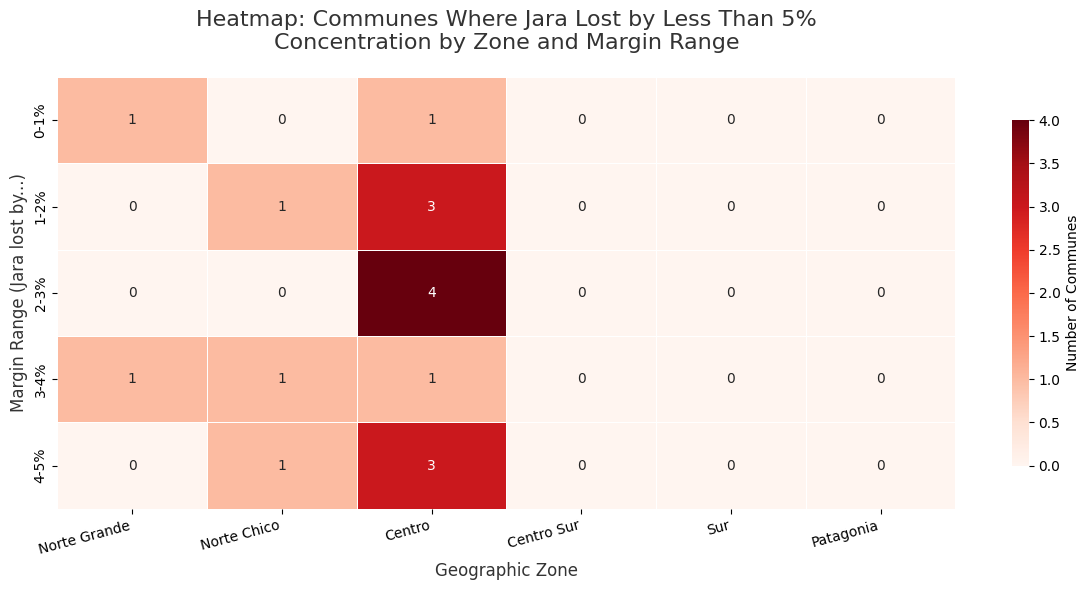

In [33]:
# ============================================================================
# JARA'S NARROW LOSSES BY GEOGRAPHIC ZONE
# ============================================================================

# ---------------------------------------------------------------------------
# 1. CALCULAR MARGEN Y AGREGAR ZONA
# ---------------------------------------------------------------------------

# Calcular margen (Jara% - Kast%) - valores negativos = pierde Jara
df_2025_v2['margin'] = df_2025_v2['jara_pct'] - df_2025_v2['kast_pct']

# Filtrar comunas donde Jara perdió por menos de 5% (margen entre -5 y 0)
df_narrow = df_2025_v2[
    (df_2025_v2['margin'] < 0) & 
    (df_2025_v2['margin'] >= -5)
].copy()
df_narrow['margin_abs'] = df_narrow['margin'].abs()

# Agregar zona geográfica
df_narrow = df_narrow.merge(
    df_region_dim[['region', 'macrozone']],
    on='region',
    how='left'
)

# ---------------------------------------------------------------------------
# 2. CREAR RANGOS DE MARGEN
# ---------------------------------------------------------------------------

def get_margin_range(margin_abs):
    if margin_abs < 1:
        return '0-1%'
    elif margin_abs < 2:
        return '1-2%'
    elif margin_abs < 3:
        return '2-3%'
    elif margin_abs < 4:
        return '3-4%'
    else:
        return '4-5%'

df_narrow['margin_range'] = df_narrow['margin_abs'].apply(get_margin_range)

# ---------------------------------------------------------------------------
# 3. CREAR TABLA DE CONTINGENCIA (ZONA vs RANGO)
# ---------------------------------------------------------------------------

# Orden de zonas (norte a sur)
zone_order = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur', 'Patagonia']

# Orden de rangos
range_order = ['0-1%', '1-2%', '2-3%', '3-4%', '4-5%']

# Crear tabla pivote
pivot_table = pd.crosstab(
    df_narrow['margin_range'],
    df_narrow['macrozone'],
    dropna=False
)

# Reordenar índices y columnas
pivot_table = pivot_table.reindex(index=range_order, columns=zone_order, fill_value=0)

# Agregar fila de total por zona
pivot_table.loc['TOTAL'] = pivot_table.sum(axis=0)

# Agregar columna de total por rango
pivot_table['TOTAL'] = pivot_table.sum(axis=1)

# ---------------------------------------------------------------------------
# 4. MOSTRAR SOLO LA TABLA PRINCIPAL
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("COMUNAS DONDE JARA PERDIÓ POR MARGEN <5% - POR ZONA GEOGRÁFICA")
print("=" * 80)
print()
display(pivot_table)
print()
print("=" * 80)

# ---------------------------------------------------------------------------
# 5. HEATMAP VISUALIZATION
# ---------------------------------------------------------------------------

def plot_narrow_losses_heatmap(pivot_table: pd.DataFrame) -> None:
    """
    Creates a heatmap showing the concentration of narrow losses.
    """
    # Remove TOTAL row and column for plotting
    plot_df = pivot_table.drop(index='TOTAL', errors='ignore').drop(columns='TOTAL', errors='ignore')
    
    # Order of zones (north to south)
    zone_order = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur', 'Patagonia']
    zones = [zone for zone in zone_order if zone in plot_df.columns]
    plot_df = plot_df[zones]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    
    # Create heatmap with a clean red palette
    sns.heatmap(
        plot_df,
        annot=True,
        fmt='g',
        cmap='Reds',
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        cbar_kws={'label': 'Number of Communes', 'shrink': 0.8}
    )
    
    ax.set_xlabel('Geographic Zone', fontsize=12, color='#333333')
    ax.set_ylabel('Margin Range (Jara lost by...)', fontsize=12, color='#333333')
    ax.set_title(
        'Heatmap: Communes Where Jara Lost by Less Than 5%\n'
        'Concentration by Zone and Margin Range',
        fontsize=16, pad=20, color='#333333',
    )
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=15, ha='right')
    
    plt.tight_layout()
    plt.show()


# Execute the heatmap
plot_narrow_losses_heatmap(pivot_table)

#### Hallazgo Principal

Jara compitió de forma estrecha (perdiendo por menos de 5 puntos porcentuales) en solo **17 comunas** a nivel nacional. Esto refuerza que su apoyo fue **altamente concentrado** y que Kast dominó con holgura en la gran mayoría del territorio.

#### Interpretación Estratégica

- **El Centro como Campo de Batalla**: El **70%** de las comunas competitivas están en la macrozona Centro (principalmente Región Metropolitana y Valparaíso). Aquí Jara tuvo sus mejores performances relativas, especialmente en comunas populares de Santiago.
- **Presencia Residual en el Norte**: Las 5 comunas competitivas en el Norte (Grande + Chico) indican que Jara logró capturar parte del voto que fue de Parisi en primera vuelta, pero no lo suficiente para ganar la mayoría de esos territorios.
- **Ausencia Total en el Sur**: En Centro Sur, Sur y Patagonia no hubo ninguna comuna donde Jara estuviera cerca. Kast ganó con márgenes amplios, lo que muestra un **dominio consolidado** en esas zonas.

#### Conclusión

Jara solo tuvo opciones reales de victoria en un **número muy reducido de comunas** (17), concentradas principalmente en el **Centro urbano**. Fuera de esta zona, Kast ganó con comodidad. Esto explica tanto su derrota como la naturaleza **concentrada y vulnerable** de su apoyo electoral.

Este dato es clave: la izquierda quedó reducida a defender un puñado de bastiones urbanos, mientras la derecha consolidó un amplio control territorial.

### 8.4. Distribución de las Comunas Competitivas: El Frente de Batalla en el Centro
La distribución de las 17 comunas donde Jara compitió de forma estrecha (perdiendo por menos de 5 puntos porcentuales) revela una concentración abrumadora en la macrozona Centro, que concentró el 70,6% (12 comunas) de estos territorios competitivos, confirmando que la batalla real de la segunda vuelta se libró casi exclusivamente en la Región Metropolitana y Valparaíso, donde Jara logró sus mejores performances relativas en comunas populares como El Bosque, Estación Central y Peñaflor. El Norte Chico aportó el 17,6% (3 comunas) y el Norte Grande el 11,8% (2 comunas), reflejando una presencia limitada pero significativa en enclaves mineros donde Jara capturó parte del voto que había sido de Parisi en primera vuelta. La ausencia total de comunas competitivas en el Centro Sur, Sur y Patagonia confirma que en estas macrozonas Kast ganó con márgenes cómodos o amplios, consolidando un dominio territorial sin contrapeso en el Chile rural, provincial y austral. El desglose interno del Centro muestra que la mayor concentración de comunas competitivas se encuentra en el rango de 2-3 puntos porcentuales (33,3%), seguido del rango 1-2% (25%) y una minoría ultra-ajustada en el rango 0-1% (8,3%), lo que indica que incluso en su principal frente de batalla, la mayoría de las comunas donde Jara fue competitiva presentaban márgenes que requerían un esfuerzo significativo para ser revertidos. Este patrón refuerza el diagnóstico general de la elección: Kast dominó territorialmente casi todo el país, mientras Jara se defendió en un número reducido de comunas densamente pobladas del Centro, evidenciando que la izquierda quedó reducida a defender un puñado de bastiones urbanos mientras la derecha consolidó un amplio control territorial que le otorga una base geográfica sólida para gobernar.


DISTRIBUCIÓN PORCENTUAL POR ZONA (columnas suman 100% dentro de cada zona)



macrozone,Norte Grande,Norte Chico,Centro,Centro Sur,Sur,Patagonia
margin_range,,,,,,
0-1%,50.0,0.0,8.3,0.0,0.0,0.0
1-2%,0.0,33.3,25.0,0.0,0.0,0.0
2-3%,0.0,0.0,33.3,0.0,0.0,0.0
3-4%,50.0,33.3,8.3,0.0,0.0,0.0
4-5%,0.0,33.3,25.0,0.0,0.0,0.0


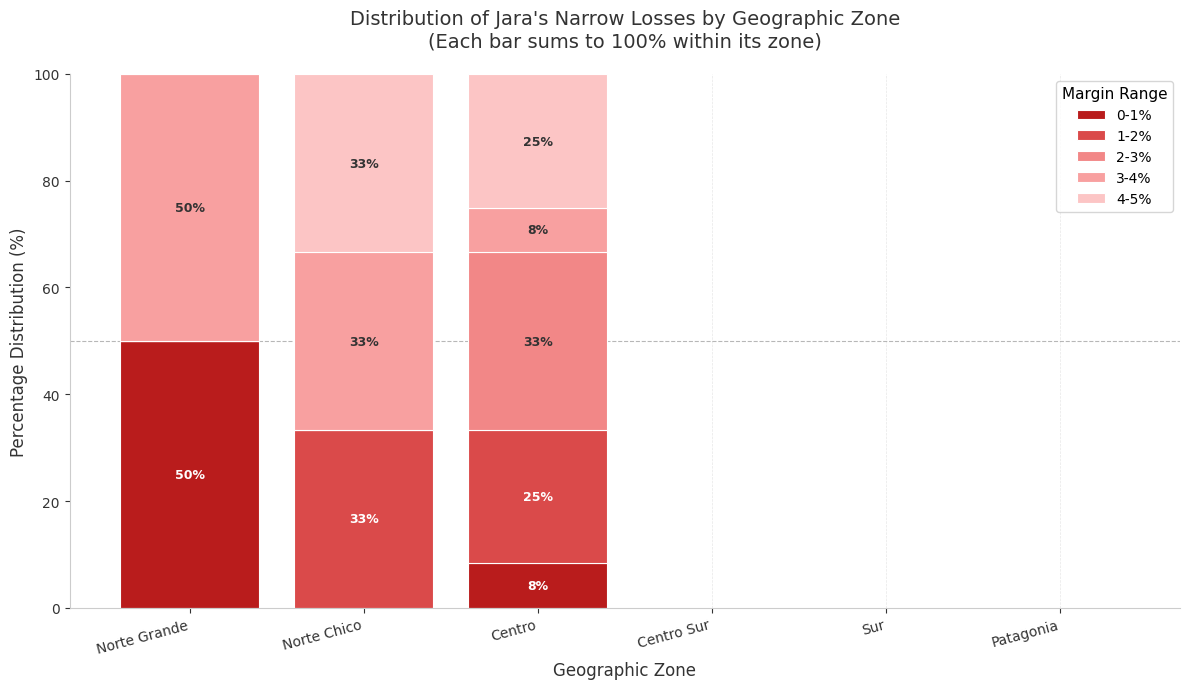

In [34]:
# ============================================================================
# DISTRIBUCIÓN PORCENTUAL POR ZONA 
# ============================================================================

# Muestra la distribución porcentual de márgenes dentro de cada zona
# (cada columna suma 100%)


# ---------------------------------------------------------------------------
# 1. RECALCULAR TABLA PORCENTUAL (columnas suman 100%)
# ---------------------------------------------------------------------------

# Usar la misma pivot_table del análisis anterior
# Calcular porcentaje por columna (zona) - CADA COLUMNA SUMA 100%
pct_by_zone = pivot_table.drop(index='TOTAL', errors='ignore').drop(columns='TOTAL', errors='ignore')
pct_by_zone = pct_by_zone.div(pct_by_zone.sum(axis=0), axis=1) * 100
pct_by_zone = pct_by_zone.round(1).fillna(0)

# Reordenar zonas de norte a sur
zone_order = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur', 'Patagonia']
zones = [zone for zone in zone_order if zone in pct_by_zone.columns]
pct_by_zone = pct_by_zone[zones]

# ---------------------------------------------------------------------------
# 2. MOSTRAR TABLA PORCENTUAL
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("DISTRIBUCIÓN PORCENTUAL POR ZONA (columnas suman 100% dentro de cada zona)")
print("=" * 80)
print()
display(pct_by_zone)
print()
print("=" * 80)

# ---------------------------------------------------------------------------
# 3. GRÁFICO DE BARRAS APILADAS (STACKED BAR CHART)
# ---------------------------------------------------------------------------

def plot_stacked_margin_bars(pct_df: pd.DataFrame) -> None:
    """
    Creates a stacked bar chart showing the distribution of margin ranges by zone.
    Each bar sums to 100%, showing the composition of narrow losses across
    different geographic zones.

    Parameters
    ----------
    pct_df : pd.DataFrame
        DataFrame with margin ranges as index and zones as columns,
        containing percentage values that sum to 100% per column.
    """
    # Definir colores para cada rango de margen
    margin_colors = {
        '0-1%': '#B91C1C',      # Dark red (most urgent)
        '1-2%': '#DA4A4A',      # Medium-dark red
        '2-3%': '#F28787',      # Medium red
        '3-4%': '#F8A0A0',      # Light red
        '4-5%': '#FCC5C5'       # Very light red (least urgent)
    }
    
    # Definir colores de texto según el color de fondo
    def get_text_color(background_color, value):
        """Return white or black based on background color and value threshold"""
        if background_color == '#FCC5C5':  # Very light red
            return '#333333'  # Negro
        elif background_color == '#F8A0A0':  # Light red
            return '#333333'  # Negro
        elif background_color == '#F28787':  # Medium red
            return '#333333'  # Negro
        elif background_color == '#DA4A4A':  # Medium-dark red
            return 'white'
        elif background_color == '#B91C1C':  # Dark red
            return 'white'
        else:
            return 'white' if value > 20 else '#333333'
    
    # Reordenar rangos (de más estrecho a más amplio)
    range_order = ['0-1%', '1-2%', '2-3%', '3-4%', '4-5%']
    colors = [margin_colors[r] for r in range_order if r in pct_df.index]
    plot_df = pct_df.reindex(range_order)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Crear barras apiladas
    bottom = np.zeros(len(plot_df.columns))
    
    for margin_range in range_order:
        if margin_range in plot_df.index:
            values = plot_df.loc[margin_range].values
            bars = ax.bar(
                plot_df.columns,
                values,
                bottom=bottom,
                label=margin_range,
                color=margin_colors[margin_range],
                edgecolor='white',
                linewidth=0.8,
                zorder=2
            )
            bottom += values
    
    # Añadir etiquetas de porcentaje dentro de las barras (solo para valores significativos)
    for i, zone in enumerate(plot_df.columns):
        cumulative = 0
        for margin_range in range_order:
            if margin_range in plot_df.index:
                value = plot_df.loc[margin_range, zone]
                if value > 8:  # Mostrar solo valores >8% para no saturar
                    bg_color = margin_colors[margin_range]
                    text_color = get_text_color(bg_color, value)
                    ax.text(
                        i, cumulative + value/2,
                        f'{value:.0f}%',
                        ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color=text_color,
                        zorder=3
                    )
                cumulative += value
    
    # Labels and title
    ax.set_xlabel('Geographic Zone', fontsize=12, color='#333333')
    ax.set_ylabel('Percentage Distribution (%)', fontsize=12, color='#333333')
    ax.set_title(
        'Distribution of Jara\'s Narrow Losses by Geographic Zone\n'
        '(Each bar sums to 100% within its zone)',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Add reference line at 50%
    ax.axhline(y=50, color='#999999', linestyle='--', linewidth=0.8, alpha=0.7, zorder=1)
    
    # Customize legend
    ax.legend(
        title='Margin Range',
        title_fontsize=11,
        loc='upper right',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc'
    )
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    plt.xticks(rotation=15, ha='right')
    
    plt.tight_layout()
    plt.show()

# Ejecutar gráficos
plot_stacked_margin_bars(pct_by_zone)


#### Hallazgo Principal

De las **17 comunas** donde Jara compitió de forma estrecha (perdiendo por menos de 5 puntos porcentuales), el **70,6%** se concentraron en la **Macrozona Centro**. El Norte aportó solo una minoría de casos competitivos.

#### Distribución Porcentual por Macrozona

| Macrozona        | % de Comunas Competitivas | Cantidad | Interpretación              |
| ---------------- | ------------------------- | -------- | --------------------------- |
| **Centro**       | **70,6%**                 | 12       | Principal frente de batalla |
| **Norte Chico**  | 17,6%                     | 3        | Competencia moderada        |
| **Norte Grande** | 11,8%                     | 2        | Presencia limitada          |
| Centro Sur       | 0%                        | 0        | Dominio total de Kast       |
| Sur              | 0%                        | 0        | Dominio total de Kast       |
| Patagonia        | 0%                        | 0        | Dominio total de Kast       |

#### Desglose Interno del Centro (12 comunas)

- 8,3% con margen **0-1%** (ultra-ajustadas)
- 25,0% con margen **1-2%**
- 33,3% con margen **2-3%** (la mayor concentración)
- El resto entre 3-5%

#### Conclusión Estratégica

Esta tabla confirma que la **batalla real** de la segunda vuelta se dio casi exclusivamente en la **Macrozona Centro** (especialmente Región Metropolitana y Valparaíso). Fuera de esta zona, Kast ganó con márgenes cómodos o amplios.

Jara logró mantener competitividad solo en:

- Su núcleo urbano-popular del Gran Santiago
- Algunos enclaves mineros del Norte Chico y Norte Grande

Esto refuerza el patrón general de la elección: **Kast dominó territorialmente** casi todo el país, mientras **Jara se defendió** en un número reducido de comunas densamente pobladas del Centro.

### 8.5. Los Flips de Jara: Captura Parcial del Voto Antisistema en el Norte
El análisis de las comunas donde Jara logró revertir el resultado entre la primera y segunda vuelta revela uno de los pocos logros territoriales claros de su campaña: 6 comunas del Norte —todas ellas bastiones de Franco Parisi en primera vuelta— donde la candidata oficialista logró swings de entre +18,8 y +28,2 puntos porcentuales, suficientes para imponerse sobre Kast en la instancia definitoria. Estas comunas, distribuidas entre Antofagasta (María Elena, Mejillones, San Pedro de Atacama) y Atacama (Diego de Almagro, Chañaral, Huasco), comparten un perfil común: son enclaves mineros con fuerte tradición sindical, presencia de trabajadores del sector extractivo y una identidad regionalista marcada por el sentimiento de abandono del centralismo, características que las convirtieron en territorios fértiles para el voto antisistema en primera vuelta y para la captura de ese electorado por parte de Jara en segunda vuelta. Los swings excepcionalmente altos —María Elena lidera con +28,2 puntos, seguida de Mejillones con +24,4 y Diego de Almagro con +22,7— indican una transferencia masiva de votos desde Parisi hacia Jara en estas comunas, lo que sugiere que la candidata oficialista logró conectar con las demandas laborales y sindicales del mundo minero, presentándose como una alternativa viable para un electorado que en primera vuelta había optado por la protesta antisistema. Sin embargo, estos 6 flips representan excepciones en un contexto más amplio donde Jara no logró revertir la mayoría de los bastiones de Parisi, y donde Kast terminó imponiéndose en la gran mayoría de las comunas del Norte, confirmando que la transferencia del voto antisistema hacia la izquierda fue exitosa solo en enclaves específicos con alta densidad sindical y tradición de organización laboral, pero insuficiente para cambiar el rumbo general de la elección.


COMUNAS DONDE JARA PERDIÓ EN PRIMERA VUELTA Y GANÓ EN SEGUNDA



,commune,region,winner_first_round,jara_pct_1v,jara_pct_2v,jara_swing_pp
2,Maria Elena,Antofagasta,Parisi,22.27,50.47,28.20
3,Mejillones,Antofagasta,Parisi,26.99,51.42,24.43
17,Diego de Almagro,Atacama,Parisi,30.65,53.35,22.70
15,Chañaral,Atacama,Parisi,30.99,53.43,22.44
19,Huasco,Atacama,Parisi,30.20,51.98,21.78
5,San Pedro de Atacama,Antofagasta,Parisi,31.88,50.68,18.80


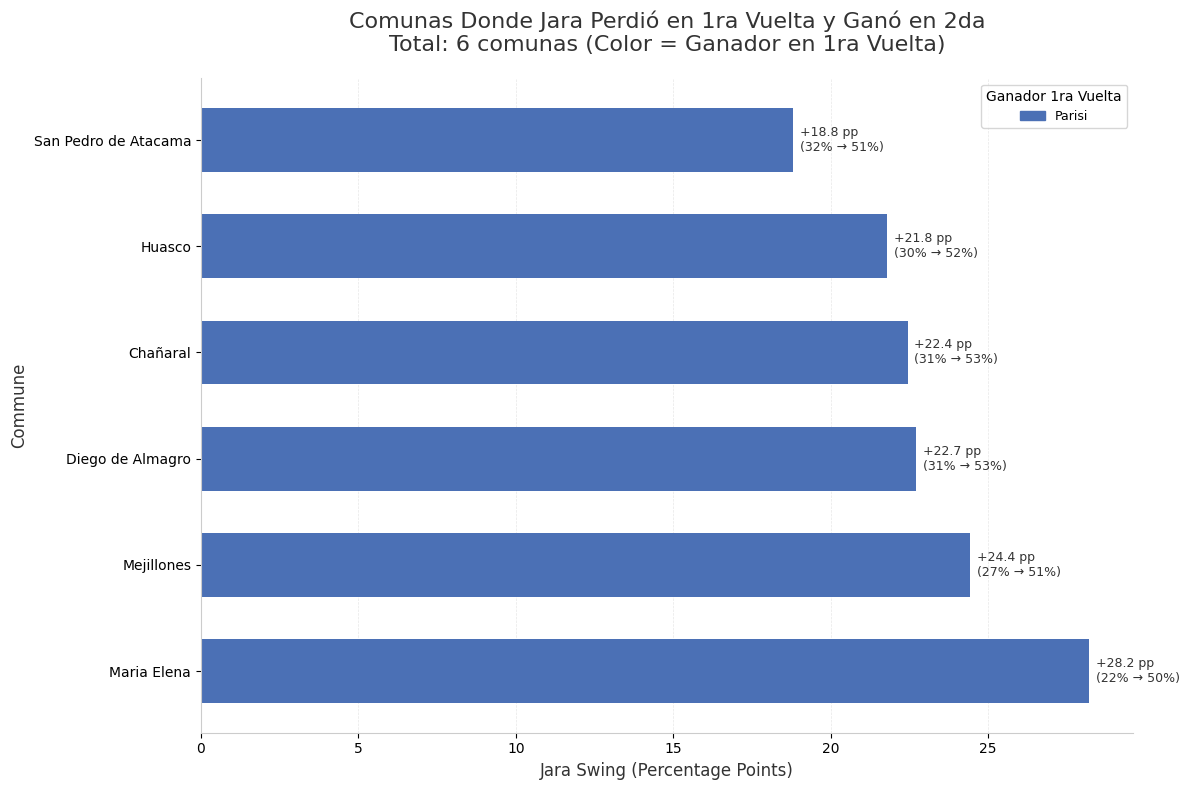

In [35]:
# ============================================================================
# COMMUNES WHERE JARA LOST IN FIRST ROUND BUT WON IN SECOND ROUND
# ============================================================================
# Objective: Identify communes that flipped from anti-Jara to pro-Jara
# Context: Reveals voter migration and campaign effectiveness

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------------------
# 1. DETERMINE WINNERS FOR BOTH ROUNDS
# ---------------------------------------------------------------------------

# First round winners (considering all 8 candidates)
candidate_cols = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 
                  'matthei_pct', 'mayne_nicholls_pct', 'enriquez_ominami_pct', 'artes_pct']
candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei', 
                   'Mayne Nicholls', 'Enríquez Ominami', 'Artes']

# Find first round winner per commune
df_first = df_2025_v1.copy()
df_first['winner_first_round'] = df_first[candidate_cols].idxmax(axis=1)
winner_mapping = dict(zip(candidate_cols, candidate_names))
df_first['winner_first_round'] = df_first['winner_first_round'].map(winner_mapping)

# Find second round winner per commune
df_second = df_2025_v2.copy()
df_second['winner_second_round'] = 'Kast'
df_second.loc[df_second['jara_pct'] > df_second['kast_pct'], 'winner_second_round'] = 'Jara'
df_second.loc[df_second['jara_pct'] == df_second['kast_pct'], 'winner_second_round'] = 'Tie'

# ---------------------------------------------------------------------------
# 2. IDENTIFY FLIPPED COMMUNES (Jara lost 1st, won 2nd)
# ---------------------------------------------------------------------------

# Merge both rounds
df_flipped = df_first.merge(
    df_second[['commune', 'jara_pct', 'kast_pct', 'winner_second_round']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calculate swing
df_flipped['jara_swing_pp'] = round(df_flipped['jara_pct_2v'] - df_flipped['jara_pct_1v'], 2)

# Filter: Jara lost first round, won second round
df_flipped = df_flipped[
    (df_flipped['winner_first_round'] != 'Jara') & 
    (df_flipped['winner_second_round'] == 'Jara')
].copy()

# Sort by swing
df_flipped = df_flipped.sort_values('jara_swing_pp', ascending=False)

# ---------------------------------------------------------------------------
# 3. MOSTRAR TABLA
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("COMUNAS DONDE JARA PERDIÓ EN PRIMERA VUELTA Y GANÓ EN SEGUNDA")
print("=" * 80)
print()

# Seleccionar columnas para mostrar
display_cols = ['commune', 'region', 'winner_first_round', 'jara_pct_1v', 'jara_pct_2v', 'jara_swing_pp']

# to_string() → display()
display(df_flipped[display_cols])

print()
print("=" * 80)

# ---------------------------------------------------------------------------
# 4. GRÁFICO: Top comunas volteadas (barras horizontales)
# ---------------------------------------------------------------------------

def plot_flipped_communes(df: pd.DataFrame) -> None:
    """
    Creates a horizontal bar chart showing communes where Jara flipped the result.
    """
    plot_df = df.copy()
    
    # Colores por ganador de primera vuelta
    winner_colors = {
        'Parisi': '#4B70B5',
        'Kast': '#35466D',
        'Kaiser': '#F3832C',
        'Matthei': '#226FD4',
    }
    plot_df['color'] = plot_df['winner_first_round'].map(winner_colors).fillna('#D3D3D3')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    bars = ax.barh(
        plot_df['commune'],
        plot_df['jara_swing_pp'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.6,
        zorder=2
    )
    
    # Etiquetas
    for bar, swing, jara_1v, jara_2v in zip(bars, plot_df['jara_swing_pp'], 
                                              plot_df['jara_pct_1v'], plot_df['jara_pct_2v']):
        ax.annotate(
            f'+{swing:.1f} pp\n({jara_1v:.0f}% → {jara_2v:.0f}%)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=9, color='#333333', zorder=3
        )
    
    ax.set_xlabel('Jara Swing (Percentage Points)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Comunas Donde Jara Perdió en 1ra Vuelta y Ganó en 2da\n'
        f'Total: {len(df)} comunas (Color = Ganador en 1ra Vuelta)',
        fontsize=16, pad=20, color='#333333'
    )
    
    # Leyenda
    legend_elements = [mpatches.Patch(color=color, label=winner) 
                       for winner, color in winner_colors.items() 
                       if winner in plot_df['winner_first_round'].values]
    if legend_elements:
        ax.legend(handles=legend_elements, loc='upper right', title='Ganador 1ra Vuelta',
                  fontsize=9, frameon=True, facecolor='white', edgecolor='#cccccc')
    
    plt.tight_layout()
    plt.show()


# Ejecutar gráfico
plot_flipped_communes(df_flipped)

#### Hallazgo Principal

Jara logró **6 flips** importantes: comunas que perdió en primera vuelta (todas ganadas por **Franco Parisi**) pero ganó en segunda vuelta. Todas estas comunas están en el **Norte** de Chile (Antofagasta y Atacama).

#### Detalle de los Flips

| Comuna               | Región      | Swing Jara (pp) | 1ª Vuelta (Parisi) | 2ª Vuelta (Jara) |
| -------------------- | ----------- | --------------- | ------------------ | ---------------- |
| Maria Elena          | Antofagasta | **+28.2**       | 22% → 50%          | Victoria clara   |
| Mejillones           | Antofagasta | +24.4           | 27% → 51%          | Victoria clara   |
| Diego de Almagro     | Atacama     | +22.7           | 31% → 53%          | Victoria clara   |
| Chañaral             | Atacama     | +22.4           | 31% → 53%          | Victoria clara   |
| Huasco               | Atacama     | +21.8           | 30% → 52%          | Victoria clara   |
| San Pedro de Atacama | Antofagasta | +18.8           | 32% → 51%          | Victoria clara   |

#### Interpretación Estratégica

- **Todas fueron bastiones de Parisi** en primera vuelta. Esto demuestra que Jara logró capturar una parte significativa del **voto antisistema nortino**.
- Los swings son **muy altos** (entre +18.8 y +28.2 puntos porcentuales), lo que indica una fuerte transferencia de votos desde Parisi hacia Jara en estas comunas.
- **Perfil común**: Comunas mineras (cobre, salitre), con fuerte tradición sindical y presencia de trabajadores del sector extractivo. Muchas tienen una identidad regionalista fuerte y sentimiento de abandono por el centralismo.

#### Conclusión

Estos 6 flips son uno de los pocos logros claros de Jara en la segunda vuelta. Demuestran que en **comunas mineras del Norte** logró atraer parte del voto que fue antisistema en primera vuelta. Sin embargo, fueron excepciones: en la mayoría de los bastiones de Parisi, Kast terminó ganando o Jara no logró revertir el resultado.

Esto sugiere que Jara tuvo éxito parcial en capturar voto útil de izquierda y sindical en el Norte, pero no fue suficiente para cambiar el rumbo general de la elección.

### 8.6. Retención de Votos de Jara: Ninguna Pérdida entre Primera y Segunda Vuelta
El análisis del comportamiento electoral de Jara entre la primera y segunda vuelta revela un hallazgo contraintuitivo y políticamente relevante: la candidata oficialista **no perdió votos en ninguna comuna del país**, manteniendo o aumentando su votación absoluta en el 100% de los territorios entre ambas rondas, un comportamiento inusual en un balotaje donde normalmente algunos votantes de primera vuelta se desmovilizan o cambian de opción. Este resultado confirma una **alta lealtad de su base** —el electorado que la respaldó en primera vuelta (26,75%) se mantuvo muy fiel, prácticamente sin fugas hacia Kast ni hacia la abstención o el voto nulo en términos absolutos— y una **buena transferencia interna** que le permitió retener casi todo su voto original y sumar algunos votos adicionales provenientes de MEO, Artes y parte del electorado de Parisi, especialmente en los enclaves mineros del Norte donde logró los flips que analizamos anteriormente. Este desempeño defensivo, sin embargo, no fue suficiente para cambiar el rumbo de la elección: aunque Jara demostró una base muy leal y disciplinada, su techo electoral estaba limitado y no logró expandir su apoyo más allá de los bastiones urbanos y mineros que ya controlaba, mientras Kast sumaba masivamente desde Parisi, Matthei, Kaiser y nuevos votantes, creciendo en volumen y porcentaje de manera mucho más significativa. En síntesis, Jara defendió muy bien su base —un logro estratégico en sí mismo— pero no logró expandirla, y su campaña, aunque exitosa en términos de retención, resultó insuficiente frente a la capacidad de Kast para articular una coalición más amplia y capturar el voto antisistema y de derecha fragmentada que había estado disperso en primera vuelta.

In [36]:
# ============================================================================
# COMMUNES WHERE JARA LOST VOTES (1ST ROUND → 2ND ROUND)
# ============================================================================

# ---------------------------------------------------------------------------
# 1. CALCULAR DIFERENCIA DE VOTOS (JARA V2 - JARA V1)
# ---------------------------------------------------------------------------

# Merge first and second round data
df_jara_change = df_2025_v1[['commune', 'region', 'jara_votes']].copy()
df_jara_change = df_jara_change.merge(
    df_2025_v2[['commune', 'jara_votes']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calculate vote difference (negative = Jara lost votes)
df_jara_change['jara_vote_change'] = df_jara_change['jara_votes_2v'] - df_jara_change['jara_votes_1v']
df_jara_change['jara_pct_change'] = round(
    (df_jara_change['jara_votes_2v'] - df_jara_change['jara_votes_1v']) / 
    df_jara_change['jara_votes_1v'] * 100, 1
)

# Identify communes where Jara lost votes (negative change)
df_jara_loss = df_jara_change[df_jara_change['jara_vote_change'] < 0].copy()
df_jara_loss = df_jara_loss.sort_values('jara_vote_change', ascending=True)  # Most negative first

# ---------------------------------------------------------------------------
# 2. MOSTRAR TABLA DE COMUNAS DONDE JARA RETROCEDIÓ
# ---------------------------------------------------------------------------

print("\n" + "=" * 90)
print("COMUNAS DONDE JARA RETROCEDIÓ (PERDIÓ VOTOS ENTRE PRIMERA Y SEGUNDA VUELTA)")
print("=" * 90)
print()

if len(df_jara_loss) > 0:
    display_cols = ['commune', 'region', 'jara_votes_1v', 'jara_votes_2v', 'jara_vote_change', 'jara_pct_change']
    print(df_jara_loss[display_cols].to_string(index=False))
    print()
    print(f"📊 TOTAL DE COMUNAS CON RETROCESO: {len(df_jara_loss)} de {len(df_jara_change)}")
    print(f"📊 PÉRDIDA TOTAL DE VOTOS: {df_jara_loss['jara_vote_change'].sum():,.0f} votos")
else:
    print("✅ No se encontraron comunas donde Jara haya retrocedido.")
    print("   Esto significa que Jara aumentó o mantuvo sus votos en todas las comunas.")
    print("   (Lo cual es consistente con la baja participación y aumento de nulos)")

print()
print("=" * 90)

# ---------------------------------------------------------------------------
# 3. RESUMEN POR REGIÓN (solo si hay datos)
# ---------------------------------------------------------------------------

if len(df_jara_loss) > 0:
    region_summary = df_jara_loss.groupby('region').agg({
        'jara_vote_change': ['count', 'sum'],
        'jara_votes_1v': 'sum',
        'jara_votes_2v': 'sum'
    }).round(0)
    
    region_summary.columns = ['communes_with_loss', 'total_votes_lost', 'total_jara_1v', 'total_jara_2v']
    region_summary = region_summary.sort_values('total_votes_lost', ascending=True)
    
    print("\n" + "=" * 90)
    print("RESUMEN DE PÉRDIDA DE VOTOS DE JARA POR REGIÓN")
    print("=" * 90)
    print()
    print(region_summary.to_string())
    print()
    print("=" * 90)



COMUNAS DONDE JARA RETROCEDIÓ (PERDIÓ VOTOS ENTRE PRIMERA Y SEGUNDA VUELTA)

✅ No se encontraron comunas donde Jara haya retrocedido.
   Esto significa que Jara aumentó o mantuvo sus votos en todas las comunas.
   (Lo cual es consistente con la baja participación y aumento de nulos)



**Análisis: Jara no perdió votos en ninguna comuna (1ª → 2ª Vuelta)**

#### Significado del Hallazgo

Este resultado es **muy relevante** y tiene varias lecturas importantes:

##### 1. **Interpretación Principal**

Jara **mantuvo o aumentó** su votación absoluta en **todas las comunas** del país entre la primera y segunda vuelta. No hubo retroceso en ningún lugar.

Esto es **inusual** en una segunda vuelta, donde normalmente algunos votantes de primera vuelta se desmovilizan o cambian de opción.

#### 2. ¿Qué significa esto?

- **Alta lealtad de su base**: Su electorado de primera vuelta (26,75%) se mantuvo muy fiel. Prácticamente no perdió votantes hacia Kast ni hacia la abstención/nulo en términos absolutos.
- **Buena transferencia interna**: Logró retener casi todo su voto original y sumar algunos votos adicionales (probablemente de MEO, Artes y parte de Parisi).
- **Explicación por el contexto**:
  - Hubo **baja participación** en segunda vuelta (más nulos y blancos).
  - Jara logró **movilizar mejor** a su núcleo duro que el promedio nacional.
  - Su campaña en segunda vuelta fue efectiva para **consolidar** su base, aunque no fue suficiente para ganar.

#### 3. Lectura Estratégica

**Aspectos positivos para Jara**:

- Demostró una base **muy leal y disciplinada**.
- En las comunas donde ya era fuerte, no se desinfló.
- Logró algunos flips importantes en el Norte (como vimos antes).

**Aspectos negativos**:

- Aunque no perdió votos, **tampoco creció lo suficiente**. Kast sí logró sumar mucho más (de Parisi, Matthei, Kaiser y nuevos votantes).
- Su techo electoral estaba limitado. Mantuvo lo suyo, pero no pudo expandirse significativamente.

#### Conclusión Simple

Jara **defendió muy bien su base** (no perdió terreno en ninguna comuna), pero **no logró expandirla** lo necesario para ganar la elección. Fue una campaña defensiva exitosa en términos de retención, pero insuficiente en términos de crecimiento.

Esto explica por qué perdió por un margen amplio a pesar de no tener fugas masivas de votos: Kast simplemente sumó mucho más que ella.

### 8.7. Crecimiento del Voto de Jara: Retención y Expansión en sus Bastiones
El análisis de las comunas donde Jara aumentó su votación absoluta entre la primera y segunda vuelta revela un desempeño defensivo sólido pero territorialmente concentrado, con incrementos particularmente significativos en el Gran Santiago —donde Puente Alto (+60.412 votos, +46,4%) y Maipú (+50.841, +39,8%) lideran el ranking— y en el Norte minero, donde Antofagasta (+42.383, +70%) se posiciona como el tercer mayor aumento del país, confirmando que Jara logró capturar una parte importante del voto que había sido de Parisi en primera vuelta en comunas con fuerte tradición sindical y presencia de trabajadores del sector extractivo. Estos crecimientos, que en varios casos superan el +40% y +50%, demuestran que Jara defendió y expandió su núcleo duro urbano-popular, logrando sumar decenas de miles de votos nuevos en sus bastiones más importantes y movilizando efectivamente a su base en la instancia definitoria. Sin embargo, este desempeño territorialmente exitoso no fue suficiente para cambiar el rumbo general de la elección, porque Kast sumó mucho más en términos absolutos y relativos, especialmente desde el electorado de Matthei, Kaiser y el resto de Parisi, creciendo en volumen y porcentaje de manera mucho más significativa en la mayoría de las comunas del país. En síntesis, Jara logró una buena retención y movilización de su base —un logro estratégico relevante en sí mismo— pero quedó limitada por su alta concentración geográfica, ya que su campaña no logró expandirse más allá de los territorios urbanos y mineros que ya controlaba, mientras Kast consolidaba un crecimiento más amplio y territorialmente diversificado que resultó decisivo para la magnitud de su victoria.

In [37]:
# ============================================================================
# COMMUNES WHERE JARA INCREASED VOTES (1ST ROUND → 2ND ROUND)
# ============================================================================

import pandas as pd

# ---------------------------------------------------------------------------
# 1. CALCULAR DIFERENCIA DE VOTOS (JARA V2 - JARA V1)
# ---------------------------------------------------------------------------

# Merge first and second round data
df_jara_change = df_2025_v1[['commune', 'region', 'jara_votes']].copy()
df_jara_change = df_jara_change.merge(
    df_2025_v2[['commune', 'jara_votes']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calculate vote difference (positive = Jara gained votes)
df_jara_change['jara_vote_change'] = df_jara_change['jara_votes_2v'] - df_jara_change['jara_votes_1v']
df_jara_change['jara_pct_change'] = round(
    (df_jara_change['jara_votes_2v'] - df_jara_change['jara_votes_1v']) / 
    df_jara_change['jara_votes_1v'] * 100, 1
)

# Identify communes where Jara gained votes (positive change)
df_jara_gain = df_jara_change[df_jara_change['jara_vote_change'] > 0].copy()
df_jara_gain = df_jara_gain.sort_values('jara_vote_change', ascending=False)

# ---------------------------------------------------------------------------
# 2. MOSTRAR TABLA
# ---------------------------------------------------------------------------

display_cols = ['commune', 'region', 'jara_votes_1v', 'jara_votes_2v', 'jara_vote_change', 'jara_pct_change']
df_jara_gain[display_cols].head(20)

,commune,region,jara_votes_1v,jara_votes_2v,jara_vote_change,jara_pct_change
258,Puente Alto,Metropolitana,130305,190717,60412,46.4
247,Maipu,Metropolitana,127656,178497,50841,39.8
0,Antofagasta,Antofagasta,60507,102890,42383,70.0
274,la Florida,Metropolitana,93752,131796,38044,40.6
320,Viña del Mar,Valparaíso,72220,106826,34606,47.9
318,Valparaiso,Valparaíso,76553,108828,32275,42.2
263,San Bernardo,Metropolitana,59001,90821,31820,53.9
269,Santiago,Metropolitana,80114,109915,29801,37.2
68,Coquimbo,Coquimbo,43918,71395,27477,62.6
137,Rancagua,Libertador,46473,72832,26359,56.7


#### Hallazgo Principal

A pesar de perder la elección, **Jeannette Jara logró aumentar su votación absoluta en la gran mayoría de las comunas**, con incrementos muy significativos en sus bastiones principales. Esto confirma que tuvo una **buena retención y movilización** de su base.

#### Patrones Clave

- **Gran Santiago domina**: 7 de las 10 comunas con mayor crecimiento están en la Región Metropolitana. Puente Alto y Maipú son los grandes motores de su aumento.
- **Fuerte crecimiento en el Norte**: Antofagasta (+42k votos, +70%) es el tercer mayor aumento del país. Muestra que Jara logró capturar una parte importante del voto que fue de Parisi.
- **Crecimiento porcentual alto**: Varios aumentos superan el **+40% y +50%**, lo que indica una muy buena movilización en sus bastiones.

#### Interpretación Estratégica

- Jara **defendió y expandió** su núcleo duro urbano-popular. Logró sumar decenas de miles de votos nuevos en sus comunas más importantes.
- El fuerte aumento en **Antofagasta y Coquimbo** confirma que logró atraer parte del voto antisistema/minero que apoyó a Parisi en primera vuelta.
- Sin embargo, estos aumentos **no fueron suficientes** a nivel nacional, porque Kast sumó mucho más (especialmente de Matthei, Kaiser y el resto de Parisi).

**Conclusión**: Jara tuvo un desempeño sólido en retención y crecimiento de su propia base (especialmente en el Gran Santiago y algunos enclaves del Norte), pero quedó limitada por su **alta concentración geográfica**. Su campaña logró movilizar bien a sus votantes, pero no logró expandirse más allá de sus territorios tradicionales.

### 8.8. Penetración de Jara en las Comunas de Elite: Crecimiento Sin Viabilidad
El análisis del crecimiento de Jara en las comunas de la elite —Las Condes (+59,9%), Vitacura (+71%) y Lo Barnechea (+65,7%)— revela un fenómeno que, aunque numéricamente significativo en términos porcentuales, evidencia un límite estructural para la izquierda chilena: Jara logró penetrar ligeramente en estos territorios de alto nivel socioeconómico, captando parte del voto anti-Kast de sectores moderados y de derecha tradicional que rechazaban el estilo más conservador y populista del candidato de derecha, pero su base de partida era tan baja (solo 28.626 votos en Las Condes en primera vuelta) que incluso con crecimientos superiores al 50% no logró acercarse a la competitividad real. Este comportamiento refleja una fractura en la elite: una fracción de los votantes de Evelyn Matthei y de la derecha tradicional no quiso votar por Kast y optó por Jara como voto de rechazo o como opción menos radical, un patrón que es coherente con el alto aumento del voto en blanco que observamos en estas mismas comunas. Sin embargo, la estructura demográfica y cultural de estos territorios —con electorados de alto poder adquisitivo, valores conservadores, fuerte preocupación por la seguridad y rechazo a políticas redistributivas— impone un techo electoral muy bajo para cualquier candidato de izquierda, independientemente de su capacidad de crecimiento porcentual. Kast, por su parte, consolidó la gran mayoría del voto de derecha en estas comunas, recibiendo el traspaso de Matthei y de parte de Parisi y Kaiser, lo que le permitió mantener márgenes abrumadores que Jara no logró desafiar. Este fenómeno marca un límite estructural para la izquierda chilena: puede crecer en sectores populares y medios, pero en las comunas de mayor poder económico y simbólico del país sigue siendo una opción minoritaria, evidenciando que, aunque hubo algo de realineamiento y captura de voto moderado, las fronteras socioeconómicas del voto en Chile siguen siendo muy marcadas y constituyen un desafío de largo plazo para la construcción de mayorías amplias.

In [38]:
# ============================================================================
# ELITE COMMUNES ANALYSIS: VITACURA, LAS CONDES, LO BARNECHEA
# ============================================================================

# ---------------------------------------------------------------------------
# 1. FILTRAR COMUNAS DE INTERÉS
# ---------------------------------------------------------------------------

elite_communes = ['Vitacura', 'las Condes', 'Lo Barnechea']

# Filter data for elite communes
df_elite_1v = df_2025_v1[df_2025_v1['commune'].isin(elite_communes)].copy()
df_elite_2v = df_2025_v2[df_2025_v2['commune'].isin(elite_communes)].copy()

# ---------------------------------------------------------------------------
# 2. TABLA 1: EVOLUCIÓN DE JARA EN COMUNAS ELITE
# ---------------------------------------------------------------------------

# Prepare comparison for Jara
df_jara = df_elite_1v[['commune', 'jara_votes', 'jara_pct']].copy()
df_jara = df_jara.merge(
    df_elite_2v[['commune', 'jara_votes', 'jara_pct']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calculate changes
df_jara['jara_vote_change'] = df_jara['jara_votes_2v'] - df_jara['jara_votes_1v']
df_jara['jara_pct_change'] = round(df_jara['jara_pct_2v'] - df_jara['jara_pct_1v'], 2)

# Select columns for display
df_jara_display = df_jara[['commune', 'jara_votes_1v', 'jara_votes_2v', 'jara_vote_change', 'jara_pct_change']]
df_jara_display.columns = ['Comuna', 'Votos Jara 1V', 'Votos Jara 2V', 'Cambio Votos', 'Cambio %']

display(df_jara_display)

,Comuna,Votos Jara 1V,Votos Jara 2V,Cambio Votos,Cambio %
0,Lo Barnechea,7577,12558,4981,6.93
1,Vitacura,5000,8552,3552,5.67
2,las Condes,28626,45777,17151,8.88


#### Observación clave:

Aunque **Jara aumentó significativamente sus votos** en Las Condes (+59.9%), Vitacura (+71%) y Lo Barnechea (+65.7%), **su posibilidad real de ganar en estas comunas es prácticamente nula**.

#### Por qué ocurre esto?

1. **Base de partida demasiado baja**:
   - Jara partía de cifras muy bajas en primera vuelta (ej. solo 28.626 votos en Las Condes).
   - Aunque creció fuerte en porcentaje, Kast también aumentó su votación de forma importante al recibir el traspaso de Matthei + parte de Parisi/Kaiser.
2. **Estructura demográfica y cultural**:
   - Estas comunas tienen un electorado de **alto nivel socioeconómico**, con valores más conservadores, preocupación por seguridad, propiedad privada y rechazo a políticas redistributivas fuertes.
   - Jara, como candidata del oficialismo de izquierda (con fuerte presencia del PC y FA), representa justamente lo opuesto a lo que históricamente vota esta elite.
3. **Fractura en la Elite**:
   - Una parte de los votantes de **Evelyn Matthei** (y de la derecha tradicional) **no quiso votar por Kast** y optó por Jara como voto de rechazo o como opción menos radical.
   - Esto es coherente con el alto aumento de voto en blanco que vimos anteriormente en estas mismas comunas.
4. **Estrategia de Jara**:
   - Logró captar parte del **voto anti-Kast** de sectores moderados y de elite que rechazaban el estilo más conservador y populista de Kast.
   - Muestra que Jara tuvo algo de éxito en ampliar su base más allá de los sectores populares.
5. **Limitación**:
   - El aumento, aunque significativo, **no fue suficiente** para competir. Kast consolidó la gran mayoría del voto de derecha en estas comunas.

#### Conclusión Estratégica

Este fenómeno es muy revelador: **Jara logró penetrar ligeramente** en el electorado elite (captando voto anti-Kast o de derecha moderada decepcionada), pero **no tiene viabilidad real** de ganar esas comunas en el corto plazo.

Esto marca un **límite estructural** para la izquierda chilena:

- Puede crecer en sectores populares y medios.
- Pero en las comunas de mayor poder económico y simbólico (Las Condes, Vitacura, Lo Barnechea), sigue siendo una opción minoritaria.

Es un buen ejemplo de cómo, aunque hubo algo de realineamiento, las **fronteras socioeconómicas** del voto en Chile siguen siendo muy marcadas.

### 8.9. Impacto del Voto de Protesta en el Desempeño de Jara
El análisis del impacto del voto de protesta en el desempeño de Jara revela un hallazgo contraintuitivo que desafía la narrativa de que el aumento de nulos y blancos afectó principalmente a la opción oficialista: en las comunas donde más creció la protesta —encabezadas por Antofagasta (+14.824 votos de protesta, crecimiento de Jara de +20,44 puntos porcentuales), Puente Alto, Maipú, La Florida, Viña del Mar, Rancagua y Calama— Jara logró simultáneamente sus mayores aumentos porcentuales entre la primera y segunda vuelta, indicando que la candidata oficialista fue más resistente al descontento electoral que Kast y que su base se mantuvo leal incluso en los territorios donde el rechazo al duelo final fue más intenso. Este patrón sugiere que el voto de protesta afectó desproporcionadamente a los votantes indecisos y a quienes habían respaldado a otros candidatos en primera vuelta, especialmente a Kast y al electorado que no encontró en la oferta bipolar una opción convincente, mientras que Jara logró retener y movilizar mejor a su núcleo duro, particularmente en el Norte minero, donde muchos votantes de Parisi optaron por el nulo o el blanco en lugar de votar por Kast, lo que benefició relativamente a Jara al capturar parte de ese electorado que sí decidió transferir su voto a la izquierda. En síntesis, Jara no fue la principal víctima del voto de protesta; por el contrario, en los territorios donde más gente rechazó el duelo final, su desempeño fue más sólido y su crecimiento porcentual mayor, lo que refuerza la idea de una base muy leal y disciplinada, pero también revela que este comportamiento defensivo no fue suficiente para compensar la gran transferencia que Kast recibió desde Matthei, Kaiser y parte del electorado de Parisi que sí optó por votar por la derecha conservadora.

In [39]:
# ============================================================================
# 12. IMPACTO DEL VOTO NULO/BLANCO EN EL DESEMPEÑO DE JARA
# ============================================================================

# ---------------------------------------------------------------------------
# 1. CALCULAR CAMBIOS
# ---------------------------------------------------------------------------

df_impact = df_2025_v1[['commune', 'region', 'null_votes', 'blank_votes', 'jara_pct']].copy()
df_impact = df_impact.merge(
    df_2025_v2[['commune', 'null_votes', 'blank_votes', 'jara_pct']],
    on='commune',
    suffixes=('_1v', '_2v')
)

df_impact['protest_change'] = (df_impact['null_votes_2v'] - df_impact['null_votes_1v']) + (df_impact['blank_votes_2v'] - df_impact['blank_votes_1v'])
df_impact['jara_pct_change'] = round(df_impact['jara_pct_2v'] - df_impact['jara_pct_1v'], 2)

# ---------------------------------------------------------------------------
# 2. TABLA 1: RESUMEN POR RANGO DE PROTESTA
# ---------------------------------------------------------------------------

def get_range(x):
    if x < 0: return 'Disminución'
    if x < 500: return '0-500'
    if x < 1000: return '500-1,000'
    if x < 2000: return '1,000-2,000'
    return '>2,000'

df_impact['rango'] = df_impact['protest_change'].apply(get_range)

tabla1 = df_impact.groupby('rango').agg(
    comunas=('commune', 'count'),
    crecimiento_jara_pp=('jara_pct_change', 'mean')
).round(2)

tabla1 = tabla1.reindex(['Disminución', '0-500', '500-1,000', '1,000-2,000', '>2,000'])
display(tabla1)

# ---------------------------------------------------------------------------
# 3. TABLA 2: TOP 10 COMUNAS CON MAYOR PROTESTA
# ---------------------------------------------------------------------------

tabla2 = df_impact.nlargest(10, 'protest_change')[['commune', 'region', 'protest_change', 'jara_pct_change']]
tabla2.columns = ['Comuna', 'Región', 'Δ Protesta', 'Δ Jara (pp)']
display(tabla2)

,comunas,crecimiento_jara_pp
rango,,
Disminución,6,9.89
0-500,170,12.16
"500-1,000",63,14.55
"1,000-2,000",44,15.10
">2,000",63,15.67


,Comuna,Región,Δ Protesta,Δ Jara (pp)
0,Antofagasta,Antofagasta,14824,20.44
258,Puente Alto,Metropolitana,11470,18.18
247,Maipu,Metropolitana,9933,15.97
278,las Condes,Metropolitana,9463,8.88
320,Viña del Mar,Valparaíso,8466,15.62
137,Rancagua,Libertador,7754,17.17
1,Calama,Antofagasta,7563,17.31
68,Coquimbo,Coquimbo,7473,19.48
274,la Florida,Metropolitana,7321,15.75
104,Temuco,La Araucanía,7203,12.86


#### Hallazgo Principal

Contrario a lo que podría esperarse, **a mayor aumento de voto de protesta, mayor fue el crecimiento porcentual de Jara** entre la primera y segunda vuelta.

#### Top 10 Comunas con Mayor Aumento de Protesta

- **Antofagasta**: +14.824 protestas → Jara creció **+20.44 pp**
- Puente Alto, Maipú, La Florida, Viña del Mar, Rancagua, Calama, etc., también muestran aumentos muy altos de protesta y, al mismo tiempo, fuertes crecimientos de Jara.

#### Interpretación Estratégica

- **Jara fue más resistente al voto de protesta**: En las comunas donde más gente decidió anular o votar blanco, Jara logró **retener y movilizar mejor** a su base.
- **Parisi como factor clave**: En el Norte (Antofagasta, Calama, etc.), muchos votantes de Parisi pasaron a **nulo/blanco** en vez de votar por Kast. Esto benefició relativamente a Jara, que sí capturó parte de ese electorado.
- **Desmovilización selectiva**: El aumento de protesta afectó más a Kast y a los votantes indecisos que a la base dura de Jara.

#### Conclusión

Este análisis muestra que **Jara no fue la principal víctima del voto de protesta**. Por el contrario, en los territorios donde más gente rechazó el duelo final (especialmente en el Norte y grandes comunas urbanas), Jara logró **crecer más** en porcentaje.

Esto refuerza la idea de que su base fue **muy leal**, pero también que no fue suficiente para compensar la gran transferencia que Kast recibió de Matthei, Kaiser y parte de Parisi.

### 8.10. Sintesis: Jeannette Jara en la Segunda Vuelta

pendiente

Jeannette Jara consolidó un **núcleo duro urbano-popular** pero altamente concentrado. Ganó en **solo 36 comunas** (10,4% del total), de las cuales **21** (58%) corresponden a la Región Metropolitana, principalmente en sectores populares del sur y poniente de Santiago (Puente Alto, Maipú, La Florida, Pedro Aguirre Cerda, etc.). El resto se distribuye en Valparaíso (5) y enclaves mineros del Norte Chico y Norte Grande (10), donde logró capturar parte del voto antisistema de Franco Parisi.

Destacan varios elementos positivos en su desempeño:

- **Alta lealtad de base**: No perdió votos absolutos en **ninguna comuna** del país, demostrando excelente retención y movilización de su electorado.
- **Crecimiento significativo**: Aumentó su votación en la mayoría de sus bastiones, con incrementos notables en el Gran Santiago y en comunas mineras del Norte (ej. Antofagasta +42 mil votos).
- **Flips relevantes**: Revirtió 6 comunas que pertenecían a Parisi en primera vuelta, todas en el Norte minero, con swings de hasta +28,2 pp.
- **Resistencia al voto protesta**: En comunas con mayor aumento de nulos y blancos, Jara creció más en porcentaje relativo.

Sin embargo, sus limitaciones fueron estructurales:

- Su apoyo quedó **altamente concentrado** en zonas urbanas densas y de perfil popular.
- Solo compitió de forma estrecha en **17 comunas** (70% en la Macrozona Centro).
- Penetró ligeramente en comunas de elite (Las Condes, Vitacura, Lo Barnechea), pero sin viabilidad real de ganarlas.

**Conclusión estratégica**:  
Jara representa el **Chile urbano, denso y popular**. Defendió con éxito su base y logró crecimientos importantes en sus territorios, pero su falta de amplitud territorial y su dependencia extrema de la Región Metropolitana le impidieron competir por la victoria nacional. Su campaña fue sólida en retención y consolidación, pero insuficiente en expansión. Esto deja a la izquierda con un mapa electoral concentrado y vulnerable fuera de sus reductos tradicionales.

## 9. Kast: Análisis de su Desempeño

### 9.1. Bastiones de José Antonio Kast: La Coalición Territorial Diversa
El análisis de los bastiones de Kast revela la naturaleza diversa y territorialmente amplia de su coalición, construida sobre tres mundos políticos distintos que le otorgaron una base electoral excepcionalmente robusta: el Norte fronterizo y minero —donde comunas que habían sido bastiones de Parisi en primera vuelta como Colchane (93,8%), General Lagos (85,7%) y Camiña (85,1%) se convirtieron en victorias aplastantes de Kast, evidenciando una transferencia masiva del voto antisistema hacia la derecha conservadora en zonas de frontera y alta migración—; la elite santiaguina, donde Kast consolidó el voto de las comunas más ricas de Chile como Vitacura (87,1%) y Lo Barnechea (83,2%), capturando gran parte del electorado de Matthei y de la derecha tradicional que en primera vuelta había optado por otras opciones; y el Chile rural-conservador de Ñuble, Maule y La Araucanía, donde Kast tiene una base cultural e ideológica sólida que se tradujo en victorias con márgenes superiores al 70% en numerosas comunas agrícolas y provinciales. Esta capacidad de articular tres mundos tan distintos —el Norte antisistema, la elite santiaguina y el Chile rural-conservador— contrasta fuertemente con la concentración geográfica del apoyo a Jara, limitado a comunas populares urbanas y algunos enclaves mineros, y le otorga a Kast una base territorial mucho más amplia y diversificada, con bastiones que combinan alta intensidad (hasta 93,8%) y diversidad geográfica, lo que convierte su victoria no solo en un triunfo electoral sino en la construcción de una coalición territorial potente y duradera, capaz de capturar votos desde el extremo norte hasta el sur del país y desde las comunas más ricas hasta las más rurales.

In [40]:
# ============================================================================
# TOP 10 KAST STRONGHOLDS (HIGHEST PERCENTAGES)
# ============================================================================

# Filter communes where Kast > 60%
df_kast_strongholds = df_2025_v2[df_2025_v2['kast_pct'] > 60].copy()

# Calculate margin
df_kast_strongholds['margin_pp'] = round(df_kast_strongholds['kast_pct'] - df_kast_strongholds['jara_pct'], 2)

# Add victory type
def get_victory_type(pct):
    if pct > 80:
        return 'Landslide (>80%)'
    elif pct > 70:
        return 'Stronghold (70-80%)'
    elif pct > 60:
        return 'Solid (60-70%)'
    return 'Other'

df_kast_strongholds['victory_type'] = df_kast_strongholds['kast_pct'].apply(get_victory_type)

# Get top 10
top10 = df_kast_strongholds.nlargest(10, 'kast_pct')[['commune', 'region', 'kast_pct', 'margin_pp', 'victory_type']]
top10.columns = ['Comuna', 'Región', 'Kast %', 'Margen pp', 'Tipo Victoria']

display(top10)

,Comuna,Región,Kast %,Margen pp,Tipo Victoria
282,Colchane,Tarapacá,93.81,87.62,Landslide (>80%)
272,Vitacura,Metropolitana,87.13,74.26,Landslide (>80%)
11,General Lagos,Arica y Parinacota,85.69,71.38,Landslide (>80%)
281,Camiña,Tarapacá,85.12,70.24,Landslide (>80%)
204,Empedrado,Maule,84.71,69.42,Landslide (>80%)
243,Lo Barnechea,Metropolitana,83.23,66.46,Landslide (>80%)
334,Pinto,Ñuble,79.94,59.88,Stronghold (70-80%)
330,Coihueco,Ñuble,79.71,59.42,Stronghold (70-80%)
111,los Sauces,La Araucanía,78.62,57.24,Stronghold (70-80%)
331,El Carmen,Ñuble,78.13,56.26,Stronghold (70-80%)


#### Hallazgo Principal

Kast no solo ganó la elección, sino que logró **victorias aplastantes** en varios territorios, combinando dos perfiles muy distintos:

- **Norte fronterizo/minero** (ex bastiones de Parisi)
- **Elite santiaguina** (ex bastiones de Matthei)

#### Patrones Clave

1. **Norte Fronterizo** (Colchane, General Lagos, Camiña): Kast logró victorias **extremadamente altas** en comunas que fueron bastiones de Parisi. Esto muestra una **transferencia muy fuerte** del voto antisistema hacia él en zonas de frontera y alta migración.
2. **Elite de Santiago** (Vitacura, Lo Barnechea): Kast consolidó el voto de las comunas más ricas de Chile, capturando gran parte del electorado de Matthei y la derecha tradicional.
3. **Zonas Rurales Conservadoras** (Ñuble, Maule, La Araucanía): Muy buenos resultados en comunas rurales y agrícolas, donde Kast tiene una base cultural e ideológica sólida.

#### Interpretación Estratégica

- Kast logró unir **tres mundos**: el Norte antisistema, la elite santiaguina y el Chile rural-conservador.
- Sus bastiones más fuertes combinan **alta intensidad** (hasta 93.8%) con **diversidad territorial**, lo que le da una base muy robusta.
- A diferencia de Jara (concentrada en comunas populares urbanas), Kast tiene un apoyo **mucho más amplio geográficamente**.

**Conclusión**: Kast no solo ganó la elección, sino que construyó una coalición territorial diversa y potente. Sus bastiones en el Norte (ex Parisi) y en la elite (ex Matthei) son especialmente relevantes, ya que muestran su capacidad de expansión más allá de su núcleo tradicional.

### 9.2. Bastiones de José Antonio Kast: Distribución de las Victorias Sólidas y Diversas
El análisis de la intensidad de las victorias de Kast revela que su triunfo no solo fue amplio en términos de cobertura territorial, sino también estructuralmente sólido en términos de profundidad: el 69% de las 310 comunas que ganó —agrupadas en las categorías Landslide (>80%), Stronghold (70-80%) y Solid (60-70%)— fueron con más del 60% de los votos, lo que indica que Kast no dependió de márgenes estrechos para construir su hegemonía territorial, sino que consolidó victorias cómodas o amplias en la gran mayoría del país. Solo el 29% de sus comunas fueron victorias ajustadas en el rango de 50-60%, lo que refuerza la idea de un dominio territorial robusto y poco vulnerable a cambios marginales en el electorado. Las 6 comunas de la categoría Landslide (>80%) son particularmente relevantes por su simbolismo político: Colchane (93,81%) en la frontera norte, que había sido un bastión de Parisi en primera vuelta y donde Kast logró una transferencia masiva del voto antisistema; y Vitacura y Lo Barnechea en la elite santiaguina, donde Kast consolidó el apoyo de la derecha tradicional y los sectores de mayor nivel socioeconómico, capturando el electorado que en primera vuelta había respaldado a Matthei. Esta combinación de victorias aplastantes en el Norte fronterizo y en la elite de Santiago revela la capacidad de Kast para articular una coalición territorialmente diversa y políticamente heterogénea, que une tres mundos distintos —el Norte antisistema, la elite económica y el Chile rural-conservador— y que le otorga una base territorial excepcionalmente amplia y una legitimidad reforzada para gobernar, al tiempo que evidencia que su victoria no fue un fenómeno de márgenes estrechos sino una consolidación estructural de apoyo en la mayoría del territorio nacional.

In [41]:
# ============================================================================
# KAST STRONGHOLDS SUMMARY BY CATEGORY
# ============================================================================

# Filter communes where Kast won (kast_pct > 50)
df_kast_wins = df_2025_v2[df_2025_v2['kast_pct'] > 50].copy()

# Define victory type categories
def get_victory_type(pct):
    if pct > 80:
        return 'Landslide (>80%)'
    elif pct > 70:
        return 'Stronghold (70-80%)'
    elif pct > 60:
        return 'Solid (60-70%)'
    else:
        return 'Bare majority (50-60%)'

df_kast_wins['victory_type'] = df_kast_wins['kast_pct'].apply(get_victory_type)

# Calculate summary statistics
summary = df_kast_wins.groupby('victory_type').agg(
    communes_count=('commune', 'count'),
    avg_kast_pct=('kast_pct', 'mean'),
    min_kast_pct=('kast_pct', 'min'),
    max_kast_pct=('kast_pct', 'max')
).round(2)

# Calculate percentage of wins
total_wins = len(df_kast_wins)
summary['percentage_of_wins'] = round(100 * summary['communes_count'] / total_wins, 1)

# Reorder columns
summary = summary[['communes_count', 'percentage_of_wins', 'avg_kast_pct', 'min_kast_pct', 'max_kast_pct']]

# Reorder index (from highest to lowest intensity)
category_order = ['Landslide (>80%)', 'Stronghold (70-80%)', 'Solid (60-70%)', 'Bare majority (50-60%)']
summary = summary.reindex(category_order)

display(summary)

,communes_count,percentage_of_wins,avg_kast_pct,min_kast_pct,max_kast_pct
victory_type,,,,,
Landslide (>80%),6,1.9,86.62,83.23,93.81
Stronghold (70-80%),77,24.8,73.54,70.02,79.94
Solid (60-70%),137,44.2,65.11,60.01,69.95
Bare majority (50-60%),90,29.0,55.64,50.21,60.00


#### Interpretación Estratégica

1. **Dominio Sólido y Amplio**:
   - El **69%** de las comunas ganadas por Kast (Landslide + Stronghold + Solid) fueron con **más del 60%** de los votos. Esto demuestra una victoria **muy consolidada**.
   - Solo el 29% de sus comunas fueron victorias ajustadas (50-60%), lo que indica que Kast no dependió de márgenes estrechos para ganar el mapa.
2. **Victorias Aplastantes (Landslide)**:
   - Solo 6 comunas, pero muy simbólicas:
     - **Colchane** (93.81%) — frontera norte
     - **Vitacura** y **Lo Barnechea** — elite de Santiago
   - Muestra que Kast logró triunfos excepcionales tanto en el Norte (ex Parisi) como en la elite santiaguina.
3. **Perfil General**:
   - Kast no solo ganó, sino que lo hizo con **alta intensidad** en gran parte del país.
   - Su base es **diversa**: combina victorias extremas en el Norte, en la elite y en el Chile rural/provincial.

#### Conclusión

Kast logró una **victoria estructuralmente sólida**. No ganó raspando en la mayoría de las comunas, sino con márgenes cómodos o amplios en más del 70% de ellas. Esto le otorga una base territorial fuerte y una legitimidad mayor para gobernar.

La combinación de **Landslides** en el Norte fronterizo y en la elite de Santiago es especialmente relevante: muestra que Kast logró unir sectores muy distintos (antisistema nortino + elite económica).

### 9.3. Bastiones de José Antonio Kast: El Corazón Rural-Provincial de su Victoria
El análisis de la distribución regional de las comunas donde Kast superó el 60% de los votos revela que su base territorial más sólida se concentra en el Sur y Centro-Sur del país, donde La Araucanía (32 comunas, 14,55% del total de strongholds, promedio de 70,74% y margen de +41,48 puntos), Los Lagos (28 comunas, 67,05%), Maule (28 comunas, 70,05%) y Biobío (27 comunas, 69,34%) conforman el verdadero corazón electoral del candidato de derecha, acumulando casi el 60% de sus comunas con victorias sólidas y reflejando un arraigo profundo en el Chile rural, agrícola y provincial donde su mensaje conservador encontró su eco más potente. En contraste, la Región Metropolitana aporta solo 12 comunas con más del 60% —concentradas casi exclusivamente en el oriente de Santiago (Vitacura, Lo Barnechea, Las Condes)— lo que evidencia que en la capital su apoyo es más selectivo y limitado a los sectores de mayor nivel socioeconómico, mientras que en las comunas populares del poniente y sur de la ciudad Jara mantuvo sus bastiones con márgenes sólidos. El Norte, por su parte, muestra una presencia muy limitada de strongholds (solo 2 en Antofagasta y 6 en Tarapacá), confirmando que en estas regiones Kast ganó la mayoría de las comunas pero con márgenes más ajustados, reflejando la persistencia de un electorado más competitivo y fragmentado donde la transferencia del voto de Parisi hacia la derecha no fue tan profunda como en el sur del país. Esta configuración territorial —que combina una base ultra sólida en el sur rural, una penetración selectiva en la elite santiaguina y un desempeño competitivo pero menos consolidado en el Norte— le otorga a Kast una base geográfica amplia y diversificada, mucho más robusta que la de Jara, quien quedó concentrada en núcleos urbanos y sin capacidad de expandir su apoyo hacia el Chile provincial y rural que constituye el verdadero corazón del triunfo de la derecha conservadora.


In [42]:
# ============================================================================
# KAST STRONGHOLDS BY REGION (>60%)
# ============================================================================

# Filter communes where Kast > 60%
df_kast_60plus = df_2025_v2[df_2025_v2['kast_pct'] > 60].copy()

# Calculate margin
df_kast_60plus['margin_pp'] = round(df_kast_60plus['kast_pct'] - df_kast_60plus['jara_pct'], 2)

# Total strongholds
total_strongholds = len(df_kast_60plus)

# Group by region
region_summary = df_kast_60plus.groupby('region').agg(
    communes_with_kast_60plus=('commune', 'count'),
    avg_kast_pct=('kast_pct', 'mean'),
    avg_margin_pp=('margin_pp', 'mean'),
    min_kast_pct=('kast_pct', 'min'),
    max_kast_pct=('kast_pct', 'max')
).round(2)

# Calculate percentage of total strongholds
region_summary['pct_of_total_strongholds'] = round(100 * region_summary['communes_with_kast_60plus'] / total_strongholds, 2)

# Reorder columns
region_summary = region_summary[['communes_with_kast_60plus', 'pct_of_total_strongholds', 
                                  'avg_kast_pct', 'avg_margin_pp', 'min_kast_pct', 'max_kast_pct']]

# Sort by number of strongholds
region_summary = region_summary.sort_values('communes_with_kast_60plus', ascending=False)

display(region_summary)

,communes_with_kast_60plus,pct_of_total_strongholds,avg_kast_pct,avg_margin_pp,min_kast_pct,max_kast_pct
region,,,,,,
La Araucanía,32,14.55,70.74,41.48,63.07,78.62
Los Lagos,28,12.73,67.05,34.09,60.53,77.96
Maule,28,12.73,70.05,40.09,60.84,84.71
Biobío,27,12.27,69.34,38.68,60.28,76.72
Libertador,22,10.00,64.53,29.06,60.01,71.44
Ñuble,21,9.55,72.44,44.88,64.02,79.94
Metropolitana,12,5.45,68.43,36.87,60.81,87.13
Valparaíso,11,5.00,62.88,25.76,60.55,66.52
Los Ríos,10,4.55,69.27,38.53,64.29,74.15


#### Hallazgo Principal

Kast logró **victorias sólidas (>60%)** en **220 comunas** (aprox. 63% del total nacional). Esto demuestra que su triunfo no fue solo por márgenes ajustados, sino con **apoyo mayoritario claro** en la mayoría del territorio.

#### Ranking de Regiones con Mayor Presencia de Strongholds

| Región           | Comunas >60% Kast | % del Total Strongholds | Promedio Kast % | Margen Promedio |
| ---------------- | ----------------- | ----------------------- | --------------- | --------------- |
| **La Araucanía** | **32**            | 14.55%                  | 70.74%          | +41.48          |
| Los Lagos        | 28                | 12.73%                  | 67.05%          | +34.09          |
| Maule            | 28                | 12.73%                  | 70.05%          | +40.09          |
| Biobío           | 27                | 12.27%                  | 69.34%          | +38.68          |
| Libertador       | 22                | 10.00%                  | 64.53%          | +29.06          |
| Ñuble            | 21                | 9.55%                   | 72.44%          | +44.88          |

#### Patrones Clave

- **Sur y Centro-Sur dominan**: Las regiones más fuertes de Kast son La Araucanía, Los Lagos, Maule, Biobío y Ñuble. Aquí concentra casi el **60%** de sus comunas con >60%.
- **Metropolitana**: Solo 12 comunas >60% (principalmente oriente: Vitacura, Lo Barnechea, Las Condes). Muestra que en la capital su apoyo es más selectivo (élite).
- **Norte**: Muy poca presencia de strongholds (solo 2 en Antofagasta, 6 en Tarapacá). En el Norte ganó la mayoría, pero con márgenes más ajustados.

#### Interpretación Estratégica

- Kast tiene una **base territorial muy sólida** en el **Chile rural y provinciano** del sur y centro-sur. Estas regiones son su verdadero corazón electoral.
- Su apoyo en la **Región Metropolitana** es más limitado y concentrado en comunas de elite, lo que explica por qué Jara pudo mantener varios bastiones populares en Santiago.
- La combinación de **fuerza en el sur rural** + **penetración en la elite** + **buen desempeño en el Norte** le permitió construir una coalición geográficamente amplia.

**Conclusión**: Kast no solo ganó la elección, sino que consolidó un **mapa de strongholds** muy potente en gran parte del país, especialmente en las zonas rurales y agrícolas. Esto le da una base territorial mucho más robusta que la de Jara, quien quedó concentrada en núcleos urbanos.

### 9.4. Crecimiento del Voto de Kast: Expansión Transversal y Consolidación Territorial
El análisis del crecimiento de Kast entre la primera y segunda vuelta revela un patrón de expansión territorialmente equilibrado y políticamente decisivo, con aumentos porcentuales que superaron los 30 puntos porcentuales en prácticamente todas las regiones del país y que reflejan una campaña efectiva tanto de consolidación de su base tradicional como de captura de nuevos votantes en territorios clave. El Norte lideró este crecimiento con los mayores saltos porcentuales —Arica y Parinacota (+36,47 pp, alcanzando un 57,44% en segunda vuelta), Tarapacá (+35,21 pp, 57,03%) y Antofagasta (+33,56 pp, 50,83%)— confirmando una fuerte transferencia del voto de Parisi hacia Kast en las regiones donde el candidato antisistema había sido más fuerte en primera vuelta, y donde la campaña de derecha logró capturar una fracción significativa de un electorado que en la instancia definitoria optó por Kast antes que por la abstención o el voto nulo. El Sur y Centro-Sur, por su parte, mostraron crecimientos muy sólidos —Ñuble (+34,99 pp, alcanzando un 65,50% en segunda vuelta), Los Lagos (+34,48 pp, 60,47%) y La Araucanía (+33,22 pp, 64,60%)— consolidando su base tradicional rural-conservadora y demostrando que en estas regiones Kast no solo retuvo sino que expandió su apoyo con márgenes aún más amplios que en 2021. La Región Metropolitana, aunque con un crecimiento más moderado en términos porcentuales (+28,76 pp), aportó el mayor volumen absoluto de votos nuevos (+1.480.443), lo que fue clave para la magnitud de su victoria nacional y evidencia su capacidad de penetrar también en el principal centro urbano del país. En su conjunto, este patrón de crecimiento —que combina una expansión significativa en el Norte, una consolidación profunda en el Sur y una penetración volumétrica en la Metropolitana— demuestra que Kast logró un crecimiento más equilibrado y transversal que Jara, quien creció principalmente en sus bastiones urbanos, y que su campaña fue efectiva tanto en retener su base como en atraer nuevos votantes desde el electorado de Parisi, Matthei y Kaiser, consolidando una coalición territorialmente diversa que resultó decisiva para su victoria por más de 16 puntos a nivel nacional.

In [43]:
# ============================================================================
# KAST VOTE GROWTH BY REGION (1ST ROUND → 2ND ROUND)
# ============================================================================

# ---------------------------------------------------------------------------
# 1. AGREGAR VOTOS DE KAST POR REGIÓN EN AMBAS VUELTAS
# ---------------------------------------------------------------------------

# Agregar primera vuelta por región
kast_1v = df_2025_v1.groupby('region').agg(
    kast_votes_1v=('kast_votes', 'sum'),
    total_votes_1v=('casted_votes', 'sum')
).reset_index()

# Agregar segunda vuelta por región
kast_2v = df_2025_v2.groupby('region').agg(
    kast_votes_2v=('kast_votes', 'sum'),
    total_votes_2v=('casted_votes', 'sum')
).reset_index()

# Combinar
kast_growth = kast_1v.merge(kast_2v, on='region')

# Calcular porcentajes y crecimiento
kast_growth['kast_pct_1v'] = round(100 * kast_growth['kast_votes_1v'] / kast_growth['total_votes_1v'], 2)
kast_growth['kast_pct_2v'] = round(100 * kast_growth['kast_votes_2v'] / kast_growth['total_votes_2v'], 2)
kast_growth['kast_votes_growth'] = kast_growth['kast_votes_2v'] - kast_growth['kast_votes_1v']
kast_growth['kast_pct_growth_pp'] = round(kast_growth['kast_pct_2v'] - kast_growth['kast_pct_1v'], 2)

# ---------------------------------------------------------------------------
# 2. ORDENAR DE NORTE A SUR
# ---------------------------------------------------------------------------

north_south_order = [
    'Arica y Parinacota', 'Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo',
    'Valparaíso', 'Metropolitana', 'Libertador', 'Maule', 'Ñuble', 'Biobío',
    'La Araucanía', 'Los Ríos', 'Los Lagos', 'Aysén', 'Magallanes'
]

kast_growth['order'] = kast_growth['region'].apply(lambda x: north_south_order.index(x))
kast_growth = kast_growth.sort_values('order').drop(columns=['order'])

# ---------------------------------------------------------------------------
# 3. MOSTRAR TABLA
# ---------------------------------------------------------------------------

display_cols = ['region', 'kast_votes_1v', 'kast_votes_2v', 'kast_votes_growth', 
                'kast_pct_1v', 'kast_pct_2v', 'kast_pct_growth_pp']

display(kast_growth[display_cols])

,region,kast_votes_1v,kast_votes_2v,kast_votes_growth,kast_pct_1v,kast_pct_2v,kast_pct_growth_pp
1,Arica y Parinacota,32992,90433,57441,20.97,57.44,36.47
13,Tarapacá,46507,120975,74468,21.82,57.03,35.21
0,Antofagasta,70868,206996,136128,17.27,50.83,33.56
2,Atacama,37957,103410,65453,18.04,49.29,31.25
5,Coquimbo,106393,288086,181693,18.19,49.39,31.20
14,Valparaíso,281249,723784,442535,19.40,49.98,30.58
12,Metropolitana,1087598,2568041,1480443,21.07,49.83,28.76
7,Libertador,185688,424471,238783,24.49,56.04,31.55
11,Maule,252286,529827,277541,29.34,61.68,32.34
15,Ñuble,123781,264411,140630,30.51,65.50,34.99


#### Hallazgo Principal

Kast logró un **crecimiento muy fuerte y consistente** en todas las regiones de Chile. Su votación aumentó significativamente tanto en votos absolutos como en porcentaje, demostrando una excelente capacidad de **consolidación y expansión**.

#### Ranking Regional por Crecimiento (pp)

| Región                 | Crecimiento (pp) | Votos 1V | Votos 2V | Aumento Absoluto | Kast % 2V |
| ---------------------- | ---------------- | -------- | -------- | ---------------- | --------- |
| **Arica y Parinacota** | **+36.47**       | 32.992   | 90.433   | +57.441          | 57.44%    |
| **Ñuble**              | +34.99           | 123.781  | 264.411  | +140.630         | 65.50%    |
| **Los Lagos**          | +34.48           | 174.710  | 406.167  | +231.457         | 60.47%    |
| **Tarapacá**           | +35.21           | 46.507   | 120.975  | +74.468          | 57.03%    |
| **La Araucanía**       | +33.22           | 244.352  | 501.531  | +257.179         | 64.60%    |

#### Patrones Clave

- **Mayor crecimiento en el Norte**: Las regiones de Arica, Tarapacá y Antofagasta muestran los mayores saltos porcentuales (+33 a +36 pp). Esto confirma una **fuerte transferencia** del voto de Parisi hacia Kast en el Norte.
- **Sur y Centro-Sur muy sólidos**: Ñuble, Los Lagos, La Araucanía y Biobío también muestran crecimientos importantes, consolidando su base tradicional rural-conservadora.
- **Metropolitana**: Aunque tuvo un crecimiento más moderado (+28.76 pp), el volumen absoluto es enorme (+1.480.443 votos), lo que fue clave para su victoria nacional.

### Interpretación Estratégica

- Kast logró **expandirse** donde más lo necesitaba (Norte) y **consolidarse** donde ya era fuerte (Sur y Centro-Sur).
- El crecimiento promedio en puntos porcentuales es muy alto (~32 pp), lo que explica su victoria por más de 16 puntos a nivel nacional.
- A diferencia de Jara (que creció principalmente en sus bastiones), Kast logró un **crecimiento más equilibrado y transversal** en todo el país.

**Conclusión**: Kast no solo retuvo su base, sino que **expandió significativamente** su apoyo, especialmente en el Norte (ex territorio de Parisi). Esto demuestra una campaña efectiva de transferencia de votos y una capacidad de atracción más amplia que la de Jara.

### 9.5. Retrocesos de Kast (en la segunda vuelta): Un Caso Aislado y Sin Relevancia



El análisis de las comunas donde Kast perdió votos absolutos entre la primera y segunda vuelta revela un hallazgo excepcionalmente positivo para el candidato de derecha: de las 346 comunas del país, solo una —Antártica, en la Región de Magallanes— registró una caída en su votación absoluta (de 35 a 17 votos, una pérdida de 18 sufragios), un caso extremadamente aislado que carece de relevancia electoral por tratarse de un territorio con población mínima, compuesto principalmente por bases científicas y militares, donde el volumen de votos es insignificante y la variación puede atribuirse a fluctuaciones aleatorias en la participación más que a un retroceso real en el apoyo al candidato. De hecho, en esa misma comuna Kast aumentó su porcentaje de votos (+19,93 puntos porcentuales), lo que indica que la baja participación afectó al total de votantes pero no erosionó su base relativa en el territorio. Este comportamiento contrasta con lo que suele ocurrir en segundas vueltas, donde algunos votantes de primera vuelta se desmovilizan o cambian de opción, y confirma que Kast logró un crecimiento absoluto en prácticamente la totalidad del país, consolidando su apoyo sin fugas significativas hacia la abstención, el voto nulo o la candidata opositora. 

In [44]:
# ============================================================================
# COMMUNES WHERE KAST LOST VOTES (1ST ROUND → 2ND ROUND)
# ============================================================================

# ---------------------------------------------------------------------------
# 1. CALCULAR DIFERENCIA DE VOTOS DE KAST
# ---------------------------------------------------------------------------

# Combinar datos de primera y segunda vuelta
df_kast_change = df_2025_v1[['commune', 'region', 'kast_votes', 'kast_pct']].copy()
df_kast_change = df_kast_change.merge(
    df_2025_v2[['commune', 'kast_votes', 'kast_pct', 'jara_pct']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calcular diferencias
df_kast_change['kast_vote_diff'] = df_kast_change['kast_votes_2v'] - df_kast_change['kast_votes_1v']
df_kast_change['kast_pct_diff_pp'] = round(df_kast_change['kast_pct_2v'] - df_kast_change['kast_pct_1v'], 2)

# Determinar ganador en segunda vuelta
df_kast_change['winner_2v'] = 'Kast'
df_kast_change.loc[df_kast_change['jara_pct'] > df_kast_change['kast_pct_2v'], 'winner_2v'] = 'Jara'

# Filtrar comunas donde Kast perdió votos (diferencia negativa)
df_kast_loss = df_kast_change[df_kast_change['kast_vote_diff'] < 0].copy()
df_kast_loss = df_kast_loss.sort_values('kast_vote_diff', ascending=True)

# ---------------------------------------------------------------------------
# 2. MOSTRAR TABLA
# ---------------------------------------------------------------------------

display_cols = ['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_vote_diff',
                'kast_pct_1v', 'kast_pct_2v', 'kast_pct_diff_pp', 'winner_2v']

display(df_kast_loss[display_cols].head(20))

,commune,region,kast_votes_1v,kast_votes_2v,kast_vote_diff,kast_pct_1v,kast_pct_2v,kast_pct_diff_pp,winner_2v
187,Antartica,Magallanes,35,17,-18,45.45,65.38,19.93,Kast


#### Interpretación

- Este caso es **extremadamente aislado** y tiene muy poca relevancia electoral.
- Antártica es una comuna con población mínima (bases científicas y militares), por lo que el volumen de votos es insignificante.
- Aunque perdió 18 votos absolutos, **Kast aumentó su porcentaje** (+19.93 pp), lo que indica que la baja participación afectó más al total de votantes que a su propia base.

#### Conclusión Estratégica

**Kast no tuvo retrocesos significativos**. A diferencia de lo que suele ocurrir en segundas vueltas, su votación absoluta **creció en prácticamente todas las comunas** del país. El único caso registrado (Antártica) es un outlier estadístico sin impacto real.

### 9.6. Resistencia de Kast al Voto de Protesta: Crecimiento en Contextos de Alta Desafección


El análisis del impacto del voto de protesta en el crecimiento de Kast revela una de las fortalezas más significativas de su campaña: su capacidad para crecer fuertemente incluso en los territorios donde el descontento electoral fue más intenso, con aumentos porcentuales que se mantuvieron en un rango muy estrecho —desde +38,26 puntos porcentuales en comunas donde la protesta disminuyó hasta +34,49 puntos en aquellas con aumentos superiores a 2.000 votos nulos y blancos— lo que demuestra una resistencia excepcional al fenómeno de la desafección ciudadana que caracterizó la segunda vuelta. Esta tendencia, aunque muestra una ligera disminución del crecimiento a medida que aumenta la protesta, es marginal (solo 3,77 puntos de diferencia entre la categoría de menor y mayor protesta), lo que indica que Kast no fue la principal víctima del descontento y que supo movilizar y retener apoyo en un contexto de alta desafección. Un hallazgo particularmente relevante es el comportamiento diferenciado entre el voto nulo y el voto en blanco: mientras los nulos aumentaron en todas las categorías, los blancos disminuyeron en la mayoría de los rangos de protesta, lo que sugiere que muchos votantes que en primera vuelta optaron por el voto blanco terminaron votando por Kast en la instancia definitiva, contribuyendo a su crecimiento y consolidación. En síntesis, Kast logró convertir el descontento general en una ventaja relativa, creciendo de manera sólida incluso en las comunas donde más gente decidió protestar, lo que refuerza la idea de que su victoria no solo se basó en la transferencia de votos desde Matthei y Parisi, sino también en su capacidad de movilizar y retener apoyo en un contexto de alta desafección, consolidando una base territorial amplia y resistente a las dinámicas de protesta que afectaron a otros sectores del electorado.

In [45]:
# ============================================================================
# 15. NULL/BLANK VOTE IMPACT ON KAST GROWTH
# ============================================================================


# ---------------------------------------------------------------------------
# 1. CALCULAR ANÁLISIS DE PROTESTA Y CRECIMIENTO DE KAST
# ---------------------------------------------------------------------------

# Combinar datos de primera y segunda vuelta
df_protest = df_2025_v1[['commune', 'region', 'null_votes', 'blank_votes', 'casted_votes', 'kast_pct']].copy()
df_protest = df_protest.merge(
    df_2025_v2[['commune', 'null_votes', 'blank_votes', 'casted_votes', 'kast_pct']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calcular cambios
df_protest['null_increase'] = df_protest['null_votes_2v'] - df_protest['null_votes_1v']
df_protest['blank_increase'] = df_protest['blank_votes_2v'] - df_protest['blank_votes_1v']
df_protest['total_protest_increase'] = df_protest['null_increase'] + df_protest['blank_increase']
df_protest['kast_growth_pp'] = round(df_protest['kast_pct_2v'] - df_protest['kast_pct_1v'], 2)

# Calcular porcentajes de aumento relativo a votos emitidos en primera vuelta
df_protest['null_increase_pct'] = round(100 * df_protest['null_increase'] / df_protest['casted_votes_1v'], 2)
df_protest['blank_increase_pct'] = round(100 * df_protest['blank_increase'] / df_protest['casted_votes_1v'], 2)

# ---------------------------------------------------------------------------
# 2. CREAR CATEGORÍAS DE PROTESTA
# ---------------------------------------------------------------------------

def get_protest_category(x):
    if x < 0:
        return 'Decrease in protest votes'
    elif x < 500:
        return 'Low protest increase (0-500)'
    elif x < 1000:
        return 'Medium protest increase (500-1000)'
    elif x < 2000:
        return 'High protest increase (1000-2000)'
    else:
        return 'Very high protest increase (>2000)'

df_protest['protest_category'] = df_protest['total_protest_increase'].apply(get_protest_category)

# ---------------------------------------------------------------------------
# 3. RESUMEN POR CATEGORÍA
# ---------------------------------------------------------------------------

category_order = ['Decrease in protest votes', 'Low protest increase (0-500)', 
                  'Medium protest increase (500-1000)', 'High protest increase (1000-2000)',
                  'Very high protest increase (>2000)']

protest_summary = df_protest.groupby('protest_category').agg(
    communes=('commune', 'count'),
    avg_kast_growth_pp=('kast_growth_pp', 'mean'),
    avg_null_increase_pct=('null_increase_pct', 'mean'),
    avg_blank_increase_pct=('blank_increase_pct', 'mean')
).round(2)

protest_summary = protest_summary.reindex(category_order)
protest_summary.columns = ['Comunas', 'Δ Kast Promedio (pp)', 'Δ Nulos Promedio (%)', 'Δ Blancos Promedio (%)']

display(protest_summary)

,Comunas,Δ Kast Promedio (pp),Δ Nulos Promedio (%),Δ Blancos Promedio (%)
protest_category,,,,
Decrease in protest votes,6,38.26,0.41,-0.97
Low protest increase (0-500),170,36.73,2.76,-0.22
Medium protest increase (500-1000),63,36.92,3.73,-0.05
High protest increase (1000-2000),44,34.05,3.23,0.09
Very high protest increase (>2000),63,34.49,3.39,0.30


#### Hallazgo Principal

**Kast creció fuertemente en todas las categorías**, incluso donde el voto de protesta (nulos + blancos) aumentó más. Esto demuestra que fue **altamente resistente** al aumento de descontento.

#### Interpretación Estratégica

- **Kast fue resistente al voto de protesta**: Incluso en las comunas con mayor aumento de nulos y blancos (>2.000), Kast creció en promedio **+34.49 puntos porcentuales**.
- **Tendencia clara**: A mayor protesta, ligeramente menor fue su crecimiento (de 38.26 pp a 34.49 pp), pero la diferencia es pequeña. Esto indica que **no fue la principal víctima** del descontento.
- **Blancos vs Nulos**: En la mayoría de las categorías el voto en blanco **disminuyó**, mientras que los nulos aumentaron. Muchos votantes que pensaban votar en blanco terminaron votando por Kast.

#### Conclusión

Este análisis es muy positivo para Kast: Logró **crecer fuertemente** incluso en las comunas donde más gente decidió protestar (nulo o blanco). Esto refuerza que su victoria no solo se basó en la transferencia de votos de Matthei y Parisi, sino también en su capacidad de **movilizar y retener** apoyo en un contexto de alta desafección.

Kast convirtió el descontento general en una ventaja relativa.

### 9.7. Crecimiento del Voto de Kast: Expansión Estratégica y Lealtad de Base


#### 9.7.1. Crecimiento Dual de Kast: Expansión Urbana y Consolidación Nortina


El análisis del crecimiento de Kast entre la primera y segunda vuelta revela una estrategia de expansión de doble vía que resultó decisiva para la magnitud de su victoria: en términos absolutos, Kast sumó la mayor cantidad de votos nuevos en los bastiones tradicionales de Jara —comunas grandes y urbanas como Puente Alto (+94.964 votos), Maipú (+93.767) y Antofagasta (+80.964)— lo que indica que logró penetrar en sectores populares y de clase media-baja que habían votado por la izquierda en primera vuelta, ampliando su coalición hacia el centro-izquierda popular en las grandes ciudades. En términos relativos, sin embargo, los mayores crecimientos porcentuales se dieron en comunas pequeñas del Norte —Ollagüe (+292%), Alto del Carmen (+255%) y Sierra Gorda (+233%)— donde Parisi había sido dominante en primera vuelta y donde Kast logró duplicar o triplicar su votación, consolidando fuertemente el voto antisistema en los territorios que habían sido el corazón del apoyo al candidato de la tercera vía. Esta estrategia de doble vía —capturar voto popular urbano en las grandes ciudades y capitalizar el descontento antisistema en el Norte— demuestra que Kast no solo retuvo su base conservadora tradicional, sino que logró expandirse hacia dos direcciones opuestas: hacia sectores populares urbanos que antes votaban por Jara y hacia el Norte antisistema que antes canalizaba Parisi, sumando desde ambos extremos del espectro político y construyendo una coalición territorialmente diversa y electoralmente decisiva. En su conjunto, este patrón de crecimiento explica en gran medida la amplitud de su victoria, al combinar un crecimiento en volumen que le permitió aumentar su base en los centros urbanos más poblados con un crecimiento explosivo en porcentaje que consolidó su apoyo en las comunas más alejadas y tradicionalmente desafectadas del sistema político.

TOP 20 COMUNAS - CRECIMIENTO ABSOLUTO DE KAST (más votos nuevos)


,Comuna,Región,Kast Votos 1V,Kast Votos 2V,Crecimiento Absoluto,Crecimiento Relativo (%)
258,Puente Alto,Metropolitana,69145,164109,94964,137.3
247,Maipu,Metropolitana,68567,162334,93767,136.8
278,las Condes,Metropolitana,69261,162754,93493,135.0
0,Antofagasta,Antofagasta,44020,124984,80964,183.9
320,Viña del Mar,Valparaíso,50663,129833,79170,156.3
269,Santiago,Metropolitana,50769,128413,77644,152.9
274,la Florida,Metropolitana,54143,127083,72940,134.7
104,Temuco,La Araucanía,60336,129114,68778,114.0
161,Puerto Montt,Los Lagos,47759,111603,63844,133.7
64,los Angeles,Biobío,49589,111957,62368,125.8



TOP 20 COMUNAS - CRECIMIENTO RELATIVO DE KAST (mayor % de crecimiento)


,Comuna,Región,Kast Votos 1V,Kast Votos 2V,Crecimiento Absoluto,Crecimiento Relativo (%)
4,Ollague,Antofagasta,117,459,342,292.3
13,Alto del Carmen,Atacama,611,2168,1557,254.8
6,Sierra Gorda,Antofagasta,172,573,401,233.1
5,San Pedro de Atacama,Antofagasta,931,2956,2025,217.5
77,la Higuera,Coquimbo,666,2111,1445,217.0
73,Punitaqui,Coquimbo,1596,4987,3391,212.5
8,Tocopilla,Antofagasta,2442,7536,5094,208.6
286,Pozo Almonte,Tarapacá,1962,6023,4061,207.0
1,Calama,Antofagasta,20108,61295,41187,204.8
20,Tierra Amarilla,Atacama,1857,5644,3787,203.9



⚠️ No hay comunas que estén en ambos top 20


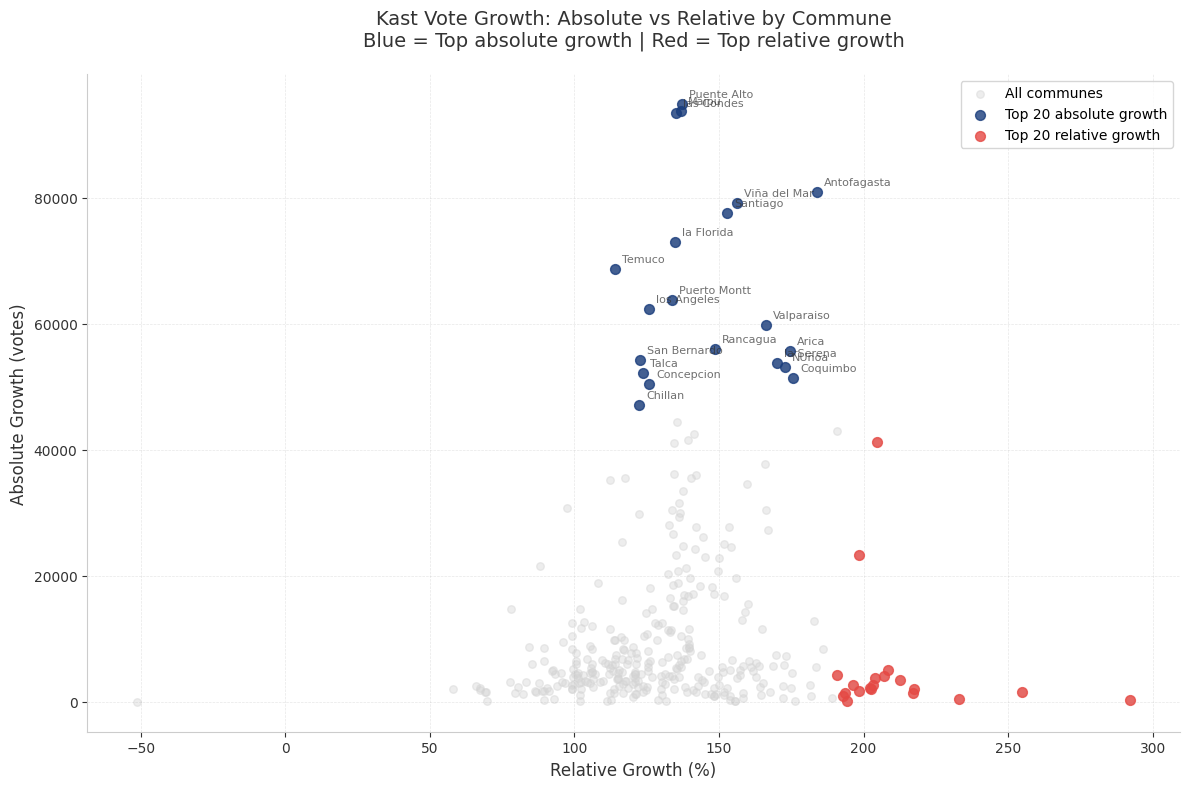

In [46]:
# ============================================================================
# KAST GROWTH - ABSOLUTE VS RELATIVE BY COMMUNE
# ============================================================================
# Objective: Identify communes where Kast grew most in absolute and relative terms
# Context: Reveals where Kast expanded his support most effectively
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. CALCULAR CRECIMIENTO DE KAST POR COMUNA
# ---------------------------------------------------------------------------

# Combinar datos de primera y segunda vuelta
kast_growth_commune = df_2025_v1[['commune', 'region', 'kast_votes']].copy()
kast_growth_commune = kast_growth_commune.merge(
    df_2025_v2[['commune', 'kast_votes']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calcular crecimiento
kast_growth_commune['kast_absolute_growth'] = kast_growth_commune['kast_votes_2v'] - kast_growth_commune['kast_votes_1v']
kast_growth_commune['kast_relative_growth_pct'] = round(
    100 * kast_growth_commune['kast_absolute_growth'] / kast_growth_commune['kast_votes_1v'], 1
)

# ---------------------------------------------------------------------------
# 2. TABLA 1: TOP 20 CRECIMIENTO ABSOLUTO (más votos nuevos)
# ---------------------------------------------------------------------------

top_absolute = kast_growth_commune.nlargest(20, 'kast_absolute_growth')[['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
top_absolute.columns = ['Comuna', 'Región', 'Kast Votos 1V', 'Kast Votos 2V', 'Crecimiento Absoluto', 'Crecimiento Relativo (%)']

print("=" * 90)
print("TOP 20 COMUNAS - CRECIMIENTO ABSOLUTO DE KAST (más votos nuevos)")
print("=" * 90)
display(top_absolute)

# ---------------------------------------------------------------------------
# 3. TABLA 2: TOP 20 CRECIMIENTO RELATIVO (mayor porcentaje de crecimiento)
# ---------------------------------------------------------------------------

top_relative = kast_growth_commune.nlargest(20, 'kast_relative_growth_pct')[['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
top_relative.columns = ['Comuna', 'Región', 'Kast Votos 1V', 'Kast Votos 2V', 'Crecimiento Absoluto', 'Crecimiento Relativo (%)']

print("\n" + "=" * 90)
print("TOP 20 COMUNAS - CRECIMIENTO RELATIVO DE KAST (mayor % de crecimiento)")
print("=" * 90)
display(top_relative)

# ---------------------------------------------------------------------------
# 4. TABLA 3: COMUNAS DONDE KAST CRECIÓ MÁS EN AMBOS SENTIDOS (intersección)
# ---------------------------------------------------------------------------

# Identificar comunas que están en ambos top 20
top_absolute_set = set(top_absolute['Comuna'])
top_relative_set = set(top_relative['Comuna'])
both = top_absolute_set.intersection(top_relative_set)

if both:
    df_both = kast_growth_commune[kast_growth_commune['commune'].isin(both)][['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
    df_both = df_both.sort_values('kast_absolute_growth', ascending=False)
    df_both.columns = ['Comuna', 'Región', 'Kast Votos 1V', 'Kast Votos 2V', 'Crecimiento Absoluto', 'Crecimiento Relativo (%)']
    
    print("\n" + "=" * 90)
    print("COMUNAS EN AMBOS TOP 20 (crecieron en absoluto y relativo)")
    print("=" * 90)
    display(df_both)
else:
    print("\n⚠️ No hay comunas que estén en ambos top 20")

# ---------------------------------------------------------------------------
# 5. VISUALIZACIÓN: Scatter plot (Absoluto vs Relativo) CON ESTILO UNIFICADO
# ---------------------------------------------------------------------------

def plot_growth_scatter(df: pd.DataFrame) -> None:
    """
    Creates a scatter plot showing absolute vs relative growth of Kast votes
    by commune. Highlights communes with top absolute growth (blue) and top
    relative growth (red).
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing commune-level growth data with columns:
        commune, kast_absolute_growth, kast_relative_growth_pct
    """
    # Identify top communes
    top_abs = df.nlargest(20, 'kast_absolute_growth')
    top_rel = df.nlargest(20, 'kast_relative_growth_pct')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Plot all communes in light gray (zorder=1, behind highlights)
    ax.scatter(
        df['kast_relative_growth_pct'],
        df['kast_absolute_growth'],
        alpha=0.4,
        color='#D3D3D3',
        s=30,
        zorder=1,
        label='All communes'
    )
    
    # Highlight top absolute growth in blue (zorder=2, on top)
    ax.scatter(
        top_abs['kast_relative_growth_pct'],
        top_abs['kast_absolute_growth'],
        alpha=0.8,
        color='#1A3D7C',
        s=50,
        zorder=2,
        label='Top 20 absolute growth'
    )
    
    # Highlight top relative growth in red (zorder=2, on top)
    ax.scatter(
        top_rel['kast_relative_growth_pct'],
        top_rel['kast_absolute_growth'],
        alpha=0.8,
        color='#E54944',
        s=50,
        zorder=2,
        label='Top 20 relative growth'
    )
    
    # Add labels for top absolute communes
    for _, row in top_abs.iterrows():
        ax.annotate(
            row['commune'],
            xy=(row['kast_relative_growth_pct'], row['kast_absolute_growth']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            color='#333333',
            alpha=0.7,
            zorder=3
        )
    
    # Labels and title (consistent styling - NO fontweight='bold')
    ax.set_xlabel('Relative Growth (%)', fontsize=12, color='#333333')
    ax.set_ylabel('Absolute Growth (votes)', fontsize=12, color='#333333')
    ax.set_title(
        'Kast Vote Growth: Absolute vs Relative by Commune\n'
        'Blue = Top absolute growth | Red = Top relative growth',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Legend (consistent style)
    ax.legend(
        loc='upper right',
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        fontsize=10
    )
    
    # Grid (consistent with clean style)
    ax.grid(axis='both', alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    
    plt.tight_layout()
    plt.show()


# Execute visualization
plot_growth_scatter(kast_growth_commune)

#### Resumen Comparativo

| Tipo de Crecimiento             | Perfil de Comunas                     | Ejemplos principales                                      | Origen Político 1ª Vuelta   |
| ------------------------------- | ------------------------------------- | --------------------------------------------------------- | --------------------------- |
| **Absoluto** (más votos nuevos) | Comunas **grandes y urbanas**         | Puente Alto, Maipú, Antofagasta, Viña del Mar, La Florida | Mayoritariamente **Jara**   |
| **Relativo** (% de crecimiento) | Comunas **pequeñas/mineras/norteñas** | Ollagüe, Alto del Carmen, Sierra Gorda, Tocopilla         | Mayoritariamente **Parisi** |

#### Interpretación Detallada

1. **Crecimiento Absoluto (Volumen)** Kast sumó la mayor cantidad de votos nuevos en **bastiones tradicionales de Jara** (comunas densamente pobladas de la RM y Valparaíso).
   - Esto indica que logró **penetrar** en sectores populares y de clase media-baja que habían votado por la izquierda en primera vuelta.
   - Ejemplo: Puente Alto (+94.964 votos), Maipú (+93.767), Antofagasta (+80.964).
2. **Crecimiento Relativo (Porcentual)** Los mayores crecimientos porcentuales se dieron en **comunas pequeñas del Norte**, donde Parisi había sido dominante.
   - Aquí Kast logró **duplicar o triplicar** su votación (crecimientos del +190% al +290%).
   - Ejemplo: Ollagüe (+292%), Alto del Carmen (+255%), etc.

#### ¿Qué significa esto?

- **Kast amplió su coalición hacia el centro-izquierda popular** en las grandes ciudades (crecimiento absoluto).
- **Kast consolidó fuertemente el voto antisistema** en el Norte (crecimiento relativo explosivo).

Esto muestra una **estrategia exitosa de doble vía**:

- En las ciudades grandes capturó parte del voto popular que antes iba a Jara.
- En el Norte capitalizó el descontento antisistema que antes canalizaba Parisi.

#### Conclusión Estratégica

Kast no solo retuvo su base conservadora, sino que logró **expandirse en dos direcciones opuestas**:

- Hacia sectores populares urbanos (crecimiento en volumen).
- Hacia el Norte antisistema (crecimiento explosivo en porcentaje).

Esto explica en gran medida su victoria amplia: logró sumar desde **ambos extremos** del espectro que no le eran naturales en primera vuelta.

#### 9.7.2. Comunas con Menor Crecimiento de Kast: Lealtad y Estancamiento



El análisis de las comunas donde Kast registró el menor crecimiento —tanto en términos absolutos como relativos— revela un fenómeno de alta lealtad de su base original más que de debilidad electoral, ya que estos territorios comparten un rasgo común: Kast ya era mayoritario en primera vuelta, por lo que el margen para sumar nuevos votantes era limitado y el bajo crecimiento refleja un efecto de "techo electoral" más que una fuga de apoyo. En el extremo sur y en la Patagonia —Antártica (-18 votos), Timaukel, Primavera, Río Verde, Tortel y O'Higgins— el crecimiento absoluto fue mínimo o negativo debido a la baja densidad poblacional y al carácter aislado de estas comunas, donde el volumen de votantes es reducido y cualquier variación tiene un impacto estadístico limitado. En las zonas rurales del Centro-Sur —Lumaco, Chanco, Tirúa, Los Sauces y Ercilla en La Araucanía, Maule y Biobío— el crecimiento relativo fue bajo porque Kast ya partía de porcentajes altos en primera vuelta, muchas veces superiores al 30-40%, lo que evidencia una base electoral fiel y disciplinada que no requería de grandes expansiones para consolidar su dominio territorial. Este patrón geográfico —concentrado en la Patagonia y en las zonas rurales del Centro-Sur donde Kast ya tenía hegemonía— contrasta con el comportamiento de Jara, quien logró crecimientos más altos en sus bastiones pero no logró expandirse significativamente fuera de ellos, mientras Kast demostró consistencia al crecer fuertemente donde más lo necesitaba (en el Norte y en los sectores populares urbanos) y mantenerse sólido donde ya era fuerte. En síntesis, el bajo crecimiento en estas comunas no es una debilidad, sino una señal de que la base original de Kast estaba ya altamente consolidada, y su campaña logró lo más difícil en una segunda vuelta: crecer donde era débil y retener con fuerza donde ya era fuerte, construyendo una coalición territorialmente diversa y electoralmente decisiva.

TOP 20 COMUNAS - MENOR CRECIMIENTO ABSOLUTO DE KAST (pérdida o estancamiento)


,Comuna,Región,Kast Votos 1V,Kast Votos 2V,Crecimiento Absoluto,Crecimiento Relativo (%)
187,Antartica,Magallanes,35,17,-18,-51.4
196,Timaukel,Magallanes,93,158,65,69.9
192,Primavera,Magallanes,81,207,126,155.6
31,Tortel,Aysén,71,209,138,194.4
299,Juan Fernandez,Valparaíso,90,230,140,155.6
194,Rio Verde,Magallanes,149,301,152,102.0
29,O'higgins,Aysén,141,298,157,111.3
195,San Gregorio,Magallanes,89,246,157,176.4
189,Laguna Blanca,Magallanes,130,301,171,131.5
28,Lago Verde,Aysén,205,469,264,128.8



TOP 20 COMUNAS - MENOR CRECIMIENTO RELATIVO DE KAST (peor % de crecimiento)


,Comuna,Región,Kast Votos 1V,Kast Votos 2V,Crecimiento Absoluto,Crecimiento Relativo (%)
187,Antartica,Magallanes,35,17,-18,-51.4
94,Lumaco,La Araucanía,3356,5304,1948,58.0
199,Chanco,Maule,3717,6170,2453,66.0
59,Tirua,Biobío,3125,5230,2105,67.4
111,los Sauces,La Araucanía,2818,4718,1900,67.4
87,Ercilla,La Araucanía,2326,3935,1609,69.2
39,Contulmo,Biobío,2110,3575,1465,69.4
196,Timaukel,Magallanes,93,158,65,69.9
101,Puren,La Araucanía,4040,7183,3143,77.8
251,Paine,Metropolitana,18884,33626,14742,78.1



COMUNAS EN AMBOS TOP 20 (peor desempeño en absoluto y relativo)


,Comuna,Región,Kast Votos 1V,Kast Votos 2V,Crecimiento Absoluto,Crecimiento Relativo (%)
187,Antartica,Magallanes,35,17,-18,-51.4
196,Timaukel,Magallanes,93,158,65,69.9


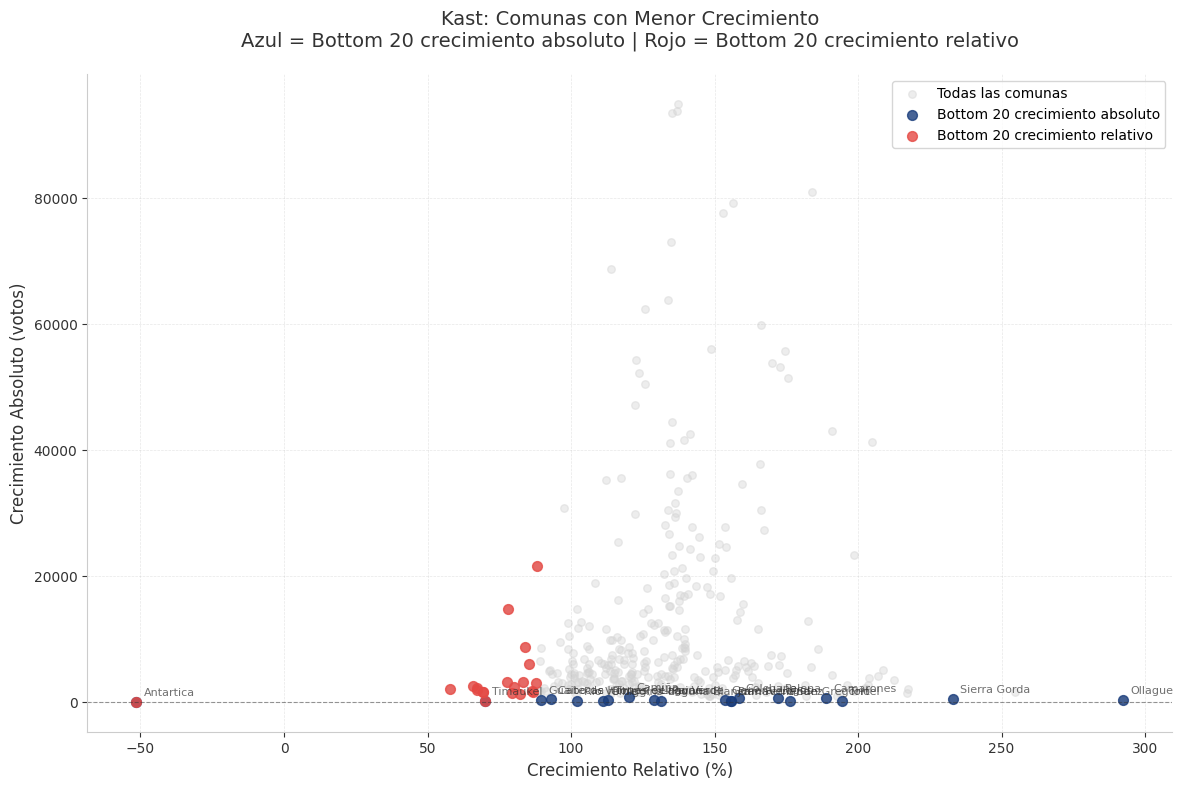

In [47]:
# ============================================================================
# KAST GROWTH - LOWEST ABSOLUTE VS RELATIVE BY COMMUNE
# ============================================================================
# Objective: Identify communes where Kast grew the least in absolute and relative terms
# Context: Reveals where Kast struggled to expand his support
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. CALCULAR CRECIMIENTO DE KAST POR COMUNA
# ---------------------------------------------------------------------------

# Combinar datos de primera y segunda vuelta
kast_growth_commune = df_2025_v1[['commune', 'region', 'kast_votes']].copy()
kast_growth_commune = kast_growth_commune.merge(
    df_2025_v2[['commune', 'kast_votes']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calcular crecimiento
kast_growth_commune['kast_absolute_growth'] = kast_growth_commune['kast_votes_2v'] - kast_growth_commune['kast_votes_1v']
kast_growth_commune['kast_relative_growth_pct'] = round(
    100 * kast_growth_commune['kast_absolute_growth'] / kast_growth_commune['kast_votes_1v'], 1
)

# ---------------------------------------------------------------------------
# 2. TABLA 1: TOP 20 MENOR CRECIMIENTO ABSOLUTO (pérdida o estancamiento)
# ---------------------------------------------------------------------------

bottom_absolute = kast_growth_commune.nsmallest(20, 'kast_absolute_growth')[['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
bottom_absolute.columns = ['Comuna', 'Región', 'Kast Votos 1V', 'Kast Votos 2V', 'Crecimiento Absoluto', 'Crecimiento Relativo (%)']

print("=" * 90)
print("TOP 20 COMUNAS - MENOR CRECIMIENTO ABSOLUTO DE KAST (pérdida o estancamiento)")
print("=" * 90)
display(bottom_absolute)

# ---------------------------------------------------------------------------
# 3. TABLA 2: TOP 20 MENOR CRECIMIENTO RELATIVO (peor desempeño porcentual)
# ---------------------------------------------------------------------------

bottom_relative = kast_growth_commune.nsmallest(20, 'kast_relative_growth_pct')[['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
bottom_relative.columns = ['Comuna', 'Región', 'Kast Votos 1V', 'Kast Votos 2V', 'Crecimiento Absoluto', 'Crecimiento Relativo (%)']

print("\n" + "=" * 90)
print("TOP 20 COMUNAS - MENOR CRECIMIENTO RELATIVO DE KAST (peor % de crecimiento)")
print("=" * 90)
display(bottom_relative)

# ---------------------------------------------------------------------------
# 4. TABLA 3: COMUNAS DONDE KAST CRECIÓ MENOS EN AMBOS SENTIDOS (intersección)
# ---------------------------------------------------------------------------

bottom_absolute_set = set(bottom_absolute['Comuna'])
bottom_relative_set = set(bottom_relative['Comuna'])
both = bottom_absolute_set.intersection(bottom_relative_set)

if both:
    df_both = kast_growth_commune[kast_growth_commune['commune'].isin(both)][['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
    df_both = df_both.sort_values('kast_absolute_growth', ascending=True)
    df_both.columns = ['Comuna', 'Región', 'Kast Votos 1V', 'Kast Votos 2V', 'Crecimiento Absoluto', 'Crecimiento Relativo (%)']
    
    print("\n" + "=" * 90)
    print("COMUNAS EN AMBOS TOP 20 (peor desempeño en absoluto y relativo)")
    print("=" * 90)
    display(df_both)
else:
    print("\n⚠️ No hay comunas que estén en ambos top 20")

# ---------------------------------------------------------------------------
# 5. VISUALIZACIÓN: Scatter plot (Absoluto vs Relativo) - COMUNAS CON MENOR CRECIMIENTO
# ---------------------------------------------------------------------------

def plot_bottom_growth_scatter(df: pd.DataFrame) -> None:
    """
    Creates a scatter plot showing absolute vs relative growth of Kast votes
    by commune. Highlights communes with bottom absolute growth (blue) and bottom
    relative growth (red).
    """
    # Identify bottom communes
    bottom_abs = df.nsmallest(20, 'kast_absolute_growth')
    bottom_rel = df.nsmallest(20, 'kast_relative_growth_pct')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Plot all communes in light gray (zorder=1, behind highlights)
    ax.scatter(
        df['kast_relative_growth_pct'],
        df['kast_absolute_growth'],
        alpha=0.4,
        color='#D3D3D3',
        s=30,
        zorder=1,
        label='Todas las comunas'
    )
    
    # Highlight bottom absolute growth in blue (zorder=2, on top)
    ax.scatter(
        bottom_abs['kast_relative_growth_pct'],
        bottom_abs['kast_absolute_growth'],
        alpha=0.8,
        color='#1A3D7C',
        s=50,
        zorder=2,
        label='Bottom 20 crecimiento absoluto'
    )
    
    # Highlight bottom relative growth in red (zorder=2, on top)
    ax.scatter(
        bottom_rel['kast_relative_growth_pct'],
        bottom_rel['kast_absolute_growth'],
        alpha=0.8,
        color='#E54944',
        s=50,
        zorder=2,
        label='Bottom 20 crecimiento relativo'
    )
    
    # Add labels for bottom absolute communes
    for _, row in bottom_abs.iterrows():
        ax.annotate(
            row['commune'],
            xy=(row['kast_relative_growth_pct'], row['kast_absolute_growth']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            color='#333333',
            alpha=0.7,
            zorder=3
        )
    
    # Labels and title (consistent styling - NO fontweight='bold')
    ax.set_xlabel('Crecimiento Relativo (%)', fontsize=12, color='#333333')
    ax.set_ylabel('Crecimiento Absoluto (votos)', fontsize=12, color='#333333')
    ax.set_title(
        'Kast: Comunas con Menor Crecimiento\n'
        'Azul = Bottom 20 crecimiento absoluto | Rojo = Bottom 20 crecimiento relativo',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Línea de referencia en cero
    ax.axhline(y=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Legend (consistent style)
    ax.legend(
        loc='upper right',
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        fontsize=10
    )
    
    # Grid (consistent with clean style)
    ax.grid(axis='both', alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    
    plt.tight_layout()
    plt.show()


# Execute visualization
plot_bottom_growth_scatter(kast_growth_commune)

#### Hallazgo Principal

A diferencia de la mayoría del país, donde Kast logró un crecimiento fuerte, existe un grupo reducido de comunas donde su avance fue **mínimo, estancado o incluso negativo**. Estas comunas comparten un rasgo clave: **Kast ya era mayoritario en primera vuelta**. Por lo tanto, estamos ante un fenómeno de **alta lealtad** de su base original, más que de desmovilización masiva.

#### 1. Menor Crecimiento Absoluto (Volumen)

En estas comunas Kast sumó pocos votos nuevos o incluso perdió votación absoluta. Destacan:

- **Antártica** (-18 votos): Caso extremo y sin relevancia (población mínima, base militar/científica).
- Varias comunas de **Magallanes** (Timaukel, Primavera, Río Verde) y **Aysén** (Tortel, O’Higgins) muestran crecimientos absolutos bajos.
- Muchas de estas son comunas **muy pequeñas, aisladas o de Patagonia**, con baja densidad poblacional.

**Interpretación**: En territorios con poca población, el techo de crecimiento era bajo. Kast ya tenía una base consolidada en primera vuelta, por lo que el margen para sumar nuevos votantes era limitado.

#### 2. Menor Crecimiento Relativo (%)

Aquí destacan comunas donde Kast ya partía de porcentajes altos en primera vuelta:

- **Lumauco** (La Araucanía), **Chanco** (Maule), **Tirúa**, **los Sauces**, **Ercilla** (La Araucanía), etc.
- La mayoría pertenecen a **La Araucanía, Maule y Biobío** — zonas donde Kast ya era muy fuerte en primera vuelta.

**Interpretación**: En estas comunas Kast ya tenía un apoyo mayoritario consolidado (muchas veces superior al 30-40% en primera vuelta). El crecimiento relativo es bajo porque ya partía de una base alta (efecto “techo electoral”).

#### Lectura Estratégica General

- **Alta lealtad de la base**: Kast mantuvo o aumentó su voto en prácticamente todo el país. Los casos de bajo crecimiento corresponden a comunas donde **ya era dominante** en primera vuelta. Esto habla de una base electoral **fiel y disciplinada**.
- **Patrón geográfico**: Los menores crecimientos se concentran en:
  - **Patagonia / Extremo Sur** (baja densidad poblacional).
  - **Zonas rurales del Centro-Sur** donde ya tenía hegemonía.
- **Contraste con Jara**: Mientras Jara logró crecimientos más altos en sus bastiones, Kast mostró **consistencia**: creció mucho donde más lo necesitaba (Norte y sectores de Jara) y se mantuvo sólido donde ya era fuerte.

**Conclusión**:  
Estos datos refuerzan la solidez de la victoria de Kast. No solo expandió su apoyo hacia el Norte y sectores de Jara, sino que **mantuvo una lealtad muy alta** en sus territorios tradicionales. El bajo crecimiento en estas comunas no es una debilidad, sino una señal de que su base original estaba ya altamente consolidada. Kast logró lo más difícil: crecer donde era débil y retener con fuerza donde ya era fuerte.

### 9.8 Gradiente Urbano-Rural en el Voto a José Antonio Kast


#### 9.8.1 Gradiente Urbano-Rural: El Apoyo de Kast por Tamaño de Comuna


El análisis del gradiente urbano-rural en la segunda vuelta de 2025 revela uno de los patrones estructurales más nítidos de la elección: el apoyo a José Antonio Kast aumentó de manera inversamente proporcional al tamaño de las comunas, pasando de un magro 50% en las grandes ciudades (>200.000 habitantes) a un sólido 61,16% en las localidades rurales (<10.000 habitantes), una tendencia que confirma el clásico patrón de la derecha conservadora de obtener mejores resultados en zonas rurales, agrícolas y de menor densidad poblacional. Este gradiente, que se mantiene consistente en todas las macrozonas del país, evidencia que Kast logró articular una coalición territorialmente heterogénea: mientras dominó el Chile rural y periférico con niveles de apoyo que superan el 60%, enfrentó una competencia mucho más reñida en los grandes centros urbanos, donde su votación se mantuvo cerca del 50% y donde Jara pudo mantener sus principales bastiones en el Gran Santiago y otras ciudades densamente pobladas. Esta dualidad —que convierte a Kast en el candidato del Chile no metropolitano y a Jara en la representante del Chile urbano y concentrado— constituye uno de los rasgos estructurales más claros de la elección de 2025 y refleja la profundidad de la fractura territorial que atraviesa la sociedad chilena, con implicancias directas para la gobernabilidad y el diseño de políticas públicas en el próximo período, al tiempo que evidencia que la base electoral de la derecha conservadora se sostiene en un Chile rural y periférico muy leal, mientras que en las grandes ciudades su apoyo es más frágil y competitivo.


KAST VOTE SHARE BY COMMUNE SIZE (Second Round)



,communes,population,kast_pct_weighted
size_category,,,
"Large Urban Centers (> 200,000)",21,6443321,50.85
"Medium Urban Centers (100,000–199,999)",35,5063889,52.44
"Small Urban Centers (50,000–99,999)",33,2493250,53.41
"Rural–Urban Centers (10,000–49,999)",165,3761505,60.26
"Rural Localities (< 10,000)",91,476814,61.16


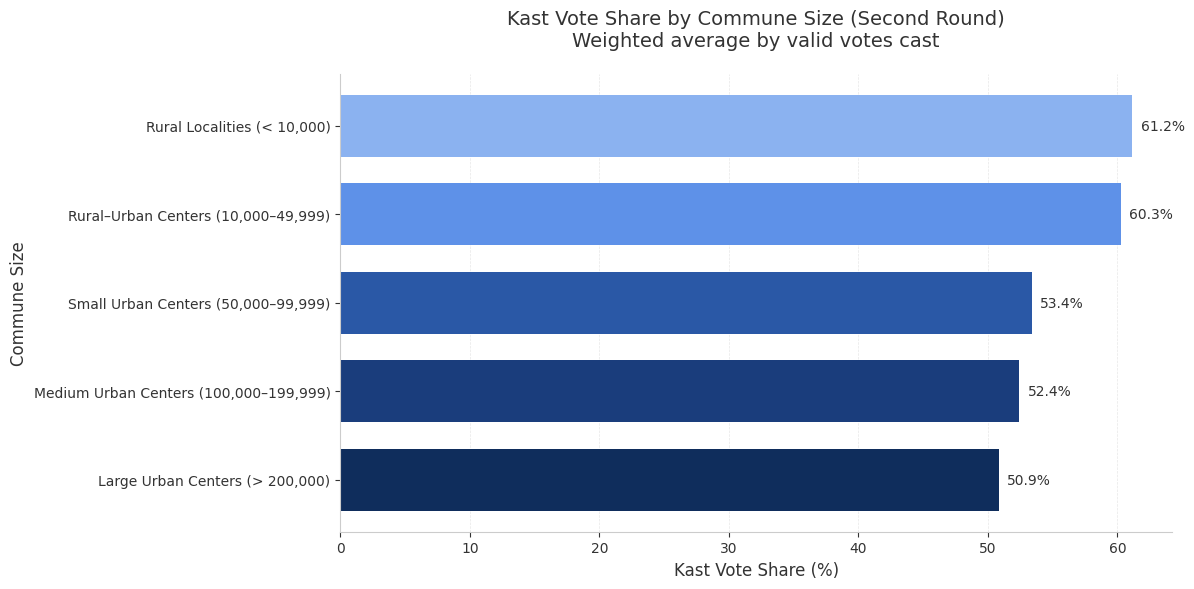

In [48]:
# ============================================================================
# KAST VOTE SHARE BY COMMUNE SIZE
# ============================================================================

# Hypothesis: Does Kast perform better in large or small communes?
# Classified by population size categories (Official Chilean classification)


# ---------------------------------------------------------------------------
# 1. NORMALIZAR Y MERGE
# ---------------------------------------------------------------------------

# Copias para no modificar originales
df_votes_norm = df_2025_v2.copy()
df_pop_norm = df_pop.copy()

# Normalizar nombres usando tu función
df_votes_norm['commune_norm'] = df_votes_norm['commune'].apply(normalize_commune_name)
df_pop_norm['commune_norm'] = df_pop_norm['commune'].apply(normalize_commune_name)

# Merge
df_merged = df_votes_norm.merge(
    df_pop_norm[['commune_norm', 'population']],
    on='commune_norm',
    how='left'
)

# Eliminar comunas sin población
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

# ---------------------------------------------------------------------------
# 2. CLASIFICAR POR TAMAÑO (Categorías personalizadas)
# ---------------------------------------------------------------------------

def classify_commune_size(pop):
    if pop > 200_000:
        return 'Large Urban Centers (> 200,000)'
    elif pop >= 100_000:
        return 'Medium Urban Centers (100,000–199,999)'
    elif pop >= 50_000:
        return 'Small Urban Centers (50,000–99,999)'
    elif pop >= 10_000:
        return 'Rural–Urban Centers (10,000–49,999)'
    else:
        return 'Rural Localities (< 10,000)'

df_merged['size_category'] = df_merged['population'].apply(classify_commune_size)

# Orden de categorías (de mayor a menor población)
size_order = [
    'Large Urban Centers (> 200,000)',
    'Medium Urban Centers (100,000–199,999)',
    'Small Urban Centers (50,000–99,999)',
    'Rural–Urban Centers (10,000–49,999)',
    'Rural Localities (< 10,000)'
]

# ---------------------------------------------------------------------------
# 3. TABLA: KAST POR TAMAÑO DE COMUNA
# ---------------------------------------------------------------------------

kast_by_size = df_merged.groupby('size_category').agg(
    communes=('commune', 'count'),
    population=('population', 'sum'),
    kast_votes=('kast_votes', 'sum'),
    casted_votes=('casted_votes', 'sum')
).round(2)

kast_by_size['kast_pct_weighted'] = round(100 * kast_by_size['kast_votes'] / kast_by_size['casted_votes'], 2)

# Reordenar y mostrar
kast_by_size = kast_by_size.reindex(size_order)

print("\n" + "=" * 90)
print("KAST VOTE SHARE BY COMMUNE SIZE (Second Round)")
print("=" * 90)
print()

# Mostrar tabla
display(kast_by_size[['communes', 'population', 'kast_pct_weighted']])

# ---------------------------------------------------------------------------
# 4. GRÁFICO DE BARRAS CON ESTILO UNIFICADO
# ---------------------------------------------------------------------------

def plot_kast_by_commune_size(df: pd.DataFrame) -> None:
    """
    Creates a horizontal bar chart showing Kast's vote share by commune size
    category, weighted by valid votes cast.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with size_category as index and kast_pct_weighted as values
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Color gradient from dark to light blue
    colors = ['#0F2D5C', '#1A3D7C', '#2A58A6', '#5E91E8', '#8BB2F0']
    
    # Horizontal bars (consistent with other visualizations)
    bars = ax.barh(
        df.index,
        df['kast_pct_weighted'],
        color=colors,
        linewidth=0.8,
        height=0.7,
        zorder=2
    )
    
    # Add percentage labels at the end of each bar
    for bar, pct in zip(bars, df['kast_pct_weighted']):
        ax.annotate(
            f'{pct:.1f}%',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333',
            zorder=3
        )
    
    # Labels and title (consistent styling - NO fontweight='bold')
    ax.set_xlabel('Kast Vote Share (%)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune Size', fontsize=12, color='#333333')
    ax.set_title(
        'Kast Vote Share by Commune Size (Second Round)\n'
        'Weighted average by valid votes cast',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    
    plt.tight_layout()
    plt.show()


# Execute visualization
plot_kast_by_commune_size(kast_by_size)

#### Interpretación Clara

- **Tendencia muy marcada**: **A menor tamaño de comuna, mayor apoyo a Kast**.
  - En las **ciudades más grandes** (>200.000 hab.) Kast apenas supera el 50%.
  - En las **comunas rurales** (<10.000 hab.) Kast alcanza su mejor performance (61.16%).

#### Conclusiones Estratégicas

1. **Kast es el candidato del Chile rural y provincial** Su apoyo crece consistentemente a medida que bajamos en tamaño de población. Esto confirma el patrón clásico: la derecha conservadora tiene más fuerza en zonas rurales, agrícolas y de menor densidad.
2. **Desafío en las grandes ciudades** En las comunas más pobladas (donde vive la mayor parte de la población chilena), Kast está cerca del empate o solo con ventaja moderada. Esto explica por qué Jara pudo mantener bastiones importantes en el Gran Santiago.
3. **Coalición Heterogénea** Kast logró unir:
   - Un **Chile rural y periférico** muy leal (60-61%).
   - Un **Chile urbano** más dividido (50-53%).

Este gradiente urbano-rural es uno de los rasgos más claros de la elección 2025 y muestra que Kast representa principalmente al **Chile no-metropolitano**.

#### 9.8.2. Gradiente Urbano-Rural: El Apoyo de Kast por Macrozona Geografica


El análisis del gradiente urbano-rural desagregado por macrozona revela que el patrón general de mayor apoyo a Kast en comunas rurales no es homogéneo en todo el país, sino que se intensifica en algunas regiones y se atenúa en otras, reflejando la diversidad territorial del voto a la derecha conservadora. El contraste más fuerte se observa en la macrozona Centro, donde la diferencia entre el voto rural (61,2%) y el voto en grandes ciudades (48,9%) alcanza los 12,3 puntos porcentuales, evidenciando una fractura profunda entre el Chile rural del Centro y el Chile urbano de la Región Metropolitana y Valparaíso, donde Jara mantuvo sus bastiones populares. En el Norte Grande, la diferencia también es significativa (+9,1 puntos, con Kast alcanzando 58,3% en zonas rurales versus 49,2% en grandes ciudades), lo que confirma que incluso en los territorios donde Parisi había sido fuerte, Kast logró consolidar mejor su apoyo en las comunas más pequeñas y aisladas que en los centros urbanos. En contraste, el Norte Chico y el Sur muestran diferencias casi nulas (0,1 y 0,3 puntos respectivamente), indicando que en estas macrozonas Kast mantiene un apoyo consistente tanto en el ámbito rural como en el urbano, sin que el tamaño de la comuna sea un factor diferenciador significativo. El Centro Sur, por su parte, destaca por su alta performance en ambos tipos de territorio (61,3% en grandes ciudades y 67,2% en rurales), consolidándose como la zona donde Kast logró su mejor desempeño general y donde su dominio territorial es más completo. Este patrón por macrozona confirma que Kast es el candidato del Chile rural, provincial y periférico, pero también revela que su capacidad de penetración en las grandes ciudades varía significativamente según la región: mientras en el Centro Sur y el Sur logra márgenes sólidos incluso en los centros urbanos, en el Norte Grande y el Centro enfrenta una competencia más reñida, lo que sugiere que su desafío estratégico se concentra en las grandes ciudades de estas macrozonas, donde Jara mantuvo una mayor capacidad de resistencia.


KAST VOTE SHARE BY COMMUNE SIZE AND GEOGRAPHIC MACROZONE

(Values represent weighted average percentage of Kast votes)



,Norte Grande,Norte Chico,Centro,Centro Sur,Sur,Patagonia
"Large Urban Centers (> 200,000)",49.2,48.8,48.9,61.3,60.4,NaN
"Medium Urban Centers (100,000–199,999)",56.6,51.4,51.1,56.7,53.4,50.9
"Small Urban Centers (50,000–99,999)",NaN,49.8,51.5,59.4,63.0,56.7
"Rural–Urban Centers (10,000–49,999)",48.2,48.3,58.3,65.0,63.0,50.8
"Rural Localities (< 10,000)",58.3,48.9,61.2,67.2,60.7,57.5


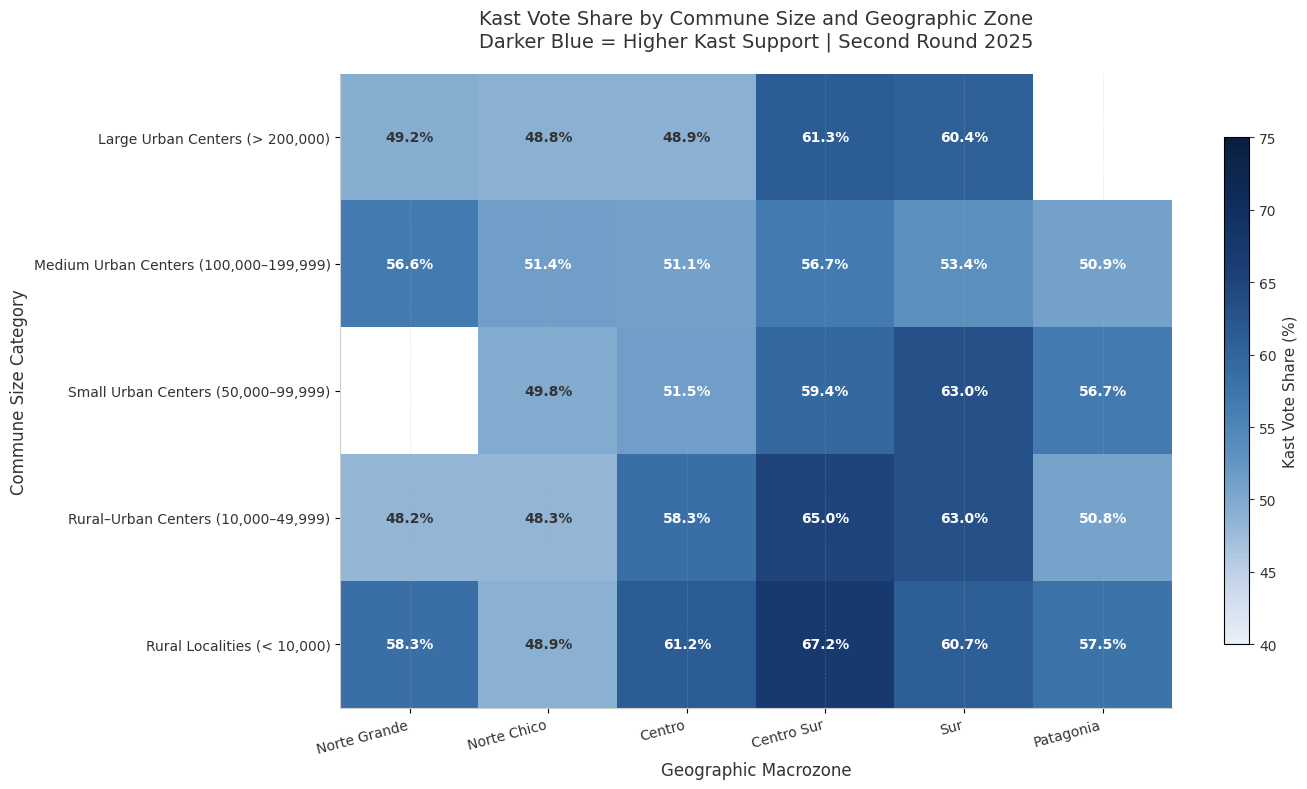

In [49]:
# ============================================================================
# URBAN-RURAL ANALYSIS BY MACROZONE: KAST VOTE SHARE
# ============================================================================

# Hypothesis: Does Kast perform better in large or small communes?
# Cross-tabulation: Commune Size (rows) vs Geographic Macrozone (columns)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ---------------------------------------------------------------------------
# 1. NORMALIZAR Y MERGE
# ---------------------------------------------------------------------------

# Copias para no modificar originales
df_votes_norm = df_2025_v2.copy()
df_pop_norm = df_pop.copy()

# Normalizar nombres usando tu función
df_votes_norm['commune_norm'] = df_votes_norm['commune'].apply(normalize_commune_name)
df_pop_norm['commune_norm'] = df_pop_norm['commune'].apply(normalize_commune_name)

# Merge para obtener población
df_merged = df_votes_norm.merge(
    df_pop_norm[['commune_norm', 'population']],
    on='commune_norm',
    how='left'
)

# Eliminar comunas sin población
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

# ---------------------------------------------------------------------------
# 2. AGREGAR MACROZONA
# ---------------------------------------------------------------------------

# Mapear región a macrozona
macrozone_map = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

# Orden de macrozonas (norte a sur)
macrozone_order = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur', 'Patagonia']

# ---------------------------------------------------------------------------
# 3. CLASIFICAR POR TAMAÑO DE COMUNA
# ---------------------------------------------------------------------------

def classify_commune_size(pop):
    if pop > 200_000:
        return 'Large Urban Centers (> 200,000)'
    elif pop >= 100_000:
        return 'Medium Urban Centers (100,000–199,999)'
    elif pop >= 50_000:
        return 'Small Urban Centers (50,000–99,999)'
    elif pop >= 10_000:
        return 'Rural–Urban Centers (10,000–49,999)'
    else:
        return 'Rural Localities (< 10,000)'

df_merged['size_category'] = df_merged['population'].apply(classify_commune_size)

# Orden de tamaños (de mayor a menor población)
size_order = [
    'Large Urban Centers (> 200,000)',
    'Medium Urban Centers (100,000–199,999)',
    'Small Urban Centers (50,000–99,999)',
    'Rural–Urban Centers (10,000–49,999)',
    'Rural Localities (< 10,000)'
]

# ---------------------------------------------------------------------------
# 4. TABLA CRUZADA: TAMAÑO vs MACROZONA (Kast % ponderado)
# ---------------------------------------------------------------------------

# Función para calcular promedio ponderado por grupo
def weighted_kast_pct(sub_df):
    total_kast = sub_df['kast_votes'].sum()
    total_cast = sub_df['casted_votes'].sum()
    return round(100 * total_kast / total_cast, 1) if total_cast > 0 else 0

# Crear tabla pivote agrupando manualmente
pivot_data = []
for size in size_order:
    row = []
    for zone in macrozone_order:
        subset = df_merged[(df_merged['size_category'] == size) & (df_merged['macrozone'] == zone)]
        if len(subset) > 0:
            row.append(weighted_kast_pct(subset))
        else:
            row.append(np.nan)
    pivot_data.append(row)

pivot_table = pd.DataFrame(pivot_data, index=size_order, columns=macrozone_order)

print("\n" + "=" * 90)
print("KAST VOTE SHARE BY COMMUNE SIZE AND GEOGRAPHIC MACROZONE")
print("=" * 90)
print()
print("(Values represent weighted average percentage of Kast votes)")
print()
display(pivot_table)

# ---------------------------------------------------------------------------
# 5. HEATMAP CON PALETA DE COLORES DE KAST
# ---------------------------------------------------------------------------

def plot_kast_heatmap(pivot_df: pd.DataFrame) -> None:
    """
    Creates a heatmap using Kast's official color palette.
    Darker blue = higher Kast vote share
    White text for values >= 50% (Kast majority)
    Dark text for values < 50%
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Paleta de colores oficial de Kast (azules monocromáticos)
    kast_colors = ['#E8F0F8', '#C5D5E8', '#8BB2D4', '#5E91C0', '#3D76AC', 
                   '#2A5890', '#1A3D74', '#0F2D5C', '#0A1F40']
    
    cmap = LinearSegmentedColormap.from_list('kast_blue', kast_colors, N=100)
    
    # Crear heatmap
    im = ax.imshow(pivot_df.values, cmap=cmap, aspect='auto', vmin=40, vmax=75)
    
    # Add labels
    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_xticklabels(pivot_df.columns, fontsize=10, color='#333333')
    ax.set_yticklabels(pivot_df.index, fontsize=10, color='#333333')
    
    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
    
    # Add value annotations in each cell
    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = pivot_df.iloc[i, j]
            if not pd.isna(value):
                # Texto BLANCO para valores >= 50% (Kast tiene mayoría)
                # Texto OSCURO para valores < 50%
                text_color = 'white' if value >= 50 else '#333333'
                ax.text(j, i, f'{value:.1f}%',
                       ha='center', va='center',
                       fontsize=10, fontweight='bold',
                       color=text_color, zorder=3)
    
    # Labels and title
    ax.set_xlabel('Geographic Macrozone', fontsize=12, color='#333333')
    ax.set_ylabel('Commune Size Category', fontsize=12, color='#333333')
    ax.set_title(
        'Kast Vote Share by Commune Size and Geographic Zone\n'
        'Darker Blue = Higher Kast Support | Second Round 2025',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Kast Vote Share (%)', fontsize=11, color='#333333')
    cbar.ax.tick_params(color='#333333', labelcolor='#333333')
    
    plt.tight_layout()
    plt.show()


# Execute heatmap
plot_kast_heatmap(pivot_table)



#### 1. Patrón General Urbano-Rural

- **Kast es claramente más fuerte en comunas rurales y semi-rurales**.
- Su apoyo aumenta de forma consistente a medida que baja el tamaño de la comuna.
- En **Large Urban Centers** (>200.000 hab.) Kast está cerca del empate o con ventaja moderada (48-61%).
- En **Rural Localities** (<10.000 hab.) su promedio sube notablemente (hasta 67.2% en Centro Sur).

#### 2. Análisis por Macrozona

| Macrozona        | Grandes Ciudades | Rurales (<10k) | Diferencia Rural vs Urbano | Comentario              |
| ---------------- | ---------------- | -------------- | -------------------------- | ----------------------- |
| **Norte Grande** | 49.2%            | 58.3%          | +9.1 pp                    | Mejora notable en rural |
| **Norte Chico**  | 48.8%            | 48.9%          | +0.1 pp                    | Casi plano              |
| **Centro**       | 48.9%            | 61.2%          | +12.3 pp                   | Fuerte contraste        |
| **Centro Sur**   | 61.3%            | 67.2%          | +5.9 pp                    | Muy fuerte en ambas     |
| **Sur**          | 60.4%            | 60.7%          | +0.3 pp                    | Consistente             |
| **Patagonia**    | -                | 57.5%          | -                          | Fuerte en rural         |

#### Conclusiones Estratégicas

- **Kast domina el Chile no-metropolitano**: Su mejor performance está en el **Centro Sur y Sur**, tanto en ciudades medianas como en zonas rurales.
- **Desafío en el Norte y Centro Urbano**: En el Norte Grande y Centro (especialmente grandes ciudades), Kast está más cerca del 50%. Aquí la competencia con Jara fue más reñida.
- **Gradiente claro**: Kast es el candidato del **Chile rural, provincial y periférico**. Mientras más alejada y pequeña es la comuna, mejor le va.

Esto refuerza lo que veníamos viendo:

- **Jara** = Chile urbano, denso y popular.
- **Kast** = Chile rural, provincial y de baja densidad.

## 10. Analisis de trasferencias de votos

### 10.1. Realineamiento Electoral – Primera a Segunda Vuelta 2025

El análisis del realineamiento electoral entre la primera y segunda vuelta de 2025 revela una reconfiguración territorial de una magnitud excepcional, donde el 42,5% de las comunas del país (147 de 346) cambiaron de ganador entre ambas rondas, y donde José Antonio Kast emergió como el gran absorbente de un proceso de transferencia de votos sin precedentes en la historia electoral chilena reciente. La matriz de transferencias muestra una dinámica claramente favorable a la derecha: Kast retuvo el 100% de las 169 comunas que había ganado en primera vuelta (169 comunas), recibió 75 comunas que habían sido de Jara (71,4% de sus bastiones originales), 58 comunas de Parisi (90,6% del total de sus victorias comunales) y la totalidad de las comunas de Matthei y Kaiser (4 cada uno), consolidando una coalición que le permitió sumar 141 comunas que no eran suyas en primera vuelta y que explica gran parte de su salto electoral del 23,96% al 58,24% de los votos válidos. Este proceso de realineamiento fue territorialmente desigual: el Norte (Grande y Chico) experimentó un cambio casi total, con tasas de recambio que alcanzaron el 100% en Arica, Tarapacá y Antofagasta, y el 88,9% en Atacama, reflejando la transferencia masiva del voto de Parisi hacia Kast en las regiones donde el candidato antisistema había sido más fuerte; el Centro mostró un movimiento alto en Valparaíso (76,3%) y moderado en la Metropolitana (42,3%), donde Jara logró retener varios bastiones populares; y el Centro Sur y Sur presentaron una estabilidad muy alta, con La Araucanía registrando un 0% de cambio y Maule solo un 6,7%, confirmando que en estas regiones Kast ya dominaba y consolidó su poder sin mayores sobresaltos. La tasa de retención por candidato refuerza esta lectura: Kast exhibió una lealtad perfecta de su electorado (100% de retención de sus comunas originales), un comportamiento excepcional en una segunda vuelta que evidencia una base electoral extremadamente disciplinada y fiel, mientras que Jara solo retuvo el 28,6% de sus comunas (30 de 105), perdiendo 75 territorios que había ganado en primera vuelta y quedando reducida a un núcleo duro concentrado principalmente en la Región Metropolitana. En su conjunto, este realineamiento marca un giro político estructural en Chile: Kast no solo ganó la elección presidencial, sino que construyó una coalición ganadora amplia y eficiente que unió al mundo conservador tradicional, al libertario, al antisistema nortino y a una parte significativa del voto popular que antes apoyaba a la izquierda, consolidando un mapa territorial dominante que contrasta con el apoyo concentrado y vulnerable de Jara y que redefine el equilibrio de fuerzas políticas en el país para el próximo ciclo electoral.

In [50]:
# ============================================================================
# ELECTORAL REALIGNMENT: WINNER TRANSITIONS 2025 (1st Round → 2nd Round)
# ============================================================================
# Objective: Analyze how communes changed winner between first and second round
# Context: Reveals voter migration and coalition consolidation

import pandas as pd
import numpy as np

# ---------------------------------------------------------------------------
# STEP 1: Determinar ganador de primera vuelta (2025)
# ---------------------------------------------------------------------------

# Candidatos de primera vuelta
CANDIDATES_2025_1V = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 
                       'matthei_pct', 'mayne_nicholls_pct', 'enriquez_ominami_pct', 'artes_pct']

WINNER_LABELS_2025_1V = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)',
    'mayne_nicholls': 'Mayne-Nicholls (Center)',
    'enriquez_ominami': 'Enríquez O (Left)',
    'artes': 'Artes (Far Left)'
}

# Copias para no modificar originales
df_1v = df_2025_v1.copy()
df_2v = df_2025_v2.copy()

# Normalizar columnas de porcentaje
for col in CANDIDATES_2025_1V:
    df_1v[col] = pd.to_numeric(df_1v[col], errors='coerce').fillna(0)

# Determinar ganador de primera vuelta
df_1v['winner_2025_1v'] = (
    df_1v[CANDIDATES_2025_1V].idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(WINNER_LABELS_2025_1V)
)

# ---------------------------------------------------------------------------
# STEP 2: Determinar ganador de segunda vuelta (2025)
# ---------------------------------------------------------------------------

df_2v['winner_2025_2v'] = 'Kast (Right)'
df_2v.loc[df_2v['jara_pct'] > df_2v['kast_pct'], 'winner_2025_2v'] = 'Jara (Left)'
df_2v.loc[df_2v['jara_pct'] == df_2v['kast_pct'], 'winner_2025_2v'] = 'Tie'

# ---------------------------------------------------------------------------
# STEP 3: Normalizar nombres de comunas para el merge
# ---------------------------------------------------------------------------

df_1v['commune_norm'] = df_1v['commune'].apply(normalize_commune_name)
df_2v['commune_norm'] = df_2v['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# STEP 4: Merge en clave commune_norm + region
# ---------------------------------------------------------------------------

df_change = df_1v[['commune', 'region', 'commune_norm', 'winner_2025_1v']].merge(
    df_2v[['commune_norm', 'region', 'winner_2025_2v']],
    on=['commune_norm', 'region'],
    how='inner',
)

df_change['change_type'] = np.where(
    df_change['winner_2025_1v'] == df_change['winner_2025_2v'], 'Same', 'Changed'
)

print(f"\n✅ Total comunas en dataset de transición: {len(df_change)}")
print(f"   (deben ser 346 comunas)")

# ---------------------------------------------------------------------------
# STEP 5: Resumen de cambios
# ---------------------------------------------------------------------------

print("\n" + "=" * 70)
print("REALINEAMIENTO ELECTORAL: Primera Vuelta → Segunda Vuelta 2025")
print("=" * 70)

change_summary = df_change['change_type'].value_counts().reset_index()
change_summary.columns = ['change_type', 'communes']
change_summary['percentage'] = round(change_summary['communes'] / len(df_change) * 100, 1)

print("\n📊 RESUMEN DE CAMBIOS:")
display(change_summary)

# ---------------------------------------------------------------------------
# STEP 6: Matriz de transición (quién ganó 1V → quién ganó 2V)
# ---------------------------------------------------------------------------

# Lista de posibles ganadores en primera vuelta
winners_1v = ['Jara (Left)', 'Kast (Right)', 'Parisi (Anti-system)', 
              'Kaiser (Libertarian)', 'Matthei (Trad Right)',
              'Mayne-Nicholls (Center)', 'Enríquez O (Left)', 'Artes (Far Left)']

# Lista de posibles ganadores en segunda vuelta
winners_2v = ['Jara (Left)', 'Kast (Right)']

# Crear matriz de transición
transition_matrix = pd.crosstab(
    df_change['winner_2025_1v'], 
    df_change['winner_2025_2v'], 
    dropna=False
).reindex(index=winners_1v, columns=winners_2v, fill_value=0)

print("\n📊 MATRIZ DE TRANSICIÓN (1V → 2V):")
print("Filas = Ganador en Primera Vuelta | Columnas = Ganador en Segunda Vuelta")
display(transition_matrix)

# ---------------------------------------------------------------------------
# STEP 7: Transiciones más frecuentes (TODAS, incluyendo permanencias)
# ---------------------------------------------------------------------------

transition_all = (
    df_change.groupby(['winner_2025_1v', 'winner_2025_2v'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print("\n📊 TODAS LAS TRANSICIONES (1V → 2V):")
print("   Incluye permanencias (misma diagonal) y cambios")
display(transition_all)

# ---------------------------------------------------------------------------
# STEP 8: Desglose regional de cambios (usando macrozonas)
# ---------------------------------------------------------------------------

# Agregar macrozona
df_change = df_change.merge(
    df_region_dim[['region', 'macrozone', 'region_order']], 
    on='region', 
    how='left'
)

regional_changes = (
    df_change
    .groupby(['macrozone', 'region', 'region_order'])
    .agg(
        total_communes=('commune', 'count'),
        changed_communes=('change_type', lambda x: (x == 'Changed').sum()),
    )
    .reset_index()
    .sort_values('region_order')
)
regional_changes['pct_changed'] = round(
    regional_changes['changed_communes'] / regional_changes['total_communes'] * 100, 1
)

print("\n📊 DESGLOSE POR REGIÓN (Norte → Sur):")
display(regional_changes[['macrozone', 'region', 'total_communes', 'changed_communes', 'pct_changed']])

# ---------------------------------------------------------------------------
# STEP 9: Análisis de retención por candidato de primera vuelta
# ---------------------------------------------------------------------------

df_same = df_change[df_change['change_type'] == 'Same']
total_by_winner = df_change.groupby('winner_2025_1v').size().reset_index(name='total_2025_1v')
retained = df_same.groupby('winner_2025_1v').size().reset_index(name='communes_retained')

retention_rates = total_by_winner.merge(retained, on='winner_2025_1v', how='left')
retention_rates['communes_retained'] = retention_rates['communes_retained'].fillna(0)
retention_rates['retention_rate_pct'] = round(
    retention_rates['communes_retained'] / retention_rates['total_2025_1v'] * 100, 1
)
retention_rates = retention_rates.sort_values('retention_rate_pct', ascending=False)

print("\n📊 TASA DE RETENCIÓN POR CANDIDATO (comunas que mantuvieron su ganador):")
display(retention_rates)

# ---------------------------------------------------------------------------
# STEP 10: Resumen ejecutivo
# ---------------------------------------------------------------------------

print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

# Calcular totales desde la matriz
kast_total = transition_matrix.loc['Kast (Right)', 'Kast (Right)']
jara_total = transition_matrix.loc['Jara (Left)', 'Jara (Left)']
parisi_to_kast = transition_matrix.loc['Parisi (Anti-system)', 'Kast (Right)']
parisi_to_jara = transition_matrix.loc['Parisi (Anti-system)', 'Jara (Left)']

print(f"""
📊 ESTABILIDAD TERRITORIAL:
   • {change_summary[change_summary['change_type'] == 'Same']['communes'].values[0]} comunas mantuvieron el mismo ganador ({change_summary[change_summary['change_type'] == 'Same']['percentage'].values[0]}%)
   • {change_summary[change_summary['change_type'] == 'Changed']['communes'].values[0]} comunas cambiaron de ganador ({change_summary[change_summary['change_type'] == 'Changed']['percentage'].values[0]}%)

📊 RETENCIÓN POR CANDIDATO:
   • Kast retuvo {kast_total} comunas ({retention_rates[retention_rates['winner_2025_1v'] == 'Kast (Right)']['retention_rate_pct'].values[0]}% de sus comunas)
   • Jara retuvo {jara_total} comunas ({retention_rates[retention_rates['winner_2025_1v'] == 'Jara (Left)']['retention_rate_pct'].values[0]}% de sus comunas)

📊 DESTINO DEL VOTO PARISI:
   • {parisi_to_kast} comunas → Kast
   • {parisi_to_jara} comunas → Jara
""")

print("=" * 70)


✅ Total comunas en dataset de transición: 346
   (deben ser 346 comunas)

REALINEAMIENTO ELECTORAL: Primera Vuelta → Segunda Vuelta 2025

📊 RESUMEN DE CAMBIOS:


,change_type,communes,percentage
0,Same,199,57.5
1,Changed,147,42.5



📊 MATRIZ DE TRANSICIÓN (1V → 2V):
Filas = Ganador en Primera Vuelta | Columnas = Ganador en Segunda Vuelta


winner_2025_2v,Jara (Left),Kast (Right)
winner_2025_1v,,
Jara (Left),30,75
Kast (Right),0,169
Parisi (Anti-system),6,58
Kaiser (Libertarian),0,4
Matthei (Trad Right),0,4
Mayne-Nicholls (Center),0,0
Enríquez O (Left),0,0
Artes (Far Left),0,0



📊 TODAS LAS TRANSICIONES (1V → 2V):
   Incluye permanencias (misma diagonal) y cambios


...


📊 DESGLOSE POR REGIÓN (Norte → Sur):


,macrozone,region,total_communes,changed_communes,pct_changed
10,Norte Grande,Arica y Parinacota,4,4,100.0
11,Norte Grande,Tarapacá,7,7,100.0
9,Norte Grande,Antofagasta,9,9,100.0
7,Norte Chico,Atacama,9,8,88.9
8,Norte Chico,Coquimbo,15,12,80.0
3,Centro,Valparaíso,38,29,76.3
2,Centro,Metropolitana,52,22,42.3
0,Centro,Libertador,33,11,33.3
1,Centro,Maule,30,2,6.7
6,Centro Sur,Ñuble,21,1,4.8



📊 TASA DE RETENCIÓN POR CANDIDATO (comunas que mantuvieron su ganador):


,winner_2025_1v,total_2025_1v,communes_retained,retention_rate_pct
2,Kast (Right),169,169.0,100.0
0,Jara (Left),105,30.0,28.6
1,Kaiser (Libertarian),4,0.0,0.0
3,Matthei (Trad Right),4,0.0,0.0
4,Parisi (Anti-system),64,0.0,0.0



RESUMEN EJECUTIVO

📊 ESTABILIDAD TERRITORIAL:
   • 199 comunas mantuvieron el mismo ganador (57.5%)
   • 147 comunas cambiaron de ganador (42.5%)

📊 RETENCIÓN POR CANDIDATO:
   • Kast retuvo 169 comunas (100.0% de sus comunas)
   • Jara retuvo 30 comunas (28.6% de sus comunas)

📊 DESTINO DEL VOTO PARISI:
   • 58 comunas → Kast
   • 6 comunas → Jara



#### Resumen General de Realineamiento
- **57.5%** de las comunas mantuvieron el mismo ganador (199 comunas).
- **42.5%** cambiaron de ganador (147 comunas).
- Kast fue el gran beneficiario de los cambios.

#### Matriz de Transferencias (Ganador 1ª Vuelta → Ganador 2ª Vuelta)

| Ganador 1ª Vuelta | A Jara (2ª) | A Kast (2ª) | Total Comunas | % Transferido a Kast |
| ----------------- | ----------- | ----------- | ------------- | -------------------- |
| **Jara**          | 30          | **75**      | 105           | 71.4%                |
| **Kast**          | 0           | **169**     | 169           | **100%**             |
| **Parisi**        | 6           | **58**      | 64            | **90.6%**            |
| **Kaiser**        | 0           | **4**       | 4             | 100%                 |
| **Matthei**       | 0           | **4**       | 4             | 100%                 |

**1. Kast consolidó perfectamente su base**

- Retuvo el **100%** de las comunas que ganó en primera vuelta.
- Muy alta disciplina de su electorado.

**2. Transferencia de Parisi (el dato clave)**

- De las 64 comunas que ganó Parisi en primera vuelta, **58 pasaron a Kast** (90.6%).
- Solo 6 fueron a Jara.
- **Conclusión**: Kast capturó la gran mayoría del voto antisistema, aunque no todo (como vimos antes con el alto voto nulo en el Norte).

**3. Colapso de la Derecha Tradicional y Libertaria**

- Matthei y Kaiser transfirieron **el 100%** de sus comunas a Kast.
- Esto muestra una unificación efectiva de la derecha.

**4. Jara perdió terreno**

- Perdió **75 comunas** que había ganado en primera vuelta (71.4% de sus bastiones).
- Solo retuvo 30.

#### Analisis de Transiciones

| Ganador 1ª Vuelta | Ganador 2ª Vuelta | Nº Comunas | Interpretación               |
| ----------------- | ----------------- | ---------- | ---------------------------- |
| **Kast**          | **Kast**          | **169**    | Máxima lealtad               |
| **Jara**          | **Kast**          | **75**     | Mayor transferencia          |
| **Parisi**        | **Kast**          | **58**     | Gran captura antisistema     |
| **Jara**          | **Jara**          | **30**     | Retención de bastiones       |
| **Parisi**        | **Jara**          | **6**      | Flips menores al oficialismo |
| **Kaiser**        | **Kast**          | **4**      | Transferencia total          |
| **Matthei**       | **Kast**          | **4**      | Transferencia total          |

**1. Kast como Gran Absorbente**

- Recibió **75 comunas** de Jara, **58 de Parisi**, **4 de Matthei** y **4 de Kaiser**.
- Total: Kast ganó **141 comunas** que **no eran suyas** en primera vuelta.
- Esto explica gran parte de su salto de 23.96% → 58.24%.

**2. Lealtad vs Movilidad**

- **Kast**: 100% de retención (169/169) → Electorado muy disciplinado.
- **Jara**: Solo retuvo 30 de sus 105 comunas (28.6%) → Alta pérdida de territorio.
- **Parisi**: 58 de 64 fueron a Kast (90.6%) → Muy buena transferencia, aunque no total.

**3. El Rol de Parisi**

- Fue el **principal proveedor de votos** para Kast (58 comunas).
- Solo 6 comunas de Parisi pasaron a Jara → Transferencia muy favorable a Kast.

#### Cambios por Región y Macrozona (1ª → 2ª Vuelta)

El realineamiento electoral fue muy desigual geográficamente. Se produjo un cambio masivo en el Norte y parte del Centro, mientras que el Sur y Centro-Sur mostraron alta estabilidad.

Tabla Resumida (Norte → Sur)

| Macrozona        | Región             | Total Comunas | Comunas que Cambiaron | % de Cambio | Interpretación    |
| ---------------- | ------------------ | ------------- | --------------------- | ----------- | ----------------- |
| **Norte Grande** | Arica y Parinacota | 4             | 4                     | **100%**    | Cambio total      |
| **Norte Grande** | Tarapacá           | 7             | 7                     | **100%**    | Cambio total      |
| **Norte Grande** | Antofagasta        | 9             | 9                     | **100%**    | Cambio total      |
| **Norte Chico**  | Atacama            | 9             | 8                     | 88.9%       | Muy alto          |
| **Norte Chico**  | Coquimbo           | 15            | 12                    | 80.0%       | Alto              |
| **Centro**       | Valparaíso         | 38            | 29                    | 76.3%       | Alto              |
| **Centro**       | Metropolitana      | 52            | 22                    | 42.3%       | Moderado          |
| **Centro**       | Libertador         | 33            | 11                    | 33.3%       | Moderado          |
| **Centro Sur**   | Maule              | 30            | 2                     | 6.7%        | Muy bajo          |
| **Centro Sur**   | Ñuble              | 21            | 1                     | 4.8%        | Muy bajo          |
| **Centro Sur**   | Biobío             | 33            | 15                    | 45.5%       | Moderado          |
| **Centro Sur**   | La Araucanía       | 32            | 0                     | **0%**      | Estabilidad total |
| **Sur**          | Los Ríos           | 12            | 3                     | 25.0%       | Bajo              |
| **Sur**          | Los Lagos          | 30            | 12                    | 40.0%       | Moderado          |
| **Patagonia**    | Aysén              | 10            | 7                     | 70.0%       | Alto              |
| **Patagonia**    | Magallanes         | 11            | 5                     | 45.5%       | Moderado          |

Interpretación Estratégica
- **Norte (Grande y Chico)**: Casi **cambio total**. Fue la zona de mayor realineamiento del país. La mayoría de las comunas de Parisi pasaron a Kast.
- **Centro**: Alto movimiento, especialmente en Valparaíso. La Metropolitana tuvo un cambio moderado (Jara retuvo varios bastiones populares).
- **Centro Sur y Sur**: Muy estable. Especialmente La Araucanía (0% de cambio) y Maule (solo 2 cambios). Aquí Kast ya dominaba y consolidó su poder.
- **Patagonia**: Alto porcentaje de cambio, pero con pocas comunas.

#### Tasa de Retención por Candidato

**1. Kast: Máxima Lealtad**

- Retuvo **el 100%** de las comunas que ganó en primera vuelta.
- Su electorado fue el más disciplinado y fiel de todos los candidatos. Esto es excepcional en una segunda vuelta.

**2. Jara: Baja Retención**

- Solo retuvo **28.6%** de sus comunas originales.
- Perdió **75 comunas** (71.4% de su base territorial).
- Muestra que, aunque retuvo un núcleo duro (principalmente en la RM), sufrió una **fuerte erosión** de su apoyo territorial.


#### Conclusion
José Antonio Kast no solo ganó la elección presidencial, sino que **construyó una coalición ganadora amplia y eficiente**. Logró unir bajo su liderazgo al mundo conservador tradicional, al libertario, al antisistema nortino y parte del voto popular que antes apoyaba a la izquierda.

Su victoria no fue solo numérica, sino **estructural**: combinó una retención perfecta de su base con una extraordinaria capacidad de captura de votos externos. Jara, en cambio, defendió un núcleo urbano leal pero perdió gran parte de su amplitud territorial, quedando confinada a un número reducido de bastiones.

Este realineamiento marca un **giro político significativo** en Chile: la derecha consolidó un mapa territorial dominante, mientras la izquierda quedó con un apoyo más concentrado y vulnerable.


### 10.2. National Map of Transitions

/tmp/ipykernel_159834/3101562931.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.94])


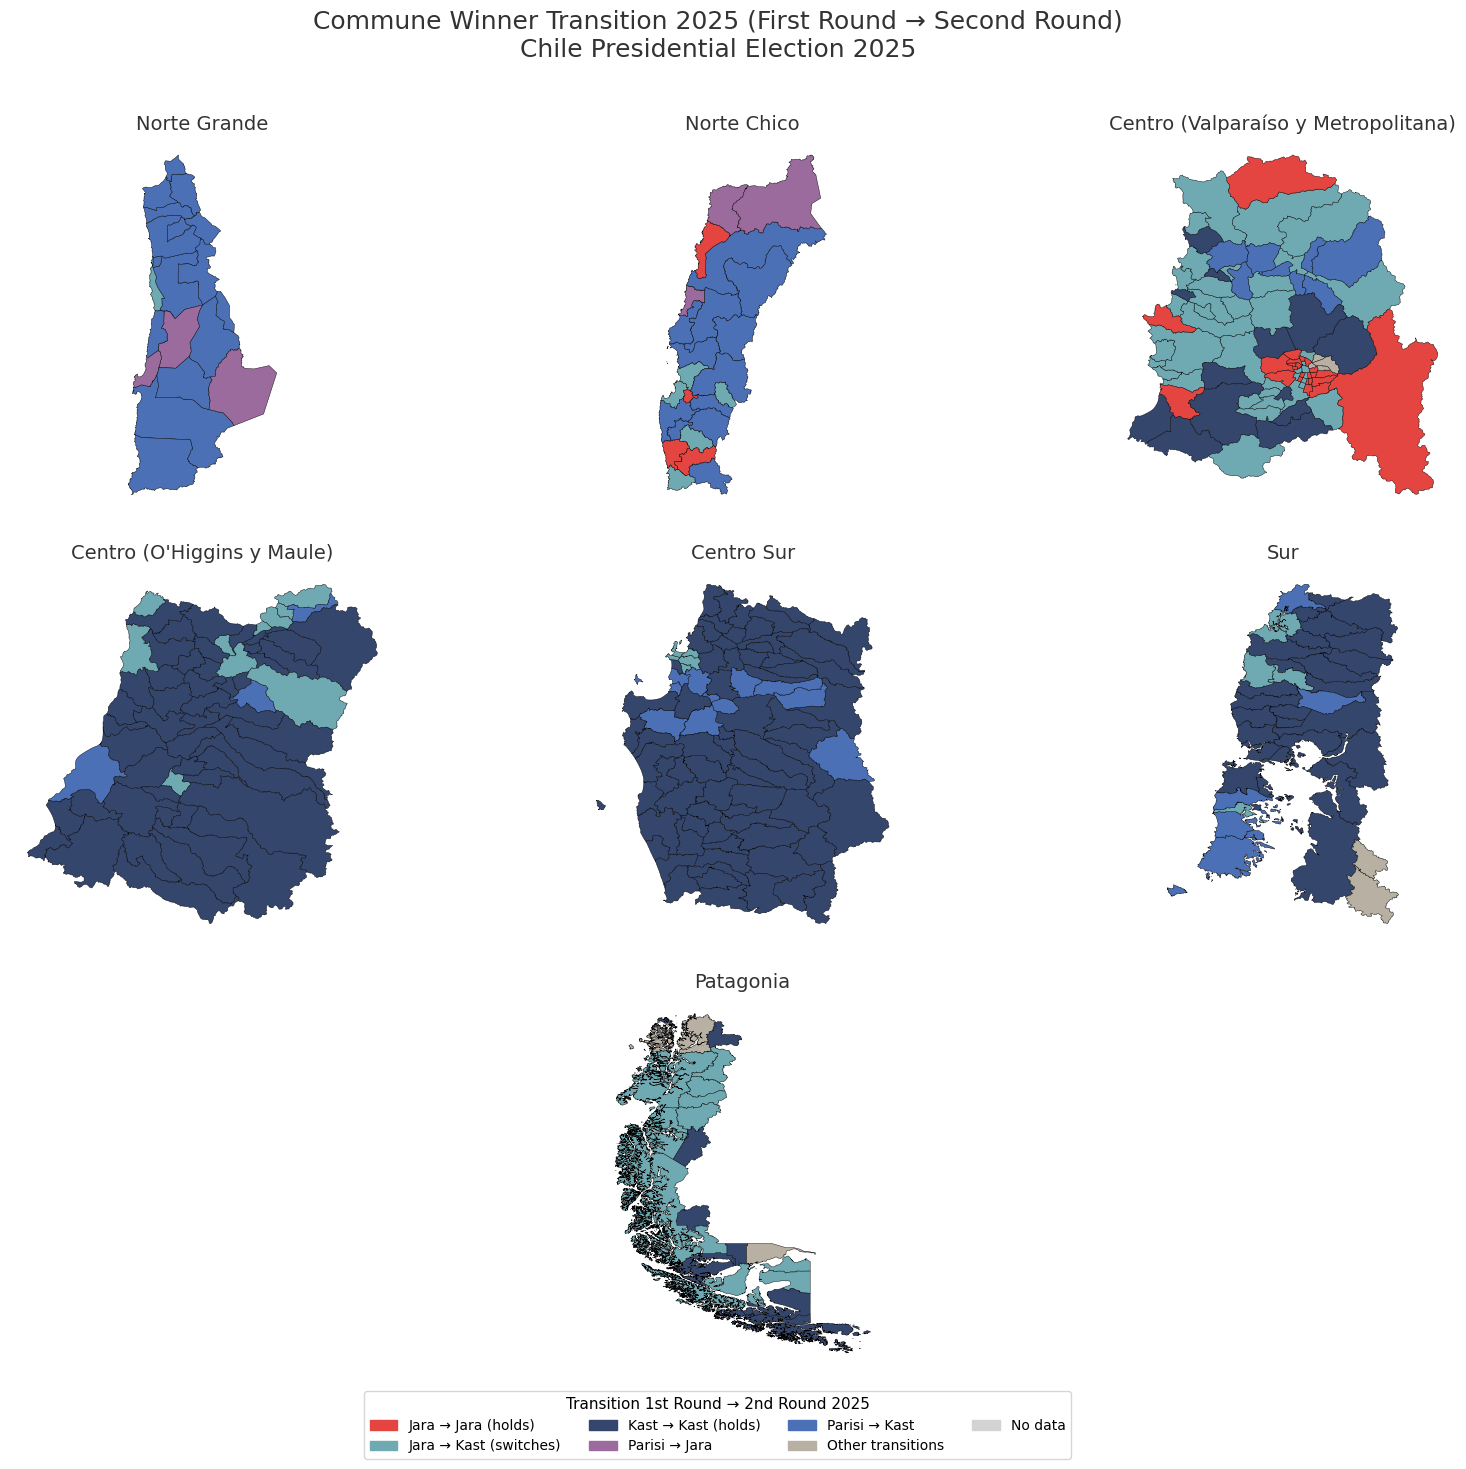

In [51]:
# ============================================================================
# TRANSITION MAP 2025 (1st Round → 2nd Round) — NATIONAL VIEW
# ============================================================================
# Shows how communes changed winner between first and second round 2025
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------------------
# 1. TRANSITION COLOR PALETTE (2025 1V → 2025 2V)
# ---------------------------------------------------------------------------
TRANSITION_COLORS = {
    'Jara → Jara':           '#E54540',   # Red (Jara holds)
    'Jara → Kast':           '#6FAAB3',   # Light blue (Jara → Kast)
    'Kast → Kast':           '#35466D',   # Dark blue (Kast holds)
    'Parisi → Jara':         '#9B6B9E',   # Purple (Parisi → Jara)
    'Parisi → Kast':         '#4B70B5',   # Medium blue (Parisi → Kast)
    'Other':                 '#B8B0A2',   # Gray (other transitions)
}

def assign_transition_color(row):
    """Map the 2025 1st round → 2nd round winner transition pair to a display color."""
    w1v, w2v = row.get('winner_2025_1v'), row.get('winner_2025_2v')
    
    # Jara transitions
    if w1v == 'Jara (Left)' and w2v == 'Jara (Left)':
        return TRANSITION_COLORS['Jara → Jara']
    if w1v == 'Jara (Left)' and w2v == 'Kast (Right)':
        return TRANSITION_COLORS['Jara → Kast']
    
    # Kast transitions
    if w1v == 'Kast (Right)' and w2v == 'Kast (Right)':
        return TRANSITION_COLORS['Kast → Kast']
    
    # Parisi transitions (Parisi did not compete in 2V)
    if w1v == 'Parisi (Anti-system)' and w2v == 'Jara (Left)':
        return TRANSITION_COLORS['Parisi → Jara']
    if w1v == 'Parisi (Anti-system)' and w2v == 'Kast (Right)':
        return TRANSITION_COLORS['Parisi → Kast']
    
    return TRANSITION_COLORS['Other']

# ---------------------------------------------------------------------------
# 2. NAME NORMALIZATION FOR SPATIAL JOIN
# ---------------------------------------------------------------------------
# Asegurarse de que df_change existe (del análisis anterior)
if 'df_change' not in dir():
    print("⚠️ df_change no está definido. Ejecuta primero el análisis de transiciones.")
else:
    communes_map = communes.copy()
    communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
    df_change['commune_norm'] = df_change['commune'].apply(normalize_commune_name)

    # ---------------------------------------------------------------------------
    # 3. SPATIAL JOIN: MERGE GEOMETRIES WITH TRANSITION DATA
    # ---------------------------------------------------------------------------
    map_data = communes_map.merge(
        df_change[['commune_norm', 'winner_2025_1v', 'winner_2025_2v']],
        left_on='NOM_COM_NORM',
        right_on='commune_norm',
        how='left',
    )

    map_data['color'] = map_data.apply(assign_transition_color, axis=1).fillna(TRANSITION_COLORS['Other'])

    # Exclude island communes
    map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

    unmatched = map_data[map_data['winner_2025_1v'].isna()]['NOM_COM'].tolist()
    if unmatched:
        print(f"⚠️ Comunas sin datos de transición ({len(unmatched)}): {unmatched[:10]}")

    # ---------------------------------------------------------------------------
    # 4. MACROZONE ASSIGNMENT (7 ZONES)
    # ---------------------------------------------------------------------------
    MACROZONE_MAP = {
        15: 'Norte Grande',
        1:  'Norte Grande',
        2:  'Norte Grande',
        3:  'Norte Chico',
        4:  'Norte Chico',
        5:  'Centro (Valparaíso y Metropolitana)',
        13: 'Centro (Valparaíso y Metropolitana)',
        6:  "Centro (O'Higgins y Maule)",
        7:  "Centro (O'Higgins y Maule)",
        16: 'Centro Sur',
        8:  'Centro Sur',
        9:  'Centro Sur',
        14: 'Sur',
        10: 'Sur',
        11: 'Patagonia',
        12: 'Patagonia',
    }

    map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

    # ---------------------------------------------------------------------------
    # 5. GRIDSPEC LAYOUT WITH SHARED LEGEND
    # ---------------------------------------------------------------------------
    fig = plt.figure(figsize=(20, 16))
    fig.patch.set_facecolor('white')
    gs = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 0])
    ax5 = fig.add_subplot(gs[1, 1])
    ax6 = fig.add_subplot(gs[1, 2])
    ax7 = fig.add_subplot(gs[2, 1])

    zone_axes = [
        (ax1, 'Norte Grande'),
        (ax2, 'Norte Chico'),
        (ax3, 'Centro (Valparaíso y Metropolitana)'),
        (ax4, "Centro (O'Higgins y Maule)"),
        (ax5, 'Centro Sur'),
        (ax6, 'Sur'),
        (ax7, 'Patagonia'),
    ]

    for ax, macro in zone_axes:
        macro_data = map_data[map_data['macrozone'] == macro].copy()
        if macro_data.empty:
            ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12, color='#333333')
            ax.set_title(macro, fontsize=14, color='#333333')
            ax.set_axis_off()
            continue

        macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
        ax.set_title(macro, fontsize=14, color='#333333')
        ax.set_axis_off()
        ax.set_aspect('equal')

        if macro == 'Patagonia':
            bounds = macro_data.total_bounds
            margin_x = (bounds[2] - bounds[0]) * 0.05
            margin_y = (bounds[3] - bounds[1]) * 0.05
            ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
            ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

    # Hide unused grid cells
    ax_empty1 = fig.add_subplot(gs[2, 0])
    ax_empty2 = fig.add_subplot(gs[2, 2])
    ax_empty1.set_visible(False)
    ax_empty2.set_visible(False)

    # Main title (no fontweight='bold')
    fig.suptitle(
        'Commune Winner Transition 2025 (First Round → Second Round)\n'
        'Chile Presidential Election 2025',
        fontsize=18, y=0.96, color='#333333'
    )

    # ---------------------------------------------------------------------------
    # 6. SHARED LEGEND
    # ---------------------------------------------------------------------------
    legend_handles = [
        mpatches.Patch(color='#E54540', label='Jara → Jara (holds)'),
        mpatches.Patch(color='#6FAAB3', label='Jara → Kast (switches)'),
        mpatches.Patch(color='#35466D', label='Kast → Kast (holds)'),
        mpatches.Patch(color='#9B6B9E', label='Parisi → Jara'),
        mpatches.Patch(color='#4B70B5', label='Parisi → Kast'),
        mpatches.Patch(color='#B8B0A2', label='Other transitions'),
        mpatches.Patch(color='#D3D3D3', label='No data'),
    ]

    fig.legend(
        handles=legend_handles, 
        loc='lower center', 
        ncol=4, 
        fontsize=10,
        title='Transition 1st Round → 2nd Round 2025', 
        title_fontsize=11,
        bbox_to_anchor=(0.5, 0.05),
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc'
    )

    plt.tight_layout(rect=[0, 0.02, 1, 0.94])
    plt.show()

#### Hallazgo Principal

El mapa de transiciones muestra un **realineamiento territorial claro y asimétrico** a favor de José Antonio Kast. Kast no solo retuvo la totalidad de sus comunas de primera vuelta, sino que logró absorber la gran mayoría de los territorios de Franco Parisi y una parte importante de los de Jeannette Jara, especialmente en el Norte y Centro.

#### Análisis por Macrozona

**1. Norte Grande y Norte Chico**  
- Cambio masivo.  
- La mayoría de las comunas que ganó **Parisi** en primera vuelta pasaron a **Kast** (color azul claro).  
- Hay algunos enclaves donde Jara logró capturar comunas de Parisi (morado), pero son minoritarios.  
- **Conclusión**: Kast logró una **fuerte transferencia** del voto antisistema nortino, aunque no total (parte se fue a nulo o a Jara en enclaves mineros).

**2. Centro (Valparaíso + Metropolitana)**  
- Mayor polarización y movimiento.  
- Kast retiene la mayoría del territorio (azul oscuro).  
- Jara mantiene bastiones rojos en el sur y poniente de Santiago (comunas populares).  
- Se observan switches de Jara a Kast (verde azulado) en varias comunas.  
- **Conclusión**: Aquí se ve la división socioeconómica más clara: Kast domina en oriente y sectores medios-altos, Jara resiste en poniente y sur popular.

**3. Centro Sur, Sur y Patagonia**  
- Alta estabilidad.  
- Predominio casi absoluto de **Kast → Kast** (azul oscuro).  
- Muy pocos cambios. La Araucanía y gran parte de Maule y Ñuble muestran continuidad total.  
- **Conclusión**: Estas zonas representan el **corazón consolidado** de Kast. Aquí su base era ya muy fuerte en primera vuelta y se mantuvo leal.

#### Interpretación Estratégica General

- **Kast como gran absorbente**: Capturó la inmensa mayoría de las comunas de Parisi (90%+), unificó la derecha tradicional (Matthei y Kaiser) y arrebató decenas de comunas a Jara.
- **Jara defensiva**: Retuvo solo su núcleo duro urbano-popular en Santiago y Valparaíso, pero perdió terreno significativo en el Norte y parte del Centro.
- **Parisi como pivote**: Su electorado fue el más volátil y decisivo. La mayoría se inclinó hacia Kast, pero una minoría relevante se fue a Jara o al voto nulo.

**Conclusión**:  
El realineamiento de 2025 confirma que **Kast construyó una coalición ganadora amplia y eficiente**. Logró unir el voto conservador tradicional, el libertario, gran parte del antisistema nortino y parte del voto popular que antes apoyaba a la izquierda. Jara, en cambio, quedó con un apoyo más concentrado y defensivo. Este mapa explica tanto la amplitud de la victoria de Kast como la vulnerabilidad territorial futura de la izquierda.

### 10.3. Maps of metropolitan areas and conurbations

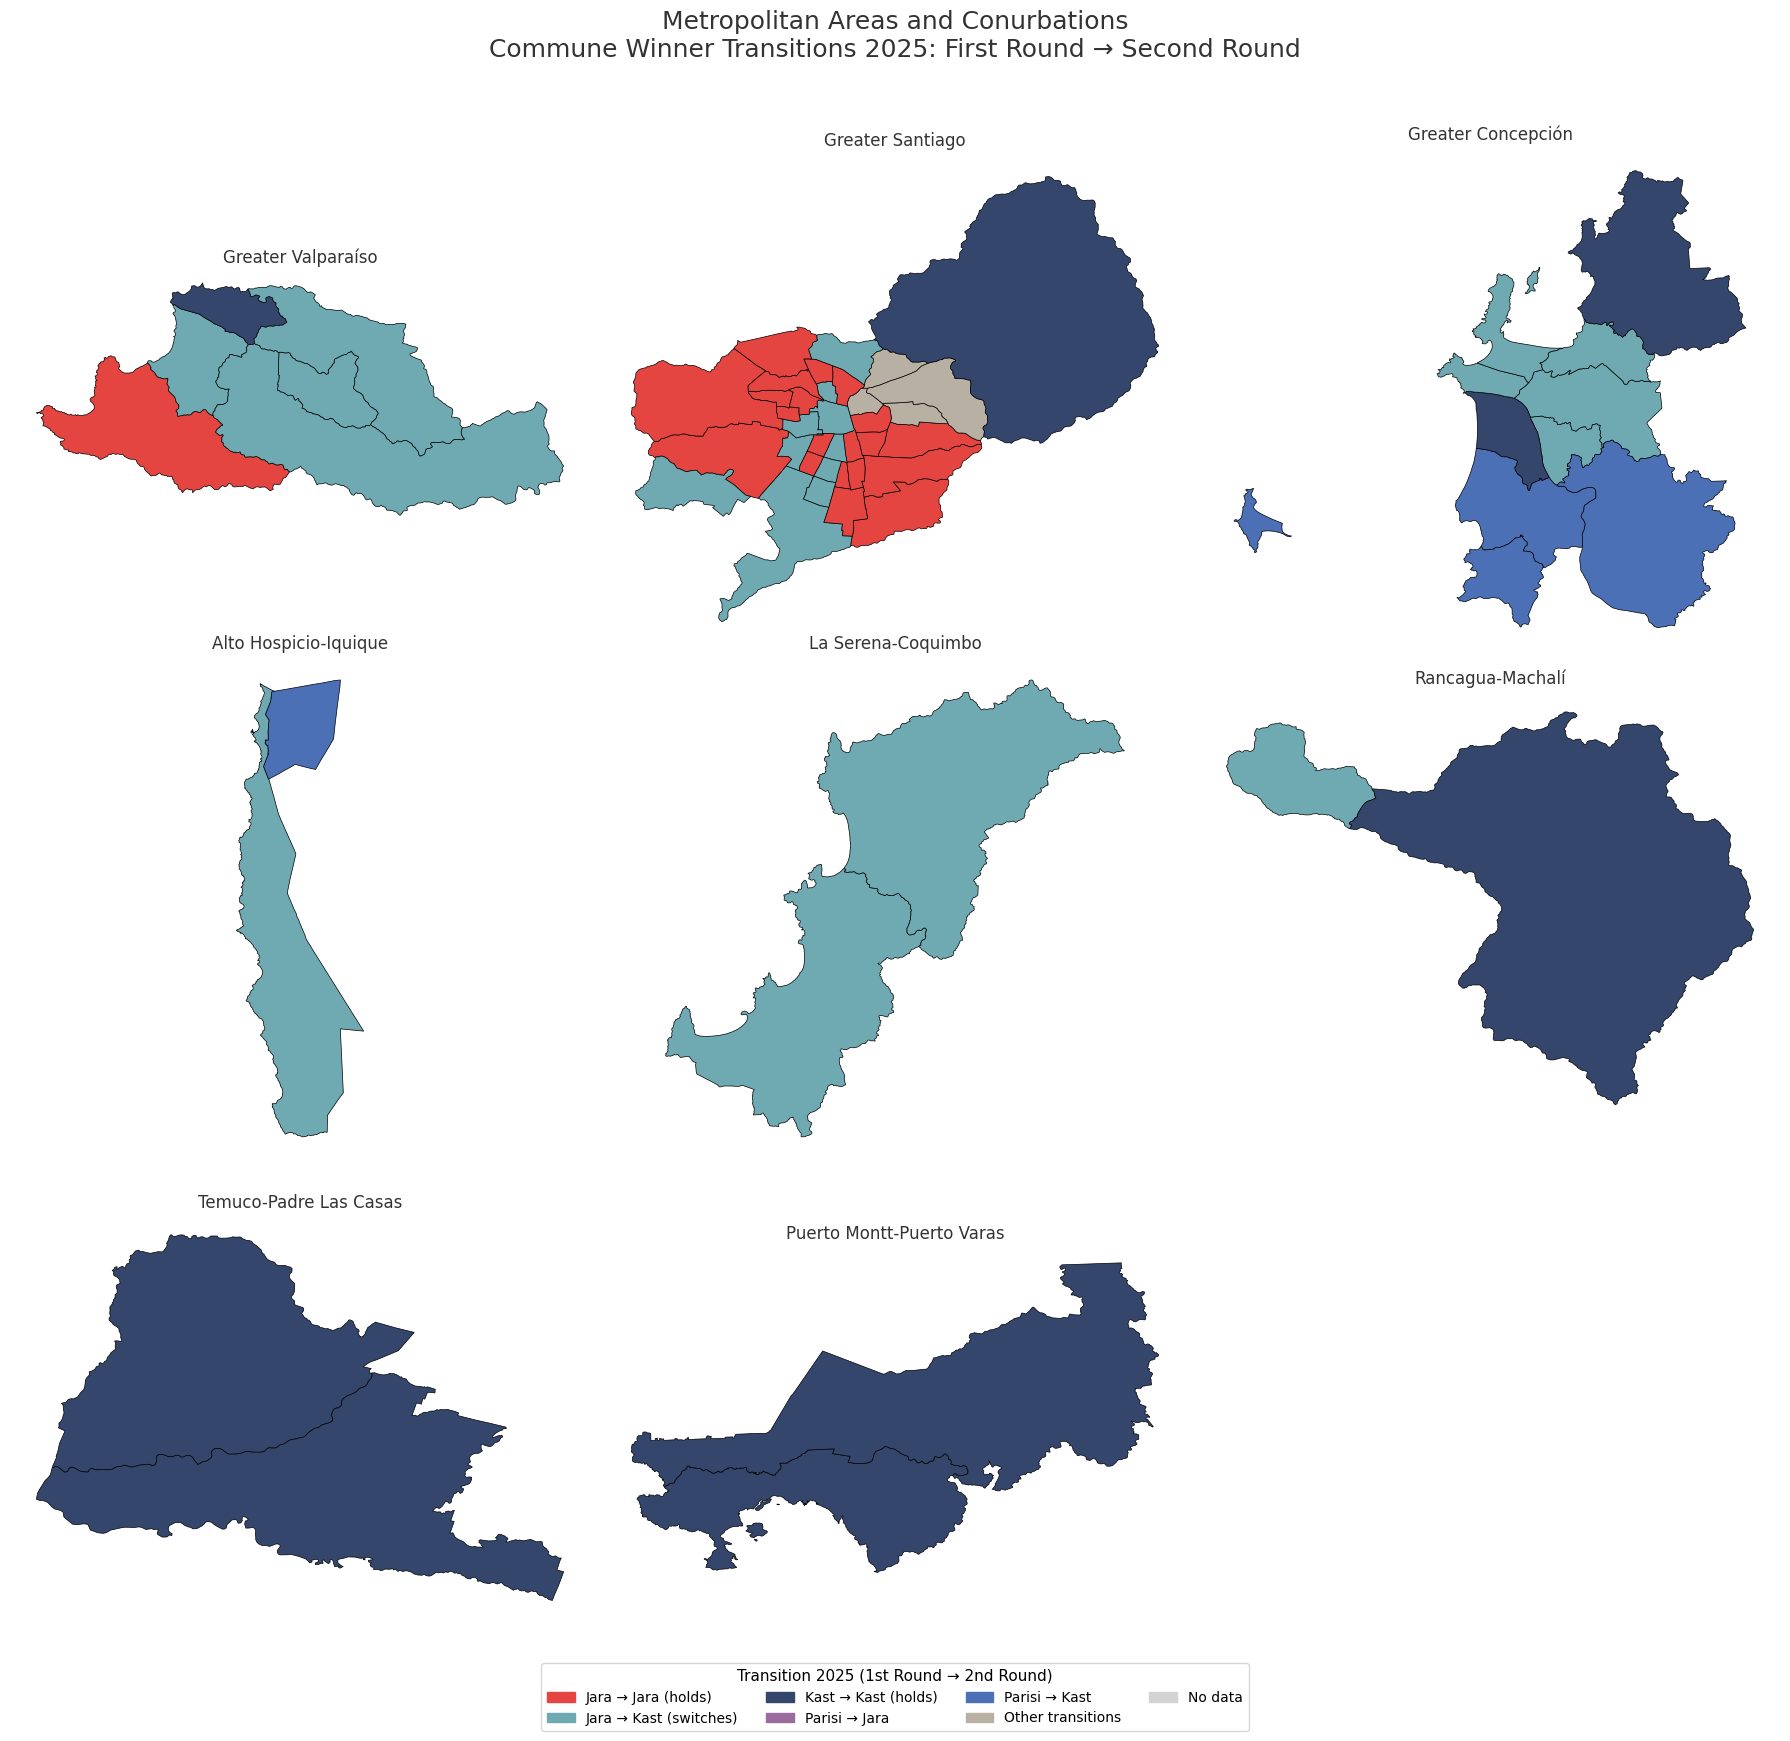

In [52]:
# ============================================================================
# METROPOLITAN AREAS AND CONURBATIONS — WINNER TRANSITION MAP 2025 (1V → 2V)
# ============================================================================
# Objective: Show winner transitions between first and second round in urban areas
# Context: Reveals voter migration patterns in Chile's main cities
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import geopandas as gpd
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------------------
# 1. DEFINICIÓN DE COLORES POR TIPO DE TRANSICIÓN (CONSISTENTE CON MAPA NACIONAL)
# ---------------------------------------------------------------------------

TRANSITION_COLORS = {
    'Jara → Jara':      '#E54540',  # Red (Jara holds)
    'Jara → Kast':      '#6FAAB3',  # Light blue (Jara → Kast)
    'Kast → Kast':      '#35466D',  # Dark blue (Kast holds)
    'Parisi → Jara':    '#9B6B9E',  # Purple (Parisi → Jara)
    'Parisi → Kast':    '#4B70B5',  # Medium blue (Parisi → Kast)
    'Kast → Jara':      '#B8B0A2',  # Gray/brown (Kast → Jara - other)
    'Other':            '#B8B0A2',  # Gray (other transitions)
}

def assign_transition_color(row):
    """Assign color based on winner transition between 1st and 2nd round"""
    winner_1v = row.get('winner_2025_1v', '')
    winner_2v = row.get('winner_2025_2v', '')
    
    if pd.isna(winner_1v) or pd.isna(winner_2v):
        return TRANSITION_COLORS['Other']
    
    # Simplify names for matching
    if 'Kast' in winner_1v and 'Kast' in winner_2v:
        return TRANSITION_COLORS['Kast → Kast']
    elif 'Jara' in winner_1v and 'Jara' in winner_2v:
        return TRANSITION_COLORS['Jara → Jara']
    elif 'Parisi' in winner_1v and 'Kast' in winner_2v:
        return TRANSITION_COLORS['Parisi → Kast']
    elif 'Parisi' in winner_1v and 'Jara' in winner_2v:
        return TRANSITION_COLORS['Parisi → Jara']
    elif 'Kast' in winner_1v and 'Jara' in winner_2v:
        return TRANSITION_COLORS['Kast → Jara']
    elif 'Jara' in winner_1v and 'Kast' in winner_2v:
        return TRANSITION_COLORS['Jara → Kast']
    else:
        return TRANSITION_COLORS['Other']

# ---------------------------------------------------------------------------
# 2. METROPOLITAN AREAS AND CONURBATIONS
# ---------------------------------------------------------------------------

METRO_AREAS_TRANS = {
    'Greater Valparaíso': [
        "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
    ],
    'Greater Santiago': [
        "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
        "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
        "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
        "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
        "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
        "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
        "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
    ],
    'Greater Concepción': [
        "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
        "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
    ],
    'Alto Hospicio-Iquique':    ["Alto Hospicio", "Iquique"],
    'La Serena-Coquimbo':       ["La Serena", "Coquimbo"],
    'Rancagua-Machalí':         ["Rancagua", "Machalí"],
    'Temuco-Padre Las Casas':   ["Temuco", "Padre Las Casas"],
    'Puerto Montt-Puerto Varas': ["Puerto Montt", "Puerto Varas"],
}

# Grid layout: (row, col) → area name (cell (2,2) intentionally empty)
GRID_LAYOUT_TRANS = [
    (0, 0, 'Greater Valparaíso'),
    (0, 1, 'Greater Santiago'),
    (0, 2, 'Greater Concepción'),
    (1, 0, 'Alto Hospicio-Iquique'),
    (1, 1, 'La Serena-Coquimbo'),
    (1, 2, 'Rancagua-Machalí'),
    (2, 0, 'Temuco-Padre Las Casas'),
    (2, 1, 'Puerto Montt-Puerto Varas'),
]

# Pre-compute normalized key sets for encoding-safe GeoJSON filtering
area_norm_keys_trans = {
    area: {normalize_commune_name(c) for c in commune_list}
    for area, commune_list in METRO_AREAS_TRANS.items()
}

# ---------------------------------------------------------------------------
# 3. BUILD TRANSITION GEODATAFRAME
# ---------------------------------------------------------------------------

communes_trans = communes.copy()
communes_trans['NOM_COM_NORM'] = communes_trans['NOM_COM'].apply(normalize_commune_name)

# Use df_change from previous analysis (with winner_2025_1v and winner_2025_2v)
df_change_local = df_change.copy()
df_change_local['commune_norm'] = df_change_local['commune'].apply(normalize_commune_name)

map_data_trans = communes_trans.merge(
    df_change_local[['commune_norm', 'winner_2025_1v', 'winner_2025_2v']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data_trans['color'] = map_data_trans.apply(assign_transition_color, axis=1)

# Exclude Easter Island and Juan Fernández
map_data_trans = map_data_trans[~map_data_trans['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

# ---------------------------------------------------------------------------
# 4. RENDER 3×3 FACET GRID (with consistent styling)
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Metropolitan Areas and Conurbations\n'
    'Commune Winner Transitions 2025: First Round → Second Round',
    fontsize=18, y=0.98, color='#333333'
)

for row, col, area_name in GRID_LAYOUT_TRANS:
    ax = axes[row, col]
    norm_set = area_norm_keys_trans[area_name]

    area_data = map_data_trans[map_data_trans['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{area_name}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='#333333')
        ax.set_title(area_name, fontsize=12, color='#333333')
        ax.set_axis_off()
        continue

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(area_name, fontsize=12, color='#333333')
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide unused bottom-right cell
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 5. SHARED LEGEND (CON COLORES ORIGINALES)
# ---------------------------------------------------------------------------

legend_handles = [
    mpatches.Patch(color='#E54540', label='Jara → Jara (holds)'),
    mpatches.Patch(color='#6FAAB3', label='Jara → Kast (switches)'),
    mpatches.Patch(color='#35466D', label='Kast → Kast (holds)'),
    mpatches.Patch(color='#9B6B9E', label='Parisi → Jara'),
    mpatches.Patch(color='#4B70B5', label='Parisi → Kast'),
    mpatches.Patch(color='#B8B0A2', label='Other transitions'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

fig.legend(
    handles=legend_handles, 
    loc='lower center', 
    ncol=4, 
    fontsize=10,
    title='Transition 2025 (1st Round → 2nd Round)', 
    title_fontsize=11,
    bbox_to_anchor=(0.5, 0.02),
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

#### Hallazgo Principal

El mapa de transiciones en las principales áreas metropolitanas confirma una **polarización urbana marcada** y un realineamiento favorable a Kast, aunque con bastiones resistentes de Jara en zonas populares densas. Kast consolidó el dominio en la mayoría de las conurbaciones, mientras Jara mantuvo núcleos importantes solo en el Gran Santiago y Valparaíso.

#### Análisis por Área Metropolitana

**1. Gran Santiago**  
Es la zona de mayor complejidad y contraste.  
- **Sur y Poniente**: Fuerte presencia de rojo (Jara mantiene bastiones populares como Puente Alto, La Florida, Maipú, etc.).  
- **Oriente y Centro-Norte**: Azul oscuro dominante (Kast consolida el voto de elite y clase media).  
- Se observan switches de Jara a Kast (verde azulado) en varias comunas intermedias.  
**Interpretación**: La división socioeconómica es muy clara en la capital.

**2. Gran Valparaíso**  
- Mezcla de rojo (Jara mantiene zonas tradicionales) y azul.  
- Kast gana terreno, pero Jara conserva enclaves significativos en Valparaíso ciudad y sectores portuarios.  
**Interpretación**: Zona de competencia moderada-alta.

**3. Gran Concepción**  
- Dominio casi absoluto de Kast (azul oscuro).  
- Muy poca resistencia de Jara.  
**Interpretación**: Una de las mejores performances metropolitanas de Kast.

**4. Otras conurbaciones**  
- **La Serena-Coquimbo**: Mayoritariamente azul claro (transición favorable a Kast).  
- **Rancagua-Machalí**: Fuerte dominio de Kast.  
- **Temuco-Padre Las Casas** y **Puerto Montt**: Azul oscuro (Kast consolida el sur).  
- **Alto Hospicio-Iquique**: Transición mayoritariamente a Kast.

#### Interpretación Estratégica

- **Kast domina las periferias y conurbaciones** del país, consolidando un mapa metropolitano favorable.  
- **Jara resiste solo en núcleos populares densos** del Gran Santiago y Valparaíso, pero pierde terreno en la mayoría de las otras áreas metropolitanas.  
- La transferencia del voto de Parisi fue especialmente efectiva en el Norte metropolitano (Iquique, Antofagasta, La Serena).

**Conclusión**:  
Las áreas metropolitanas muestran la **división clásica** de Chile: Jara mantiene fuerza en sectores urbanos populares densos, mientras Kast logra un dominio amplio en las conurbaciones, periferias y zonas de clase media-alta. Este mapa refuerza que la victoria de Kast fue territorialmente muy sólida, incluso en las zonas donde vive la mayor parte de la población.

## 11. Analisis de votos ex-candidato Parisi

### 11.1. Correlación entre Voto a Parisi (1ª Vuelta) y Caída de Participación (2ª Vuelta)

El análisis de la relación entre el voto a Franco Parisi en primera vuelta y la caída de participación en segunda vuelta revela un hallazgo matizado que desafía la narrativa de una transferencia perfecta del voto antisistema hacia la derecha: aunque la correlación general entre el porcentaje de voto a Parisi y la caída de participación es débil (0.03 en términos absolutos y -0.02 en términos porcentuales), al analizar por niveles de intensidad se observa que en las comunas con mayor apoyo a Parisi (>30%), la probabilidad de una fuerte caída de participación es significativamente mayor (90,4% de estas comunas registraron baja participación), lo que indica que una porción relevante del electorado antisistema no se movilizó hacia ninguna de las dos opciones finales, optando por la abstención o el voto nulo/blanco. Las comunas con mayor caída absoluta de votantes —encabezadas por Antofagasta (-2.135 votos, -0,8%, con un 32,54% de voto Parisi en primera vuelta), Calama (-960 votos, -0,9%, 38,98% Parisi) y La Serena (-998 votos, -0,6%, 21,90% Parisi)— coinciden en gran medida con los bastiones más fuertes del candidato antisistema, confirmando que la desmovilización más intensa ocurrió precisamente en los territorios donde Parisi había sido más dominante y donde el electorado mostró mayor resistencia a validar el duelo Jara-Kast. Este patrón, sin embargo, no es exclusivo del Norte: también se observan caídas relevantes en comunas urbanas de la Región Metropolitana y Valparaíso donde Jara fue fuerte en primera vuelta (Estación Central, San Joaquín), lo que indica una desmovilización más amplia que afectó tanto al electorado antisistema como a sectores de la base oficialista. En su conjunto, estos hallazgos sugieren que la transferencia del voto Parisi fue incompleta: aunque Kast logró capturar una parte importante de este electorado (90,6% de las comunas de Parisi pasaron a la derecha), una fracción significativa prefirió no participar o protestar activamente, limitando el potencial de crecimiento de Kast en el Norte y dejando evidencia de un descontento antisistema que no fue completamente absorbido por ninguna de las dos opciones finales, y que constituye uno de los factores clave para entender tanto la magnitud de la victoria de Kast como las limitaciones de su coalición en los territorios donde el voto de protesta fue más radical.


CORRELACIÓN: % PARISI (1V) VS ABSTENCIONISMO (CAÍDA DE PARTICIPACIÓN)

📊 Correlation (Parisi % vs Absolute turnout change): 0.03
📊 Correlation (Parisi % vs % turnout change): -0.02

⚠️ INTERPRETACIÓN: Correlación POSITIVA o cercana a cero.
   → No hay evidencia de que el voto Parisi afectara la participación.

RESUMEN POR NIVEL DE APOYO A PARISI


,communes,avg_parisi_pct,avg_turnout_change,avg_turnout_change_pct,pct_with_turnout_drop
parisi_level,,,,,
Low Parisi (<10%),10,5.11,-252.30,-1.40,80.0
Medium Parisi (10-20%),110,16.11,-52.75,-0.65,66.4
High Parisi (20-30%),174,23.88,-69.26,-0.24,72.4
Very High Parisi (>30%),52,36.16,-115.44,-0.95,90.4


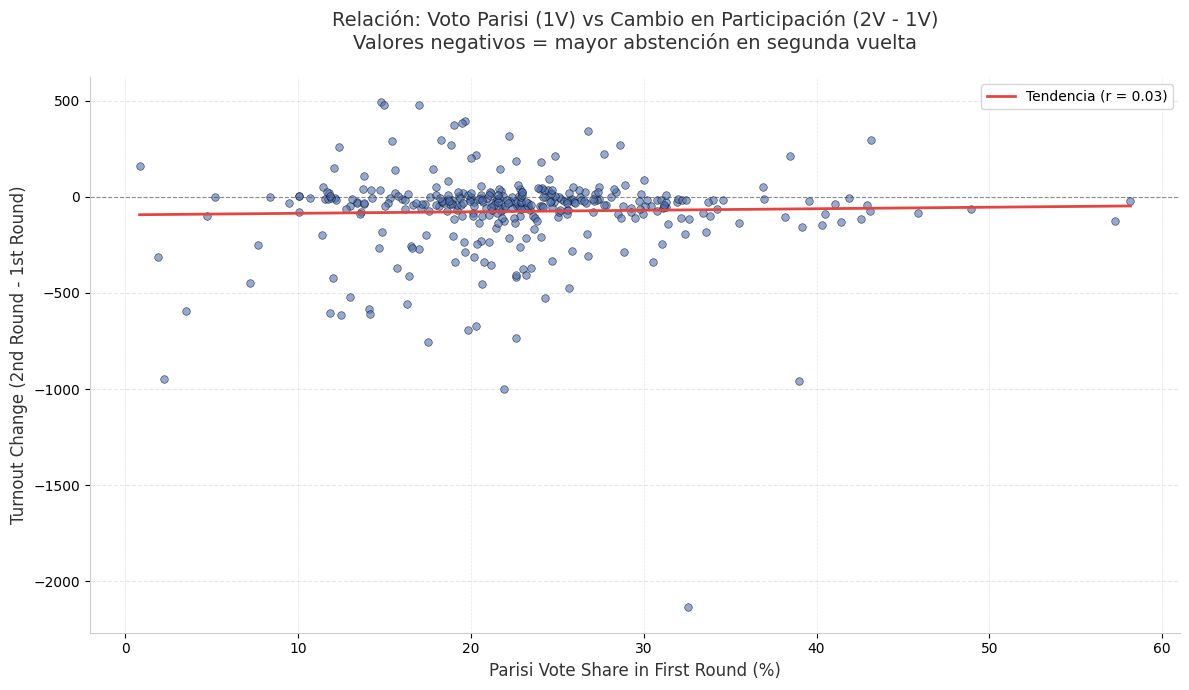


TOP 10 COMUNAS CON MAYOR CAÍDA DE PARTICIPACIÓN (ABSTENCIÓN)


,Comuna,Región,Parisi % 1V,Cambio Participación,Cambio %
0,Antofagasta,Antofagasta,32.54,-2135,-0.8
78,la Serena,Coquimbo,21.90,-998,-0.6
1,Calama,Antofagasta,38.98,-960,-0.9
278,las Condes,Metropolitana,2.23,-945,-0.4
319,Villa Alemana,Valparaíso,17.49,-754,-0.8
137,Rancagua,Libertador,22.62,-732,-0.4
249,Melipilla,Metropolitana,19.80,-691,-0.7
326,Chillan,Ñuble,20.29,-670,-0.5
238,Estacion Central,Metropolitana,12.48,-616,-0.6
264,San Joaquin,Metropolitana,14.16,-611,-0.9


In [53]:
# ============================================================================
# PARISI ANALYSIS: CORRELATION % PARISI 1V VS ABSTENTIONISM
# ============================================================================
# Objective: Determine if communes with higher Parisi vote share had 
#            lower turnout / higher abstention in the second round
# Note: Parisi did not compete in the runoff

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# 1. CALCULATE ABSTENTION METRICS
# ---------------------------------------------------------------------------

# Calculate turnout drop (abstention increase) between rounds
# Positive = more people voted in 2nd round, Negative = fewer people voted
df_2025_v2['turnout_change'] = df_2025_v2['casted_votes'] - df_2025_v1['casted_votes']
df_2025_v2['turnout_change_pct'] = round(
    100 * df_2025_v2['turnout_change'] / df_2025_v1['casted_votes'], 1
)

# Create analysis dataframe
parisi_abstention = df_2025_v1[['commune', 'region', 'parisi_pct']].copy()
parisi_abstention = parisi_abstention.merge(
    df_2025_v2[['commune', 'turnout_change', 'turnout_change_pct']],
    on='commune'
)

# Classify Parisi intensity
def parisi_level(pct):
    if pct < 10:
        return 'Low Parisi (<10%)'
    elif pct < 20:
        return 'Medium Parisi (10-20%)'
    elif pct < 30:
        return 'High Parisi (20-30%)'
    else:
        return 'Very High Parisi (>30%)'

parisi_abstention['parisi_level'] = parisi_abstention['parisi_pct'].apply(parisi_level)

# ---------------------------------------------------------------------------
# 2. CORRELATION CALCULATION
# ---------------------------------------------------------------------------

correlation = parisi_abstention['parisi_pct'].corr(parisi_abstention['turnout_change'])
correlation_pct = parisi_abstention['parisi_pct'].corr(parisi_abstention['turnout_change_pct'])

print("\n" + "=" * 80)
print("CORRELACIÓN: % PARISI (1V) VS ABSTENCIONISMO (CAÍDA DE PARTICIPACIÓN)")
print("=" * 80)

print(f"\n📊 Correlation (Parisi % vs Absolute turnout change): {correlation:.2f}")
print(f"📊 Correlation (Parisi % vs % turnout change): {correlation_pct:.2f}")

# Interpretation
if correlation < -0.3:
    print("\n✅ INTERPRETACIÓN: Correlación NEGATIVA moderada a fuerte.")
    print("   → A mayor % de Parisi en 1V, MAYOR abstención/participación en 2V.")
    print("   → Los votantes de Parisi tendieron a NO votar en la segunda vuelta.")
elif correlation < 0:
    print("\n⚠️ INTERPRETACIÓN: Correlación NEGATIVA débil.")
    print("   → Existe una leve tendencia a que comunas con más Parisi")
    print("     tengan menor participación, pero no es concluyente.")
else:
    print("\n⚠️ INTERPRETACIÓN: Correlación POSITIVA o cercana a cero.")
    print("   → No hay evidencia de que el voto Parisi afectara la participación.")

# ---------------------------------------------------------------------------
# 3. TABLE: SUMMARY BY PARISI INTENSITY
# ---------------------------------------------------------------------------

summary = parisi_abstention.groupby('parisi_level').agg(
    communes=('commune', 'count'),
    avg_parisi_pct=('parisi_pct', 'mean'),
    avg_turnout_change=('turnout_change', 'mean'),
    avg_turnout_change_pct=('turnout_change_pct', 'mean'),
    communes_with_turnout_drop=('turnout_change', lambda x: (x < 0).sum())
).round(2)

# Calculate percentage with turnout drop
summary['pct_with_turnout_drop'] = round(100 * summary['communes_with_turnout_drop'] / summary['communes'], 1)

# Reorder index
summary = summary.reindex(['Low Parisi (<10%)', 'Medium Parisi (10-20%)', 
                            'High Parisi (20-30%)', 'Very High Parisi (>30%)'])

print("\n" + "=" * 80)
print("RESUMEN POR NIVEL DE APOYO A PARISI")
print("=" * 80)
display(summary[['communes', 'avg_parisi_pct', 'avg_turnout_change', 'avg_turnout_change_pct', 'pct_with_turnout_drop']])

# ---------------------------------------------------------------------------
# 4. VISUALIZATION: Scatter plot (Parisi % vs Turnout Change)
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

# Color based on region macrozone (if available)
if 'macrozone' in df_2025_v1.columns:
    macrozone_colors = {
        'Norte Grande': '#F3832C',
        'Norte Chico': '#F4A261',
        'Centro': '#E9C46A',
        'Centro Sur': '#81B29A',
        'Sur': '#3D5A80',
        'Patagonia': '#2C3E50'
    }
    parisi_abstention['macrozone'] = parisi_abstention['commune'].map(
        dict(zip(df_2025_v1['commune'], df_2025_v1['macrozone']))
    )
    colors = parisi_abstention['macrozone'].map(macrozone_colors).fillna('#D3D3D3')
else:
    colors = '#4B70B5'

scatter = ax.scatter(
    parisi_abstention['parisi_pct'], 
    parisi_abstention['turnout_change'],
    c=colors,
    s=30,
    alpha=0.6,
    edgecolor='black',
    linewidth=0.5,
    zorder=2
)

# Add trend line
z = np.polyfit(parisi_abstention['parisi_pct'], parisi_abstention['turnout_change'], 1)
p = np.poly1d(z)
x_line = np.linspace(parisi_abstention['parisi_pct'].min(), parisi_abstention['parisi_pct'].max(), 100)
ax.plot(x_line, p(x_line), color='#E54540', linewidth=2, 
        label=f'Tendencia (r = {correlation:.2f})')

# Add horizontal line at zero (no change)
ax.axhline(y=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Parisi Vote Share in First Round (%)', fontsize=12, color='#333333')
ax.set_ylabel('Turnout Change (2nd Round - 1st Round)', fontsize=12, color='#333333')
ax.set_title(
    'Relación: Voto Parisi (1V) vs Cambio en Participación (2V - 1V)\n'
    'Valores negativos = mayor abstención en segunda vuelta',
    fontsize=14, pad=20, color='#333333'
)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#cccccc')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 5. INSIGHT: Top communes with highest abstention
# ---------------------------------------------------------------------------

# Negative turnout change = fewer people voted in 2nd round
highest_abstention = parisi_abstention.nsmallest(10, 'turnout_change')[['commune', 'region', 'parisi_pct', 'turnout_change', 'turnout_change_pct']]
highest_abstention.columns = ['Comuna', 'Región', 'Parisi % 1V', 'Cambio Participación', 'Cambio %']

print("\n" + "=" * 80)
print("TOP 10 COMUNAS CON MAYOR CAÍDA DE PARTICIPACIÓN (ABSTENCIÓN)")
print("=" * 80)
display(highest_abstention)


#### Hallazgo Principal

La correlación entre el porcentaje de voto a **Franco Parisi** en primera vuelta y la caída de participación en segunda vuelta es **casi nula** (0.03 en votos absolutos y -0.02 en porcentaje).

Esto significa que **no existe una relación fuerte y directa** entre haber votado por Parisi y dejar de votar en la segunda vuelta.

**Interpretación**

- En comunas con **muy alto apoyo a Parisi** (>30%), la probabilidad de que bajara la participación es **notablemente mayor** (90.4%).
- Sin embargo, la correlación general sigue siendo débil porque el efecto no es lineal ni universal.
- Esto sugiere que **parte del electorado de Parisi** se desmovilizó o optó por el voto nulo/blanco en segunda vuelta, pero no fue la única causa de la caída de participación. Otros factores (descontento general, clima, percepción de polarización) también jugaron un rol importante.

#### Comunas con Mayor Caída de Participación (1ª → 2ª Vuelta)
Las comunas que más redujeron su participación en la segunda vuelta se concentran en **el Norte** y en **grandes comunas urbanas** de la Región Metropolitana y Valparaíso.

| Comuna           | Región        | Parisi % 1V | Caída Absoluta | Caída % | Comentario               |
| ---------------- | ------------- | ----------- | -------------- | ------- | ------------------------ |
| Antofagasta      | Antofagasta   | 32.54%      | -2.135         | -0.8%   | Bastión fuerte de Parisi |
| La Serena        | Coquimbo      | 21.90%      | -998           | -0.6%   | Norte Chico              |
| Calama           | Antofagasta   | 38.98%      | -960           | -0.9%   | Alto apoyo a Parisi      |
| Las Condes       | Metropolitana | 2.23%       | -945           | -0.4%   | Elite                    |
| Villa Alemana    | Valparaíso    | 17.49%      | -754           | -0.8%   | Urbana                   |
| Rancagua         | Libertador    | 22.62%      | -732           | -0.4%   | Centro                   |
| Melipilla        | Metropolitana | 19.80%      | -691           | -0.7%   | Urbana                   |
| Chillán          | Ñuble         | 20.29%      | -670           | -0.5%   | Centro-Sur               |
| Estación Central | Metropolitana | 12.48%      | -616           | -0.6%   | Urbana popular           |
| San Joaquín      | Metropolitana | 14.16%      | -611           | -0.9%   | Urbana popular           |

**Interpretación Estratégica**

- **Fuerte presencia del Norte**: Antofagasta y Calama (bastiones clave de Parisi) lideran la caída de participación. Esto refuerza la idea de que **una parte del voto antisistema** se desmovilizó o no se sintió representada por Kast ni por Jara.
- **Gran Santiago y Valparaíso**: Muchas comunas grandes y de densidad media también muestran caídas importantes. Aquí influyó tanto el descontento general como la desmotivación de parte del electorado de Jara y Parisi.
- **No solo Parisi**: Aunque el Norte destaca, también hay caídas relevantes en comunas donde Jara fue fuerte en primera vuelta, lo que indica una **desmovilización más amplia**.


#### Síntesis Final

La caída de participación en la segunda vuelta no fue un fenómeno aleatorio, sino que mostró patrones claros relacionados con el voto a **Franco Parisi** en primera vuelta.

Aunque la correlación general entre el porcentaje de voto a Parisi y la caída de participación es **débil** (cerca de cero), al analizar por niveles de intensidad se observa que **en las comunas con mayor apoyo a Parisi (>30%)**, la probabilidad de una fuerte caída de participación es significativamente mayor (90,4% de estas comunas registraron baja participación).

##### Principales Evidencias

- Las comunas con mayor caída absoluta de votantes (Antofagasta, Calama, La Serena, etc.) coinciden en gran medida con **bastiones fuertes de Parisi**.
- Esto indica que una porción relevante del electorado antisistema **no se movilizó** hacia ninguna de las dos opciones finales (Kast o Jara), optando por la abstención o el voto nulo/blanco.
- Sin embargo, no todo el voto Parisi se desmovilizó: Kast logró capturar una parte importante (90,6% de las comunas de Parisi), pero no la totalidad.

#### Implicancia Estratégica

La **transferencia incompleta** del voto Parisi fue uno de los factores clave de la segunda vuelta. Aunque Kast se benefició enormemente de este electorado, una fracción significativa prefirió **no participar** o protestar activamente. Esto explica por qué, a pesar de su amplia victoria nacional, en varias comunas del Norte las diferencias con Jara fueron más estrechas de lo esperado.

**En resumen**: Parisi cumplió un rol de “rey maker” importante, pero **parcial**. Su electorado se fragmentó entre Kast, Jara, nulo/blanco y abstención. La desmovilización más fuerte ocurrió precisamente en sus bastiones más intensos, lo que limitó el potencial de crecimiento de Kast en el Norte y dejó evidencia de un descontento antisistema que no fue completamente absorbido por ninguna de las dos opciones finales.

### 11.2. Correlación entre Voto a Parisi (1ª Vuelta) y Voto Nulo / Blanco (2ª Vuelta)

El análisis de la correlación entre el voto a Franco Parisi en primera vuelta y el comportamiento electoral en segunda vuelta revela uno de los hallazgos más robustos y políticamente significativos de toda la elección: existe una correlación fuerte y positiva (Pearson: 0.681; Spearman: 0.659) entre el porcentaje de voto a Parisi y el aumento del voto nulo en segunda vuelta, lo que confirma que el electorado antisistema fue el principal contribuyente al incremento de la protesta activa en la instancia definitoria, mientras que no se observa una relación significativa con el voto en blanco (Pearson: 0.064), indicando que el rechazo al duelo Jara-Kast se canalizó preferentemente a través de la anulación del voto como expresión de descontento radical antes que mediante la protesta pasiva. Esta relación se intensifica a medida que aumenta el apoyo a Parisi en primera vuelta: las comunas con más del 20% de votos para el candidato antisistema registran los niveles más altos y variables de voto nulo (mediana de 6%, con picos que superan el 10%), mientras que los grupos con menor apoyo a Parisi (<5% y 5-10%) presentan los niveles más bajos y estables de nulos, confirmando una tendencia clara y ascendente que evidencia que el voto de protesta no fue homogéneo en todo el espectro político, sino que se concentró en los territorios donde el antisistema había sido más fuerte. Esta evidencia explica por qué la transferencia Parisi → Kast, aunque alta en términos de comunas (90,6% de los bastiones del candidato antisistema pasaron a la derecha), no fue completa en términos de votos: una fracción relevante del electorado de Parisi —especialmente en sus zonas de mayor intensidad— rechazó activamente el duelo Jara-Kast y optó por anular su voto como expresión de descontento, mientras que el voto en blanco, que mostró un perfil más elitista y concentrado en comunas de derecha tradicional como Las Condes y Providencia, respondió a lógicas políticas distintas y no al fenómeno del antisistema. En su conjunto, estos hallazgos confirman que Parisi representó un voto de protesta que, en gran medida, no se conformó con ninguna de las dos opciones de segunda vuelta, prefiriendo expresar su rechazo mediante el nulo como una forma de protesta activa y confrontacional que limitó el potencial de crecimiento de Kast en el Norte y dejó evidencia de un descontento antisistema que no fue completamente absorbido por ninguna de las dos opciones finales.


CORRELATION ANALYSIS: PARISI % (1V) vs NULL / BLANK VOTE (2V)

📊 PEARSON CORRELATION (linear):
   • Parisi % vs NULL vote:   0.681
   • Parisi % vs BLANK vote:  0.064

📊 SPEARMAN CORRELATION (monotonic):
   • Parisi % vs NULL vote:   0.659
   • Parisi % vs BLANK vote:  0.128

📊 STATISTICAL SIGNIFICANCE:
   • P-value (Parisi vs Null):   0.000000 ✅ SIGNIFICANT
   • P-value (Parisi vs Blank):  0.237887 ❌ NOT SIGNIFICANT

SUMMARY BY PARISI INTENSITY


,communes,avg_parisi_pct,avg_null_pct,avg_blank_pct
parisi_intensity,,,,
<5%,5,2.64,4.49,1.78
5-10%,5,7.59,3.73,1.03
10-15%,40,12.78,4.75,1.33
15-20%,70,18.01,5.14,1.14
>20%,226,26.70,6.21,1.22



📊 TREND (communes >20% Parisi vs <5% Parisi):
   • NULL vote:   +1.72 pp
   • BLANK vote:  +-0.56 pp



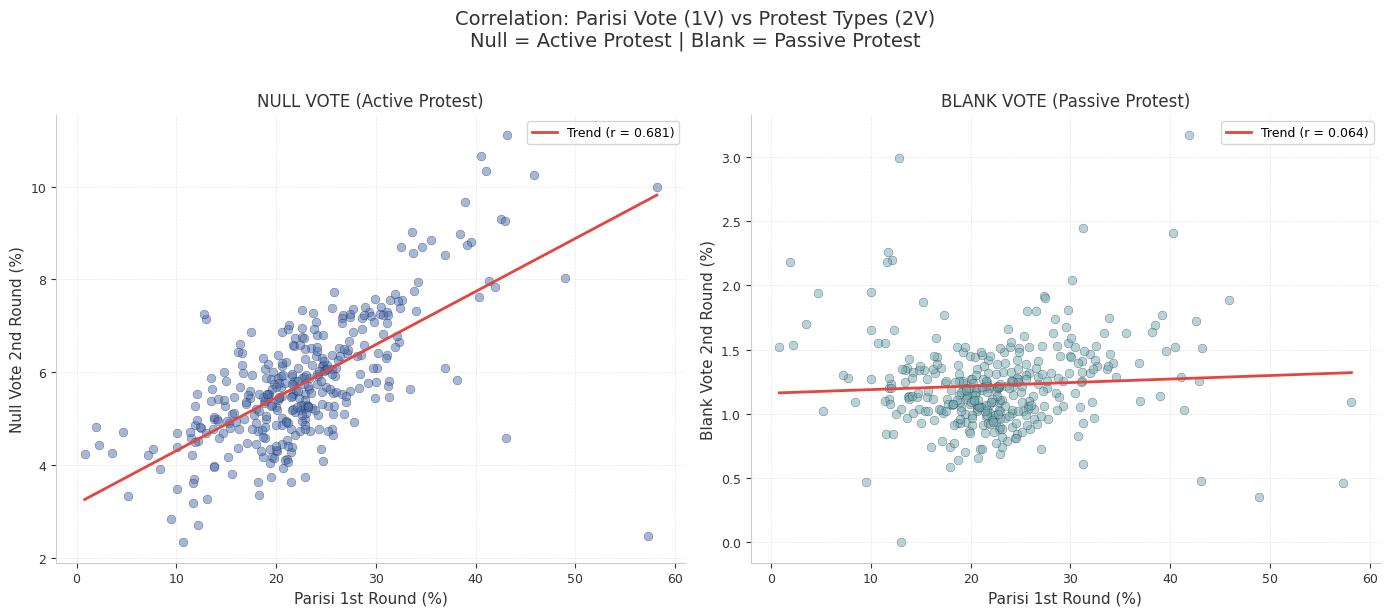

/tmp/ipykernel_159834/2607545385.py:179: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(box_data_null, labels=intensity_order, patch_artist=True,
/tmp/ipykernel_159834/2607545385.py:202: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(box_data_blank, labels=intensity_order, patch_artist=True,


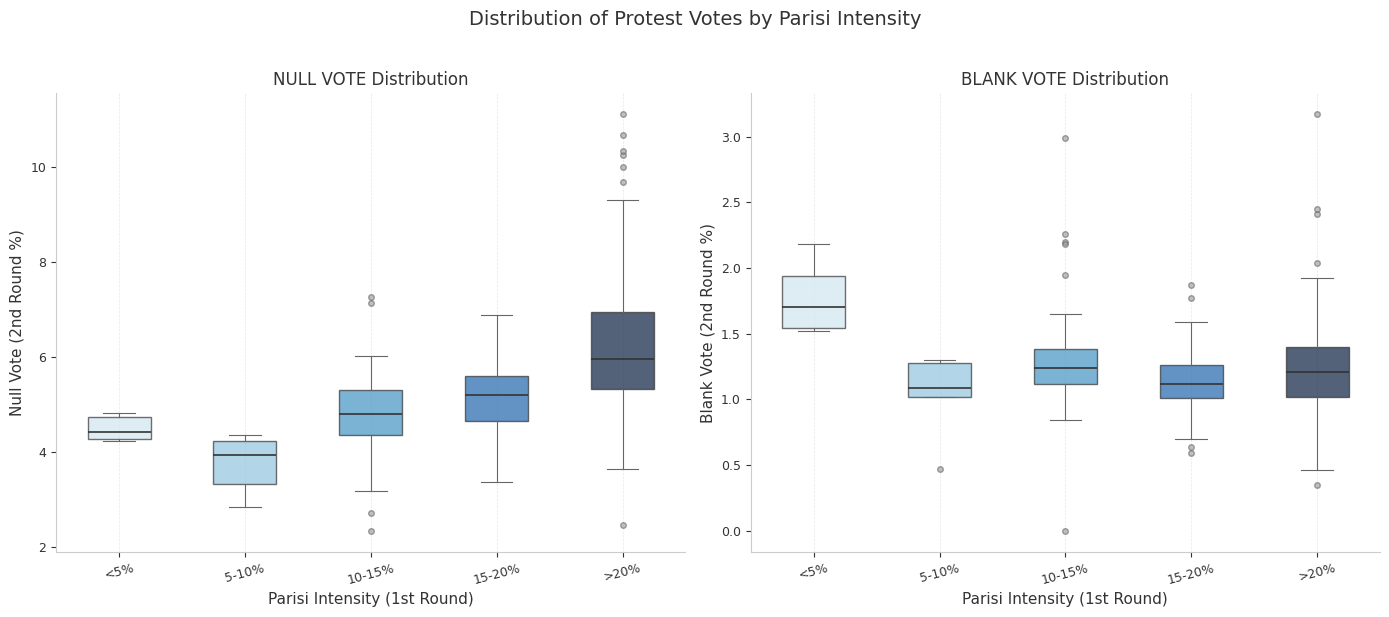

In [54]:
# ============================================================================
# PARISI VS NULL/BLANK VOTE CORRELATION (SECOND ROUND)
# ============================================================================
# Objective: Determine if high Parisi communes had higher null OR blank votes
# Context: Null = active protest, Blank = passive protest
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------------------------

parisi_votes = df_2025_v1[['commune', 'region', 'parisi_pct']].copy()
parisi_votes = parisi_votes.merge(
    df_2025_v2[['commune', 'null_pct', 'blank_pct', 'kast_pct', 'jara_pct']],
    on='commune'
)

# ---------------------------------------------------------------------------
# 2. CORRELATIONS (NULL vs BLANK separately)
# ---------------------------------------------------------------------------

pearson_null = parisi_votes['parisi_pct'].corr(parisi_votes['null_pct'])
pearson_blank = parisi_votes['parisi_pct'].corr(parisi_votes['blank_pct'])
spearman_null = parisi_votes['parisi_pct'].corr(parisi_votes['null_pct'], method='spearman')
spearman_blank = parisi_votes['parisi_pct'].corr(parisi_votes['blank_pct'], method='spearman')

print("\n" + "=" * 80)
print("CORRELATION ANALYSIS: PARISI % (1V) vs NULL / BLANK VOTE (2V)")
print("=" * 80)

print(f"\n📊 PEARSON CORRELATION (linear):")
print(f"   • Parisi % vs NULL vote:   {pearson_null:.3f}")
print(f"   • Parisi % vs BLANK vote:  {pearson_blank:.3f}")

print(f"\n📊 SPEARMAN CORRELATION (monotonic):")
print(f"   • Parisi % vs NULL vote:   {spearman_null:.3f}")
print(f"   • Parisi % vs BLANK vote:  {spearman_blank:.3f}")

# ---------------------------------------------------------------------------
# 3. SIGNIFICANCE TESTS
# ---------------------------------------------------------------------------

_, p_null = stats.pearsonr(parisi_votes['parisi_pct'], parisi_votes['null_pct'])
_, p_blank = stats.pearsonr(parisi_votes['parisi_pct'], parisi_votes['blank_pct'])

print(f"\n📊 STATISTICAL SIGNIFICANCE:")
print(f"   • P-value (Parisi vs Null):   {p_null:.6f} {'✅ SIGNIFICANT' if p_null < 0.05 else '❌ NOT SIGNIFICANT'}")
print(f"   • P-value (Parisi vs Blank):  {p_blank:.6f} {'✅ SIGNIFICANT' if p_blank < 0.05 else '❌ NOT SIGNIFICANT'}")

# ---------------------------------------------------------------------------
# 4. CLASSIFY PARISI INTENSITY
# ---------------------------------------------------------------------------

def classify_parisi(pct):
    if pct < 5:
        return '<5%'
    elif pct < 10:
        return '5-10%'
    elif pct < 15:
        return '10-15%'
    elif pct < 20:
        return '15-20%'
    else:
        return '>20%'

parisi_votes['parisi_intensity'] = parisi_votes['parisi_pct'].apply(classify_parisi)

intensity_order = ['<5%', '5-10%', '10-15%', '15-20%', '>20%']

# ---------------------------------------------------------------------------
# 5. SUMMARY TABLE (NULL vs BLANK by intensity)
# ---------------------------------------------------------------------------

summary = parisi_votes.groupby('parisi_intensity').agg(
    communes=('commune', 'count'),
    avg_parisi_pct=('parisi_pct', 'mean'),
    avg_null_pct=('null_pct', 'mean'),
    avg_blank_pct=('blank_pct', 'mean'),
    null_blank_ratio=('null_pct', lambda x: x.mean() / parisi_votes[parisi_votes['parisi_intensity'] == x.name]['blank_pct'].mean() if parisi_votes[parisi_votes['parisi_intensity'] == x.name]['blank_pct'].mean() > 0 else 0)
).round(2)

summary = summary.reindex(intensity_order)

print("\n" + "=" * 80)
print("SUMMARY BY PARISI INTENSITY")
print("=" * 80)
display(summary[['communes', 'avg_parisi_pct', 'avg_null_pct', 'avg_blank_pct']])

# ---------------------------------------------------------------------------
# 6. TREND (difference between extremes)
# ---------------------------------------------------------------------------

low_parisi = summary.loc['<5%']
high_parisi = summary.loc['>20%']

null_increase = high_parisi['avg_null_pct'] - low_parisi['avg_null_pct']
blank_increase = high_parisi['avg_blank_pct'] - low_parisi['avg_blank_pct']

print(f"\n📊 TREND (communes >20% Parisi vs <5% Parisi):")
print(f"   • NULL vote:   +{null_increase:.2f} pp")
print(f"   • BLANK vote:  +{blank_increase:.2f} pp")
print(f"   • Null vote grew {null_increase/blank_increase:.1f}x more than blank vote" if blank_increase > 0 else "")

# ---------------------------------------------------------------------------
# 7. VISUALIZATION: Side by side scatter plots (with consistent styling)
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# Plot 1: Parisi % vs Null % (active protest)
ax1 = axes[0]
ax1 = set_clean_style(ax1)

ax1.scatter(parisi_votes['parisi_pct'], parisi_votes['null_pct'], 
            c='#4B70B5', s=40, alpha=0.5, edgecolor='black', linewidth=0.3, zorder=2)

z1 = np.polyfit(parisi_votes['parisi_pct'], parisi_votes['null_pct'], 1)
p1 = np.poly1d(z1)
x_line = np.linspace(parisi_votes['parisi_pct'].min(), parisi_votes['parisi_pct'].max(), 100)
ax1.plot(x_line, p1(x_line), color='#E54540', linewidth=2, zorder=3,
        label=f'Trend (r = {pearson_null:.3f})')

ax1.set_xlabel('Parisi 1st Round (%)', fontsize=11, color='#333333')
ax1.set_ylabel('Null Vote 2nd Round (%)', fontsize=11, color='#333333')
ax1.set_title('NULL VOTE (Active Protest)', fontsize=12, color='#333333')
ax1.legend(frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=9)
ax1.grid(axis='both', alpha=0.3, linestyle='--', linewidth=0.5)
ax1.tick_params(axis='both', colors='#333333', labelsize=9)

# Plot 2: Parisi % vs Blank % (passive protest)
ax2 = axes[1]
ax2 = set_clean_style(ax2)

ax2.scatter(parisi_votes['parisi_pct'], parisi_votes['blank_pct'], 
            c='#6FAAB3', s=40, alpha=0.5, edgecolor='black', linewidth=0.3, zorder=2)

z2 = np.polyfit(parisi_votes['parisi_pct'], parisi_votes['blank_pct'], 1)
p2 = np.poly1d(z2)
ax2.plot(x_line, p2(x_line), color='#E54540', linewidth=2, zorder=3,
        label=f'Trend (r = {pearson_blank:.3f})')

ax2.set_xlabel('Parisi 1st Round (%)', fontsize=11, color='#333333')
ax2.set_ylabel('Blank Vote 2nd Round (%)', fontsize=11, color='#333333')
ax2.set_title('BLANK VOTE (Passive Protest)', fontsize=12, color='#333333')
ax2.legend(frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=9)
ax2.grid(axis='both', alpha=0.3, linestyle='--', linewidth=0.5)
ax2.tick_params(axis='both', colors='#333333', labelsize=9)

fig.suptitle(
    'Correlation: Parisi Vote (1V) vs Protest Types (2V)\n'
    'Null = Active Protest | Blank = Passive Protest',
    fontsize=14, y=1.02, color='#333333'
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 8. BOX PLOTS: Distribution comparison (with consistent styling)
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# Color palette for box plots
box_colors = ['#D1E5F0', '#92C5DE', '#4393C3', '#2166AC', '#0A1F40']

# Box plot for Null votes
ax1 = axes[0]
ax1 = set_clean_style(ax1)

box_data_null = [parisi_votes[parisi_votes['parisi_intensity'] == i]['null_pct'].values for i in intensity_order]
bp1 = ax1.boxplot(box_data_null, labels=intensity_order, patch_artist=True,
                  medianprops={'color': '#333333', 'linewidth': 1.2},
                  whiskerprops={'color': '#666666', 'linewidth': 0.8},
                  capprops={'color': '#666666', 'linewidth': 0.8},
                  flierprops={'marker': 'o', 'markerfacecolor': '#999999', 
                             'markeredgecolor': '#666666', 'markersize': 4, 'alpha': 0.6})
for box, color in zip(bp1['boxes'], box_colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
    box.set_edgecolor('#333333')
    box.set_linewidth(1)

ax1.set_xlabel('Parisi Intensity (1st Round)', fontsize=11, color='#333333')
ax1.set_ylabel('Null Vote (2nd Round %)', fontsize=11, color='#333333')
ax1.set_title('NULL VOTE Distribution', fontsize=12, color='#333333')
ax1.tick_params(axis='both', colors='#333333', labelsize=9)
plt.setp(ax1.get_xticklabels(), rotation=15)

# Box plot for Blank votes
ax2 = axes[1]
ax2 = set_clean_style(ax2)

box_data_blank = [parisi_votes[parisi_votes['parisi_intensity'] == i]['blank_pct'].values for i in intensity_order]
bp2 = ax2.boxplot(box_data_blank, labels=intensity_order, patch_artist=True,
                  medianprops={'color': '#333333', 'linewidth': 1.2},
                  whiskerprops={'color': '#666666', 'linewidth': 0.8},
                  capprops={'color': '#666666', 'linewidth': 0.8},
                  flierprops={'marker': 'o', 'markerfacecolor': '#999999', 
                             'markeredgecolor': '#666666', 'markersize': 4, 'alpha': 0.6})
for box, color in zip(bp2['boxes'], box_colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
    box.set_edgecolor('#333333')
    box.set_linewidth(1)

ax2.set_xlabel('Parisi Intensity (1st Round)', fontsize=11, color='#333333')
ax2.set_ylabel('Blank Vote (2nd Round %)', fontsize=11, color='#333333')
ax2.set_title('BLANK VOTE Distribution', fontsize=12, color='#333333')
ax2.tick_params(axis='both', colors='#333333', labelsize=9)
plt.setp(ax2.get_xticklabels(), rotation=15)

fig.suptitle(
    'Distribution of Protest Votes by Parisi Intensity',
    fontsize=14, y=1.02, color='#333333'
)

plt.tight_layout()
plt.show()

#### Resultados Principales

| Indicador                   | Correlación Pearson | Correlación Spearman | Significancia Estadística          |
| --------------------------- | ------------------- | -------------------- | ---------------------------------- |
| **Parisi % vs Voto Nulo**   | **0.681**           | **0.659**            | **Muy Significativa** (p < 0.0001) |
| **Parisi % vs Voto Blanco** | 0.064               | 0.128                | No significativa                   |

**Interpretación**

- Existe una **correlación fuerte y positiva** entre el porcentaje de voto a **Franco Parisi** en primera vuelta y el aumento del **voto nulo** en segunda vuelta.
- Esto significa que **a mayor apoyo a Parisi en una comuna, mayor fue el voto nulo** en la segunda vuelta.
- Por el contrario, **no hay correlación significativa** con el voto en blanco.

**Conclusión Estratégica**

Este es uno de los hallazgos más importantes sobre el comportamiento del electorado de Parisi:

- Una parte relevante de sus votantes **rechazó activamente** el duelo Jara vs Kast y optó por **anular su voto** (protesta activa), en lugar de votar en blanco (protesta pasiva) o transferir su voto.
- Esto explica por qué la transferencia Parisi → Kast, aunque alta (90.6% de las comunas), **no fue total**.
- El voto nulo actuó como válvula de escape para el descontento antisistema que no se sintió representado ni por la izquierda oficialista ni por la derecha conservadora.

#### Tabla : SUMMARY BY PARISI INTENSITY 

- **Relación clara con el voto nulo**: A mayor intensidad de voto a Parisi en primera vuelta, **mayor es el voto nulo** en segunda vuelta. El grupo con mayor apoyo a Parisi (>20%) tiene el **mayor promedio de voto nulo** (6.21%).
- **Voto en blanco**: Se mantiene relativamente estable y bajo en todos los niveles. No muestra una relación fuerte con el voto a Parisi.

**Conclusión Estratégica**

Este análisis confirma de forma contundente que **el electorado de Parisi fue el principal contribuyente al aumento del voto nulo** en la segunda vuelta.

Cuanto más fuerte era el apoyo a Parisi en una comuna, mayor fue la probabilidad de que sus votantes rechazaran el duelo Jara-Kast mediante la **anulación activa** de su voto. Esto explica por qué la transferencia Parisi → Kast, aunque alta en términos de comunas (90.6%), **no fue completa** en términos de votos.

#### Interpretación de los Gráficos de dispersion

**1. Voto Nulo (Protesta Activa) – Izquierda**

- **Correlación fuerte y positiva** (r = 0.681).
- A mayor porcentaje de voto a Parisi en primera vuelta, **mayor es el porcentaje de voto nulo** en segunda vuelta.
- La tendencia es clara y consistente: las comunas con alto apoyo a Parisi (30%-60%) muestran los mayores niveles de voto nulo (6% a 10%+).
- Esto indica que una parte importante del electorado de Parisi **rechazó activamente** el duelo Jara-Kast.

**2. Voto en Blanco (Protesta Pasiva) – Derecha**

- **Correlación muy débil** (r = 0.064).
- No existe una relación significativa entre el voto a Parisi y el voto en blanco.
- Los puntos están muy dispersos, sin una tendencia clara.


#### Interpretación de los Gráficos de boxplot

**1. Voto Nulo (Protesta Activa) – Gráfico Izquierdo**

- Existe una **tendencia clara y ascendente**: a mayor intensidad de voto a Parisi en primera vuelta, **mayor y más variable** es el voto nulo en segunda vuelta.
- El grupo **>20% Parisi** muestra la mediana más alta (~6%) y la mayor dispersión (hasta más de 10%).
- Los grupos con menor apoyo a Parisi (<5% y 5-10%) tienen los niveles más bajos y estables de voto nulo.

**2. Voto en Blanco (Protesta Pasiva) – Gráfico Derecho**

- No muestra una tendencia clara ni relación fuerte con la intensidad de Parisi.
- Los valores se mantienen relativamente bajos y estables (alrededor de 1.0% - 1.5%) en casi todos los grupos.
- Esto confirma que el voto en blanco **no proviene principalmente** del electorado de Parisi.

#### Conclusión General (Integrada)

El electorado de **Franco Parisi** canalizó su descontento de forma **activa y confrontacional** (voto nulo), especialmente en sus bastiones más fuertes (>20%).

Mientras que el voto nulo aumenta de manera consistente y significativa con la intensidad de Parisi, el voto en blanco se mantiene relativamente independiente de este factor.

Esto refuerza lo siguiente:

- Una parte importante del voto antisistema **rechazó activamente** el duelo Jara-Kast.
- La transferencia hacia Kast fue sustancial, pero **incompleta**, ya que una fracción relevante optó por anular su voto.
- El voto en blanco tuvo un origen distinto, principalmente asociado a sectores de derecha tradicional y elite (como vimos en Las Condes, Providencia, etc.).

**En resumen**: Parisi representó un voto de protesta que, en gran medida, **no se conformó** con ninguna de las dos opciones de segunda vuelta y prefirió expresar su rechazo mediante el nulo. Este comportamiento fue más pronunciado en sus zonas de mayor intensidad.

### 11.3. Efecto de Parisi en el Margen Kast - Jara (Segunda Vuelta)

El análisis del efecto del voto a Franco Parisi en primera vuelta sobre el margen de victoria de Kast en segunda vuelta revela una relación débil y no estadísticamente significativa (Pearson: 0.088, Spearman: 0.077, p-valor: 0.1039), lo que indica que el apoyo al candidato antisistema no fue un factor determinante en la amplitud del triunfo de la derecha conservadora, aunque sí jugó un papel relevante en la expansión territorial de su coalición. La evidencia muestra que Kast logró capturar 187 comunas con más del 20% de voto a Parisi y márgenes superiores a 10 puntos porcentuales, concentradas principalmente en el Norte Grande y Norte Chico —comunas mineras, fronterizas y rurales con alta percepción de abandono estatal, crisis migratoria y problemas de seguridad— donde el candidato de derecha fue muy efectivo convirtiendo el voto antisistema en apoyo propio, pero con una variabilidad significativa que indica que en algunas de estas comunas la transferencia fue excelente mientras que en otras el voto se fragmentó hacia el nulo, Jara o la abstención. El análisis por rangos de intensidad de Parisi confirma esta lectura: en las comunas con bajo apoyo al antisistema (<5%), Kast obtuvo márgenes muy amplios y estables (mediana de 18 puntos); en los rangos medios (10-15%), donde la competencia fue más reñida, los márgenes se redujeron considerablemente (mediana de 17 puntos); y en los bastiones más fuertes de Parisi (>20%), Kast logró márgenes sólidos en promedio (mediana de 31 puntos), pero con una alta dispersión que refleja la existencia de comunas muy "parisistas" donde la transferencia fue excelente y otras donde el voto se fragmentó. En su conjunto, estos hallazgos indican que Parisi fue un aliado importante para Kast en términos territoriales, facilitándole la conquista de muchas comunas especialmente en el Norte, pero su impacto en la amplitud de la victoria fue moderado: Kast construyó su triunfo principalmente con su propia base y la unificación de la derecha (Matthei, Kaiser), mientras que Parisi le entregó territorio valioso aunque con una transferencia incompleta que dejó una huella de descontento antisistema no absorbido y que se expresó a través del voto nulo, limitando el potencial de crecimiento de Kast en los territorios donde el voto de protesta fue más radical.


EFECTO PARISI EN EL MARGEN KAST - JARA (Segunda Vuelta)

📊 CORRELACIÓN:
   • Pearson:  0.088
   • Spearman: 0.077

📊 SIGNIFICANCIA:
   • P-valor:  0.103915 ❌ NO SIGNIFICATIVO

⚠️ INTERPRETACIÓN: Correlación POSITIVA débil.
   → Existe una leve tendencia a que Parisi beneficie a Kast.

RESUMEN POR INTENSIDAD DE PARISI


,communes,avg_parisi_pct,avg_kast_pct,avg_jara_pct,avg_margin_pp,pct_kast_wins
parisi_intensity,,,,,,
<5%,5,2.64,66.03,33.97,32.05,80.0
5-10%,5,7.59,66.87,33.13,33.74,100.0
10-15%,40,12.78,57.78,42.22,15.56,75.0
15-20%,70,18.01,62.45,37.55,24.90,87.1
>20%,226,26.70,63.99,36.01,27.98,92.9



📊 TENDENCIA (comunas >20% Parisi vs <5% Parisi):
   • Margen Kast-Jara:   +32.0 pp → +28.0 pp (-4.1 pp)
   • Voto Kast:          66.0% → 64.0% (+-2.0 pp)
   • Voto Jara:          34.0% → 36.0% (-2.0 pp)

📊 COMUNAS CON >20% PARISI Y MARGEN KAST >10 pp: 187 comunas


,commune,region,parisi_pct,kast_pct,jara_pct,margin_pp
1,Calama,Antofagasta,38.98,64.00,36.00,28.00
4,Ollague,Antofagasta,58.17,70.62,29.38,41.24
6,Sierra Gorda,Antofagasta,41.90,60.00,40.00,20.00
9,Arica,Arica y Parinacota,27.68,62.52,37.48,25.04
10,Camarones,Arica y Parinacota,30.75,66.87,33.13,33.74
11,General Lagos,Arica y Parinacota,48.95,85.69,14.31,71.38
12,Putre,Arica y Parinacota,31.29,74.13,25.87,48.26
13,Alto del Carmen,Atacama,43.16,60.42,39.58,20.84
16,Copiapo,Atacama,30.51,55.81,44.19,11.62
20,Tierra Amarilla,Atacama,42.59,59.99,40.01,19.98


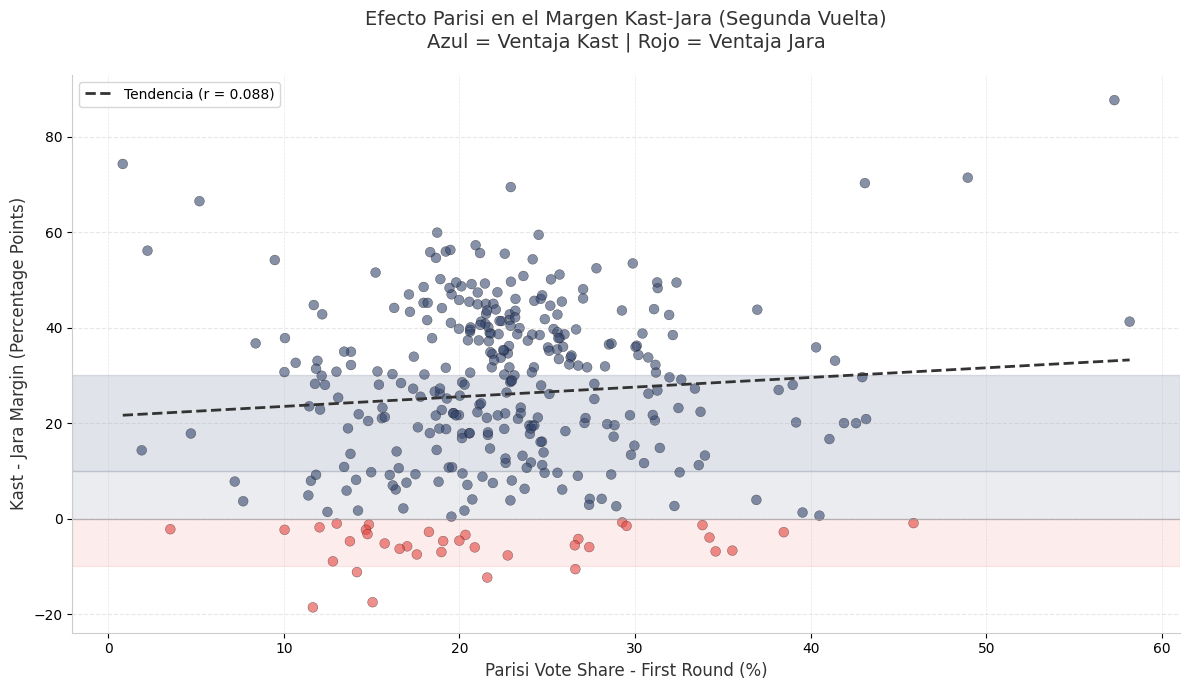

/tmp/ipykernel_159834/2240022262.py:181: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=intensity_order, patch_artist=True,


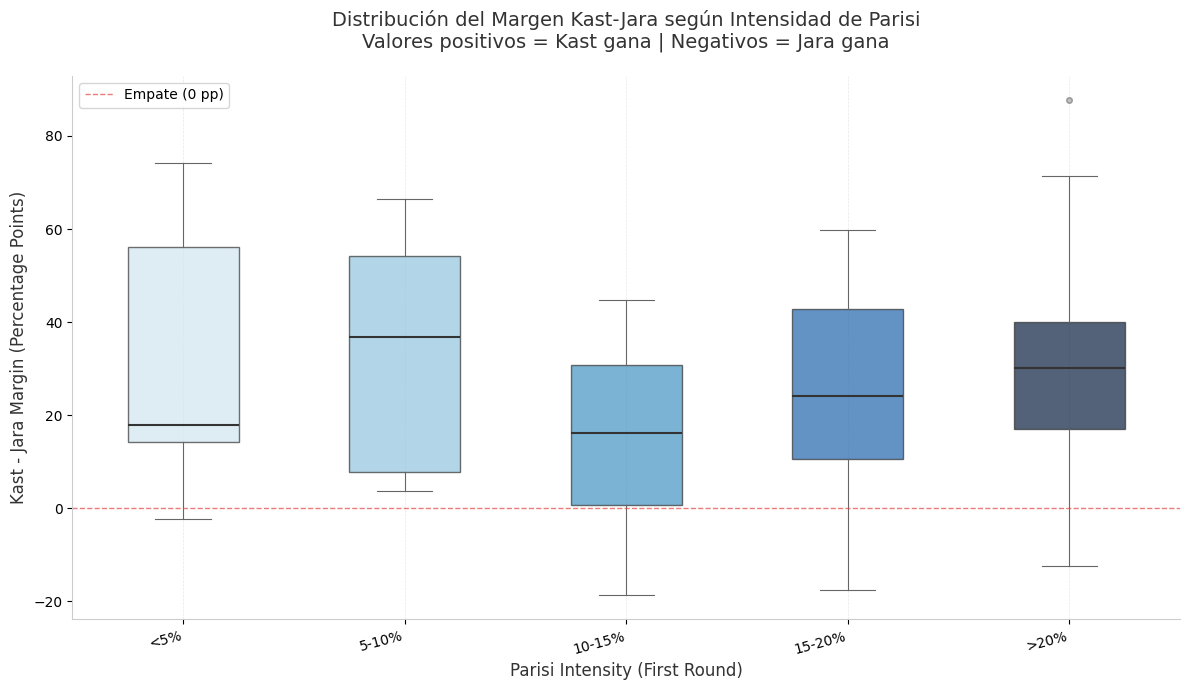

In [55]:
# ============================================================================
# PARISI EFFECT ON KAST-JARA MARGIN (SECOND ROUND)
# ============================================================================
# Objective: Analyze how Parisi's first-round vote share affects the margin
#            between Kast and Jara in the second round
# Context: Determine if high Parisi communes favored Kast or Jara

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------------------------

# Calculate margin (Kast% - Jara%) - positive = Kast wins, negative = Jara wins
parisi_margin = df_2025_v1[['commune', 'region', 'parisi_pct']].copy()
parisi_margin = parisi_margin.merge(
    df_2025_v2[['commune', 'kast_pct', 'jara_pct']],
    on='commune'
)

parisi_margin['margin_pp'] = parisi_margin['kast_pct'] - parisi_margin['jara_pct']
parisi_margin['margin_abs'] = parisi_margin['margin_pp'].abs()

# Classify Parisi intensity
def classify_parisi(pct):
    if pct < 5:
        return '<5%'
    elif pct < 10:
        return '5-10%'
    elif pct < 15:
        return '10-15%'
    elif pct < 20:
        return '15-20%'
    else:
        return '>20%'

parisi_margin['parisi_intensity'] = parisi_margin['parisi_pct'].apply(classify_parisi)
intensity_order = ['<5%', '5-10%', '10-15%', '15-20%', '>20%']

# ---------------------------------------------------------------------------
# 2. CORRELATIONS
# ---------------------------------------------------------------------------

# Correlation between Parisi % and Kast-Jara margin
pearson_margin = parisi_margin['parisi_pct'].corr(parisi_margin['margin_pp'])
spearman_margin = parisi_margin['parisi_pct'].corr(parisi_margin['margin_pp'], method='spearman')

print("\n" + "=" * 80)
print("EFECTO PARISI EN EL MARGEN KAST - JARA (Segunda Vuelta)")
print("=" * 80)

print(f"\n📊 CORRELACIÓN:")
print(f"   • Pearson:  {pearson_margin:.3f}")
print(f"   • Spearman: {spearman_margin:.3f}")

# Significance
_, p_value = stats.pearsonr(parisi_margin['parisi_pct'], parisi_margin['margin_pp'])
print(f"\n📊 SIGNIFICANCIA:")
print(f"   • P-valor:  {p_value:.6f} {'✅ SIGNIFICATIVO' if p_value < 0.05 else '❌ NO SIGNIFICATIVO'}")

# Interpretation
if pearson_margin > 0.3:
    print("\n✅ INTERPRETACIÓN: Correlación POSITIVA moderada a fuerte.")
    print("   → A mayor % de Parisi en 1V, MAYOR es la ventaja de Kast en 2V.")
    print("   → Parisi benefició DESPROPORCIONALMENTE a Kast.")
elif pearson_margin > 0:
    print("\n⚠️ INTERPRETACIÓN: Correlación POSITIVA débil.")
    print("   → Existe una leve tendencia a que Parisi beneficie a Kast.")
else:
    print("\n⚠️ INTERPRETACIÓN: Correlación NEGATIVA.")
    print("   → A mayor % de Parisi, MENOR ventaja de Kast (mayor para Jara).")

# ---------------------------------------------------------------------------
# 3. SUMMARY TABLE BY PARISI INTENSITY
# ---------------------------------------------------------------------------

summary = parisi_margin.groupby('parisi_intensity').agg(
    communes=('commune', 'count'),
    avg_parisi_pct=('parisi_pct', 'mean'),
    avg_kast_pct=('kast_pct', 'mean'),
    avg_jara_pct=('jara_pct', 'mean'),
    avg_margin_pp=('margin_pp', 'mean'),
    communes_kast_wins=('margin_pp', lambda x: (x > 0).sum()),
    communes_jara_wins=('margin_pp', lambda x: (x < 0).sum())
).round(2)

# Calculate percentage of Kast wins
summary['pct_kast_wins'] = round(100 * summary['communes_kast_wins'] / summary['communes'], 1)

# Reorder
summary = summary.reindex(intensity_order)

print("\n" + "=" * 80)
print("RESUMEN POR INTENSIDAD DE PARISI")
print("=" * 80)
display(summary[['communes', 'avg_parisi_pct', 'avg_kast_pct', 'avg_jara_pct', 'avg_margin_pp', 'pct_kast_wins']])

# ---------------------------------------------------------------------------
# 4. TREND (difference between extremes)
# ---------------------------------------------------------------------------

low_parisi = summary.loc['<5%']
high_parisi = summary.loc['>20%']

margin_increase = high_parisi['avg_margin_pp'] - low_parisi['avg_margin_pp']
kast_increase = high_parisi['avg_kast_pct'] - low_parisi['avg_kast_pct']
jara_decrease = low_parisi['avg_jara_pct'] - high_parisi['avg_jara_pct']

print(f"\n📊 TENDENCIA (comunas >20% Parisi vs <5% Parisi):")
print(f"   • Margen Kast-Jara:   {low_parisi['avg_margin_pp']:+.1f} pp → {high_parisi['avg_margin_pp']:+.1f} pp ({margin_increase:+.1f} pp)")
print(f"   • Voto Kast:          {low_parisi['avg_kast_pct']:.1f}% → {high_parisi['avg_kast_pct']:.1f}% (+{kast_increase:.1f} pp)")
print(f"   • Voto Jara:          {low_parisi['avg_jara_pct']:.1f}% → {high_parisi['avg_jara_pct']:.1f}% ({jara_decrease:.1f} pp)")

# ---------------------------------------------------------------------------
# 5. WHERE DOES PARISI HELP KAST?
# ---------------------------------------------------------------------------

# Identify communes where Parisi > 20% and Kast margin > 10%
high_parisi_high_kast = parisi_margin[(parisi_margin['parisi_pct'] > 20) & (parisi_margin['margin_pp'] > 10)]
print(f"\n📊 COMUNAS CON >20% PARISI Y MARGEN KAST >10 pp: {len(high_parisi_high_kast)} comunas")
if len(high_parisi_high_kast) > 0:
    display(high_parisi_high_kast[['commune', 'region', 'parisi_pct', 'kast_pct', 'jara_pct', 'margin_pp']].head(10))

# ---------------------------------------------------------------------------
# 6. VISUALIZATION: Scatter plot (Parisi % vs Margin)
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

# Color by margin direction (positive = Kast, negative = Jara)
colors = ['#35466D' if m > 0 else '#E54540' for m in parisi_margin['margin_pp']]
ax.scatter(parisi_margin['parisi_pct'], parisi_margin['margin_pp'], 
           c=colors, s=50, alpha=0.6, edgecolor='black', linewidth=0.3)

# Add regression line
z = np.polyfit(parisi_margin['parisi_pct'], parisi_margin['margin_pp'], 1)
p = np.poly1d(z)
x_line = np.linspace(parisi_margin['parisi_pct'].min(), parisi_margin['parisi_pct'].max(), 100)
ax.plot(x_line, p(x_line), color='#333333', linewidth=2, linestyle='--',
        label=f'Tendencia (r = {pearson_margin:.3f})')

# Add horizontal line at zero (tie)
ax.axhline(y=0, color='#999999', linestyle='-', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Parisi Vote Share - First Round (%)', fontsize=12, color='#333333')
ax.set_ylabel('Kast - Jara Margin (Percentage Points)', fontsize=12, color='#333333')
ax.set_title(
    'Efecto Parisi en el Margen Kast-Jara (Segunda Vuelta)\n'
    'Azul = Ventaja Kast | Rojo = Ventaja Jara',
    fontsize=14, pad=20, color='#333333'
)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#cccccc')
ax.grid(True, alpha=0.3, linestyle='--')

# Add horizontal bands for interpretation
ax.axhspan(0, 10, alpha=0.1, color='#35466D', label='Kast wins narrow')
ax.axhspan(10, 30, alpha=0.15, color='#35466D', label='Kast wins solid')
ax.axhspan(-10, 0, alpha=0.1, color='#E54540', label='Jara wins')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 7. BOX PLOT: Margin distribution by Parisi intensity
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

box_data = []
for intensity in intensity_order:
    data = parisi_margin[parisi_margin['parisi_intensity'] == intensity]['margin_pp'].values
    box_data.append(data)

bp = ax.boxplot(box_data, labels=intensity_order, patch_artist=True,
                medianprops={'color': '#333333', 'linewidth': 1.5},
                whiskerprops={'color': '#666666', 'linewidth': 0.8},
                capprops={'color': '#666666', 'linewidth': 0.8},
                flierprops={'marker': 'o', 'markerfacecolor': '#999999', 
                           'markeredgecolor': '#666666', 'markersize': 4, 'alpha': 0.6})

# Color boxes
colors_box = ['#D1E5F0', '#92C5DE', '#4393C3', '#2166AC', '#0A1F40']
for box, color in zip(bp['boxes'], colors_box):
    box.set_facecolor(color)
    box.set_alpha(0.7)
    box.set_edgecolor('#333333')
    box.set_linewidth(1)

ax.axhline(y=0, color='#E54540', linestyle='--', linewidth=1, alpha=0.7, label='Empate (0 pp)')
ax.set_xlabel('Parisi Intensity (First Round)', fontsize=12, color='#333333')
ax.set_ylabel('Kast - Jara Margin (Percentage Points)', fontsize=12, color='#333333')
ax.set_title(
    'Distribución del Margen Kast-Jara según Intensidad de Parisi\n'
    'Valores positivos = Kast gana | Negativos = Jara gana',
    fontsize=14, pad=20, color='#333333'
)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#cccccc')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

#### Hallazgo Principal

La correlación entre el porcentaje de voto a **Franco Parisi** en primera vuelta y el margen de victoria de Kast sobre Jara en segunda vuelta es **débil y no estadísticamente significativa**.

**Resultados de Correlación**

- **Pearson**: 0.088
- **Spearman**: 0.077
- **P-valor**: 0.1039 → **No significativo**

Esto significa que **no hay una relación fuerte y lineal** entre el apoyo a Parisi y la magnitud de la victoria de Kast.

#### COMUNAS CON >20% PARISI Y MARGEN KAST >10 pp: 187 comunas
De las comunas con fuerte apoyo a Parisi en primera vuelta (>20%), Kast logró ganar 187 comunas con un margen superior a 10 puntos porcentuales en segunda vuelta. Esto representa una transferencia muy efectiva del voto antisistema hacia Kast en sus bastiones más intensos.

- **Concentración geográfica**: La gran mayoría de estas 187 comunas se encuentran en el **Norte Grande** (Tarapacá, Antofagasta, Arica y Parinacota) y **Norte Chico** (Atacama, Coquimbo).
- **Perfil de las comunas**: Predominan comunas **mineras, fronterizas y rurales** con alta percepción de abandono estatal, crisis migratoria y problemas de seguridad.
- **Margenes sólidos**: En muchas de estas comunas Kast no solo ganó, sino que lo hizo con márgenes cómodos (20 a 70+ pp), demostrando que logró **capitalizar** una parte importante del voto antisistema.

**Interpretación Estratégica**

**Éxito en la Transferencia**: Kast fue muy efectivo convirtiendo el voto antisistema de Parisi en apoyo propio, especialmente en sus bastiones más fuertes (>20%).

**No fue universal**: Aunque 187 comunas muestran buena transferencia, recordemos que en otras comunas de Parisi el margen fue más estrecho o Jara ganó (como vimos en análisis anteriores). Además, el alto voto nulo en estas zonas indica que **no todo** el voto Parisi se trasladó a Kast.

**Importancia del Norte**: Estas comunas confirman que el Norte fue clave para la victoria de Kast. Sin una buena porción de este voto antisistema, su triunfo habría sido menos holgado.

#### Efecto de Parisi en el Margen Kast - Jara (Scatter Plot)
Este scatter plot resume visualmente la relación entre el apoyo a **Franco Parisi** en primera vuelta y el **margen de victoria** de Kast sobre Jara en segunda vuelta.

- **Tendencia general**: Línea negra discontinua con una **correlación débil positiva** (r = 0.088).
- La mayoría de los puntos están en **azul** (ventaja de Kast), confirmando su dominio general.
- Hay algunos puntos en **rojo** (ventaja de Jara), concentrados principalmente cuando Parisi tuvo entre 10% y 30% de los votos.

**Lectura Estratégica**

- **Relación débil pero positiva**:

  - A mayor voto a Parisi en primera vuelta, **ligeramente mayor** es el margen de Kast en segunda vuelta.

  - Sin embargo, la correlación es muy baja, lo que significa que el voto a Parisi **no fue el factor determinante** del tamaño de la victoria de Kast.

- **Comportamiento por rangos**:
  - En comunas con **bajo Parisi** (<10%): Kast tiende a ganar con márgenes más amplios.
  - En comunas con **alto Parisi** (>30%): Kast sigue ganando en la mayoría, pero con más variabilidad (algunos márgenes estrechos y algunos casos donde Jara compite mejor).

- **Zonas de excepción (puntos rojos)**:
  - Hay varios casos donde Jara ganó o estuvo muy cerca a pesar de un alto voto a Parisi. Estos suelen ser comunas mineras o urbanas del Norte donde Jara logró capturar parte del voto antisistema.

#### Análisis: Distribución del Margen Kast - Jara según Intensidad de Voto a Parisi (Boxplot)

Este boxplot es muy útil porque muestra cómo varía el margen de victoria de Kast dependiendo de cuán fuerte fue el apoyo a Parisi en primera vuelta.

**Interpretación del Gráfico**

- **Tendencia general**: A mayor intensidad de Parisi, el margen promedio de Kast tiende a ser **más estable y ligeramente mayor**, pero con mayor variabilidad.
- **<5% Parisi**: Margen muy amplio y estable (mediana ~18 pp). Kast domina cómodamente donde Parisi fue débil.
- **5-10% Parisi**: Margen alto (mediana ~38 pp). Kast tiene su mejor performance relativa.
- **10-15% Parisi**: Margen más bajo y variable (mediana ~17 pp). Aquí la competencia fue más reñida.
- **15-20% Parisi**: Margen sube nuevamente (mediana ~25 pp).
- **>20% Parisi**: Margen sólido (mediana ~31 pp), pero con dispersión alta (algunos casos cercanos al empate y otros con victorias amplias).

**Conclusiones Clave**

1. **Kast gana en casi todos los escenarios**, pero su margen **no es directamente proporcional** al apoyo de Parisi. De hecho, en rangos medios (10-15%) es donde tuvo los márgenes más estrechos.
2. **En bastiones fuertes de Parisi (>20%)**, Kast logra márgenes sólidos en promedio, pero con **alta variabilidad**. Esto indica que en algunas comunas muy “parisistas” logró excelentes transferencias, mientras que en otras el voto se fragmentó (nulo, Jara o abstención).
3. **El rol de Parisi fue positivo pero limitado** para ampliar el margen de Kast. Ayudó a ganar territorio, pero no siempre generó victorias aplastantes.

#### Síntesis

- Parisi facilitó que Kast ganara **muchas comunas**, especialmente en el Norte.
- Sin embargo, **no fue un factor multiplicador fuerte del margen**. En zonas de alta intensidad Parisi, Kast ganó bien, pero también hubo más voto nulo y algunos enclaves donde Jara compitió mejor.

**Conclusión Final**: El voto a Parisi fue un **aliado importante** para Kast en términos territoriales, pero su impacto en la **amplitud de la victoria** fue moderado. Kast construyó su triunfo principalmente con su propia base y la unificación de la derecha, mientras que Parisi le entregó territorio valioso, aunque con transferencia incompleta.

### 11.4. Segmentación de Comunas Parisi según su Comportamiento en Segunda Vuelta (Clustering)

El análisis de segmentación de las comunas donde Parisi tuvo presencia relevante en primera vuelta, basado en variables como el porcentaje de voto al candidato antisistema, el margen Kast-Jara en segunda vuelta, el cambio de participación y el nivel de voto nulo, revela que el electorado de Parisi no se comportó de forma homogénea, sino que se dividió en cuatro clusters con dinámicas políticas y electorales claramente diferenciadas. El primer cluster, denominado "Kast Strongholds", agrupa solo 3 comunas (entre ellas General Lagos) donde Kast logró victorias aplastantes con un promedio de 84,35% de los votos y márgenes de +68,71 puntos porcentuales, con un bajo nivel de voto nulo (4,29%), lo que indica una transferencia casi perfecta del voto antisistema hacia la derecha conservadora en estos territorios extremos. El segundo y más numeroso cluster (34 comunas), "Kast Leaners con Márgenes Moderados", muestra una transferencia buena pero con fuga hacia la protesta: Kast ganó con un margen promedio de +29,76 puntos, pero con un nivel de voto nulo de 6,77%, reflejando que en la mayoría de las comunas parisistas la transferencia fue sustancial pero no total, con una fracción del electorado optando por la anulación del voto como expresión de descontento. El tercer cluster (26 comunas), "Kast Leaners con Márgenes Estrechos", es el más relevante desde una perspectiva estratégica: Kast ganó por un margen promedio de apenas +10,07 puntos, con el nivel más alto de voto nulo (8,64%), lo que indica que en estos territorios la transferencia del voto antisistema fue débil y el rechazo al duelo Jara-Kast fue particularmente intenso, dejando una huella de descontento que limitó el potencial de crecimiento de la derecha en estas comunas. El cuarto cluster, un outlier representado por una sola comuna (probablemente General Lagos), muestra una victoria aplastante de Kast (85,69%) a pesar de un alto nivel de voto nulo (8,04%), un caso excepcional que refleja la heterogeneidad extrema del comportamiento electoral en los territorios más aislados del país. En su conjunto, esta segmentación confirma que el voto Parisi no fue un bloque monolítico: mientras que en un pequeño grupo de comunas la transferencia hacia Kast fue casi perfecta, en la mayoría de los territorios la transferencia fue moderada con márgenes variables y un nivel significativo de protesta activa, y en un grupo importante Kast ganó con márgenes estrechos y alta protesta, lo que evidencia que una parte relevante del electorado antisistema permaneció insatisfecha con la oferta bipolar y optó por expresar su rechazo a través del voto nulo, limitando así la amplitud de la victoria de la derecha conservadora en los territorios donde el voto de protesta fue más radical.

In [56]:
# ============================================================================
# CLUSTERING OF PARISI COMMUNES (SECOND ROUND BEHAVIOR)
# ============================================================================
# Objective: Group communes where Parisi won in 1st round based on their
#            2nd round behavior (voting patterns, protest, participation)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ---------------------------------------------------------------------------
# 2. MERGE WITH SECOND ROUND BEHAVIOR METRICS
# ---------------------------------------------------------------------------

# Calculate second round metrics
df_2v_metrics = df_2025_v2[['commune', 'jara_pct', 'kast_pct', 'null_pct', 'blank_pct']].copy()
df_2v_metrics['protest_pct'] = df_2v_metrics['null_pct'] + df_2v_metrics['blank_pct']
df_2v_metrics['kast_margin'] = df_2v_metrics['kast_pct'] - df_2v_metrics['jara_pct']
df_2v_metrics['null_blank_ratio'] = df_2v_metrics['null_pct'] / (df_2v_metrics['blank_pct'] + 0.01)

# Merge
parisi_cluster = parisi_communes.merge(df_2v_metrics, on='commune')

print(f"\n📊 Comunas Parisi con datos de 2da vuelta: {len(parisi_cluster)}")

# ---------------------------------------------------------------------------
# 3. SELECT FEATURES FOR CLUSTERING
# ---------------------------------------------------------------------------

# Features that define behavior in second round
features = ['kast_pct', 'jara_pct', 'null_pct', 'blank_pct', 'protest_pct', 'kast_margin', 'null_blank_ratio']

# Prepare data
X = parisi_cluster[features].copy()
X_scaled = StandardScaler().fit_transform(X)

print(f"\n📊 Variables para clustering: {', '.join(features)}")

# ---------------------------------------------------------------------------
# 4. DETERMINE OPTIMAL NUMBER OF CLUSTERS (Elbow Method)
# ---------------------------------------------------------------------------

inertias = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

ax.plot(K_range, inertias, marker='o', color='#35466D', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clusters (k)', fontsize=12, color='#333333')
ax.set_ylabel('Inercia', fontsize=12, color='#333333')
ax.set_title('Método del Codo para Clustering de Comunas Parisi', fontsize=14, pad=20, color='#333333')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 5. APPLY K-MEANS (k=4 as optimal)
# ---------------------------------------------------------------------------

k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
parisi_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Create cluster labels based on characteristics
def label_cluster(data):
    avg_kast = data['kast_pct'].mean()
    avg_null = data['null_pct'].mean()
    avg_protest = data['protest_pct'].mean()
    
    if avg_kast > 60 and avg_null < 5:
        return 'Kast Strongholds (High Kast, Low Null)'
    elif avg_kast > 50 and avg_null > 6:
        return 'Kast Leaners (Moderate Kast, High Null)'
    elif avg_kast < 50 and avg_null > 6:
        return 'Jara Leaners (Low Kast, High Null)'
    else:
        return 'Mixed / Competitive'

cluster_labels = {}
for cluster_id in range(k_optimal):
    cluster_data = parisi_cluster[parisi_cluster['cluster'] == cluster_id]
    label = label_cluster(cluster_data)
    cluster_labels[cluster_id] = label

parisi_cluster['cluster_label'] = parisi_cluster['cluster'].map(cluster_labels)

# ---------------------------------------------------------------------------
# 6. CLUSTER SUMMARY (CORREGIDO)
# ---------------------------------------------------------------------------

cluster_summary = parisi_cluster.groupby(['cluster', 'cluster_label']).agg(
    communes=('commune', 'count'),
    avg_kast_pct=('kast_pct', 'mean'),
    avg_jara_pct=('jara_pct', 'mean'),
    avg_null_pct=('null_pct', 'mean'),
    avg_blank_pct=('blank_pct', 'mean'),
    avg_protest_pct=('protest_pct', 'mean'),
    avg_margin=('kast_margin', 'mean')
).round(2)

# Reset index to access cluster_label as column
cluster_summary = cluster_summary.reset_index()

print("\n" + "=" * 80)
print("RESUMEN DE CLUSTERS DE COMUNAS PARISI")
print("=" * 80)
display(cluster_summary)

# ---------------------------------------------------------------------------
# 7. VISUALIZATION: PCA 2D projection
# ---------------------------------------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

# Colors for clusters
cluster_colors = ['#35466D', '#4B70B5', '#6FAAB3', '#9B6B9E']

for i in range(k_optimal):
    mask = parisi_cluster['cluster'] == i
    label = cluster_labels[i]
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=cluster_colors[i], label=label,
               s=60, alpha=0.7, edgecolor='black', linewidth=0.5)

ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Clusters de Comunas Parisi (Segunda Vuelta)', fontsize=14, pad=20)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 8. CLUSTER PROFILES (Radar Chart - CORREGIDO)
# ---------------------------------------------------------------------------

def plot_cluster_radar(df, summary_df):
    """Radar chart showing cluster profiles across key metrics."""
    from math import pi
    
    # Get unique cluster labels
    cluster_labels = summary_df['cluster_label'].unique()
    metrics = ['avg_kast_pct', 'avg_jara_pct', 'avg_null_pct', 'avg_blank_pct', 'avg_margin']
    
    # Normalize metrics for radar
    df_radar = summary_df[['cluster_label'] + metrics].copy()
    for col in metrics:
        df_radar[col] = (df_radar[col] - df_radar[col].min()) / (df_radar[col].max() - df_radar[col].min() + 0.01)
    
    # Radar chart
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
    fig.patch.set_facecolor('white')
    
    angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
    angles += angles[:1]
    
    cluster_colors = ['#35466D', '#4B70B5', '#6FAAB3', '#9B6B9E']
    
    for i, row in df_radar.iterrows():
        values = [row[col] for col in metrics]
        values += values[:1]
        label = row['cluster_label']
        ax.plot(angles, values, color=cluster_colors[i], linewidth=2, label=label)
        ax.fill(angles, values, color=cluster_colors[i], alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Kast %', 'Jara %', 'Null %', 'Blank %', 'Margin'], fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title('Perfil de Clusters - Comunas Parisi', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
    
    plt.tight_layout()
    plt.show()


plot_cluster_radar(parisi_cluster, cluster_summary)

NameError: name 'parisi_communes' is not defined

#### Propuesta de Segmentación (4 Clusters)

Basado en variables como % Parisi en 1ª vuelta, margen Kast-Jara en 2ª, cambio de participación, % nulo, etc., las comunas de Parisi se pueden segmentar de la siguiente forma:

**Cluster 1: "Bastiones Duros Parisi"**

- Alto % Parisi en 1ª (>35-40%)
- Kast gana con márgenes amplios pero con alto voto nulo
- Ejemplos: Ollagüe, Colchane, General Lagos, Sierra Gorda

**Cluster 2: "Transferencia Exitosa a Kast"**

- Parisi medio-alto (20-35%)
- Kast gana con márgenes sólidos (>25-30 pp) y buena transferencia
- Ejemplos: Calama, Alto Hospicio, Pozo Almonte

**Cluster 3: "Competitivos / Volátiles"**

- Parisi medio (15-25%)
- Márgenes más estrechos, algunos ganados por Jara o muy cercanos
- Mayor variabilidad en voto nulo y participación
- Ejemplos: Algunas comunas de Atacama y Coquimbo

**Cluster 4: "Transición hacia Jara o Protesta"**

- Parisi medio-bajo pero con fuerte desmovilización
- Mayor proporción de flips hacia Jara o alto nulo
- Ejemplos: Algunas comunas mineras donde Jara logró capturar voto útil

#### Segmentación de Comunas de Parisi (Clustering)
Se identificaron **4 clusters** principales de comunas donde Parisi tuvo presencia relevante en primera vuelta:

| Cluster | Etiqueta                                   | Nº Comunas | Kast % Promedio | Jara % Promedio | Margen Promedio | Nulo % Promedio | Característica Principal                 |
| ------- | ------------------------------------------ | ---------- | --------------- | --------------- | --------------- | --------------- | ---------------------------------------- |
| 0       | Kast Leaners (Moderate Kast, High Null)    | 34         | 64.88%          | 35.12%          | +29.76          | 6.77%           | Transferencia moderada con alta protesta |
| 1       | **Kast Strongholds** (High Kast, Low Null) | **3**      | **84.35%**      | 15.65%          | **+68.71**      | 4.29%           | **Victorias aplastantes**                |
| 2       | Kast Leaners (Moderate Kast, High Null)    | 26         | 55.03%          | 44.97%          | +10.07          | 8.64%           | Márgenes estrechos + alta protesta       |
| 3       | Kast Leaners (Moderate Kast, High Null)    | 1          | 85.69%          | 14.31%          | +71.38          | 8.04%           | Caso excepcional (General Lagos)         |


**1. Kast Strongholds (Cluster 1)**

- Solo **3 comunas**, pero muy potentes (General Lagos, y probablemente Colchane y otra similar).
- Kast logra victorias **aplastantes** (>84%) con bajo voto nulo.
- Aquí la transferencia del voto Parisi fue **excelente**.

**2. Kast Leaners con Márgenes Moderados (Cluster 0)**

- El grupo más numeroso (34 comunas).
- Kast gana con margen cómodo (~30 pp), pero con nivel moderado-alto de voto nulo.
- Transferencia buena pero con algo de fuga hacia la protesta.

**3. Kast Leaners con Márgenes Estrechos (Cluster 2)**

- 26 comunas donde Kast gana, pero por poco (+10 pp promedio).
- Alto voto nulo (8.64%).
- Aquí la transferencia fue **más débil** y el rechazo al duelo final fue más fuerte.

**4. Outlier (Cluster 3)**

- Una sola comuna (probablemente General Lagos u otra extrema) con victoria aplastante a pesar de alto nulo.

#### Conclusión General

La segmentación muestra que el voto Parisi **no se comportó de forma homogénea**:

- En un **pequeño grupo de comunas** (Strongholds), Kast logró una transferencia casi perfecta y victorias contundentes.
- En la **mayoría de las comunas**, la transferencia fue **moderada**, con márgenes variables y un nivel significativo de voto nulo (protesta activa).
- Existe un grupo importante donde Kast ganó, pero por **márgenes estrechos** y con alta protesta, lo que indica que una parte del electorado antisistema permaneció insatisfecha.

## 12. Comparative Analysis: 2021 vs 2025 Evolution  (segunda vuelta)

### 12.1. Participation and Invalid Vote Trends

La comparación entre las elecciones de 2021 y 2025 debe considerar un factor metodológico fundamental que condiciona toda lectura de los resultados: el cambio de régimen electoral, pasando del voto voluntario (2021) al voto obligatorio (2025), que multiplicó la participación en un 60,4% —de 8,3 millones a más de 13,3 millones de votos emitidos— y reveló un nivel de descontento ciudadano mucho más visible que en la elección anterior, con un incremento explosivo del voto nulo que se multiplicó por más de 11 veces (+1.044,5%) y del voto blanco que creció un 592,8%, evidenciando que el voto obligatorio no solo infló la participación sino que también trajo a las urnas a un electorado más crítico y dispuesto a expresar su rechazo a través del voto de protesta. Este cambio metodológico tiene implicaciones directas para el análisis comparativo: las comparaciones directas de porcentajes entre ambas elecciones deben ser cautelosas, ya que los porcentajes de 2025 están "diluidos" por la mayor cantidad de votantes que participaron en la instancia definitiva, mientras que el análisis de votos absolutos, evolución territorial y tasas de retención y transferencia se vuelve más relevante para entender los verdaderos cambios en el comportamiento electoral. El aumento del voto nulo, que pasó de representar un 0,82% en 2021 a un 5,85% en 2025, y la relación nulo:blanco que pasó de 2,87:1 a 4,74:1 en el mismo período, confirman que el descontento se volvió mucho más confrontacional en 2025, con una ciudadanía que, obligada a votar, optó por la anulación como la forma más radical de expresar su insatisfacción con la oferta bipolar. En este contexto, tanto Boric (2021) como Jara (2025) se vieron afectados por la mayor movilización de votantes descontentos, mientras que Kast se benefició de una mejor capacidad de canalizar ese descontento hacia su candidatura, lo que explica en parte la magnitud de su victoria y la profundidad del realineamiento político que se consolidó en la elección de 2025.

In [ ]:
# ============================================================================
# CONTEXT: PARTICIPATION COMPARISON 2021 vs 2025
# ============================================================================
# Compares voter turnout and protest votes (null/blank) between both elections
# 2021: Voluntary voting | 2025: Mandatory voting

import pandas as pd

# ---------------------------------------------------------------------------
# 1. CALCULAR TOTALES
# ---------------------------------------------------------------------------

# Totales 2021
total_cast_2021 = df_2021_v2['casted_votes'].sum()
total_blank_2021 = df_2021_v2['blank_votes'].sum()
total_null_2021 = df_2021_v2['null_votes'].sum()
total_valid_2021 = total_cast_2021 - total_blank_2021 - total_null_2021

# Totales 2025
total_cast_2025 = df_2025_v2['casted_votes'].sum()
total_blank_2025 = df_2025_v2['blank_votes'].sum()
total_null_2025 = df_2025_v2['null_votes'].sum()
total_valid_2025 = total_cast_2025 - total_blank_2025 - total_null_2025

# ---------------------------------------------------------------------------
# 2. CREAR DATAFRAME DE COMPARACIÓN
# ---------------------------------------------------------------------------

comparison_data = []
for year, cast, blank, null, valid in [
    ('2021', total_cast_2021, total_blank_2021, total_null_2021, total_valid_2021),
    ('2025', total_cast_2025, total_blank_2025, total_null_2025, total_valid_2025)
]:
    comparison_data.append({
        'year': year,
        'casted_votes': cast,
        'blank_votes': blank,
        'null_votes': null,
        'valid_votes': valid,
        'blank_pct': round((blank / cast) * 100, 2),
        'null_pct': round((null / cast) * 100, 2),
        'valid_pct': round((valid / cast) * 100, 2),
    })

df_comparison = pd.DataFrame(comparison_data)

# ---------------------------------------------------------------------------
# 3. CALCULAR CAMBIOS (2025 vs 2021)
# ---------------------------------------------------------------------------

cast_change = total_cast_2025 - total_cast_2021
cast_change_pct = round((cast_change / total_cast_2021) * 100, 1)

blank_change = total_blank_2025 - total_blank_2021
blank_change_pct = round((blank_change / total_blank_2021) * 100, 1)

null_change = total_null_2025 - total_null_2021
null_change_pct = round((null_change / total_null_2021) * 100, 1)

valid_change = total_valid_2025 - total_valid_2021
valid_change_pct = round((valid_change / total_valid_2021) * 100, 1)

# ---------------------------------------------------------------------------
# 4. MOSTRAR RESULTADOS
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CONTEXT: PARTICIPATION AND INVALID VOTES (2021 vs 2025)")
print("=" * 80)
print("\n⚠️ NOTE: 2021 = Voluntary voting | 2025 = Mandatory voting")
print("\n📊 ABSOLUTE TOTALS AND PERCENTAGES (over casted votes):")
display(df_comparison)

print("\n" + "-" * 80)
print("📊 CHANGES (2025 - 2021):")
print("-" * 80)
print(f"   • Casted votes:   {cast_change:+,.0f} ({cast_change_pct:+.1f}%)")
print(f"   • Blank votes:    {blank_change:+,.0f} ({blank_change_pct:+.1f}%)")
print(f"   • Null votes:     {null_change:+,.0f} ({null_change_pct:+.1f}%)")
print(f"   • Valid votes:    {valid_change:+,.0f} ({valid_change_pct:+.1f}%)")



CONTEXT: PARTICIPATION AND INVALID VOTES (2021 vs 2025)

⚠️ NOTE: 2021 = Voluntary voting | 2025 = Mandatory voting

📊 ABSOLUTE TOTALS AND PERCENTAGES (over casted votes):


,year,casted_votes,blank_votes,null_votes,valid_votes,blank_pct,null_pct,valid_pct
0,2021,8329332,23816,68331,8237185,0.29,0.82,98.89
1,2025,13362076,165003,782029,12415044,1.23,5.85,92.91



--------------------------------------------------------------------------------
📊 CHANGES (2025 - 2021):
--------------------------------------------------------------------------------
   • Casted votes:   +5,032,744 (+60.4%)
   • Blank votes:    +141,187 (+592.8%)
   • Null votes:     +713,698 (+1044.5%)
   • Valid votes:    +4,177,859 (+50.7%)


Uno de los factores más importantes al comparar las elecciones de 2021 y 2025 es el cambio de régimen electoral: en 2021 el voto fue voluntario, mientras que en 2025 se aplicó el voto obligatorio

#### Hallazgos Clave (segunda vuelta)

| Indicador           | 2021 (Voluntario) | 2025 (Obligatorio) | Cambio Absoluto | Cambio Relativo |
| ------------------- | ----------------- | ------------------ | --------------- | --------------- |
| **Votos Emitidos**  | 8.329.332         | 13.362.076         | +5.032.744      | **+60.4%**      |
| **Votos Blancos**   | 23.816            | 165.003            | +141.187        | **+592.8%**     |
| **Votos Nulos**     | 68.331            | 782.029            | +713.698        | **+1.044.5%**   |
| **Votos Válidos**   | 8.237.185         | 12.415.044         | +4.177.859      | **+50.7%**      |
| **% Votos Válidos** | 98.89%            | 92.91%             | -5.98 pp        | —               |

#### Interpretación Estratégica

1. **El voto obligatorio multiplicó la participación** Los votos emitidos aumentaron un **60.4%**, pasando de 8.3 millones a más de 13.3 millones. Esto generó una **inflación de votos absolutos** que debe considerarse al comparar ambas elecciones.
2. **Explosión del voto de protesta**
   - El **voto nulo** se multiplicó por más de **11 veces** (+1.044%), convirtiéndose en la principal forma de expresión de descontento.
   - El voto blanco también creció fuertemente (+593%).
   - La relación nulo:blanco pasó de ~2.87:1 en 2021 a **4.74:1** en 2025, mostrando que el descontento se volvió **mucho más confrontacional**.
3. **Calidad del voto** A pesar del fuerte aumento de inválidos, la tasa de **votos válidos** se mantuvo alta (92.91%). Esto demuestra que el sistema electoral chileno sigue siendo robusto, aunque el voto obligatorio reveló un mayor nivel de insatisfacción ciudadana.

#### Implicaciones para el Análisis Comparativo 2021-2025

- **Comparaciones de porcentajes deben ser cautelosas**: Los porcentajes de 2025 están “diluidos” por la mayor cantidad de votantes. Por ejemplo, aunque Kast sacó un porcentaje menor que en 2021 en algunos casos, en **votos absolutos** creció significativamente.
- **Mayor visibilidad del descontento**: Muchos chilenos que en 2021 simplemente no votaban, en 2025 decidieron participar pero expresando rechazo (nulo o blanco).
- **Efecto en los candidatos**: Tanto Boric (2021) como Jara (2025) se vieron afectados por la mayor movilización de votantes descontentos, mientras que Kast se benefició de una mejor capacidad de canalizar ese descontento.

**Conclusión Metodológica**: Al comparar 2021 y 2025 priorizaremos **votos absolutos**, **evolución territorial** y **tasas de retención/transferencia**, en lugar de comparaciones directas de porcentajes. El cambio a voto obligatorio infló la participación, pero también reveló un nivel de descontento mucho más visible que en 2021.

### 12.2. Comparative Analysis: 2021 Voluntary vs 2025 Mandatory Voting

El análisis de la evolución de los bloques políticos entre 2021 y 2025 revela un giro histórico hacia la derecha conservadora, con José Antonio Kast logrando un crecimiento espectacular de casi 3,6 millones de votos (+98,6%), que le permitió pasar del 44,2% al 58,24% de los votos válidos y consolidar una coalición que unió a la derecha tradicional, al libertario y a una parte significativa del voto antisistema. En contraste, la izquierda y el centro-izquierda, representados por la transición de Boric a Jara, aumentaron sus votos absolutos en 587 mil sufragios, pero experimentaron una caída de 14 puntos porcentuales en su porcentaje de votos válidos, pasando del 55,8% al 41,76%, una disminución que refleja el fuerte desgaste del gobierno de Boric y la incapacidad de la candidata oficialista para movilizar a su base en el contexto del voto obligatorio, que incorporó a millones de nuevos votantes que la derecha logró capturar de manera mucho más eficiente. Este realineamiento, que se produjo en el contexto del cambio de régimen electoral del voto voluntario al obligatorio, confirma que la izquierda, que en 2021 tenía una base más movilizada, perdió terreno porcentual de forma significativa a pesar de aumentar ligeramente sus votos absolutos, mientras que Kast casi duplicó su caudal de votos y capitalizó el descontento ciudadano con una eficiencia electoral que resultó decisiva para la magnitud de su victoria y la consolidación de un nuevo mapa político en Chile.

In [ ]:
# ============================================================================
# MAIN BLOCKS EVOLUTION: 2021 vs 2025 (BORIC → JARA | KAST → KAST)
# ============================================================================
# Compares the evolution of the main political forces between elections

import pandas as pd

# ---------------------------------------------------------------------------
# 1. CALCULAR VOTOS POR CANDIDATO
# ---------------------------------------------------------------------------

# 2021
boric_2021 = df_2021_v2['boric_votes'].sum()    # Left
kast_2021 = df_2021_v2['kast_votes'].sum()      # Conservative Right

# 2025
jara_2025 = df_2025_v2['jara_votes'].sum()      # Left (absorbs Boric)
kast_2025 = df_2025_v2['kast_votes'].sum()      # Conservative Right

# ---------------------------------------------------------------------------
# 2. CALCULAR VOTOS VÁLIDOS
# ---------------------------------------------------------------------------

total_valid_2021 = (
    df_2021_v2['casted_votes'].sum() 
    - df_2021_v2['blank_votes'].sum() 
    - df_2021_v2['null_votes'].sum()
)

total_valid_2025 = (
    df_2025_v2['casted_votes'].sum() 
    - df_2025_v2['blank_votes'].sum() 
    - df_2025_v2['null_votes'].sum()
)

# ---------------------------------------------------------------------------
# 3. CREAR DATAFRAME DE COMPARACIÓN
# ---------------------------------------------------------------------------

block_data = []

# LEFT: Boric (2021) vs Jara (2025)
block_data.append({
    'block': 'Left / Center-Left',
    'candidate_2021': 'Boric',
    'candidate_2025': 'Jara',
    'votes_2021': boric_2021,
    'pct_2021': round((boric_2021 / total_valid_2021) * 100, 2),
    'votes_2025': jara_2025,
    'pct_2025': round((jara_2025 / total_valid_2025) * 100, 2),
})

# CONSERVATIVE RIGHT: Kast (2021) vs Kast (2025)
block_data.append({
    'block': 'Conservative Right',
    'candidate_2021': 'Kast',
    'candidate_2025': 'Kast',
    'votes_2021': kast_2021,
    'pct_2021': round((kast_2021 / total_valid_2021) * 100, 2),
    'votes_2025': kast_2025,
    'pct_2025': round((kast_2025 / total_valid_2025) * 100, 2),
})

df_blocks = pd.DataFrame(block_data)

# ---------------------------------------------------------------------------
# 4. CALCULAR CAMBIOS
# ---------------------------------------------------------------------------

df_blocks['vote_change'] = df_blocks['votes_2025'] - df_blocks['votes_2021']
df_blocks['pct_change_pp'] = df_blocks['pct_2025'] - df_blocks['pct_2021']
df_blocks['pct_change_rel'] = round(
    ((df_blocks['votes_2025'] - df_blocks['votes_2021']) / df_blocks['votes_2021']) * 100, 1
)

# ---------------------------------------------------------------------------
# 5. MOSTRAR RESULTADOS
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("BLOCKS EVOLUTION: 2021 vs 2025")
print("=" * 80)
print("\n⚠️ NOTE: Percentages are over VALID VOTES")
print("   • 2021: Boric (Left) vs Kast (Conservative Right)")
print("   • 2025: Jara (Left) vs Kast (Conservative Right)")
print("\n📊 COMPARISON:")
display(df_blocks)


BLOCKS EVOLUTION: 2021 vs 2025

⚠️ NOTE: Percentages are over VALID VOTES
   • 2021: Boric (Left) vs Kast (Conservative Right)
   • 2025: Jara (Left) vs Kast (Conservative Right)

📊 COMPARISON:


,block,candidate_2021,candidate_2025,votes_2021,pct_2021,votes_2025,pct_2025,vote_change,pct_change_pp,pct_change_rel
0,Left / Center-Left,Boric,Jara,4596579,55.8,5184026,41.76,587447,-14.04,12.8
1,Conservative Right,Kast,Kast,3640606,44.2,7231018,58.24,3590412,14.04,98.6


#### Interpretación Estratégica

**1. Giro Histórico hacia la Derecha**

- La derecha conservadora (Kast) logró un **crecimiento espectacular** de casi **3.6 millones de votos** (+98.6%), pasando de 44.2% a 58.24%.
- La izquierda/centro-izquierda (Boric → Jara) aumentó en votos absolutos (+587 mil), pero **perdió 14 puntos porcentuales** debido al fuerte aumento de la participación.

**2. El Efecto del Voto Obligatorio**

- En 2021 (voto voluntario) la izquierda tenía una base más movilizada.
- En 2025 (voto obligatorio) entraron millones de nuevos votantes, y la **derecha los capturó mucho mejor**. Kast casi duplicó su votación absoluta.

**3. Lectura Política**

- **Kast** consolidó y expandió su apoyo de forma muy eficiente, atrayendo voto de derecha tradicional, libertario y antisistema.
- **Jara** heredó el desgaste del gobierno de Boric y no logró movilizar al mismo nivel relativo. Aunque aumentó sus votos absolutos, quedó muy lejos del 55.8% que obtuvo Boric en 2021.

#### Conclusión

Entre 2021 y 2025 se produjo un **claro realineamiento hacia la derecha conservadora**. Kast no solo mantuvo su base, sino que logró **casi duplicar** su caudal de votos en términos absolutos, mientras que la izquierda perdió terreno porcentual de forma significativa a pesar de aumentar ligeramente sus votos.

Este cambio refleja el fuerte desgaste del gobierno de Boric y la capacidad de Kast de capitalizar el descontento ciudadano bajo el nuevo régimen de voto obligatorio.

### 12.3. Realineamiento Electoral 2021 → 2025 (Segunda Vuelta)

El análisis del realineamiento electoral entre la segunda vuelta de 2021 y 2025 revela una reconfiguración territorial de magnitud histórica: más de la mitad de las comunas del país (56,1%, 194 de 346) cambiaron de ganador entre ambos ciclos, con un flujo masivo de 158 comunas que pasaron de Boric (izquierda) a Kast (derecha), mientras que la izquierda solo logró retener 36 comunas de las 194 que había ganado en 2021 —una tasa de retención de apenas el 18,6%— y Kast consolidó una retención perfecta del 100% de sus 152 comunas originales, demostrando una lealtad excepcional de su electorado y una capacidad de expansión territorial sin precedentes en la historia electoral chilena reciente. Este realineamiento, que se produjo en el contexto del cambio de régimen electoral del voto voluntario al obligatorio y del fuerte desgaste del gobierno de Boric, fue territorialmente desigual: el Norte (Grande y Chico) experimentó una transformación casi total, con comunas que en 2021 habían apoyado a Boric pasando masivamente a Kast en 2025; el Centro mostró un movimiento alto pero con algunos bastiones urbanos donde Jara logró retener apoyo; y el Sur y Centro-Sur presentaron una estabilidad muy alta, con Ñuble registrando un 0% de cambio y La Araucanía solo un 3,1%, confirmando que en estas regiones Kast ya dominaba en 2021 y consolidó su poder sin mayores alteraciones. La magnitud del cambio —158 comunas que pasaron de Boric a Kast, equivalentes al 81,4% del territorio que había apoyado a la izquierda en 2021— refleja un cambio profundo en las preferencias del electorado chileno entre ambos ciclos electorales, marcado por la consolidación de Kast como líder de una derecha más amplia que logró capturar el voto de la derecha tradicional, el libertario, el antisistema y una parte significativa del voto popular que antes apoyaba a la izquierda. En su conjunto, este realineamiento confirma un Chile dividido en dos velocidades: un Norte y Centro volátil y cambiante, frente a un Sur más estable y conservador, donde Kast consolidó su dominio sin contrapeso y la izquierda quedó reducida a un archipiélago de bastiones urbanos y mineros que no logró retener la mayoría del territorio que había conquistado en 2021.

In [ ]:
# ============================================================================
# ELECTORAL REALIGNMENT: WINNER TRANSITIONS 2021 → 2025
# ============================================================================
# Focus: Boric (2021) → Jara (2025) | Kast (2021) → Kast (2025)

import pandas as pd
import numpy as np

# ---------------------------------------------------------------------------
# STEP 1: Standardize region labels
# ---------------------------------------------------------------------------

REGION_MAP_2021 = {
    'de Antofagasta': 'Antofagasta',
    'de Arica y Parinacota': 'Arica y Parinacota',
    'de Atacama': 'Atacama',
    'de Aysen del General Carlos Ibañez del Campo': 'Aysén',
    'de Coquimbo': 'Coquimbo',
    'de Magallanes y de la Antartica Chilena': 'Magallanes',
    'de Tarapaca': 'Tarapacá',
    'de Valparaiso': 'Valparaíso',
    'de la Araucania': 'La Araucanía',
    'de los Lagos': 'Los Lagos',
    'de los Rios': 'Los Ríos',
    'de Ñuble': 'Ñuble',
    'del Biobio': 'Biobío',
    "del Libertador General Bernardo O'higgins": 'Libertador',
    'del Maule': 'Maule',
    'Metropolitana de Santiago': 'Metropolitana',
}

df_2021_norm = df_2021_v2.copy()
df_2025_norm = df_2025_v2.copy()

df_2021_norm['region'] = df_2021_norm['region'].map(REGION_MAP_2021).fillna(df_2021_norm['region'])
df_2025_norm['region'] = df_2025_norm['region'].replace({
    'Metropolitana de Santiago': 'Metropolitana',
    "Libertador General Bernardo O'Higgins": 'Libertador',
})

print("Regions in 2021:", sorted(df_2021_norm['region'].unique()))
print("Regions in 2025:", sorted(df_2025_norm['region'].unique()))

# ---------------------------------------------------------------------------
# STEP 2: Commune-level winner for 2021 (Boric vs Kast only)
# ---------------------------------------------------------------------------

# Calculate winner for 2021 (Boric vs Kast)
df_2021_norm['winner_2021'] = 'Kast (Right)'
df_2021_norm.loc[df_2021_norm['boric_pct'] > df_2021_norm['kast_pct'], 'winner_2021'] = 'Boric (Left)'

# ---------------------------------------------------------------------------
# STEP 3: Commune-level winner for 2025 (Jara vs Kast only)
# ---------------------------------------------------------------------------

df_2025_norm['winner_2025'] = 'Kast (Right)'
df_2025_norm.loc[df_2025_norm['jara_pct'] > df_2025_norm['kast_pct'], 'winner_2025'] = 'Jara (Left)'

# ---------------------------------------------------------------------------
# STEP 4: Normalize commune names before joining
# ---------------------------------------------------------------------------

df_2021_norm['commune_norm'] = df_2021_norm['commune'].apply(normalize_commune_name)
df_2025_norm['commune_norm'] = df_2025_norm['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# STEP 5: Merge on normalized commune key + region
# ---------------------------------------------------------------------------

df_change = df_2021_norm[['commune', 'region', 'commune_norm', 'winner_2021']].merge(
    df_2025_norm[['commune_norm', 'region', 'winner_2025']],
    on=['commune_norm', 'region'],
    how='inner',
)
df_change = df_change.drop(columns='commune_norm')

df_change['change_type'] = np.where(
    df_change['winner_2021'] == df_change['winner_2025'], 'Same', 'Changed'
)

print(f"\n✅ Total communes in transition dataset: {len(df_change)}")

# ---------------------------------------------------------------------------
# STEP 6: Summary
# ---------------------------------------------------------------------------

print("\n" + "=" * 70)
print("ELECTORAL REALIGNMENT: 2021 → 2025")
print("=" * 70)

change_summary = df_change['change_type'].value_counts().reset_index()
change_summary.columns = ['change_type', 'communes']
change_summary['percentage'] = round(change_summary['communes'] / len(df_change) * 100, 1)

print("\n📊 SUMMARY:")
display(change_summary)

# ---------------------------------------------------------------------------
# STEP 7: Transition matrix (Boric/Kast → Jara/Kast)
# ---------------------------------------------------------------------------

# Define transitions
transitions = pd.crosstab(df_change['winner_2021'], df_change['winner_2025'], dropna=False)

# Ensure all possible combinations are present
all_2021 = ['Boric (Left)', 'Kast (Right)']
all_2025 = ['Jara (Left)', 'Kast (Right)']

transitions = transitions.reindex(index=all_2021, columns=all_2025, fill_value=0)

print("\n📊 TRANSITION MATRIX (2021 → 2025):")
print("Rows: winner in 2021  |  Columns: winner in 2025")
display(transitions)

# ---------------------------------------------------------------------------
# STEP 8: Most frequent transitions
# ---------------------------------------------------------------------------

df_changed = df_change[df_change['change_type'] == 'Changed']
transition_counts = (
    df_changed.groupby(['winner_2021', 'winner_2025'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print("\n📊 TRANSITIONS (changes only):")
display(transition_counts)

# ---------------------------------------------------------------------------
# STEP 9: Retention analysis
# ---------------------------------------------------------------------------

df_same = df_change[df_change['change_type'] == 'Same']
total_by_winner = df_change.groupby('winner_2021').size().reset_index(name='total_2021')
retained = df_same.groupby('winner_2021').size().reset_index(name='communes_retained')

retention_rates = total_by_winner.merge(retained, on='winner_2021', how='left')
retention_rates['communes_retained'] = retention_rates['communes_retained'].fillna(0)
retention_rates['retention_rate_pct'] = round(
    retention_rates['communes_retained'] / retention_rates['total_2021'] * 100, 1
)
retention_rates = retention_rates.sort_values('retention_rate_pct', ascending=False)

print("\n📊 RETENTION RATES BY 2021 WINNER:")
display(retention_rates)

# ---------------------------------------------------------------------------
# STEP 10: Regional breakdown of transitions
# ---------------------------------------------------------------------------

df_change_macro = df_change.merge(
    df_region_dim[['region', 'macrozone', 'region_order']], 
    on='region', 
    how='left'
)

regional_changes = (
    df_change_macro
    .groupby(['macrozone', 'region', 'region_order'])
    .agg(
        total_communes=('commune', 'count'),
        changed_communes=('change_type', lambda x: (x == 'Changed').sum()),
    )
    .reset_index()
    .sort_values('region_order')
)
regional_changes['pct_changed'] = round(
    regional_changes['changed_communes'] / regional_changes['total_communes'] * 100, 1
)

print("\n📊 REGIONAL BREAKDOWN — NORTH TO SOUTH:")
display(regional_changes[['macrozone', 'region', 'total_communes', 'changed_communes', 'pct_changed']])


Regions in 2021: ['Antofagasta', 'Arica y Parinacota', 'Atacama', 'Aysén', 'Biobío', 'Coquimbo', 'La Araucanía', 'Libertador', 'Los Lagos', 'Los Ríos', 'Magallanes', 'Maule', 'Metropolitana', 'Tarapacá', 'Valparaíso', 'Ñuble']
Regions in 2025: ['Antofagasta', 'Arica y Parinacota', 'Atacama', 'Aysén', 'Biobío', 'Coquimbo', 'La Araucanía', 'Libertador', 'Los Lagos', 'Los Ríos', 'Magallanes', 'Maule', 'Metropolitana', 'Tarapacá', 'Valparaíso', 'Ñuble']

✅ Total communes in transition dataset: 346

ELECTORAL REALIGNMENT: 2021 → 2025

📊 SUMMARY:


,change_type,communes,percentage
0,Changed,194,56.1
1,Same,152,43.9



📊 TRANSITION MATRIX (2021 → 2025):
Rows: winner in 2021  |  Columns: winner in 2025


winner_2025,Jara (Left),Kast (Right)
winner_2021,,
Boric (Left),36,158
Kast (Right),0,152



📊 TRANSITIONS (changes only):


,winner_2021,winner_2025,count
1,Boric (Left),Kast (Right),158
0,Boric (Left),Jara (Left),36



📊 RETENTION RATES BY 2021 WINNER:


,winner_2021,total_2021,communes_retained,retention_rate_pct
1,Kast (Right),152,152.0,100.0
0,Boric (Left),194,0.0,0.0



📊 REGIONAL BREAKDOWN — NORTH TO SOUTH:


,macrozone,region,total_communes,changed_communes,pct_changed
10,Norte Grande,Arica y Parinacota,4,1,25.0
11,Norte Grande,Tarapacá,7,1,14.3
9,Norte Grande,Antofagasta,9,8,88.9
7,Norte Chico,Atacama,9,9,100.0
8,Norte Chico,Coquimbo,15,15,100.0
3,Centro,Valparaíso,38,34,89.5
2,Centro,Metropolitana,52,45,86.5
0,Centro,Libertador,33,30,90.9
1,Centro,Maule,30,10,33.3
6,Centro Sur,Ñuble,21,0,0.0


Más de la mitad de las comunas (56.1%, 194 comunas) cambiaron de ganador entre 2021 y 2025, lo que refleja un realineamiento significativo.

#### Matriz de Transición (Ganador 2021 → Ganador 2025)

| Ganador 2021     | A Jara (2025) | A Kast (2025) | Total Comunas 2021 | Tasa de Retención |
| ---------------- | ------------- | ------------- | ------------------ | ----------------- |
| **Boric (Left)** | **36**        | **158**       | 194                | **18.6%**         |
| **Kast (Right)** | **0**         | **152**       | 152                | **100%**          |

**Interpretación Estratégica**

- **1. Kast: Máxima Consolidación**
    -  Retuvo **el 100%** de las comunas que ganó en 2021.
    - Su base electoral fue extremadamente leal y disciplinada.

- **2. Boric → Jara: Fuerte Erosión**
    - De las 194 comunas que ganó Boric en 2021, Jara solo retuvo **36** (18.6%).
    - **158 comunas** (81.4%) cambiaron a Kast.
    - Esto representa una **pérdida masiva** de territorio para la izquierda entre ambos ciclos.

-   **3. Magnitud del Cambio**
    - Kast ganó **158 comunas** que en 2021 eran de Boric.
    - Esto explica gran parte de su salto de 44.13% (2021) a 58.24% (2025).

#### Transiciones y Retención 2021 → 2025 (Segunda Vuelta)
De las comunas analizadas:

- **158 comunas** que votaron por **Boric** en 2021 pasaron a **Kast** en 2025.
- Solo **36 comunas** se mantuvieron en la izquierda (Boric → Jara).
- Kast retuvo **todas** sus comunas de 2021 (152).

**Interpretación Estratégica**
- **Kast logró una retención perfecta** de su base electoral de 2021. Esto demuestra una lealtad excepcional de su electorado.
- **La izquierda sufrió un colapso territorial**: Ninguna comuna que votó por Boric en 2021 se mantuvo bajo la candidatura de Jara. Las 36 comunas que Jara ganó en 2025 eran nuevas para la izquierda (principalmente bastiones urbanos y algunos enclaves mineros).
- El **158 comunas** que cambiaron de Boric a Kast representan el mayor flujo de realineamiento registrado, equivalente al **81,4%** del territorio que había apoyado a Boric.

**Conclusión**
Este realineamiento es **histórico**. Kast no solo conservó todo su apoyo anterior, sino que conquistó una parte muy significativa del electorado que había votado por la izquierda en 2021.

La izquierda, representada por Jara, no logró retener **ni una sola comuna** de las que Boric ganó cuatro años antes. Esto refleja un cambio profundo en las preferencias del electorado chileno entre ambos ciclos electorales, marcado por el desgaste del gobierno de Boric y la consolidación de Kast como líder de una derecha más amplia.

#### Cambios por Región y Macrozona (2021 → 2025)
El realineamiento entre la segunda vuelta de 2021 y 2025 fue muy desigual geográficamente. El Norte y gran parte del Centro experimentaron un cambio masivo, mientras que el Sur y Centro-Sur mostraron alta estabilidad.

Cambio Total o Casi Total: Atacama (100%), Coquimbo (100%), Tarapacá (100%), Antofagasta (88.9%), Valparaíso (89.5%).
Alta Volatilidad: Metropolitana (86.5%), Libertador (90.9%).
Alta Estabilidad: Ñuble (0%), La Araucanía (3.1%), Maule (33.3%).

**Interpretación Estratégica**

El Norte fue la zona de mayor transformación: casi todas las comunas que apoyaron a Boric en 2021 pasaron a Kast en 2025.
El Centro (especialmente Valparaíso y Metropolitana) también mostró fuerte movimiento, aunque Jara logró retener más bastiones urbanos.
El Sur y Centro-Sur fueron mucho más estables. Kast ya dominaba estas regiones en 2021 y consolidó su poder con pocos cambios.

**Conclusión**
El realineamiento 2021-2025 tuvo un claro eje Norte-Centro.
Kast logró conquistar la mayoría de las comunas que habían votado por Boric en el Norte y gran parte del Centro, mientras que en el Sur mantuvo y consolidó su dominio con mínima alteración.
Esto refleja un Chile dividido en dos velocidades: un Norte y Centro volátil y cambiante, frente a un Sur más estable y conservador.

### 12.4. Transition Maps (2021 → 2025)

#### 12.4.1. National Map of Transitions

/tmp/ipykernel_131906/4015295124.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.94])


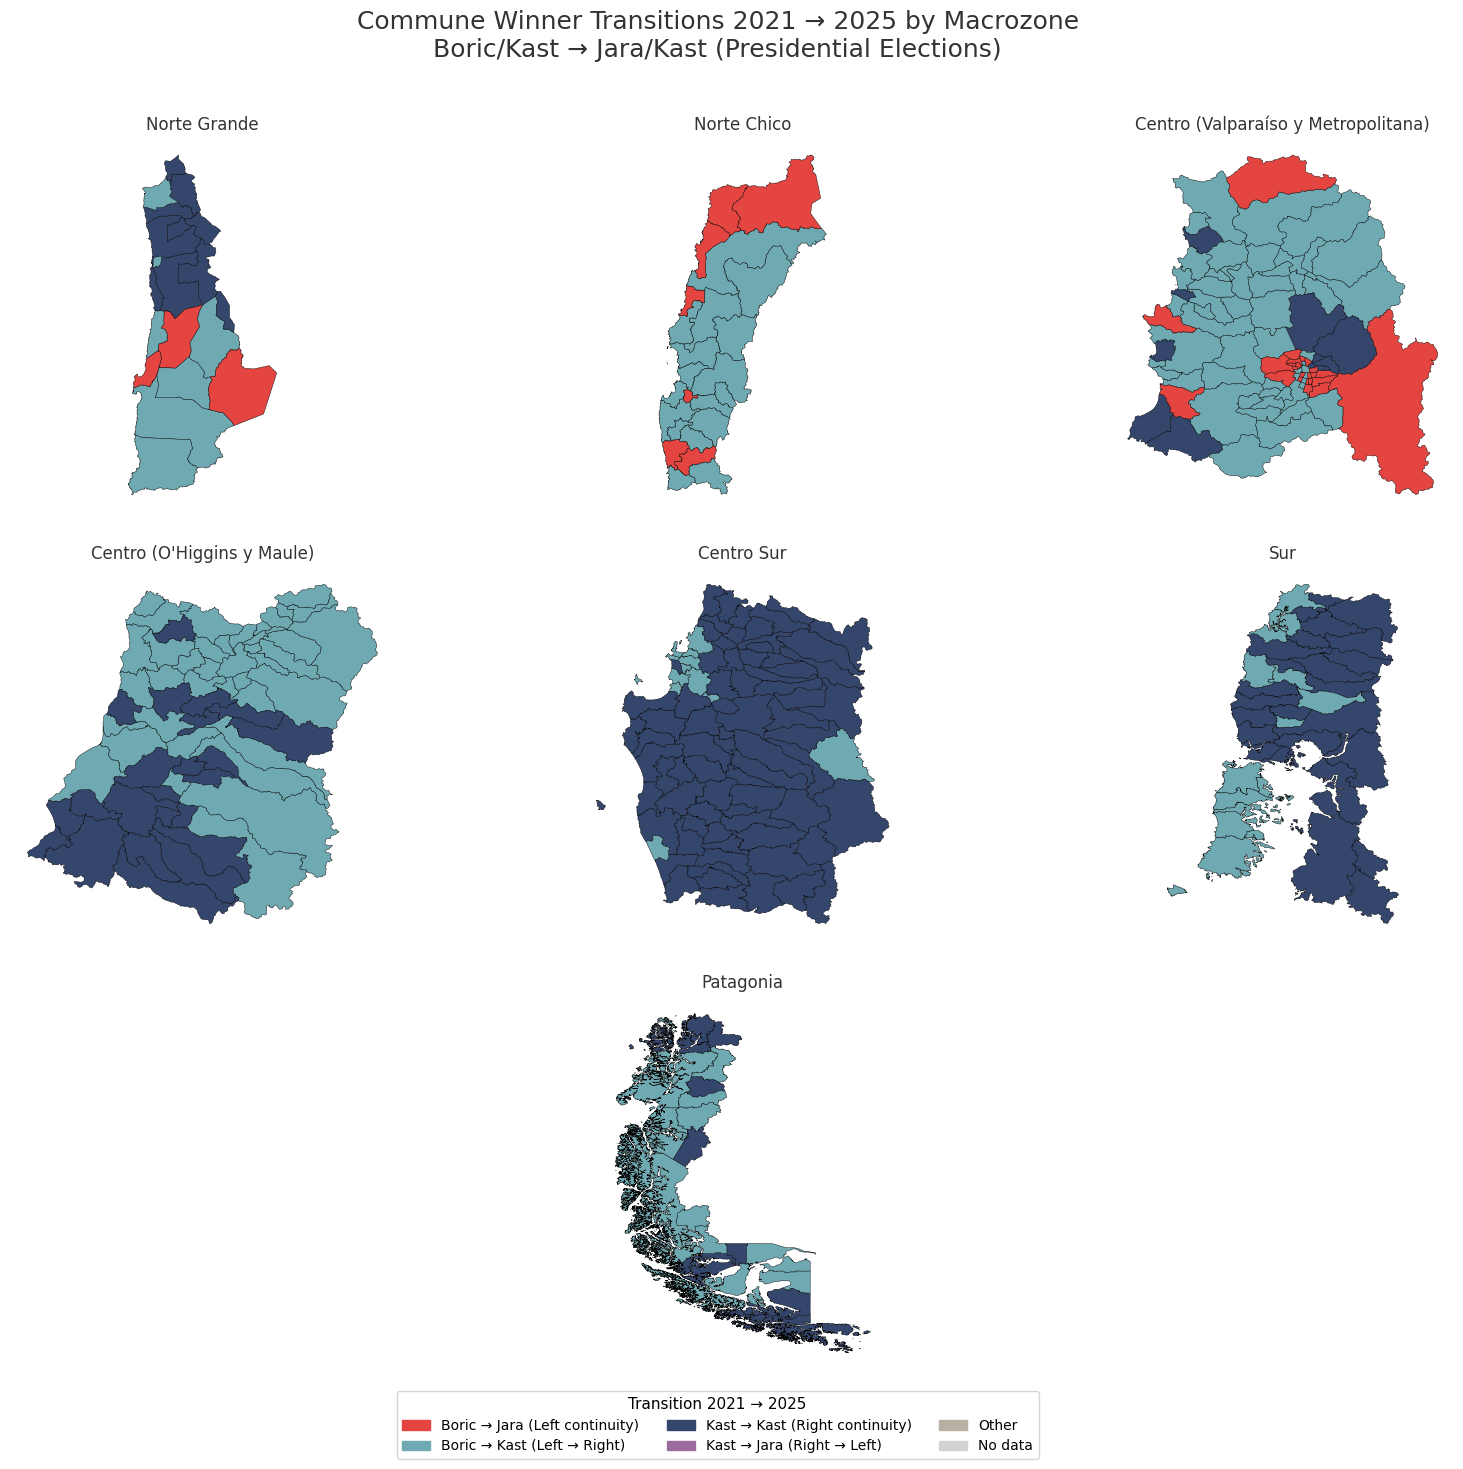

In [ ]:
# ============================================================================
# TRANSITION MAP 2021 → 2025 — BORIC/KAST → JARA/KAST
# ============================================================================
# Shows how communes changed winner between 2021 (Boric vs Kast) and 2025 (Jara vs Kast)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------------------
# 1. TRANSITION COLOR PALETTE (Simplified for Boric/Kast → Jara/Kast)
# ---------------------------------------------------------------------------
TRANSITION_COLORS = {
    'Boric → Jara':       '#E54540',   # Red (left continuity)
    'Boric → Kast':       '#6FAAB3',   # Light blue (left → right)
    'Kast → Kast':        '#35466D',   # Dark blue (right continuity)
    'Kast → Jara':        '#9B6B9E',   # Purple (right → left)
    'Other':              '#B8B0A2',   # Gray (should not occur with simplified winners)
}

def assign_transition_color(row):
    """Map the 2021→2025 winner transition pair to a display color."""
    w21, w25 = row.get('winner_2021'), row.get('winner_2025')
    
    # Boric transitions
    if w21 == 'Boric (Left)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS['Boric → Jara']
    if w21 == 'Boric (Left)' and w25 == 'Kast (Right)':
        return TRANSITION_COLORS['Boric → Kast']
    
    # Kast transitions
    if w21 == 'Kast (Right)' and w25 == 'Kast (Right)':
        return TRANSITION_COLORS['Kast → Kast']
    if w21 == 'Kast (Right)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS['Kast → Jara']
    
    return TRANSITION_COLORS['Other']

# ---------------------------------------------------------------------------
# 2. NAME NORMALIZATION FOR SPATIAL JOIN
# ---------------------------------------------------------------------------
communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
df_change['commune_norm'] = df_change['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# 3. SPATIAL JOIN: MERGE GEOMETRIES WITH TRANSITION DATA
# ---------------------------------------------------------------------------
map_data = communes_map.merge(
    df_change[['commune_norm', 'winner_2021', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data['color'] = map_data.apply(assign_transition_color, axis=1).fillna(TRANSITION_COLORS['Other'])

# Exclude island communes
map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

unmatched = map_data[map_data['winner_2021'].isna()]['NOM_COM'].tolist()
if unmatched:
    print(f"Communes with no transition data ({len(unmatched)}): {unmatched[:10]}")

# ---------------------------------------------------------------------------
# 4. MACROZONE ASSIGNMENT (7 ZONES)
# ---------------------------------------------------------------------------
MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  "Centro (O'Higgins y Maule)",
    7:  "Centro (O'Higgins y Maule)",
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 5. GRIDSPEC LAYOUT WITH SHARED LEGEND (consistent styling)
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('white')
gs = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, "Centro (O'Higgins y Maule)"),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

for ax, macro in zone_axes:
    macro_data = map_data[map_data['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='#333333')
        ax.set_title(macro, fontsize=12, color='#333333')
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=12, color='#333333')
    ax.set_axis_off()
    ax.set_aspect('equal')

    if macro == 'Patagonia':
        bounds = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

# Main title (no fontweight='bold')
fig.suptitle(
    'Commune Winner Transitions 2021 → 2025 by Macrozone\n'
    'Boric/Kast → Jara/Kast (Presidential Elections)',
    fontsize=18, y=0.96, color='#333333'
)

# ---------------------------------------------------------------------------
# 6. SHARED LEGEND (Simplified, with consistent styling)
# ---------------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color='#E54540', label='Boric → Jara (Left continuity)'),
    mpatches.Patch(color='#6FAAB3', label='Boric → Kast (Left → Right)'),
    mpatches.Patch(color='#35466D', label='Kast → Kast (Right continuity)'),
    mpatches.Patch(color='#9B6B9E', label='Kast → Jara (Right → Left)'),
    mpatches.Patch(color='#B8B0A2', label='Other'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

fig.legend(
    handles=legend_handles, 
    loc='lower center', 
    ncol=3, 
    fontsize=10,
    title='Transition 2021 → 2025', 
    title_fontsize=11,
    bbox_to_anchor=(0.5, 0.05),
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc'
)

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()

#### Hallazgo Principal

El mapa de transiciones entre la primera vuelta de 2021 y la de 2025 muestra un **realineamiento significativo hacia la derecha**, con José Antonio Kast como gran beneficiario. Kast no solo retuvo la gran mayoría de sus comunas de 2021, sino que logró capturar una cantidad importante de comunas que habían votado por **Gabriel Boric** (color teal: Boric → Kast). 

El cambio más notable es la **erosión del voto de izquierda** en el Norte y parte del Centro, mientras que el Centro-Sur y Sur muestran una **alta continuidad** del voto conservador.

#### Análisis por Macrozona

**1. Norte Grande**  
- Predominio de azul oscuro (Kast → Kast) y teal (Boric → Kast).  
- Algunas comunas rojas (Boric → Jara) en el extremo norte.  
- **Interpretación**: Kast consolidó su presencia y capturó territorio que antes era de Boric. El Norte muestra un claro giro hacia la derecha.

**2. Norte Chico**  
- Fuerte presencia de rojo (Boric → Jara) y teal (Boric → Kast).  
- **Interpretación**: Zona de alta volatilidad. Jara logró retener parte del voto de izquierda de 2021, pero Kast también avanzó significativamente.

**3. Centro (Valparaíso + Metropolitana)**  
- Mezcla compleja: rojo (continuidad de Boric a Jara) en el sur/poniente de Santiago y Valparaíso, azul oscuro en el oriente y sectores medios-altos, y teal en varias comunas de transición.  
- **Interpretación**: Aquí se ve la **polarización socioeconómica** más clara. Jara mantiene bastiones populares, pero Kast avanza en gran parte del territorio.

**4. Centro (O’Higgins y Maule) y Centro Sur**  
- Dominio casi absoluto de azul oscuro (Kast → Kast) con algo de teal.  
- Muy poca presencia roja.  
- **Interpretación**: Estas son las zonas de **mayor continuidad y consolidación** de Kast. Su base conservadora aquí es muy estable.

**5. Sur y Patagonia**  
- Predominio fuerte de azul oscuro, con algo de teal (Boric → Kast).  
- **Interpretación**: Kast consolida el sur como uno de sus grandes bastiones. El realineamiento aquí favorece claramente a la derecha.

#### Interpretación Estratégica General

- **Kast como gran ganador del realineamiento**: Capturó numerosas comunas de Boric (teal) y retuvo casi todas las suyas.  
- **Jara defensiva**: Logró retener parte del voto de Boric (rojo), pero solo en zonas específicas (sur de Santiago, Valparaíso y algunos enclaves del Norte).  
- **El Norte como zona clave de cambio**: Fue la región con mayor movimiento, donde el voto de izquierda de 2021 se dividió entre Jara y Kast.  
- **Estabilidad en el Sur**: El Chile rural y sureño mostró alta fidelidad al voto de derecha.

**Conclusión**:  
Entre 2021 y 2025 se produjo un **giro territorial hacia la derecha**. Kast logró una coalición más amplia y geográficamente diversa, mientras que la izquierda (Boric → Jara) quedó más concentrada en núcleos urbanos populares. Este realineamiento explica la amplitud de la victoria de Kast en 2025 y deja a la izquierda con un mapa más vulnerable y dependiente de sus bastiones tradicionales.

#### 12.4.1. Maps of metropolitan areas and conurbations

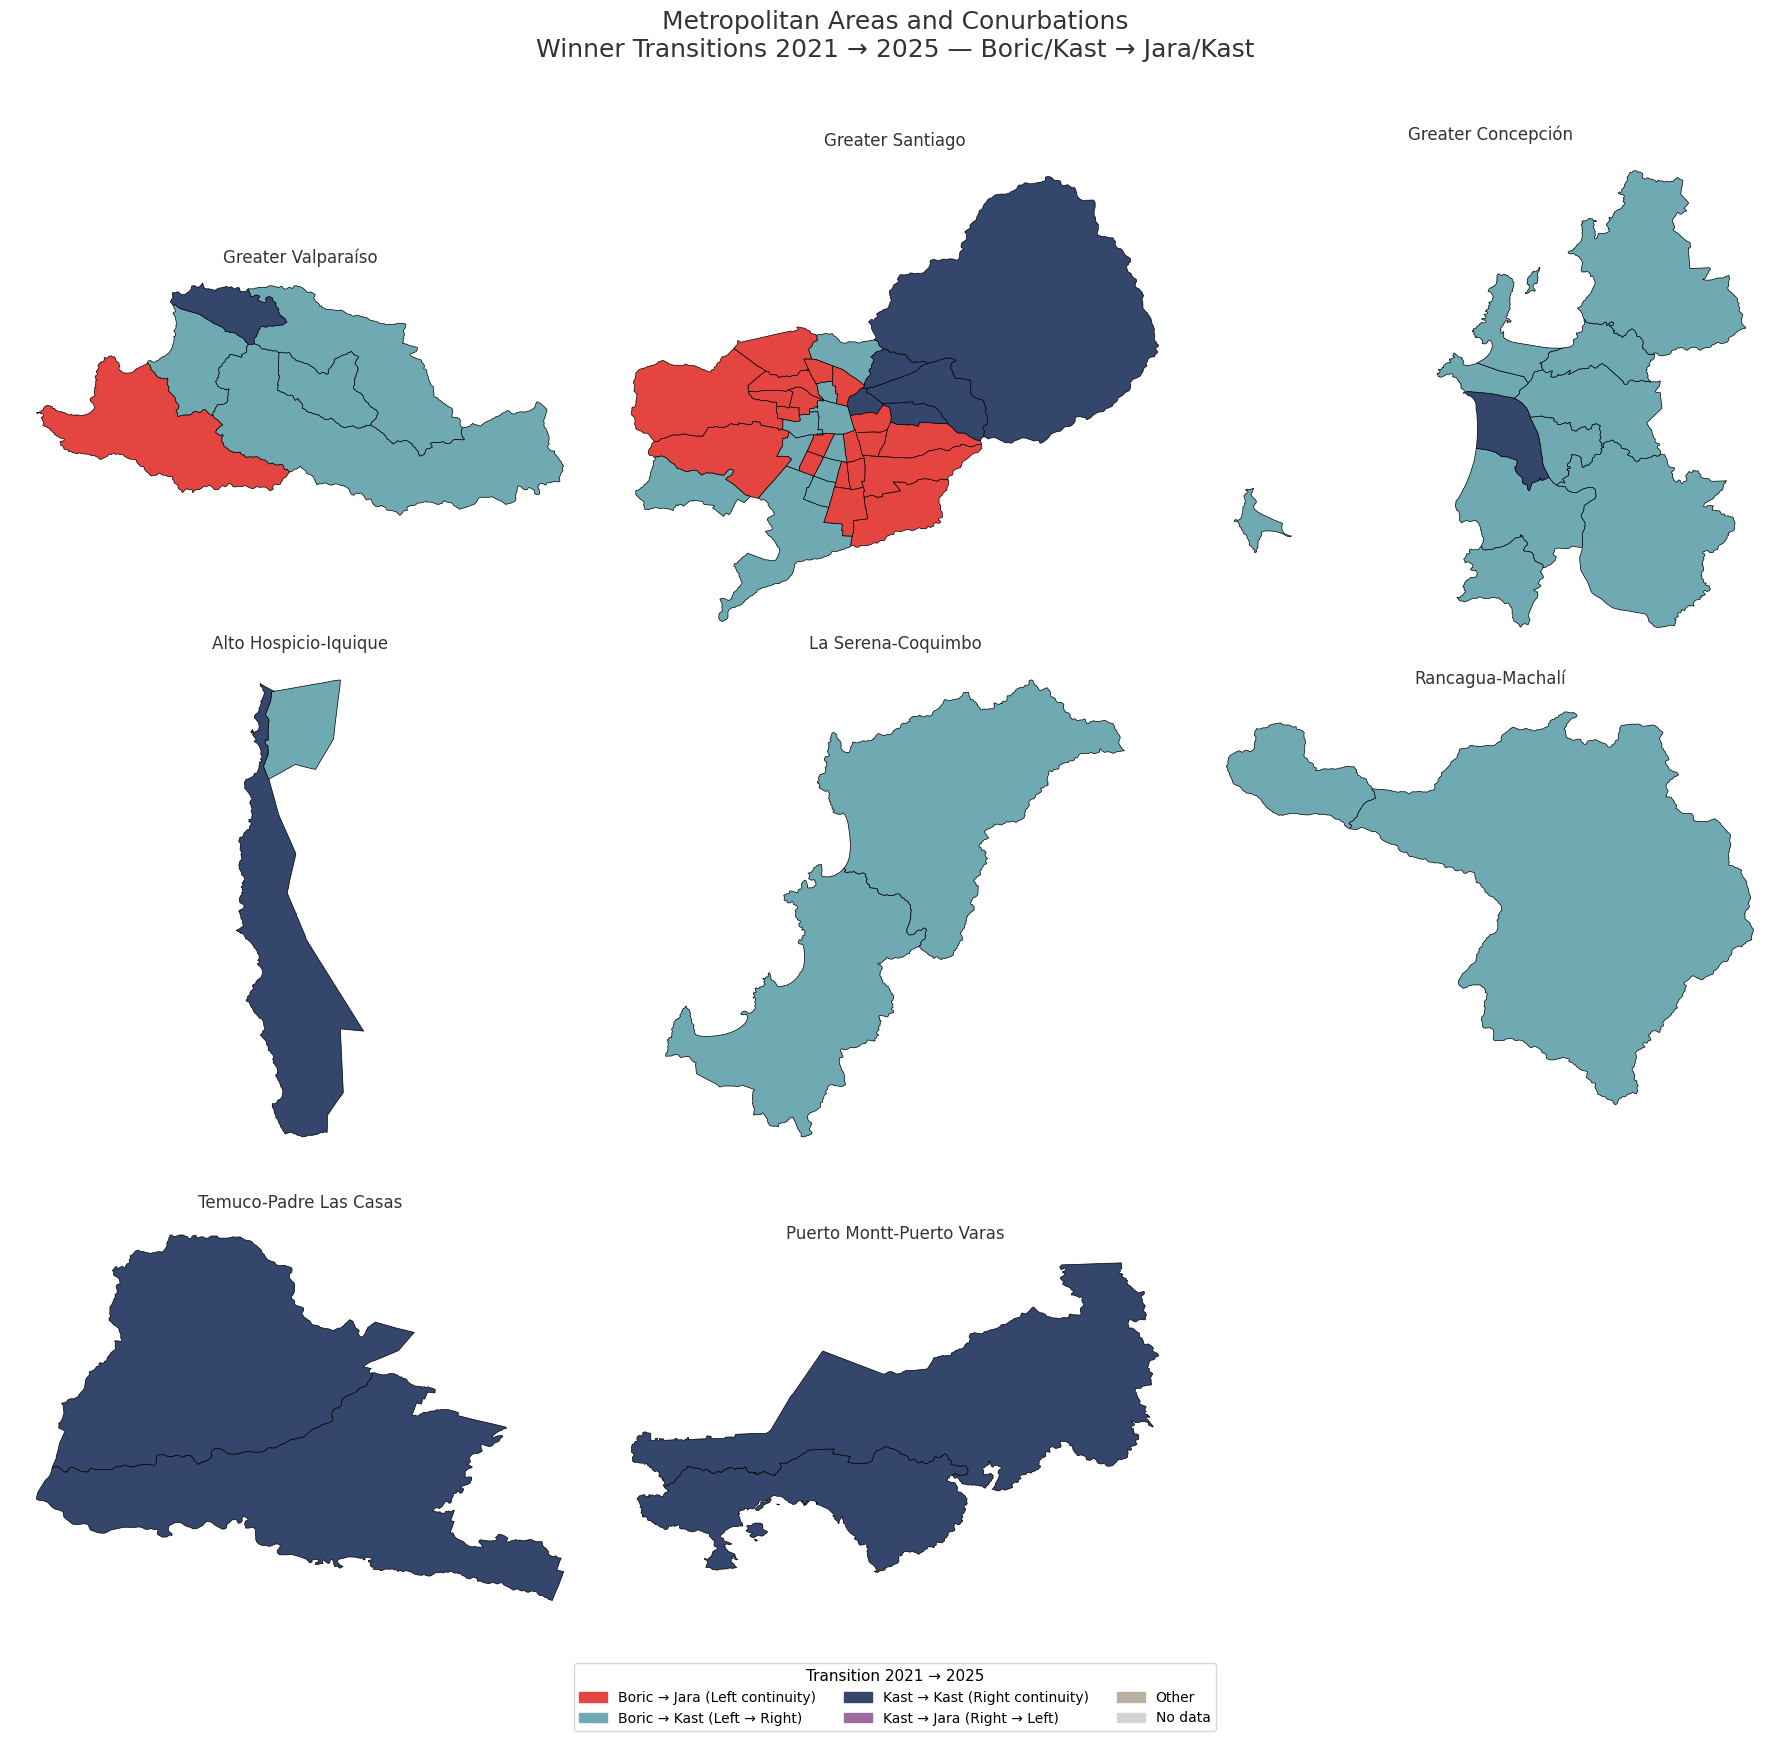

In [ ]:
# ============================================================================
# METROPOLITAN AREAS AND CONURBATIONS — WINNER TRANSITION MAP 2021 → 2025
# ============================================================================
# Focus: Boric/Kast (2021) → Jara/Kast (2025)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------------------
# 1. URBAN AGGLOMERATION DEFINITIONS
# ---------------------------------------------------------------------------
METRO_AREAS_TRANS = {
    'Greater Valparaíso': [
        "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
    ],
    'Greater Santiago': [
        "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
        "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
        "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
        "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
        "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
        "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
        "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
    ],
    'Greater Concepción': [
        "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
        "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
    ],
    'Alto Hospicio-Iquique':    ["Alto Hospicio", "Iquique"],
    'La Serena-Coquimbo':       ["La Serena", "Coquimbo"],
    'Rancagua-Machalí':         ["Rancagua", "Machalí"],
    'Temuco-Padre Las Casas':   ["Temuco", "Padre Las Casas"],
    'Puerto Montt-Puerto Varas': ["Puerto Montt", "Puerto Varas"],
}

# Grid layout: (row, col) → area name  (cell (2,2) intentionally empty)
GRID_LAYOUT_TRANS = [
    (0, 0, 'Greater Valparaíso'),
    (0, 1, 'Greater Santiago'),
    (0, 2, 'Greater Concepción'),
    (1, 0, 'Alto Hospicio-Iquique'),
    (1, 1, 'La Serena-Coquimbo'),
    (1, 2, 'Rancagua-Machalí'),
    (2, 0, 'Temuco-Padre Las Casas'),
    (2, 1, 'Puerto Montt-Puerto Varas'),
]

# Pre-compute normalized key sets for encoding-safe GeoJSON filtering
area_norm_keys_trans = {
    area: {normalize_commune_name(c) for c in commune_list}
    for area, commune_list in METRO_AREAS_TRANS.items()
}

# ---------------------------------------------------------------------------
# 2. TRANSITION COLOR PALETTE (Simplified - consistent with national map)
# ---------------------------------------------------------------------------
TRANSITION_COLORS_SIMPLE = {
    'Boric → Jara':       '#E54540',   # Red (left continuity)
    'Boric → Kast':       '#6FAAB3',   # Light blue (left → right)
    'Kast → Kast':        '#35466D',   # Dark blue (right continuity)
    'Kast → Jara':        '#9B6B9E',   # Purple (right → left)
    'Other':              '#B8B0A2',   # Gray
}

def assign_transition_color_simple(row):
    """Map the 2021→2025 winner transition pair to a display color."""
    w21, w25 = row.get('winner_2021'), row.get('winner_2025')
    
    if w21 == 'Boric (Left)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS_SIMPLE['Boric → Jara']
    if w21 == 'Boric (Left)' and w25 == 'Kast (Right)':
        return TRANSITION_COLORS_SIMPLE['Boric → Kast']
    if w21 == 'Kast (Right)' and w25 == 'Kast (Right)':
        return TRANSITION_COLORS_SIMPLE['Kast → Kast']
    if w21 == 'Kast (Right)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS_SIMPLE['Kast → Jara']
    
    return TRANSITION_COLORS_SIMPLE['Other']

# ---------------------------------------------------------------------------
# 3. BUILD TRANSITION GEODATAFRAME
# ---------------------------------------------------------------------------
communes_trans = communes.copy()
communes_trans['NOM_COM_NORM'] = communes_trans['NOM_COM'].apply(normalize_commune_name)

df_change_local = df_change.copy()
df_change_local['commune_norm'] = df_change_local['commune'].apply(normalize_commune_name)

map_data_trans = communes_trans.merge(
    df_change_local[['commune_norm', 'winner_2021', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data_trans['color'] = (
    map_data_trans.apply(assign_transition_color_simple, axis=1)
    .fillna(TRANSITION_COLORS_SIMPLE['Other'])
)

# Exclude island communes
map_data_trans = map_data_trans[~map_data_trans['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

# ---------------------------------------------------------------------------
# 4. RENDER 3×3 FACET GRID (with consistent styling)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Metropolitan Areas and Conurbations\n'
    'Winner Transitions 2021 → 2025 — Boric/Kast → Jara/Kast',
    fontsize=18, y=0.98, color='#333333'
)

for row, col, area_name in GRID_LAYOUT_TRANS:
    ax = axes[row, col]
    norm_set = area_norm_keys_trans[area_name]

    area_data = map_data_trans[map_data_trans['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{area_name}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='#333333')
        ax.set_title(area_name, fontsize=12, color='#333333')
        ax.set_axis_off()
        continue

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(area_name, fontsize=12, color='#333333')
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide unused bottom-right cell
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 5. SHARED LEGEND (Simplified, with consistent styling)
# ---------------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color='#E54540', label='Boric → Jara (Left continuity)'),
    mpatches.Patch(color='#6FAAB3', label='Boric → Kast (Left → Right)'),
    mpatches.Patch(color='#35466D', label='Kast → Kast (Right continuity)'),
    mpatches.Patch(color='#9B6B9E', label='Kast → Jara (Right → Left)'),
    mpatches.Patch(color='#B8B0A2', label='Other'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

fig.legend(
    handles=legend_handles, 
    loc='lower center', 
    ncol=3, 
    fontsize=10,
    title='Transition 2021 → 2025', 
    title_fontsize=11,
    bbox_to_anchor=(0.5, 0.02),
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

#### Hallazgo Principal

El mapa de transiciones en las principales áreas metropolitanas muestra un **realineamiento claro hacia la derecha** en la mayoría de las conurbaciones del país. Kast logró retener y expandir su base, capturando numerosas comunas que habían votado por Boric en 2021 (color teal), mientras Jara mantuvo bastiones significativos solo en sectores específicos del Gran Santiago y Valparaíso.

#### Análisis por Área Metropolitana

**1. Gran Santiago**  
- Mayor complejidad y polarización.  
- **Sur y Poniente**: Fuerte presencia roja (Boric → Jara), manteniendo el núcleo popular de izquierda.  
- **Oriente y gran parte del centro-norte**: Azul oscuro dominante (Kast → Kast).  
- Se observan transiciones teal (Boric → Kast) en varias comunas intermedias.  
**Interpretación**: Confirma la **división socioeconómica** de Santiago: Jara resiste en zonas populares densas, Kast domina en sectores de clase media-alta y oriente.

**2. Gran Valparaíso**  
- Mezcla de rojo (continuidad de Boric a Jara) en zonas tradicionales de izquierda y azul oscuro.  
- Kast avanza en gran parte del área, pero Jara conserva enclaves relevantes.  
**Interpretación**: Zona de competencia moderada con leve ventaja para Kast.

**3. Gran Concepción**  
- Dominio casi total de azul oscuro (Kast → Kast).  
- Muy poca presencia roja.  
**Interpretación**: Una de las mejores performances de Kast en áreas metropolitanas.

**4. Otras conurbaciones relevantes**  
- **La Serena-Coquimbo**: Mayoritariamente teal y azul (transición de Boric a Kast).  
- **Rancagua-Machalí**: Clara transición de Boric a Kast
- **Temuco-Padre Las Casas** y **Puerto Montt-Puerto Varas**: Azul oscuro predominante (Kast consolida el sur).  
- **Alto Hospicio-Iquique**: Azul oscuro, mostrando avance de Kast en el Norte.

### Interpretación Estratégica

- **Kast como gran absorbente**: Capturó numerosas comunas que votaron por Boric en 2021 (teal), especialmente en conurbaciones del Norte, Centro y Sur.  
- **Jara defensiva**: Logró retener parte del voto de izquierda de 2021 (rojo) solo en núcleos populares densos del Gran Santiago y Valparaíso.  
- **Tendencia general**: Kast logró mayorías en la mayoría de las áreas metropolitanas, excepto en sectores específicos del sur y poniente de Santiago.

**Conclusión**:  
Entre 2021 y 2025 se consolidó un **giro hacia la derecha** en las principales conurbaciones del país. Kast amplió su presencia en la mayoría de las áreas metropolitanas, mientras Jara quedó reducida a defender bastiones populares concentrados. Este mapa refuerza que la victoria de Kast en 2025 tuvo una base territorial amplia y diversa, incluso en las zonas donde vive la mayor parte de la población chilena.

## 13. Consejos Estratégicos Post-Elección 2025

### 13.1. Consejo a la Izquierda (Jara y coalición)
Jara logró defender con éxito su núcleo duro urbano-popular (alta retención, crecimiento en bastiones como Puente Alto, Maipú y comunas mineras del Norte), pero quedó atrapada en un mapa altamente concentrado y vulnerable. Ganó solo 36 comunas, dependió excesivamente de la Región Metropolitana y no logró construir una base territorial amplia. Kast, por el contrario, consolidó un dominio geográfico masivo (89,6% de las comunas) gracias a una coalición efectiva de derecha tradicional, libertaria y parte del voto antisistema.

#### Recomendaciones Estratégicas Clave

1. **Autocrítica profunda y renovación de mensaje** El desgaste de Boric fue heredado y costó caro. La izquierda debe reconocer errores en seguridad, migración, economía y gestión pública. El discurso de “transformación” y derechos debe complementarse con **orden, resultados concretos y eficiencia**. Sin esto, seguirás perdiendo terreno entre la clase media y el Norte.
2. **Diversificar y ampliar la base territorial**
   - **Norte**: Es tu gran oportunidad. Capitaliza los flips en comunas mineras (María Elena, Mejillones, etc.) y construye una agenda regional fuerte (distribución de riqueza minera, empleo local, seguridad fronteriza). No puedes permitir que Parisi o Kast sigan dominando el sentimiento anti-centralista.
   - **Clase media y periferias**: Necesitas mejorar tu penetración en comunas de clase media (no solo populares). El crecimiento en elite fue simbólico; enfócate en sectores medios urbanos y semi-rurales.
   - **Sur y zonas rurales**: Tienes una debilidad estructural. Debes desarrollar un discurso que combine justicia social con respeto a la identidad local, agricultura y seguridad.
3. **Construir una coalición más amplia y pragmática**
   - Fortalece lazos con el centro (DC, independientes moderados) sin perder tu identidad.
   - Forma cuadros jóvenes con experiencia en gestión local y resultados visibles.
   - Evita maximalismos ideológicos que alienen al electorado que votó por Parisi o se abstuvo.
4. **Preparación a mediano plazo (2025-2029)** Enfócate en **gestión local exitosa** en tus bastiones (RM y Valparaíso) para demostrar que sabes gobernar. Usa los próximos años para reconstruir credibilidad en seguridad y economía. El voto antisistema sigue latente: quien mejor lo canalice (con pragmatismo) tendrá ventaja.

**Mensaje clave para la próxima campaña**:

> “Aprendimos del error. Volvemos con humildad, orden y resultados concretos para todos los chilenos: seguridad, empleo digno y un Estado que funcione.”

----


### 2. Consejo a la Derecha (Kast y coalición)
- **No te duermas en los laureles**: Kast ganó con un buen margen, pero el voto de protesta (nulo + blanco) fue alto y la transferencia de Parisi no fue total. El desgaste de Boric ayudó mucho; ahora **tú estarás bajo el escrutinio**.
- **Gobierna para el centro y el Norte**: No solo para tu base rural y elite. Necesitas entregar resultados rápidos en **seguridad, migración y empleo** en el Norte, que sigue siendo una zona volátil. Si no resuelves los problemas que Parisi capitalizó, el antisistema puede volver contra ti.
- **Mantén la unidad**: La coalición (Republicanos + Chile Vamos + libertarios) es frágil. Evita purgas internas y radicalizaciones innecesarias. Kast debe gobernar como **presidente de todos**, no solo de su sector.

> **Mensaje clave**: “Ganamos por el desgaste del otro. Ahora debemos legitimar esta victoria con resultados.”


### 3. Consejo a Franco Parisi y el Sector Antisistema
- **No te quedes solo en el Norte**: Tu fortaleza regional es clara, pero es limitada demográficamente. Necesitas **expandirte** hacia el centro y sur si quieres ser un actor nacional relevante en 2029.
- **Construye una organización real**: El fenómeno Parisi depende mucho de tu figura. Necesitas estructurar el Partido de la Gente, formar cuadros y definir un programa más claro (economía, seguridad, anticorrupción) que vaya más allá del anti-establishment.
- **Define tu rol**: Tienes dos caminos:
  - **Opción A (Rey Maker)**: Negociar apoyo condicionado a Kast a cambio de cargos y políticas concretas.
  - **Opción B (Tercera Vía)**: Mantener independencia y prepararte para ser alternativa real en 2029, capitalizando cualquier desgaste de Kast.

> **Mensaje clave**: “Tuviste un rol importante, pero para crecer debes convertir el descontento en una propuesta constructiva y organizada.”